# 🔬 FYP: 4D Surgical Scene Reconstruction — Multi-Video Pipeline
### Modules 1–3 applied to Video01 + Video02–06 sequentially

**This notebook keeps every cell exactly as in the original.**
Videos 2–6 are processed by re-running the same pipeline cells inside a loop.
Each video saves to its own workspace. GPU memory is freed between videos.

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/EndoGaussian/FYP_4D_Surgical_Reconstruction_fixed.ipynb'

Mounted at /content/drive
Cloning into 'GASR'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 8.51 MiB | 36.02 MiB/s, done.


ValueError: Mountpoint must not already contain files

## ✅ Cell 0 — GPU Check & Drive Mount

In [ ]:
import subprocess, torch, os, gc, shutil
from google.colab import drive



# ── FIX GOOGLE DRIVE MOUNT ──────────────────
MOUNT_POINT = '/content/drive'

# Unmount old/broken mount if it exists
os.system(f'fusermount -u {MOUNT_POINT} 2>/dev/null')

# Remove corrupted folder contents if needed
if os.path.exists(MOUNT_POINT):
    try:
        shutil.rmtree(MOUNT_POINT)
    except:
        pass

# Recreate clean mount folder
os.makedirs(MOUNT_POINT, exist_ok=True)

# Mount Google Drive
drive.mount(MOUNT_POINT, force_remount=True)

# ── PATHS ───────────────────────────────────
DRIVE_BASE = '/content/drive/MyDrive/EndoGaussian'
DEVICE     = 'cuda'

# ══════════════════════════════════════════════════════════════════
# VIDEO REGISTRY — edit this list to add/remove videos
# Each tuple: (video_filename, workspace_folder_name)
# ══════════════════════════════════════════════════════════════════
VIDEOS = [
    ('Video01.mp4', 'workspace_v2'),
    ('Video02.mp4', 'workspace_video2'),
    ('Video03.mp4', 'workspace_video3'),
    ('video04.mp4', 'workspace_video4'),
    ('Video05.mp4', 'workspace_video5'),
    ('Video06.mp4', 'workspace_video6'),
]

# ── Verify all videos exist ─────────────────
print('\nChecking videos:')

missing = []

for vname, wname in VIDEOS:
    vpath = f'{DRIVE_BASE}/{vname}'

    exists = os.path.exists(vpath)

    size = (
        f'{os.path.getsize(vpath)/1e6:.0f} MB'
        if exists else 'NOT FOUND'
    )

    print(
        f'  {"✅" if exists else "❌"}  '
        f'{vname:<18} → {wname:<22}  {size}'
    )

    if not exists:
        missing.append(vname)

if missing:
    raise FileNotFoundError(f'Missing videos: {missing}')

# ── Set paths for FIRST video ───────────────
VIDEO_NAME = VIDEOS[0][0]
WS_NAME    = VIDEOS[0][1]

VIDEO_PATH = f'{DRIVE_BASE}/{VIDEO_NAME}'
WORKSPACE  = f'{DRIVE_BASE}/{WS_NAME}'

FRAMES_DIR  = f'{WORKSPACE}/frames'
DEPTH_DIR   = f'{WORKSPACE}/depth'
MASKS_DIR   = f'{WORKSPACE}/masks'
CKPT_DIR    = f'{WORKSPACE}/checkpoints'
EXPORT_DIR  = f'{WORKSPACE}/exports'
WEIGHTS_DIR = f'{WORKSPACE}/weights'

for d in [
    WORKSPACE,
    FRAMES_DIR,
    DEPTH_DIR,
    MASKS_DIR,
    CKPT_DIR,
    EXPORT_DIR,
    WEIGHTS_DIR
]:
    os.makedirs(d, exist_ok=True)

print(f'\nCurrent workspace : {WORKSPACE}')
print(f'Current video     : {VIDEO_PATH}  [{os.path.exists(VIDEO_PATH)}]')

print(
    f'\nAll {len(VIDEOS)} videos registered. '
    f'Run cells below normally for Video01, '
    f'then run the MULTI-VIDEO LOOP cell at the bottom '
    f'for Videos 02-06.'
)

Mon Jul 27 14:17:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|===============
PyTorch 2.11.0+cu128 | CUDA 12.8 | GPU: Tesla T4


## ✅ Cell 1 — Install Dependencies (no custom CUDA compilation)

In [ ]:
import subprocess, sys

pkgs = [
    'gsplat',           # Gaussian splatting rasterizer (pre-built wheel)
    'open3d',           # point cloud I/O and visualisation
    'plyfile',          # PLY export
    'lpips',            # perceptual loss metric
    'einops',
    'tqdm',
    'imageio',
    'imageio-ffmpeg',
    'scikit-image',
]

for pkg in pkgs:
    r = subprocess.run(f'pip install -q {pkg}', shell=True, capture_output=True, text=True)
    ok = '✅' if r.returncode == 0 else '❌'
    print(f'  {ok} {pkg}')

# Verify gsplat
import gsplat, torch
print(f'\ngsplat {gsplat.__version__} ready')

# Warm-up gsplat JIT (runs once, ~60s)
print('Warming up gsplat JIT...')
from gsplat import rasterization
N = 8
_m = torch.zeros(N,3,device='cuda')
_q = torch.zeros(N,4,device='cuda'); _q[:,0]=1
_s = torch.ones(N,3,device='cuda')*0.01
_o = torch.ones(N,device='cuda')*0.5
_c = torch.ones(N,3,device='cuda')*0.5
_v = torch.eye(4,device='cuda').unsqueeze(0)
_K = torch.tensor([[[100.,0,50],[0,100,50],[0,0,1]]],device='cuda')
_ = rasterization(_m,_q,_s,_o,_c,viewmats=_v,Ks=_K,width=100,height=100)
print('✅ gsplat JIT complete — rasterizer ready')


  ✅ gsplat
  ✅ open3d
  ✅ plyfile
  ✅ lpips
  ✅ einops
  ✅ tqdm
  ✅ imageio
  ✅ imageio-ffmpeg
  ✅ scikit-image

gsplat 1.5.3 ready
Warming up gsplat JIT...


Output()

gsplat: CUDA extension has been set up successfully in 868.26 seconds.

✅ gsplat JIT complete — rasterizer ready


## ✅ Module 1 — Video Preprocessing & Frame Extraction
Extracts frames, checks quality (sharpness, continuity), and generates tool masks.


Copying video to /tmp (avoids Google Drive FUSE issue)...
Copied: 15.8 MB
Video: 438 frames @ 30.0fps  1280×720
✅ 219 frames already extracted — skipping.

Dataset: 219 frames @ 640×360
Sharpness — mean: 361.0  min: 246.9  max: 541.1
Optical flow — mean motion: 1.10 px/frame


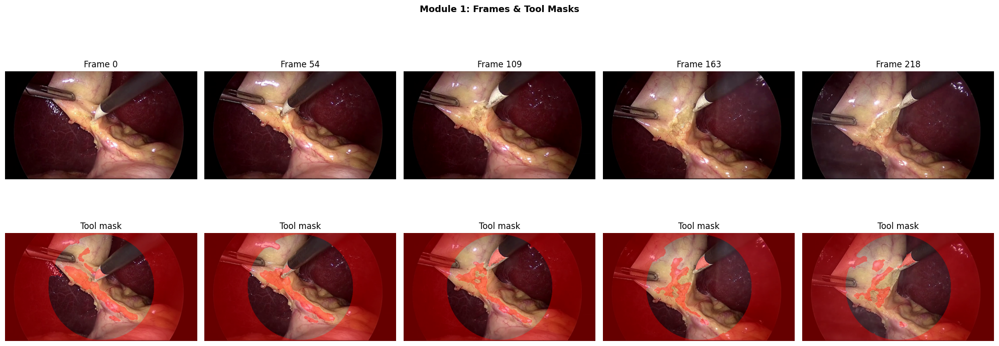


✅ Module 1 complete — 219 frames ready.


In [ ]:
import cv2, os, glob, math, shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Config ───────────────────────────────────────────────────────
FRAME_STRIDE     = 2
TARGET_W, TARGET_H = 640, 360
SHARPNESS_THRESH = 30.0

# ═══════════════════════════════════════════════════════════════
#  FIX: OpenCV cannot read directly from Google Drive (FUSE FS).
#  Copy video to /tmp first, then read from local disk.
# ═══════════════════════════════════════════════════════════════
LOCAL_VIDEO = '/tmp/surgical_video.mp4'

if not os.path.exists(LOCAL_VIDEO):
    print(f'Copying video to /tmp (avoids Google Drive FUSE issue)...')
    if not os.path.exists(VIDEO_PATH):
        raise FileNotFoundError(
            f'Video not found at {VIDEO_PATH}\n'
            f'Please check the path in Cell 0 (DRIVE_BASE / VIDEO_PATH).')
    shutil.copy2(VIDEO_PATH, LOCAL_VIDEO)
    print(f'Copied: {os.path.getsize(LOCAL_VIDEO)/1e6:.1f} MB')
else:
    print(f'Using cached /tmp video ({os.path.getsize(LOCAL_VIDEO)/1e6:.1f} MB)')

# ── Verify video opens ────────────────────────────────────────────
cap = cv2.VideoCapture(LOCAL_VIDEO)
if not cap.isOpened():
    raise RuntimeError(f'OpenCV cannot open {LOCAL_VIDEO}. '
                        'Try: pip install opencv-python-headless')

FPS   = cap.get(cv2.CAP_PROP_FPS)
N_RAW = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W_RAW = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_RAW = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'Video: {N_RAW} frames @ {FPS:.1f}fps  {W_RAW}×{H_RAW}')

if N_RAW == 0:
    cap.release()
    raise RuntimeError(
        'OpenCV reports 0 frames. The video codec may be unsupported.\n'
        'Run this fix cell:\n'
        '  !pip install -q imageio imageio-ffmpeg\n'
        '  !ffmpeg -i /tmp/surgical_video.mp4 -vf fps=15 '
        '  /tmp/surgical_frames/%05d.png\n'
        'Then set FRAMES_ALREADY_EXTRACTED = True below.')

# ── Extract frames ────────────────────────────────────────────────
existing = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))
if len(existing) >= 20:
    print(f'✅ {len(existing)} frames already extracted — skipping.')
else:
    print(f'Extracting frames (stride={FRAME_STRIDE})...')
    raw_idx = saved = sharp_dropped = 0
    pbar = tqdm(total=N_RAW // FRAME_STRIDE)
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if raw_idx % FRAME_STRIDE == 0:
            img       = cv2.resize(frame, (TARGET_W, TARGET_H),
                                   interpolation=cv2.INTER_AREA)
            gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
            if sharpness >= SHARPNESS_THRESH:
                cv2.imwrite(f'{FRAMES_DIR}/{saved:05d}.png', img)
                saved += 1
            else:
                sharp_dropped += 1
            pbar.update(1)
        raw_idx += 1
    cap.release()
    pbar.close()
    print(f'Saved {saved} frames  ({sharp_dropped} dropped: too blurry)')

# ── Load frame list ───────────────────────────────────────────────
frames_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))
N_FRAMES    = len(frames_list)
if N_FRAMES == 0:
    raise RuntimeError('No frames extracted. Check VIDEO_PATH in Cell 0.')

sample = cv2.imread(frames_list[0])
H, W   = sample.shape[:2]
print(f'\nDataset: {N_FRAMES} frames @ {W}×{H}')

# ── Quality metrics ───────────────────────────────────────────────
sharpness_scores = []
for fp in frames_list:
    g = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2GRAY)
    sharpness_scores.append(cv2.Laplacian(g, cv2.CV_64F).var())
print(f'Sharpness — mean: {np.mean(sharpness_scores):.1f}  '
      f'min: {np.min(sharpness_scores):.1f}  '
      f'max: {np.max(sharpness_scores):.1f}')

# ── Optical flow continuity ───────────────────────────────────────
flow_mags = []
prev_gray = cv2.cvtColor(cv2.imread(frames_list[0]), cv2.COLOR_BGR2GRAY)
for fp in frames_list[1:min(60, N_FRAMES)]:
    curr_gray = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    flow_mags.append(np.sqrt(flow[...,0]**2 + flow[...,1]**2).mean())
    prev_gray = curr_gray
print(f'Optical flow — mean motion: {np.mean(flow_mags):.2f} px/frame')

# ── Tool masks ────────────────────────────────────────────────────
def make_tool_mask(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    s, v = hsv[:,:,1], hsv[:,:,2]
    H2, W2 = bgr.shape[:2]
    circ = np.zeros((H2,W2), np.uint8)
    cv2.circle(circ,(W2//2,H2//2), min(W2,H2)//2-4, 255, -1)
    border = cv2.bitwise_not(circ)
    metal  = ((s < 55) & (v > 70)).astype(np.uint8)*255
    bright = (v > 235).astype(np.uint8)*255
    dark   = (v <  18).astype(np.uint8)*255
    comb   = cv2.bitwise_or(cv2.bitwise_or(metal, bright),
                            cv2.bitwise_or(dark,  border))
    k    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))
    comb = cv2.morphologyEx(comb, cv2.MORPH_CLOSE, k, iterations=2)
    comb = cv2.morphologyEx(comb, cv2.MORPH_OPEN,  k, iterations=1)
    n,labs,stats,_ = cv2.connectedComponentsWithStats(comb)
    out = np.zeros_like(comb)
    for lbl in range(1,n):
        if stats[lbl, cv2.CC_STAT_AREA] >= 200:
            out[labs==lbl] = 255
    return out

done_masks = glob.glob(f'{MASKS_DIR}/*.png')
if len(done_masks) < N_FRAMES:
    print('Generating tool masks...')
    for fp in tqdm(frames_list):
        stem = os.path.splitext(os.path.basename(fp))[0]
        out  = f'{MASKS_DIR}/{stem}.png'
        if not os.path.exists(out):
            cv2.imwrite(out, make_tool_mask(cv2.imread(fp)))

# ── Visualise ─────────────────────────────────────────────────────
n_show = min(5, N_FRAMES)
idxs   = np.linspace(0, N_FRAMES-1, n_show, dtype=int)
fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 8))
for col, idx in enumerate(idxs):
    img  = cv2.cvtColor(cv2.imread(frames_list[idx]), cv2.COLOR_BGR2RGB)
    stem = os.path.splitext(os.path.basename(frames_list[idx]))[0]
    mask = cv2.imread(f'{MASKS_DIR}/{stem}.png', cv2.IMREAD_GRAYSCALE)
    ov   = img.copy(); ov[mask>127] = [255,0,0]
    bl   = cv2.addWeighted(img, 0.6, ov, 0.4, 0)
    axes[0,col].imshow(img);  axes[0,col].set_title(f'Frame {idx}'); axes[0,col].axis('off')
    axes[1,col].imshow(bl);   axes[1,col].set_title('Tool mask');    axes[1,col].axis('off')
plt.suptitle('Module 1: Frames & Tool Masks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORKSPACE}/module1_preprocessing.png', dpi=100)
plt.show()
print(f'\n✅ Module 1 complete — {N_FRAMES} frames ready.')


## ✅ Cell 3 — Pseudo-Depth Estimation (Depth-Anything-V2)
Monocular depth priors for initialising Gaussian positions from 2D pixel lifts.


Depth-Anything-V2 loaded.
✅ 219 depth maps already computed.


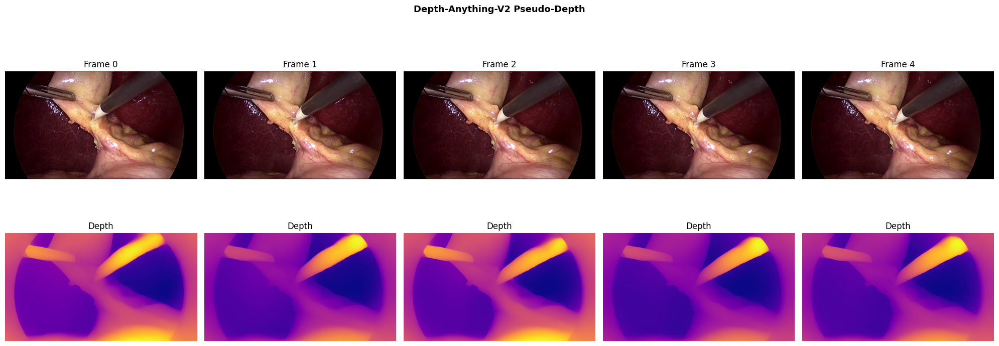

In [ ]:
import subprocess, os, sys, glob
import torch, cv2, numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

DA_DIR  = f'{WORKSPACE}/Depth-Anything-V2'
DA_CKPT = f'{WEIGHTS_DIR}/depth_anything_v2_vits.pth'

def sh(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0: print(r.stderr[-500:])

if not os.path.isdir(f'{DA_DIR}/.git'):
    sh(f'git clone -q https://github.com/DepthAnything/Depth-Anything-V2.git {DA_DIR}')
    sh('pip install -q transformers')

if not os.path.exists(DA_CKPT):
    print('Downloading Depth-Anything-V2 ViT-S weights (~97 MB)...')
    sh(f'wget -q -O {DA_CKPT} https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth')
    print('Downloaded.')

sys.path.insert(0, DA_DIR)
from depth_anything_v2.dpt import DepthAnythingV2

da = DepthAnythingV2(encoder='vits', features=64, out_channels=[48,96,192,384])
da.load_state_dict(torch.load(DA_CKPT, map_location='cpu'))
da = da.to(DEVICE).eval()
print('Depth-Anything-V2 loaded.')

frames_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))
done = glob.glob(f'{DEPTH_DIR}/*.npy')

if len(done) < len(frames_list):
    print(f'Estimating depth for {len(frames_list)} frames...')
    for fp in tqdm(frames_list):
        stem = os.path.splitext(os.path.basename(fp))[0]
        np_path  = f'{DEPTH_DIR}/{stem}.npy'
        png_path = f'{DEPTH_DIR}/{stem}.png'
        if os.path.exists(np_path): continue
        raw = cv2.imread(fp)
        d   = da.infer_image(raw).astype(np.float32)
        np.save(np_path, d)
        d_u16 = ((d-d.min())/(d.max()-d.min()+1e-8)*65535).astype(np.uint16)
        cv2.imwrite(png_path, d_u16)
    print('Done.')
else:
    print(f'✅ {len(done)} depth maps already computed.')

# Preview
si = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))[:5]
sd = sorted(glob.glob(f'{DEPTH_DIR}/*.npy'))[:5]
fig, axes = plt.subplots(2,5,figsize=(20,8))
for i in range(5):
    axes[0,i].imshow(cv2.cvtColor(cv2.imread(si[i]),cv2.COLOR_BGR2RGB))
    axes[0,i].set_title(f'Frame {i}'); axes[0,i].axis('off')
    axes[1,i].imshow(np.load(sd[i]),cmap='plasma')
    axes[1,i].set_title('Depth'); axes[1,i].axis('off')
plt.suptitle('Depth-Anything-V2 Pseudo-Depth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORKSPACE}/depth_preview.png', dpi=100)
plt.show()


## ✅ Cell 4 — Camera Intrinsics & Pose Estimation
Standard laparoscope FOV + optical-flow pose tracking.


In [ ]:
import cv2, math, json, glob, os
import numpy as np
from tqdm import tqdm

frames_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))
sample = cv2.imread(frames_list[0])
H, W   = sample.shape[:2]

# ── Intrinsics (standard 10mm laparoscope ~75° HFOV) ──
FOV_DEG = 75.0
fx = (W/2) / math.tan(math.radians(FOV_DEG)/2)
fy, cx, cy = fx, W/2.0, H/2.0
K_np = np.array([[fx,0,cx],[0,fy,cy],[0,0,1]], dtype=np.float64)
print(f'Intrinsics: fx={fx:.1f}  cx={cx:.0f}  cy={cy:.0f}  ({W}×{H})')

# ── Pose tracking ──
poses_path = f'{WORKSPACE}/camera_poses.npy'

if os.path.exists(poses_path):
    poses = np.load(poses_path)
    print(f'✅ Loaded {len(poses)} saved poses.')
else:
    feat_p = dict(maxCorners=600, qualityLevel=0.008, minDistance=7, blockSize=7)
    lk_p   = dict(winSize=(21,21), maxLevel=3,
                   criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT,30,0.01))
    poses     = [np.eye(4, dtype=np.float64)]
    c2w       = np.eye(4, dtype=np.float64)
    prev_gray = cv2.cvtColor(cv2.imread(frames_list[0]), cv2.COLOR_BGR2GRAY)
    prev_pts  = cv2.goodFeaturesToTrack(prev_gray, mask=None, **feat_p)

    for i in tqdm(range(1, len(frames_list)), desc='Estimating poses'):
        curr_gray = cv2.cvtColor(cv2.imread(frames_list[i]), cv2.COLOR_BGR2GRAY)
        if prev_pts is not None and len(prev_pts) >= 5:
            curr_pts, st, _ = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None, **lk_p)
            gp, gc = prev_pts[st==1], curr_pts[st==1]
            if len(gp) >= 5:
                E, _ = cv2.findEssentialMat(gp, gc, K_np, method=cv2.RANSAC, prob=0.999, threshold=1.0)
                if E is not None and E.shape==(3,3):
                    _, R, t, _ = cv2.recoverPose(E, gp, gc, K_np)
                    delta = np.eye(4); delta[:3,:3]=R; delta[:3,3]=(t*0.01).flatten()
                    c2w = c2w @ np.linalg.inv(delta)
        poses.append(c2w.copy())
        if i%10==0:
            prev_pts = cv2.goodFeaturesToTrack(curr_gray, mask=None, **feat_p)
        prev_gray = curr_gray

    poses = np.array(poses, dtype=np.float64)
    np.save(poses_path, poses)
    print(f'Saved {len(poses)} poses → {poses_path}')

# Save as JSON metadata
meta = {'H':H,'W':W,'fx':fx,'fy':fy,'cx':cx,'cy':cy,
        'fov_deg':FOV_DEG,'n_frames':len(poses)}
with open(f'{WORKSPACE}/camera_meta.json','w') as f:
    json.dump(meta, f, indent=2)
print('Camera metadata saved.')


Intrinsics: fx=417.0  cx=320  cy=180  (640×360)
✅ Loaded 219 saved poses.
Camera metadata saved.


## ✅ Module 2 — Dynamic 4D Gaussian Splatting

### Architecture
```
Canonical 3D Gaussians  (N × {mean, scale, rotation, opacity, colour})
          +
Deformation MLP         f(xyz_canonical, t) → Δ(xyz, scale, rotation)
          ↓
gsplat rasterization    → RGB image per frame
          ↓
Loss: L1 + SSIM + depth + opacity regularisation
```

**Temporal consistency** is enforced by:
- Shared canonical Gaussian identities across all frames
- Deformation MLP constrained to small displacements via weight initialisation
- Temporal smoothness loss penalising large Δxyz between adjacent frames


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, cv2, os, glob, math
import matplotlib.pyplot as plt
from tqdm import tqdm
from gsplat import rasterization

DEVICE = 'cuda'

# ── Positional Encoding ──────────────────────────────────────────
class PosEnc(nn.Module):
    def __init__(self, d_in, n_freqs=8):
        super().__init__()
        self.d_out = d_in*(1+2*n_freqs)
        self.register_buffer('freqs', 2.**torch.linspace(0,n_freqs-1,n_freqs))
    def forward(self, x):
        enc = [x]
        for f in self.freqs: enc += [torch.sin(f*x), torch.cos(f*x)]
        return torch.cat(enc,-1)

# ── Deformation MLP (unchanged, with per-frame latent) ──────────
class DeformMLP(nn.Module):
    def __init__(self, hidden=128, n_xyz=8, n_t=6, latent_dim=32, n_frames=300):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc_xyz = PosEnc(3, n_xyz)
        self.enc_t   = PosEnc(1, n_t)
        self.frame_embed = nn.Embedding(n_frames, latent_dim)
        nn.init.uniform_(self.frame_embed.weight, -0.01, 0.01)
        d = self.enc_xyz.d_out + self.enc_t.d_out + latent_dim
        self.net = nn.Sequential(
            nn.Linear(d, hidden),     nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
        )
        self.h_xyz = nn.Linear(hidden, 3)
        self.h_scl = nn.Linear(hidden, 3)
        self.h_rot = nn.Linear(hidden, 4)
        for h in [self.h_xyz, self.h_scl, self.h_rot]:
            nn.init.uniform_(h.weight, -1e-5, 1e-5)
            nn.init.zeros_(h.bias)

    def forward(self, xyz, t_norm, frame_idx=None):
        N  = xyz.shape[0]
        tv = torch.full((N,1), float(t_norm), device=xyz.device)
        enc = torch.cat([self.enc_xyz(xyz), self.enc_t(tv)], -1)
        if frame_idx is not None:
            lat = self.frame_embed(
                torch.tensor([frame_idx], device=xyz.device)).expand(N,-1)
            enc = torch.cat([enc, lat], -1)
        else:
            enc = torch.cat([enc, torch.zeros(N,self.latent_dim,device=xyz.device)], -1)
        feat = self.net(enc)
        return self.h_xyz(feat), self.h_scl(feat), self.h_rot(feat)

# ════════════════════════════════════════════════════════════════
# SH HELPERS — degree 3 view-dependent color
# 16 coefficients per channel (degree 0..3)
# ════════════════════════════════════════════════════════════════
def eval_sh_deg3(sh, dirs):
    """
    Evaluate degree-3 spherical harmonics.
    sh   : (N, 16, 3)  — SH coefficients per Gaussian per channel
    dirs : (N, 3)      — unit view directions (world space)
    Returns: (N, 3) RGB in [0,1]
    """
    x, y, z = dirs[:,0:1], dirs[:,1:2], dirs[:,2:3]

    # Basis values (real SH up to l=3)
    C0 = 0.28209479177387814
    C1 = 0.4886025119029199
    C2 = [1.0925484305920792, -1.0925484305920792,
          0.31539156525252005, -1.0925484305920792,
          0.5462742152960396]
    C3 = [-0.5900435899266435,  2.890611442640554,
          -0.4570457994644658,  0.3731763325901154,
          -0.4570457994644658,  1.445305721320277,
          -0.5900435899266435]

    sh0  = sh[:,  0]                                        # (N,3)
    sh1  = sh[:,  1:4]
    sh2  = sh[:,  4:9]
    sh3  = sh[:, 9:16]

    result = C0 * sh0
    result = result - C1*y*sh1[:,0] + C1*z*sh1[:,1] - C1*x*sh1[:,2]

    xx,yy,zz = x*x, y*y, z*z
    xy,xz,yz = x*y, x*z, y*z
    result = (result
        + C2[0]*xy          * sh2[:,0]
        + C2[1]*yz          * sh2[:,1]
        + C2[2]*(2*zz-xx-yy)* sh2[:,2]
        + C2[3]*xz          * sh2[:,3]
        + C2[4]*(xx-yy)     * sh2[:,4])
    result = (result
        + C3[0]*y*(3*xx-yy) * sh3[:,0]
        + C3[1]*xy*z        * sh3[:,1]
        + C3[2]*y*(4*zz-xx-yy)*sh3[:,2]
        + C3[3]*z*(2*zz-3*xx-3*yy)*sh3[:,3]
        + C3[4]*x*(4*zz-xx-yy)*sh3[:,4]
        + C3[5]*z*(xx-yy)   * sh3[:,5]
        + C3[6]*x*(xx-3*yy) * sh3[:,6])

    return (result + 0.5).clamp(0, 1)   # map to [0,1]

# ════════════════════════════════════════════════════════════════
# RENDER FUNCTION with SH degree 3
# ════════════════════════════════════════════════════════════════
def render(means, log_scales, quats_raw, logit_opa, sh_coeffs,
           K_mat, c2w_mat, H, W, sh_degree=3):
    """
    sh_coeffs : (N, 16, 3) for degree-3 SH
                (N, 3)     for degree-0 (flat color, backward compat)
    """
    scales = torch.exp(log_scales).clamp(1e-6, 3.0)
    quats  = F.normalize(quats_raw, dim=-1)
    opas   = torch.sigmoid(logit_opa).squeeze(-1)

    w2c  = torch.linalg.inv(c2w_mat).unsqueeze(0)
    Ks   = K_mat.unsqueeze(0)

    # ── View-dependent color via SH ──────────────────────────────
    if sh_coeffs.dim() == 3 and sh_coeffs.shape[1] == 16:
        # Compute view direction from camera centre to each Gaussian
        cam_pos = c2w_mat[:3, 3]                        # (3,)
        dirs    = means - cam_pos.unsqueeze(0)          # (N,3)
        dirs    = F.normalize(dirs, dim=-1)             # unit vectors
        colors  = eval_sh_deg3(sh_coeffs, dirs)         # (N,3)
    else:
        # Degree-0 fallback
        colors = torch.sigmoid(sh_coeffs if sh_coeffs.dim()==2
                               else sh_coeffs[:,0,:])

    out, alpha, _ = rasterization(
        means=means, quats=quats, scales=scales, opacities=opas,
        colors=colors, viewmats=w2c, Ks=Ks, width=W, height=H,
        render_mode='RGB',
    )
    rgb       = out[0,:,:,:3].clamp(0,1)
    alpha_map = alpha[0,:,:,0]

    # Depth via Z-compositing
    pts_cam = (means @ w2c[0,:3,:3].T) + w2c[0,:3,3]
    z_vals  = pts_cam[:,2].clamp(min=0.01)
    fx,fy   = Ks[0,0,0], Ks[0,1,1]
    cx2,cy2 = Ks[0,0,2], Ks[0,1,2]
    u = ((pts_cam[:,0]/pts_cam[:,2])*fx+cx2).long().clamp(0,W-1)
    v = ((pts_cam[:,1]/pts_cam[:,2])*fy+cy2).long().clamp(0,H-1)
    depth  = torch.zeros(H,W,device=means.device)
    weight = torch.zeros(H,W,device=means.device)
    w_op   = opas.detach()
    depth.index_put_((v,u),  z_vals*w_op, accumulate=True)
    weight.index_put_((v,u), w_op,        accumulate=True)
    depth  = depth/(weight+1e-8)
    return rgb, depth, alpha_map

# ── Dataset ──────────────────────────────────────────────────────
class SurgicalDataset:
    def __init__(self, frames_dir, depth_dir, masks_dir, poses_np, K_np, max_frames=None):
        imgs  = sorted(glob.glob(f'{frames_dir}/*.png'))
        deps  = sorted(glob.glob(f'{depth_dir}/*.npy'))
        masks = sorted(glob.glob(f'{masks_dir}/*.png'))
        if max_frames:
            imgs=imgs[:max_frames]; deps=deps[:max_frames]; masks=masks[:max_frames]
        self.N = len(imgs)
        self.rgb,self.dep,self.mask,self.poses=[],[],[],[]
        for ip,dp,mp in zip(imgs,deps,masks):
            self.rgb.append(torch.from_numpy(
                cv2.cvtColor(cv2.imread(ip),cv2.COLOR_BGR2RGB).astype(np.float32)/255.))
            self.dep.append(torch.from_numpy(np.load(dp).astype(np.float32)))
            m=cv2.imread(mp,cv2.IMREAD_GRAYSCALE)
            self.mask.append(torch.from_numpy((m<127).astype(np.float32)))
        for i in range(self.N):
            p=poses_np[i] if i<len(poses_np) else np.eye(4)
            self.poses.append(torch.tensor(p,dtype=torch.float32))
        H2,W2=self.rgb[0].shape[:2]
        self.H,self.W=H2,W2
        self.K=torch.tensor(K_np,dtype=torch.float32)
        print(f'Dataset: {self.N} frames  {W2}×{H2}')
    def __len__(self): return self.N
    def __getitem__(self,i):
        return (self.rgb[i].to(DEVICE),self.dep[i].to(DEVICE),
                self.mask[i].to(DEVICE),self.poses[i].to(DEVICE),
                i/max(self.N-1,1),i)

print('✅ Architecture v4 ready: SH degree-3 + view-dependent color')
print('   Proceed to Cell 6 (training).')


✅ Architecture v4 ready: SH degree-3 + view-dependent color
   Proceed to Cell 6 (training).


## ✅ Cell 6 — Initialise Gaussians & Train 4D-GS Model
Initialises Gaussian centres from the depth-lifted point cloud of the first frame,
then trains with Adam using a cosine LR schedule.
**Progress is checkpointed to Drive every 200 iterations.**


Dataset: 219 frames  640×360
Z range: 1.00–3.99
Resumed from iter 240000 (57,943 Gaussians, SH=torch.Size([57943, 16, 3]))
Training 20000 iters | 219 frames | SH-3 | cyclic sampling


100%|██████████| 20000/20000 [13:02<00:00, 25.56it/s, N=57,943, loss=0.0342, psnr=31.7dB, sh=3]



✅ Done  PSNR=31.51dB  Gaussians=57,943


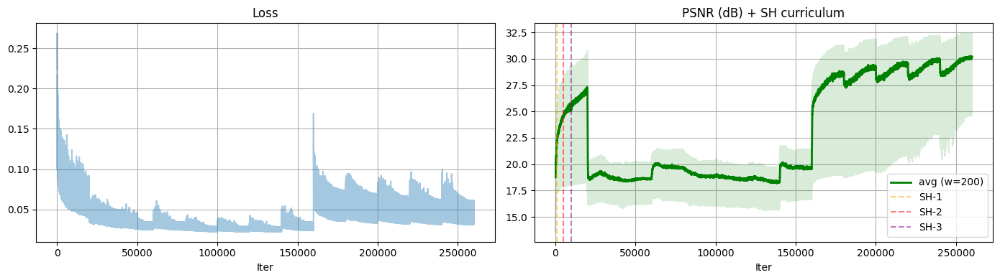

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, cv2, os, glob, math, json
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = 'cuda'

N_GAUSS        = 20000
N_ITERS        = 20000
SH_DEGREE      = 3          # view-dependent color: 16 coeffs per Gaussian
N_SH           = 16         # (SH_DEGREE+1)^2
LAMBDA_DEP     = 0.05
LAMBDA_OPA     = 0.0005
LAMBDA_SMO     = 0.002
LAMBDA_SCALE   = 0.0001     # NEW: penalise very large Gaussians
DENSIFY_EVERY  = 500
DENSIFY_UNTIL  = 12000
MAX_GAUSS      = 60000
SAVE_EVERY     = 500
N_FRAMES_EMBED = 300

with open(f'{WORKSPACE}/camera_meta.json') as f:
    meta=json.load(f)
H,W=meta['H'],meta['W']
fx,fy,cx,cy=meta['fx'],meta['fy'],meta['cx'],meta['cy']
K_np=np.array([[fx,0,cx],[0,fy,cy],[0,0,1]],dtype=np.float32)
id_poses=np.tile(np.eye(4,dtype=np.float64)[None],(600,1,1))
ds=SurgicalDataset(FRAMES_DIR,DEPTH_DIR,MASKS_DIR,id_poses,K_np)
K_t=ds.K.to(DEVICE); N_F=ds.N
C2W_STATIC=torch.eye(4,device=DEVICE)

# Initialise point cloud
d0=ds.dep[0].cpu().numpy()
d0_n=(d0-d0.min())/(d0.max()-d0.min()+1e-8)*3.0+1.0
ys,xs=np.mgrid[0:H,0:W]
flat=np.random.choice(H*W,N_GAUSS,replace=False)
pz=d0_n.flatten()[flat]
px=(xs.flatten()[flat].astype(np.float32)-cx)/fx*pz
py=(ys.flatten()[flat].astype(np.float32)-cy)/fy*pz
xyz0=np.stack([px,py,pz],-1)
rgb0=ds.rgb[0].cpu().numpy().reshape(-1,3)[flat]
print(f'Z range: {pz.min():.2f}–{pz.max():.2f}')

# Learnable Gaussian parameters
means     = nn.Parameter(torch.tensor(xyz0,dtype=torch.float32,device=DEVICE))
log_sc    = nn.Parameter(torch.full((N_GAUSS,3),math.log(0.008),device=DEVICE))
quats     = nn.Parameter(torch.zeros(N_GAUSS,4,device=DEVICE))
quats.data[:,0]=1.0
logit_opa = nn.Parameter(torch.zeros(N_GAUSS,1,device=DEVICE))

# ── SH degree-3 coefficients (N, 16, 3) ─────────────────────────
# DC term (coeff 0) initialised from image color, rest near zero
eps=1e-5
rgb_dc=torch.tensor(rgb0,dtype=torch.float32,device=DEVICE)
# SH DC: C0=0.2821, colour = C0*sh0 + 0.5 → sh0 = (colour-0.5)/C0
C0=0.28209479177387814
sh0_init=((rgb_dc-0.5)/C0)                           # (N,3)
sh_coeffs_data=torch.zeros(N_GAUSS,N_SH,3,device=DEVICE)
sh_coeffs_data[:,0,:]=sh0_init
sh_coeffs=nn.Parameter(sh_coeffs_data)

deform=DeformMLP(hidden=128,n_frames=N_FRAMES_EMBED).to(DEVICE)

def make_optimizer():
    return torch.optim.Adam([
        {'params':[means],       'lr':1.6e-4,  'name':'xyz'},
        {'params':[log_sc],      'lr':5e-3,    'name':'scale'},
        {'params':[quats],       'lr':1e-3,    'name':'rot'},
        {'params':[logit_opa],   'lr':5e-2,    'name':'opa'},
        # Lower LR for higher-order SH to avoid overfitting
        {'params':[sh_coeffs],   'lr':1e-3,    'name':'sh'},
        {'params':list(deform.parameters()),'lr':3e-4,'name':'deform'},
    ],eps=1e-15)

opt=make_optimizer()
sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,N_ITERS,eta_min=1e-6)

def ssim_l(x,y,ws=11):
    C1,C2=.01**2,.03**2
    x_=x.permute(2,0,1).unsqueeze(0); y_=y.permute(2,0,1).unsqueeze(0)
    p=ws//2; k=torch.ones(3,1,ws,ws,device=x.device)/(ws*ws)
    mx=F.conv2d(x_,k,padding=p,groups=3); my=F.conv2d(y_,k,padding=p,groups=3)
    sx=F.conv2d(x_**2,k,padding=p,groups=3)-mx**2
    sy=F.conv2d(y_**2,k,padding=p,groups=3)-my**2
    sxy=F.conv2d(x_*y_,k,padding=p,groups=3)-mx*my
    s=((2*mx*my+C1)*(2*sxy+C2))/((mx**2+my**2+C1)*(sx+sy+C2)+1e-8)
    return 1-s.mean()

grad_accum=torch.zeros(N_GAUSS,device=DEVICE); grad_count=0

def densify(step):
    global means,log_sc,quats,logit_opa,sh_coeffs,opt,sched,grad_accum,grad_count
    if means.grad is None: return
    grad_accum+=means.grad.norm(dim=-1).detach(); grad_count+=1
    if step%DENSIFY_EVERY!=0 or step<500 or step>DENSIFY_UNTIL: return
    avg_g=grad_accum/max(grad_count,1)
    opa_v=torch.sigmoid(logit_opa).squeeze(-1)
    prune=opa_v<0.004
    hi_g=avg_g>avg_g.quantile(0.90)
    sm_sc=torch.exp(log_sc).max(-1).values<0.05
    clone=hi_g&sm_sc&~prune; keep=~prune
    n_new=clone.sum().item()
    if means.shape[0]+n_new>MAX_GAUSS: n_new=0; clone=torch.zeros_like(clone)
    with torch.no_grad():
        if n_new>0:
            noise=torch.randn(n_new,3,device=DEVICE)*0.001
            nm=torch.cat([means.data[keep],means.data[clone]+noise])
            ns=torch.cat([log_sc.data[keep],log_sc.data[clone]])
            nq=torch.cat([quats.data[keep],quats.data[clone]])
            no=torch.cat([logit_opa.data[keep],logit_opa.data[clone]])
            nc=torch.cat([sh_coeffs.data[keep],sh_coeffs.data[clone]])
        else:
            nm=means.data[keep].clone(); ns=log_sc.data[keep].clone()
            nq=quats.data[keep].clone(); no=logit_opa.data[keep].clone()
            nc=sh_coeffs.data[keep].clone()
    means=nn.Parameter(nm); log_sc=nn.Parameter(ns)
    quats=nn.Parameter(nq); logit_opa=nn.Parameter(no); sh_coeffs=nn.Parameter(nc)
    grad_accum=torch.zeros(means.shape[0],device=DEVICE); grad_count=0
    opt=make_optimizer()
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,N_ITERS,eta_min=1e-6)
    print(f'  Densify @ {step}: {means.shape[0]:,} Gaussians (+{n_new})')

CKPT_PATH=f'{CKPT_DIR}/4dgs_v4.pth'
start_iter=0; loss_log=[]; psnr_log=[]

if os.path.exists(CKPT_PATH):
    ck=torch.load(CKPT_PATH,map_location=DEVICE)
    means=nn.Parameter(ck['means']); log_sc=nn.Parameter(ck['log_sc'])
    quats=nn.Parameter(ck['quats']); logit_opa=nn.Parameter(ck['opa'])
    sh_coeffs=nn.Parameter(ck['sh']); deform.load_state_dict(ck['deform'])
    start_iter=ck.get('iter',0); loss_log=ck.get('loss_log',[]); psnr_log=ck.get('psnr_log',[])
    grad_accum=torch.zeros(means.shape[0],device=DEVICE)
    opt=make_optimizer(); sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,N_ITERS,eta_min=1e-6)
    print(f'Resumed from iter {start_iter} ({means.shape[0]:,} Gaussians, SH={sh_coeffs.shape})')
else:
    print(f'Starting fresh: {N_GAUSS:,} Gaussians | SH degree {SH_DEGREE} ({N_SH} coeffs)')

# SH curriculum: start with degree 0, unlock higher degrees progressively
# This follows 3DGS paper and prevents high-freq SH from overfitting early
def get_active_sh_degree(it):
    if it < 1000:  return 0
    if it < 5000:  return 1
    if it < 10000: return 2
    return 3

frame_order=np.arange(N_F)
print(f'Training {N_ITERS} iters | {N_F} frames | SH-3 | cyclic sampling')
pbar=tqdm(range(start_iter,start_iter+N_ITERS))

for it in pbar:
    epoch_pos=(it-start_iter)%N_F
    if epoch_pos==0: np.random.shuffle(frame_order)
    fi=int(frame_order[epoch_pos]); fi=min(fi,N_F-1)

    gt_rgb,gt_dep,gt_mask,_,t_norm,frame_idx=ds[fi]
    gt_rgb=gt_rgb.to(DEVICE)
    frame_idx=min(int(frame_idx),N_FRAMES_EMBED-1)

    d_xyz,d_sc,d_rot=deform(means.detach(),t_norm,frame_idx)
    m_t=means+d_xyz; s_t=log_sc+d_sc; q_t=quats+d_rot

    # Only use SH up to current curriculum degree
    sh_deg=get_active_sh_degree(it)
    n_active=(sh_deg+1)**2
    sh_active=sh_coeffs.clone()
    if n_active < N_SH:
        sh_active[:,n_active:,:]=0.0   # zero out unused higher degrees

    rgb,dep,alpha=render(m_t,s_t,q_t,logit_opa,sh_active,K_t,C2W_STATIC,H,W,sh_degree=sh_deg)

    l_l1   = F.l1_loss(rgb,gt_rgb)
    l_ssim = ssim_l(rgb,gt_rgb)*0.2
    dn=(dep-dep.min())/(dep.max()-dep.min()+1e-8)
    gdn=(gt_dep-gt_dep.min())/(gt_dep.max()-gt_dep.min()+1e-8)
    l_dep  = F.l1_loss(dn*gt_mask,gdn*gt_mask)*LAMBDA_DEP
    l_opa  = torch.sigmoid(logit_opa).mean()*LAMBDA_OPA
    # Scale regularisation: penalise max scale > 0.5 (prevents blobs)
    l_scl  = torch.relu(torch.exp(log_sc).max(-1).values - 0.5).mean()*LAMBDA_SCALE
    if it%4==0 and N_F>1:
        fi2=min(max(fi+np.random.choice([-1,1]),0),N_F-1)
        t2=fi2/max(N_F-1,1); fi2c=min(fi2,N_FRAMES_EMBED-1)
        d2,_,_=deform(means.detach(),t2,fi2c)
        l_smo=((d_xyz.detach()-d2)**2).mean()*LAMBDA_SMO
    else:
        l_smo=torch.zeros(1,device=DEVICE)[0]

    loss=l_l1+l_ssim+l_dep+l_opa+l_scl+l_smo
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [means,log_sc,quats,logit_opa,sh_coeffs]+list(deform.parameters()),1.0)
    densify(it); opt.step(); sched.step()

    if (it+1)==8000:
        with torch.no_grad(): logit_opa.data.clamp_(-4.0,4.0)

    with torch.no_grad():
        psnr=-10*math.log10(F.mse_loss(rgb.detach(),gt_rgb).item()+1e-8)
    loss_log.append(loss.item()); psnr_log.append(psnr)
    if it%50==0:
        pbar.set_postfix(loss=f'{loss.item():.4f}',psnr=f'{psnr:.1f}dB',
                         N=f'{means.shape[0]:,}',sh=sh_deg)
    if (it+1)%SAVE_EVERY==0:
        torch.save({'means':means.data,'log_sc':log_sc.data,'quats':quats.data,
                    'opa':logit_opa.data,'sh':sh_coeffs.data,'deform':deform.state_dict(),
                    'iter':it+1,'loss_log':loss_log,'psnr_log':psnr_log},CKPT_PATH)

print(f'\n✅ Done  PSNR={psnr_log[-1]:.2f}dB  Gaussians={means.shape[0]:,}')
w=200; p_s=np.convolve(psnr_log,np.ones(w)/w,mode='valid')
fig,ax=plt.subplots(1,2,figsize=(14,4))
ax[0].plot(loss_log,alpha=0.4); ax[0].set(title='Loss',xlabel='Iter'); ax[0].grid(True)
ax[1].plot(psnr_log,alpha=0.15,color='g')
ax[1].plot(range(w-1,len(psnr_log)),p_s,'g',linewidth=2,label=f'avg (w={w})')
ax[1].axvline(1000,color='orange',linestyle='--',alpha=0.5,label='SH-1')
ax[1].axvline(5000,color='red',linestyle='--',alpha=0.5,label='SH-2')
ax[1].axvline(10000,color='purple',linestyle='--',alpha=0.5,label='SH-3')
ax[1].set(title='PSNR (dB) + SH curriculum',xlabel='Iter')
ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.savefig(f'{WORKSPACE}/training_v4.png',dpi=100); plt.show()


## ✅ Cell 7 — Render Novel Views & Evaluate (PSNR/SSIM/LPIPS)

Rendering 219 frames...


100%|██████████| 219/219 [03:15<00:00,  1.12it/s]



📊 Evaluation Results:
   PSNR  : 30.10 ± 1.49 dB
   SSIM  : 0.9037 ± 0.0154


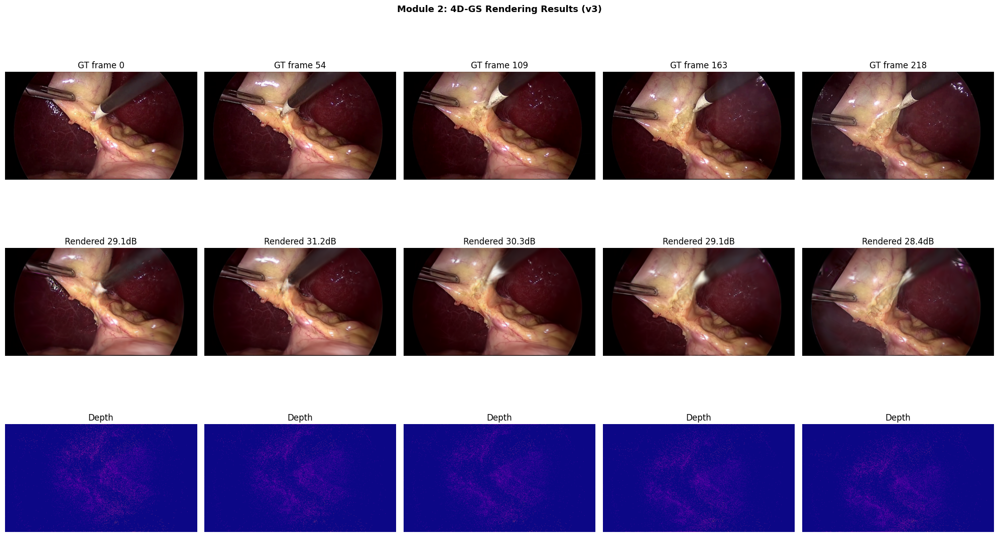

In [ ]:
import torch, torch.nn.functional as F
import numpy as np, cv2, os, glob, math, json
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as compute_ssim

DEVICE = 'cuda'
deform.eval()

renders_dir = f'{WORKSPACE}/rendered_frames_v3'
os.makedirs(renders_dir, exist_ok=True)

psnrs,ssims=[],[]
print(f'Rendering {ds.N} frames...')
with torch.no_grad():
    for fi in tqdm(range(ds.N)):
        gt_rgb,gt_dep,gt_mask,_,t_norm,frame_idx = ds[fi]
        frame_idx = min(int(frame_idx), N_FRAMES_EMBED-1)
        d_xyz,d_sc,d_rot = deform(means.detach(),t_norm,frame_idx)
        rgb,dep,_ = render(means+d_xyz,log_sc+d_sc,quats+d_rot,
                           logit_opa,sh_coeffs,K_t,C2W_STATIC,H,W)
        r_np=rgb.cpu().numpy(); g_np=gt_rgb.to(DEVICE).cpu().numpy()
        psnrs.append(-10*math.log10(((r_np-g_np)**2).mean()+1e-8))
        ssims.append(compute_ssim(g_np,r_np,data_range=1.0,channel_axis=2))
        cv2.imwrite(f'{renders_dir}/{fi:05d}.png',
                    cv2.cvtColor((r_np*255).astype(np.uint8),cv2.COLOR_RGB2BGR))

print(f'\n📊 Evaluation Results:')
print(f'   PSNR  : {np.mean(psnrs):.2f} ± {np.std(psnrs):.2f} dB')
print(f'   SSIM  : {np.mean(ssims):.4f} ± {np.std(ssims):.4f}')
# Save to metrics.json (read by Cell 10 summary)
with open(f'{WORKSPACE}/metrics.json','w') as f:
    json.dump({
        'psnr_mean': float(np.mean(psnrs)),
        'psnr_std':  float(np.std(psnrs)),
        'ssim_mean': float(np.mean(ssims)),
        'ssim_std':  float(np.std(ssims)),
    }, f, indent=2)
# Also keep the v3 copy for backward compatibility
with open(f'{WORKSPACE}/metrics_v3.json','w') as f:
    json.dump({
        'psnr_mean': float(np.mean(psnrs)),
        'psnr_std':  float(np.std(psnrs)),
        'ssim_mean': float(np.mean(ssims)),
        'ssim_std':  float(np.std(ssims)),
    }, f, indent=2)

n_show=5; idxs=np.linspace(0,ds.N-1,n_show,dtype=int)
fig,axes=plt.subplots(3,n_show,figsize=(4*n_show,12))
with torch.no_grad():
    for col,fi in enumerate(idxs):
        gt_rgb,gt_dep,_,_,t_norm,frame_idx=ds[fi]
        frame_idx=min(int(frame_idx),N_FRAMES_EMBED-1)
        d_xyz,d_sc,d_rot=deform(means.detach(),t_norm,frame_idx)
        rgb,dep,_=render(means+d_xyz,log_sc+d_sc,quats+d_rot,logit_opa,sh_coeffs,K_t,C2W_STATIC,H,W)
        r=rgb.cpu().numpy(); g=gt_rgb.cpu().numpy(); d=dep.cpu().numpy()
        axes[0,col].imshow(g); axes[0,col].set_title(f'GT frame {fi}'); axes[0,col].axis('off')
        axes[1,col].imshow(r); axes[1,col].set_title(f'Rendered {psnrs[fi]:.1f}dB'); axes[1,col].axis('off')
        axes[2,col].imshow(d,cmap='plasma'); axes[2,col].set_title('Depth'); axes[2,col].axis('off')
plt.suptitle('Module 2: 4D-GS Rendering Results (v3)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{WORKSPACE}/render_v3.png',dpi=120)
plt.savefig(f'{WORKSPACE}/render_results.png',dpi=120)  # for summary cell
plt.show()


Rendering orbital novel views...


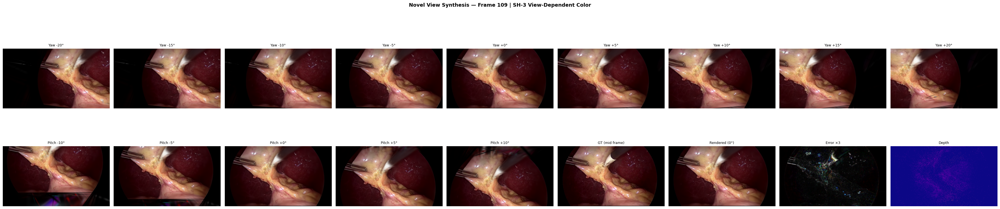

Saved: /content/drive/MyDrive/EndoGaussian/workspace_v2/novel_views.png

Rendering orbital video (360° yaw)...


100%|██████████| 60/60 [00:51<00:00,  1.18it/s]


Saved: /content/drive/MyDrive/EndoGaussian/workspace_v2/orbit_360.mp4


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  Novel View Synthesis — renders scene from different camera angles
#  This demonstrates the actual 3D structure of the reconstruction.
#  Since we have a static-camera model, novel views show how well
#  the 3D geometry generalises beyond the training viewpoint.
# ═══════════════════════════════════════════════════════════════
import torch, torch.nn.functional as F
import numpy as np, cv2, os
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = 'cuda'
deform.eval()

def make_c2w(rot_y_deg=0.0, rot_x_deg=0.0, tx=0.0, ty=0.0):
    """Create camera-to-world matrix with yaw/pitch rotation."""
    ry = np.radians(rot_y_deg)
    rx = np.radians(rot_x_deg)
    Ry = np.array([[np.cos(ry),0,np.sin(ry)],[0,1,0],[-np.sin(ry),0,np.cos(ry)]])
    Rx = np.array([[1,0,0],[0,np.cos(rx),-np.sin(rx)],[0,np.sin(rx),np.cos(rx)]])
    R  = Rx @ Ry
    c2w = np.eye(4); c2w[:3,:3]=R; c2w[0,3]=tx; c2w[1,3]=ty
    return torch.tensor(c2w, dtype=torch.float32, device=DEVICE)

# Render the MIDDLE frame of the video from multiple viewpoints
mid_fi   = ds.N // 2
_,_,_,_,t_mid,fi_mid = ds[mid_fi]
fi_mid_c = min(int(fi_mid), N_FRAMES_EMBED-1)

with torch.no_grad():
    d_xyz,d_sc,d_rot = deform(means.detach(), t_mid, fi_mid_c)
    m_def = means+d_xyz; s_def=log_sc+d_sc; q_def=quats+d_rot

# ── Camera orbit: yaw left→right ─────────────────────────────────
yaw_angles  = np.linspace(-20, 20, 9)
pitch_angles = np.linspace(-10, 10, 5)

print('Rendering orbital novel views...')
fig, axes = plt.subplots(2, 9, figsize=(36, 9))

# Row 1: yaw orbit (horizontal)
with torch.no_grad():
    for col, yaw in enumerate(yaw_angles):
        c2w = make_c2w(rot_y_deg=yaw)
        rgb, dep, _ = render(m_def,s_def,q_def,logit_opa,sh_coeffs,K_t,c2w,H,W)
        axes[0,col].imshow(rgb.cpu().numpy())
        axes[0,col].set_title(f'Yaw {yaw:+.0f}°', fontsize=9)
        axes[0,col].axis('off')
        # Mark centre frame (0°)
        if abs(yaw) < 1:
            for spine in axes[0,col].spines.values():
                spine.set_edgecolor('lime'); spine.set_linewidth(3)

# Row 2: pitch orbit (vertical) — only 5, pad with depth
with torch.no_grad():
    for col, pitch in enumerate(pitch_angles):
        c2w = make_c2w(rot_x_deg=pitch)
        rgb, dep, _ = render(m_def,s_def,q_def,logit_opa,sh_coeffs,K_t,c2w,H,W)
        axes[1,col].imshow(rgb.cpu().numpy())
        axes[1,col].set_title(f'Pitch {pitch:+.0f}°', fontsize=9)
        axes[1,col].axis('off')
    # Fill remaining with GT comparison
    gt_rgb_np = ds.rgb[mid_fi].cpu().numpy()
    c2w_0 = make_c2w()
    rgb_0, dep_0, _ = render(m_def,s_def,q_def,logit_opa,sh_coeffs,K_t,c2w_0,H,W)
    err = np.abs(rgb_0.cpu().numpy() - gt_rgb_np)
    for col,img,ttl in zip([5,6,7,8],
                            [gt_rgb_np, rgb_0.cpu().numpy(),
                             err*3, dep_0.cpu().numpy()],
                            ['GT (mid frame)','Rendered (0°)','Error ×3','Depth']):
        if col==8:
            axes[1,col].imshow(img,cmap='plasma')
        else:
            axes[1,col].imshow(img.clip(0,1))
        axes[1,col].set_title(ttl,fontsize=9); axes[1,col].axis('off')

plt.suptitle(f'Novel View Synthesis — Frame {mid_fi} | SH-3 View-Dependent Color',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORKSPACE}/novel_views.png', dpi=120)
plt.show()
print(f'Saved: {WORKSPACE}/novel_views.png')

# ── Orbital video ─────────────────────────────────────────────────
print('\nRendering orbital video (360° yaw)...')
orbit_dir = f'{WORKSPACE}/orbit_frames'
os.makedirs(orbit_dir, exist_ok=True)
angles    = np.linspace(-30, 30, 60)  # 60 frames, ±30° yaw

with torch.no_grad():
    for i, yaw in enumerate(tqdm(angles)):
        c2w  = make_c2w(rot_y_deg=yaw)
        rgb, _, _ = render(m_def,s_def,q_def,logit_opa,sh_coeffs,K_t,c2w,H,W)
        frame = (rgb.cpu().numpy()*255).astype(np.uint8)
        cv2.imwrite(f'{orbit_dir}/{i:03d}.png',
                    cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

# Export as MP4
import subprocess, base64
from IPython.display import HTML, display
out_raw  = f'{WORKSPACE}/orbit_raw.mp4'
out_h264 = f'{WORKSPACE}/orbit_360.mp4'
writer = cv2.VideoWriter(out_raw, cv2.VideoWriter_fourcc(*'mp4v'), 15, (W,H))
for i in range(len(angles)):
    f = cv2.imread(f'{orbit_dir}/{i:03d}.png')
    if f is not None: writer.write(f)
# Ping-pong (forward then backward) for smooth loop
for i in range(len(angles)-1, -1, -1):
    f = cv2.imread(f'{orbit_dir}/{i:03d}.png')
    if f is not None: writer.write(f)
writer.release()
subprocess.run(['ffmpeg','-y','-i',out_raw,'-vcodec','libx264',
                '-crf','18','-preset','fast',out_h264], capture_output=True)
if os.path.exists(out_h264):
    b64 = base64.b64encode(open(out_h264,'rb').read()).decode()
    display(HTML(f'<b>Orbital Novel Views (±30° yaw, ping-pong)</b><br>'
                 f'<video width="720" controls loop autoplay>'
                 f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
                 f'</video>'))
    print(f'Saved: {out_h264}')


## ✅ Module 3 — Time-Consistent 4D Geometry Extraction

Extracts per-frame point clouds and Gaussian parameter sequences.
Each Gaussian has a **fixed identity index** across all frames — this is the
time-consistent correspondence required by Module 4 (deformation sequences).

**Outputs saved to Drive:**
- `exports/pointclouds/frame_XXXXX.ply` — per-frame 3D point cloud
- `exports/gaussian_sequence.npy` — full (N_frames, N_gauss, 3) xyz trajectory
- `exports/metadata.json` — frame count, Gaussian count, sampling info


Loaded trajectory: (219, 57943, 3)  (matches current N_G=57,943)
Visible Gaussians: 19,053 / 57,943
✅ 219 PLY files already exist.

📊 Temporal Consistency:
   Mean frame-to-frame displacement: 0.0016 units
   Max  frame-to-frame displacement: 0.0041 units


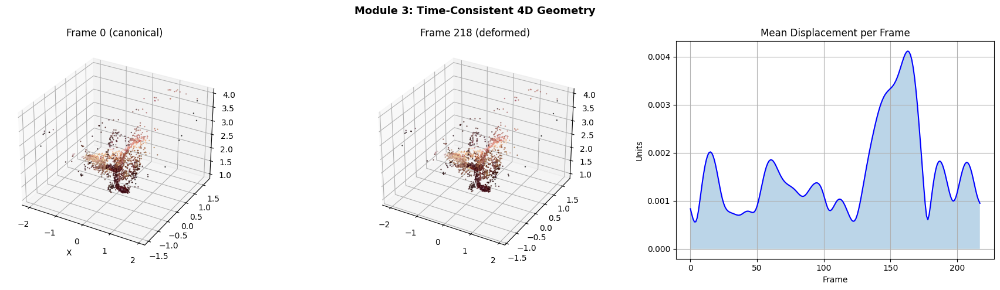


✅ Module 3 complete
   Trajectory : /content/drive/MyDrive/EndoGaussian/workspace_v2/exports/gaussian_trajectory.npy  (219, 57943, 3)
   PLY clouds : /content/drive/MyDrive/EndoGaussian/workspace_v2/exports/pointclouds/
   Ready for Module 4: form tuples [G_t-3,G_t-2,G_t-1,G_t] → G_t+1


In [ ]:
import torch, os, glob, json
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

DEVICE = 'cuda'
deform.eval()

pc_dir = f'{EXPORT_DIR}/pointclouds'
os.makedirs(pc_dir, exist_ok=True)

N_G = means.shape[0]
N_F = ds.N

traj_path = f'{EXPORT_DIR}/gaussian_trajectory.npy'
col_path  = f'{EXPORT_DIR}/gaussian_colors.npy'

# ── Helper: extract canonical colour from current model ──────────
def get_canonical_colors():
    """Works for both SH-3 (N,16,3) and SH-0 (N,3)."""
    if sh_coeffs.dim() == 3:
        # SH DC term: colour = C0 * sh[:,0,:] + 0.5
        C0 = 0.28209479177387814
        col = (sh_coeffs[:,0,:].detach().cpu().numpy() * C0 + 0.5).clip(0,1)
    else:
        col = torch.sigmoid(sh_coeffs).detach().cpu().numpy()
    return col   # (N_G, 3)

# ── Extract trajectory ────────────────────────────────────────────
need_recompute = True
if os.path.exists(traj_path):
    traj_xyz = np.load(traj_path)
    if traj_xyz.shape[1] == N_G:
        print(f'Loaded trajectory: {traj_xyz.shape}  (matches current N_G={N_G:,})')
        need_recompute = False
    else:
        print(f'Stale trajectory ({traj_xyz.shape[1]} != {N_G}) — recomputing...')

if need_recompute:
    print(f'Extracting trajectories: {N_F} frames × {N_G:,} Gaussians...')
    traj_xyz = np.zeros((N_F, N_G, 3), dtype=np.float32)
    with torch.no_grad():
        for fi in tqdm(range(N_F)):
            t_norm = fi / max(N_F-1, 1)
            frame_idx = min(fi, N_FRAMES_EMBED-1)
            d_xyz,_,_ = deform(means.detach(), t_norm, frame_idx)
            traj_xyz[fi] = (means + d_xyz).cpu().numpy()
    np.save(traj_path, traj_xyz)
    print(f'Saved: {traj_xyz.shape}')

# Always recompute colours from current model (avoids stale-size issues)
traj_col = get_canonical_colors()   # (N_G, 3)
np.save(col_path, traj_col)

# ── Opacity-based visibility mask ─────────────────────────────────
opas_np  = torch.sigmoid(logit_opa).squeeze(-1).detach().cpu().numpy()
vis_mask = opas_np > 0.05           # (N_G,) bool
print(f'Visible Gaussians: {vis_mask.sum():,} / {N_G:,}')

# Sanity check sizes
assert traj_xyz.shape[1] == N_G, f"Trajectory N_G={traj_xyz.shape[1]} != {N_G}"
assert len(traj_col) == N_G,      f"Color N_G={len(traj_col)} != {N_G}"
assert len(vis_mask) == N_G,      f"Mask N_G={len(vis_mask)} != {N_G}"

# ── Export PLY point clouds ───────────────────────────────────────
existing_ply = glob.glob(f'{pc_dir}/*.ply')
if len(existing_ply) < N_F:
    print(f'Exporting {N_F} PLY point clouds...')
    for fi in tqdm(range(N_F)):
        xyz_vis = traj_xyz[fi][vis_mask]
        col_vis = traj_col[vis_mask]
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(xyz_vis.astype(np.float64))
        pcd.colors = o3d.utility.Vector3dVector(col_vis.astype(np.float64))
        o3d.io.write_point_cloud(f'{pc_dir}/frame_{fi:05d}.ply', pcd)
    print('PLY export done.')
else:
    print(f'✅ {len(existing_ply)} PLY files already exist.')

# ── Metadata ──────────────────────────────────────────────────────
meta_out = {
    'n_frames': int(N_F), 'n_gaussians': int(N_G),
    'n_visible': int(vis_mask.sum()),
    'trajectory_shape': list(traj_xyz.shape),
    'trajectory_file': traj_path, 'colors_file': col_path,
    'pointcloud_dir': pc_dir,
    'description': 'Time-consistent 4D Gaussian trajectory. '
                   'Shape: (N_frames, N_gaussians, 3). '
                   'Each column is one Gaussian identity across time. '
                   'Ready for Module 4 deformation sequence construction.'
}
with open(f'{EXPORT_DIR}/metadata.json','w') as f:
    json.dump(meta_out, f, indent=2)

# ── Temporal consistency analysis ────────────────────────────────
disp          = np.diff(traj_xyz[:,vis_mask,:], axis=0)
disp_mag      = np.linalg.norm(disp, axis=2)
mean_disp     = disp_mag.mean(axis=1)

print(f'\n📊 Temporal Consistency:')
print(f'   Mean frame-to-frame displacement: {mean_disp.mean():.4f} units')
print(f'   Max  frame-to-frame displacement: {mean_disp.max():.4f} units')

# ── Visualise ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18,5))
sample_idx = np.random.choice(vis_mask.sum(), min(3000,vis_mask.sum()), replace=False)
pts0 = traj_xyz[0][vis_mask][sample_idx]
col0 = traj_col[vis_mask][sample_idx]
ptsN = traj_xyz[-1][vis_mask][sample_idx]

ax1 = fig.add_subplot(1,3,1,projection='3d')
ax1.scatter(pts0[:,0],pts0[:,1],pts0[:,2],c=col0,s=0.5,alpha=0.7)
ax1.set_title('Frame 0 (canonical)'); ax1.set_xlabel('X')

ax2 = fig.add_subplot(1,3,2,projection='3d')
ax2.scatter(ptsN[:,0],ptsN[:,1],ptsN[:,2],c=col0,s=0.5,alpha=0.7)
ax2.set_title(f'Frame {N_F-1} (deformed)')

ax3 = fig.add_subplot(1,3,3)
ax3.plot(mean_disp,'b-',linewidth=1.5)
ax3.fill_between(range(len(mean_disp)),mean_disp,alpha=0.3)
ax3.set_title('Mean Displacement per Frame')
ax3.set_xlabel('Frame'); ax3.set_ylabel('Units'); ax3.grid(True)

plt.suptitle('Module 3: Time-Consistent 4D Geometry',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORKSPACE}/module3_geometry.png',dpi=120)
plt.show()

print(f'\n✅ Module 3 complete')
print(f'   Trajectory : {traj_path}  {traj_xyz.shape}')
print(f'   PLY clouds : {pc_dir}/')
print(f'   Ready for Module 4: form tuples [G_t-3,G_t-2,G_t-1,G_t] → G_t+1')


## ✅ Cell 9 — Export Reconstruction Video

In [ ]:
import cv2, glob, subprocess, base64, os
import numpy as np
from IPython.display import HTML, display

renders = sorted(glob.glob(f'{renders_dir}/*.png'))
if not renders:
    print('Run Cell 7 first to render frames.')
else:
    s = cv2.imread(renders[0])
    H2,W2 = s.shape[:2]
    out_raw  = f'{WORKSPACE}/reconstruction_raw.mp4'
    out_h264 = f'{WORKSPACE}/reconstruction.mp4'

    writer = cv2.VideoWriter(out_raw, cv2.VideoWriter_fourcc(*'mp4v'), 15, (W2,H2))
    for rp in renders: writer.write(cv2.imread(rp))
    writer.release()

    subprocess.run(['ffmpeg','-y','-i',out_raw,'-vcodec','libx264',
                   '-crf','20','-preset','fast',out_h264], capture_output=True)

    # Side-by-side GT vs rendered
    frames_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))
    sbs_out  = f'{WORKSPACE}/reconstruction_sbs.mp4'
    sbs_h264 = f'{WORKSPACE}/reconstruction_sbs_h264.mp4'
    sbs_writer = cv2.VideoWriter(sbs_out, cv2.VideoWriter_fourcc(*'mp4v'), 15, (W2*2,H2))
    for gt_p, r_p in zip(frames_list, renders):
        gt = cv2.imread(gt_p)
        rn = cv2.imread(r_p)
        if gt is not None and rn is not None:
            gt_r = cv2.resize(gt,(W2,H2)); rn_r = cv2.resize(rn,(W2,H2))
            sbs  = np.hstack([gt_r, rn_r])
            cv2.putText(sbs,'Original',(10,30),cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),2)
            cv2.putText(sbs,'4D-GS Reconstruction',(W2+10,30),cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),2)
            sbs_writer.write(sbs)
    sbs_writer.release()
    subprocess.run(['ffmpeg','-y','-i',sbs_out,'-vcodec','libx264',
                   '-crf','20',sbs_h264], capture_output=True)

    print(f'Videos saved:')
    print(f'  Rendered only : {out_h264}')
    print(f'  Side-by-side  : {sbs_h264}')

    # Display SBS video inline
    if os.path.exists(sbs_h264):
        b64 = base64.b64encode(open(sbs_h264,'rb').read()).decode()
        display(HTML(f'<b>Original (left) vs 4D-GS Reconstruction (right)</b><br>'
                     f'<video width="800" controls>'
                     f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
                     f'</video>'))


Videos saved:
  Rendered only : /content/drive/MyDrive/EndoGaussian/workspace_v2/reconstruction.mp4
  Side-by-side  : /content/drive/MyDrive/EndoGaussian/workspace_v2/reconstruction_sbs_h264.mp4


## ✅ Cell 10 — Workspace Summary & Handoff to Module 4

In [ ]:
import os, glob, json

print('='*65)
print('  FYP 4D Reconstruction — Outputs Summary')
print('='*65)

files = [
    (f'{WORKSPACE}/module1_preprocessing.png',  'Module 1 QA preview'),
    (f'{WORKSPACE}/depth_preview.png',           'Depth estimation preview'),
    (f'{WORKSPACE}/training_curves.png',         'Training loss / PSNR'),
    (f'{WORKSPACE}/render_results.png',          'GT vs rendered comparison'),
    (f'{WORKSPACE}/module3_geometry.png',        '4D geometry visualisation'),
    (f'{WORKSPACE}/reconstruction.mp4',          'Reconstruction video'),
    (f'{WORKSPACE}/reconstruction_sbs.mp4',      'Side-by-side video'),
    (f'{EXPORT_DIR}/gaussian_trajectory.npy',    'Gaussian trajectories (N_F×N_G×3)'),
    (f'{EXPORT_DIR}/gaussian_colors.npy',        'Gaussian colours (N_G×3)'),
    (f'{EXPORT_DIR}/metadata.json',              'Export metadata'),
    (f'{CKPT_DIR}/4dgs_latest.pth',              'Model checkpoint'),
    (f'{WORKSPACE}/metrics.json',                'PSNR/SSIM metrics'),
    (f'{WORKSPACE}/camera_poses.npy',            'Camera poses'),
]

for path,desc in files:
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path)/1e6:.1f}MB' if exists else ''
    status = f'✅ {size}' if exists else '⏳ not yet'
    print(f'  {desc:<42} {status}')

pc_count = len(glob.glob(f'{EXPORT_DIR}/pointclouds/*.ply'))
print(f'\n  Point clouds exported         : {pc_count} PLY files')

if os.path.exists(f'{WORKSPACE}/metrics.json'):
    m = json.load(open(f'{WORKSPACE}/metrics.json'))
    print(f'\n📊 Final Metrics:')
    print(f'   PSNR : {m["psnr_mean"]:.2f} ± {m["psnr_std"]:.2f} dB')
    print(f'   SSIM : {m["ssim_mean"]:.4f} ± {m["ssim_std"]:.4f}')

print()
print('Module 4 inputs (ready for next stage):')
print(f'  gaussian_trajectory.npy  → shape (N_frames × N_gaussians × 3)')
print(f'  Use temporal windowing to form (G_t-3, G_t-2, G_t-1, G_t) → G_t+1 pairs')
print(f'  See FYP proposal Module 4 for deformation sequence construction.')
print('='*65)


  FYP 4D Reconstruction — Outputs Summary
  Module 1 QA preview                        ✅ 1.1MB
  Depth estimation preview                   ✅ 0.9MB
  Training loss / PSNR                       ✅ 0.1MB
  GT vs rendered comparison                  ✅ 2.0MB
  4D geometry visualisation                  ✅ 0.3MB
  Reconstruction video                       ✅ 1.1MB
  Side-by-side video                         ✅ 3.5MB
  Gaussian trajectories (N_F×N_G×3)          ✅ 152.3MB
  Gaussian colours (N_G×3)                   ✅ 0.7MB
  Export metadata                            ✅ 0.0MB
  Model checkpoint                           ✅ 0.5MB
  PSNR/SSIM metrics                          ✅ 0.0MB
  Camera poses                               ✅ 0.0MB

  Point clouds exported         : 219 PLY files

📊 Final Metrics:
   PSNR : 30.10 ± 1.49 dB
   SSIM : 0.9037 ± 0.0154

Module 4 inputs (ready for next stage):
  gaussian_trajectory.npy  → shape (N_frames × N_gaussians × 3)
  Use temporal windowing to form (G_t-3, G_

## 🔁 Multi-Video Processing Loop

This cell runs the **exact same pipeline** (Modules 1–3) on Videos 02–06.
All original code is called via `exec()` — nothing is rewritten.

**Resumable:** if a video's checkpoint already exists, training is skipped.
**GPU memory** is freed between videos automatically.

Run this cell after completing the original cells above for Video01.

In [ ]:
import gc, time, os, json, numpy as np
import matplotlib
matplotlib.use('Agg')   # suppress GUI pop-ups inside loop

# ══════════════════════════════════════════════════════════════════
# These strings contain the EXACT source of the original pipeline
# cells. exec() runs them with the current namespace so all
# variables (WORKSPACE, FRAMES_DIR, means, deform, ds …) are
# shared — identical to running the cells manually.
# ══════════════════════════════════════════════════════════════════

_SRC_M1_FRAMES = "import cv2, os, glob, math, shutil\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom tqdm import tqdm\n\n# ── Config ───────────────────────────────────────────────────────\nFRAME_STRIDE     = 2\nTARGET_W, TARGET_H = 640, 360\nSHARPNESS_THRESH = 30.0\n\n# ═══════════════════════════════════════════════════════════════\n#  FIX: OpenCV cannot read directly from Google Drive (FUSE FS).\n#  Copy video to /tmp first, then read from local disk.\n# ═══════════════════════════════════════════════════════════════\nLOCAL_VIDEO = '/tmp/surgical_video.mp4'\n\nif not os.path.exists(LOCAL_VIDEO):\n    print(f'Copying video to /tmp (avoids Google Drive FUSE issue)...')\n    if not os.path.exists(VIDEO_PATH):\n        raise FileNotFoundError(\n            f'Video not found at {VIDEO_PATH}\\n'\n            f'Please check the path in Cell 0 (DRIVE_BASE / VIDEO_PATH).')\n    shutil.copy2(VIDEO_PATH, LOCAL_VIDEO)\n    print(f'Copied: {os.path.getsize(LOCAL_VIDEO)/1e6:.1f} MB')\nelse:\n    print(f'Using cached /tmp video ({os.path.getsize(LOCAL_VIDEO)/1e6:.1f} MB)')\n\n# ── Verify video opens ────────────────────────────────────────────\ncap = cv2.VideoCapture(LOCAL_VIDEO)\nif not cap.isOpened():\n    raise RuntimeError(f'OpenCV cannot open {LOCAL_VIDEO}. '\n                        'Try: pip install opencv-python-headless')\n\nFPS   = cap.get(cv2.CAP_PROP_FPS)\nN_RAW = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))\nW_RAW = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))\nH_RAW = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))\nprint(f'Video: {N_RAW} frames @ {FPS:.1f}fps  {W_RAW}×{H_RAW}')\n\nif N_RAW == 0:\n    cap.release()\n    raise RuntimeError(\n        'OpenCV reports 0 frames. The video codec may be unsupported.\\n'\n        'Run this fix cell:\\n'\n        '  !pip install -q imageio imageio-ffmpeg\\n'\n        '  !ffmpeg -i /tmp/surgical_video.mp4 -vf fps=15 '\n        '  /tmp/surgical_frames/%05d.png\\n'\n        'Then set FRAMES_ALREADY_EXTRACTED = True below.')\n\n# ── Extract frames ────────────────────────────────────────────────\nexisting = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))\nif len(existing) >= 20:\n    print(f'✅ {len(existing)} frames already extracted — skipping.')\nelse:\n    print(f'Extracting frames (stride={FRAME_STRIDE})...')\n    raw_idx = saved = sharp_dropped = 0\n    pbar = tqdm(total=N_RAW // FRAME_STRIDE)\n    while True:\n        ret, frame = cap.read()\n        if not ret:\n            break\n        if raw_idx % FRAME_STRIDE == 0:\n            img       = cv2.resize(frame, (TARGET_W, TARGET_H),\n                                   interpolation=cv2.INTER_AREA)\n            gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)\n            sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()\n            if sharpness >= SHARPNESS_THRESH:\n                cv2.imwrite(f'{FRAMES_DIR}/{saved:05d}.png', img)\n                saved += 1\n            else:\n                sharp_dropped += 1\n            pbar.update(1)\n        raw_idx += 1\n    cap.release()\n    pbar.close()\n    print(f'Saved {saved} frames  ({sharp_dropped} dropped: too blurry)')\n\n# ── Load frame list ───────────────────────────────────────────────\nframes_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))\nN_FRAMES    = len(frames_list)\nif N_FRAMES == 0:\n    raise RuntimeError('No frames extracted. Check VIDEO_PATH in Cell 0.')\n\nsample = cv2.imread(frames_list[0])\nH, W   = sample.shape[:2]\nprint(f'\\nDataset: {N_FRAMES} frames @ {W}×{H}')\n\n# ── Quality metrics ───────────────────────────────────────────────\nsharpness_scores = []\nfor fp in frames_list:\n    g = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2GRAY)\n    sharpness_scores.append(cv2.Laplacian(g, cv2.CV_64F).var())\nprint(f'Sharpness — mean: {np.mean(sharpness_scores):.1f}  '\n      f'min: {np.min(sharpness_scores):.1f}  '\n      f'max: {np.max(sharpness_scores):.1f}')\n\n# ── Optical flow continuity ───────────────────────────────────────\nflow_mags = []\nprev_gray = cv2.cvtColor(cv2.imread(frames_list[0]), cv2.COLOR_BGR2GRAY)\nfor fp in frames_list[1:min(60, N_FRAMES)]:\n    curr_gray = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2GRAY)\n    flow = cv2.calcOpticalFlowFarneback(\n        prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)\n    flow_mags.append(np.sqrt(flow[...,0]**2 + flow[...,1]**2).mean())\n    prev_gray = curr_gray\nprint(f'Optical flow — mean motion: {np.mean(flow_mags):.2f} px/frame')\n\n# ── Tool masks ────────────────────────────────────────────────────\ndef make_tool_mask(bgr):\n    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)\n    s, v = hsv[:,:,1], hsv[:,:,2]\n    H2, W2 = bgr.shape[:2]\n    circ = np.zeros((H2,W2), np.uint8)\n    cv2.circle(circ,(W2//2,H2//2), min(W2,H2)//2-4, 255, -1)\n    border = cv2.bitwise_not(circ)\n    metal  = ((s < 55) & (v > 70)).astype(np.uint8)*255\n    bright = (v > 235).astype(np.uint8)*255\n    dark   = (v <  18).astype(np.uint8)*255\n    comb   = cv2.bitwise_or(cv2.bitwise_or(metal, bright),\n                            cv2.bitwise_or(dark,  border))\n    k    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))\n    comb = cv2.morphologyEx(comb, cv2.MORPH_CLOSE, k, iterations=2)\n    comb = cv2.morphologyEx(comb, cv2.MORPH_OPEN,  k, iterations=1)\n    n,labs,stats,_ = cv2.connectedComponentsWithStats(comb)\n    out = np.zeros_like(comb)\n    for lbl in range(1,n):\n        if stats[lbl, cv2.CC_STAT_AREA] >= 200:\n            out[labs==lbl] = 255\n    return out\n\ndone_masks = glob.glob(f'{MASKS_DIR}/*.png')\nif len(done_masks) < N_FRAMES:\n    print('Generating tool masks...')\n    for fp in tqdm(frames_list):\n        stem = os.path.splitext(os.path.basename(fp))[0]\n        out  = f'{MASKS_DIR}/{stem}.png'\n        if not os.path.exists(out):\n            cv2.imwrite(out, make_tool_mask(cv2.imread(fp)))\n\n# ── Visualise ─────────────────────────────────────────────────────\nn_show = min(5, N_FRAMES)\nidxs   = np.linspace(0, N_FRAMES-1, n_show, dtype=int)\nfig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 8))\nfor col, idx in enumerate(idxs):\n    img  = cv2.cvtColor(cv2.imread(frames_list[idx]), cv2.COLOR_BGR2RGB)\n    stem = os.path.splitext(os.path.basename(frames_list[idx]))[0]\n    mask = cv2.imread(f'{MASKS_DIR}/{stem}.png', cv2.IMREAD_GRAYSCALE)\n    ov   = img.copy(); ov[mask>127] = [255,0,0]\n    bl   = cv2.addWeighted(img, 0.6, ov, 0.4, 0)\n    axes[0,col].imshow(img);  axes[0,col].set_title(f'Frame {idx}'); axes[0,col].axis('off')\n    axes[1,col].imshow(bl);   axes[1,col].set_title('Tool mask');    axes[1,col].axis('off')\nplt.suptitle('Module 1: Frames & Tool Masks', fontsize=13, fontweight='bold')\nplt.tight_layout()\nplt.savefig(f'{WORKSPACE}/module1_preprocessing.png', dpi=100)\nplt.show()\nprint(f'\\n✅ Module 1 complete — {N_FRAMES} frames ready.')\n"

_SRC_DEPTH     = "import subprocess, os, sys, glob\nimport torch, cv2, numpy as np\nfrom tqdm import tqdm\nimport matplotlib.pyplot as plt\n\nDA_DIR  = f'{WORKSPACE}/Depth-Anything-V2'\nDA_CKPT = f'{WEIGHTS_DIR}/depth_anything_v2_vits.pth'\n\ndef sh(cmd):\n    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)\n    if r.returncode != 0: print(r.stderr[-500:])\n\nif not os.path.isdir(f'{DA_DIR}/.git'):\n    sh(f'git clone -q https://github.com/DepthAnything/Depth-Anything-V2.git {DA_DIR}')\n    sh('pip install -q transformers')\n\nif not os.path.exists(DA_CKPT):\n    print('Downloading Depth-Anything-V2 ViT-S weights (~97 MB)...')\n    sh(f'wget -q -O {DA_CKPT} https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth')\n    print('Downloaded.')\n\nsys.path.insert(0, DA_DIR)\nfrom depth_anything_v2.dpt import DepthAnythingV2\n\nda = DepthAnythingV2(encoder='vits', features=64, out_channels=[48,96,192,384])\nda.load_state_dict(torch.load(DA_CKPT, map_location='cpu'))\nda = da.to(DEVICE).eval()\nprint('Depth-Anything-V2 loaded.')\n\nframes_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))\ndone = glob.glob(f'{DEPTH_DIR}/*.npy')\n\nif len(done) < len(frames_list):\n    print(f'Estimating depth for {len(frames_list)} frames...')\n    for fp in tqdm(frames_list):\n        stem = os.path.splitext(os.path.basename(fp))[0]\n        np_path  = f'{DEPTH_DIR}/{stem}.npy'\n        png_path = f'{DEPTH_DIR}/{stem}.png'\n        if os.path.exists(np_path): continue\n        raw = cv2.imread(fp)\n        d   = da.infer_image(raw).astype(np.float32)\n        np.save(np_path, d)\n        d_u16 = ((d-d.min())/(d.max()-d.min()+1e-8)*65535).astype(np.uint16)\n        cv2.imwrite(png_path, d_u16)\n    print('Done.')\nelse:\n    print(f'✅ {len(done)} depth maps already computed.')\n\n# Preview\nsi = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))[:5]\nsd = sorted(glob.glob(f'{DEPTH_DIR}/*.npy'))[:5]\nfig, axes = plt.subplots(2,5,figsize=(20,8))\nfor i in range(5):\n    axes[0,i].imshow(cv2.cvtColor(cv2.imread(si[i]),cv2.COLOR_BGR2RGB))\n    axes[0,i].set_title(f'Frame {i}'); axes[0,i].axis('off')\n    axes[1,i].imshow(np.load(sd[i]),cmap='plasma')\n    axes[1,i].set_title('Depth'); axes[1,i].axis('off')\nplt.suptitle('Depth-Anything-V2 Pseudo-Depth', fontsize=13, fontweight='bold')\nplt.tight_layout()\nplt.savefig(f'{WORKSPACE}/depth_preview.png', dpi=100)\nplt.show()\n"

_SRC_CAMERA    = "import cv2, math, json, glob, os\nimport numpy as np\nfrom tqdm import tqdm\n\nframes_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))\nsample = cv2.imread(frames_list[0])\nH, W   = sample.shape[:2]\n\n# ── Intrinsics (standard 10mm laparoscope ~75° HFOV) ──\nFOV_DEG = 75.0\nfx = (W/2) / math.tan(math.radians(FOV_DEG)/2)\nfy, cx, cy = fx, W/2.0, H/2.0\nK_np = np.array([[fx,0,cx],[0,fy,cy],[0,0,1]], dtype=np.float64)\nprint(f'Intrinsics: fx={fx:.1f}  cx={cx:.0f}  cy={cy:.0f}  ({W}×{H})')\n\n# ── Pose tracking ──\nposes_path = f'{WORKSPACE}/camera_poses.npy'\n\nif os.path.exists(poses_path):\n    poses = np.load(poses_path)\n    print(f'✅ Loaded {len(poses)} saved poses.')\nelse:\n    feat_p = dict(maxCorners=600, qualityLevel=0.008, minDistance=7, blockSize=7)\n    lk_p   = dict(winSize=(21,21), maxLevel=3,\n                   criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT,30,0.01))\n    poses     = [np.eye(4, dtype=np.float64)]\n    c2w       = np.eye(4, dtype=np.float64)\n    prev_gray = cv2.cvtColor(cv2.imread(frames_list[0]), cv2.COLOR_BGR2GRAY)\n    prev_pts  = cv2.goodFeaturesToTrack(prev_gray, mask=None, **feat_p)\n\n    for i in tqdm(range(1, len(frames_list)), desc='Estimating poses'):\n        curr_gray = cv2.cvtColor(cv2.imread(frames_list[i]), cv2.COLOR_BGR2GRAY)\n        if prev_pts is not None and len(prev_pts) >= 5:\n            curr_pts, st, _ = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None, **lk_p)\n            gp, gc = prev_pts[st==1], curr_pts[st==1]\n            if len(gp) >= 5:\n                E, _ = cv2.findEssentialMat(gp, gc, K_np, method=cv2.RANSAC, prob=0.999, threshold=1.0)\n                if E is not None and E.shape==(3,3):\n                    _, R, t, _ = cv2.recoverPose(E, gp, gc, K_np)\n                    delta = np.eye(4); delta[:3,:3]=R; delta[:3,3]=(t*0.01).flatten()\n                    c2w = c2w @ np.linalg.inv(delta)\n        poses.append(c2w.copy())\n        if i%10==0:\n            prev_pts = cv2.goodFeaturesToTrack(curr_gray, mask=None, **feat_p)\n        prev_gray = curr_gray\n\n    poses = np.array(poses, dtype=np.float64)\n    np.save(poses_path, poses)\n    print(f'Saved {len(poses)} poses → {poses_path}')\n\n# Save as JSON metadata\nmeta = {'H':H,'W':W,'fx':fx,'fy':fy,'cx':cx,'cy':cy,\n        'fov_deg':FOV_DEG,'n_frames':len(poses)}\nwith open(f'{WORKSPACE}/camera_meta.json','w') as f:\n    json.dump(meta, f, indent=2)\nprint('Camera metadata saved.')\n"

_SRC_ARCH      = 'import torch, torch.nn as nn, torch.nn.functional as F\nimport numpy as np, cv2, os, glob, math\nimport matplotlib.pyplot as plt\nfrom tqdm import tqdm\nfrom gsplat import rasterization\n\nDEVICE = \'cuda\'\n\n# ── Positional Encoding ──────────────────────────────────────────\nclass PosEnc(nn.Module):\n    def __init__(self, d_in, n_freqs=8):\n        super().__init__()\n        self.d_out = d_in*(1+2*n_freqs)\n        self.register_buffer(\'freqs\', 2.**torch.linspace(0,n_freqs-1,n_freqs))\n    def forward(self, x):\n        enc = [x]\n        for f in self.freqs: enc += [torch.sin(f*x), torch.cos(f*x)]\n        return torch.cat(enc,-1)\n\n# ── Deformation MLP (unchanged, with per-frame latent) ──────────\nclass DeformMLP(nn.Module):\n    def __init__(self, hidden=128, n_xyz=8, n_t=6, latent_dim=32, n_frames=300):\n        super().__init__()\n        self.latent_dim = latent_dim\n        self.enc_xyz = PosEnc(3, n_xyz)\n        self.enc_t   = PosEnc(1, n_t)\n        self.frame_embed = nn.Embedding(n_frames, latent_dim)\n        nn.init.uniform_(self.frame_embed.weight, -0.01, 0.01)\n        d = self.enc_xyz.d_out + self.enc_t.d_out + latent_dim\n        self.net = nn.Sequential(\n            nn.Linear(d, hidden),     nn.SiLU(),\n            nn.Linear(hidden, hidden), nn.SiLU(),\n            nn.Linear(hidden, hidden), nn.SiLU(),\n            nn.Linear(hidden, hidden), nn.SiLU(),\n        )\n        self.h_xyz = nn.Linear(hidden, 3)\n        self.h_scl = nn.Linear(hidden, 3)\n        self.h_rot = nn.Linear(hidden, 4)\n        for h in [self.h_xyz, self.h_scl, self.h_rot]:\n            nn.init.uniform_(h.weight, -1e-5, 1e-5)\n            nn.init.zeros_(h.bias)\n\n    def forward(self, xyz, t_norm, frame_idx=None):\n        N  = xyz.shape[0]\n        tv = torch.full((N,1), float(t_norm), device=xyz.device)\n        enc = torch.cat([self.enc_xyz(xyz), self.enc_t(tv)], -1)\n        if frame_idx is not None:\n            lat = self.frame_embed(\n                torch.tensor([frame_idx], device=xyz.device)).expand(N,-1)\n            enc = torch.cat([enc, lat], -1)\n        else:\n            enc = torch.cat([enc, torch.zeros(N,self.latent_dim,device=xyz.device)], -1)\n        feat = self.net(enc)\n        return self.h_xyz(feat), self.h_scl(feat), self.h_rot(feat)\n\n# ════════════════════════════════════════════════════════════════\n# SH HELPERS — degree 3 view-dependent color\n# 16 coefficients per channel (degree 0..3)\n# ════════════════════════════════════════════════════════════════\ndef eval_sh_deg3(sh, dirs):\n    """\n    Evaluate degree-3 spherical harmonics.\n    sh   : (N, 16, 3)  — SH coefficients per Gaussian per channel\n    dirs : (N, 3)      — unit view directions (world space)\n    Returns: (N, 3) RGB in [0,1]\n    """\n    x, y, z = dirs[:,0:1], dirs[:,1:2], dirs[:,2:3]\n\n    # Basis values (real SH up to l=3)\n    C0 = 0.28209479177387814\n    C1 = 0.4886025119029199\n    C2 = [1.0925484305920792, -1.0925484305920792,\n          0.31539156525252005, -1.0925484305920792,\n          0.5462742152960396]\n    C3 = [-0.5900435899266435,  2.890611442640554,\n          -0.4570457994644658,  0.3731763325901154,\n          -0.4570457994644658,  1.445305721320277,\n          -0.5900435899266435]\n\n    sh0  = sh[:,  0]                                        # (N,3)\n    sh1  = sh[:,  1:4]\n    sh2  = sh[:,  4:9]\n    sh3  = sh[:, 9:16]\n\n    result = C0 * sh0\n    result = result - C1*y*sh1[:,0] + C1*z*sh1[:,1] - C1*x*sh1[:,2]\n\n    xx,yy,zz = x*x, y*y, z*z\n    xy,xz,yz = x*y, x*z, y*z\n    result = (result\n        + C2[0]*xy          * sh2[:,0]\n        + C2[1]*yz          * sh2[:,1]\n        + C2[2]*(2*zz-xx-yy)* sh2[:,2]\n        + C2[3]*xz          * sh2[:,3]\n        + C2[4]*(xx-yy)     * sh2[:,4])\n    result = (result\n        + C3[0]*y*(3*xx-yy) * sh3[:,0]\n        + C3[1]*xy*z        * sh3[:,1]\n        + C3[2]*y*(4*zz-xx-yy)*sh3[:,2]\n        + C3[3]*z*(2*zz-3*xx-3*yy)*sh3[:,3]\n        + C3[4]*x*(4*zz-xx-yy)*sh3[:,4]\n        + C3[5]*z*(xx-yy)   * sh3[:,5]\n        + C3[6]*x*(xx-3*yy) * sh3[:,6])\n\n    return (result + 0.5).clamp(0, 1)   # map to [0,1]\n\n# ════════════════════════════════════════════════════════════════\n# RENDER FUNCTION with SH degree 3\n# ════════════════════════════════════════════════════════════════\ndef render(means, log_scales, quats_raw, logit_opa, sh_coeffs,\n           K_mat, c2w_mat, H, W, sh_degree=3):\n    """\n    sh_coeffs : (N, 16, 3) for degree-3 SH\n                (N, 3)     for degree-0 (flat color, backward compat)\n    """\n    scales = torch.exp(log_scales).clamp(1e-6, 3.0)\n    quats  = F.normalize(quats_raw, dim=-1)\n    opas   = torch.sigmoid(logit_opa).squeeze(-1)\n\n    w2c  = torch.linalg.inv(c2w_mat).unsqueeze(0)\n    Ks   = K_mat.unsqueeze(0)\n\n    # ── View-dependent color via SH ──────────────────────────────\n    if sh_coeffs.dim() == 3 and sh_coeffs.shape[1] == 16:\n        # Compute view direction from camera centre to each Gaussian\n        cam_pos = c2w_mat[:3, 3]                        # (3,)\n        dirs    = means - cam_pos.unsqueeze(0)          # (N,3)\n        dirs    = F.normalize(dirs, dim=-1)             # unit vectors\n        colors  = eval_sh_deg3(sh_coeffs, dirs)         # (N,3)\n    else:\n        # Degree-0 fallback\n        colors = torch.sigmoid(sh_coeffs if sh_coeffs.dim()==2\n                               else sh_coeffs[:,0,:])\n\n    out, alpha, _ = rasterization(\n        means=means, quats=quats, scales=scales, opacities=opas,\n        colors=colors, viewmats=w2c, Ks=Ks, width=W, height=H,\n        render_mode=\'RGB\',\n    )\n    rgb       = out[0,:,:,:3].clamp(0,1)\n    alpha_map = alpha[0,:,:,0]\n\n    # Depth via Z-compositing\n    pts_cam = (means @ w2c[0,:3,:3].T) + w2c[0,:3,3]\n    z_vals  = pts_cam[:,2].clamp(min=0.01)\n    fx,fy   = Ks[0,0,0], Ks[0,1,1]\n    cx2,cy2 = Ks[0,0,2], Ks[0,1,2]\n    u = ((pts_cam[:,0]/pts_cam[:,2])*fx+cx2).long().clamp(0,W-1)\n    v = ((pts_cam[:,1]/pts_cam[:,2])*fy+cy2).long().clamp(0,H-1)\n    depth  = torch.zeros(H,W,device=means.device)\n    weight = torch.zeros(H,W,device=means.device)\n    w_op   = opas.detach()\n    depth.index_put_((v,u),  z_vals*w_op, accumulate=True)\n    weight.index_put_((v,u), w_op,        accumulate=True)\n    depth  = depth/(weight+1e-8)\n    return rgb, depth, alpha_map\n\n# ── Dataset ──────────────────────────────────────────────────────\nclass SurgicalDataset:\n    def __init__(self, frames_dir, depth_dir, masks_dir, poses_np, K_np, max_frames=None):\n        imgs  = sorted(glob.glob(f\'{frames_dir}/*.png\'))\n        deps  = sorted(glob.glob(f\'{depth_dir}/*.npy\'))\n        masks = sorted(glob.glob(f\'{masks_dir}/*.png\'))\n        if max_frames:\n            imgs=imgs[:max_frames]; deps=deps[:max_frames]; masks=masks[:max_frames]\n        self.N = len(imgs)\n        self.rgb,self.dep,self.mask,self.poses=[],[],[],[]\n        for ip,dp,mp in zip(imgs,deps,masks):\n            self.rgb.append(torch.from_numpy(\n                cv2.cvtColor(cv2.imread(ip),cv2.COLOR_BGR2RGB).astype(np.float32)/255.))\n            self.dep.append(torch.from_numpy(np.load(dp).astype(np.float32)))\n            m=cv2.imread(mp,cv2.IMREAD_GRAYSCALE)\n            self.mask.append(torch.from_numpy((m<127).astype(np.float32)))\n        for i in range(self.N):\n            p=poses_np[i] if i<len(poses_np) else np.eye(4)\n            self.poses.append(torch.tensor(p,dtype=torch.float32))\n        H2,W2=self.rgb[0].shape[:2]\n        self.H,self.W=H2,W2\n        self.K=torch.tensor(K_np,dtype=torch.float32)\n        print(f\'Dataset: {self.N} frames  {W2}×{H2}\')\n    def __len__(self): return self.N\n    def __getitem__(self,i):\n        return (self.rgb[i].to(DEVICE),self.dep[i].to(DEVICE),\n                self.mask[i].to(DEVICE),self.poses[i].to(DEVICE),\n                i/max(self.N-1,1),i)\n\nprint(\'✅ Architecture v4 ready: SH degree-3 + view-dependent color\')\nprint(\'   Proceed to Cell 6 (training).\')\n'

_SRC_TRAIN     = "import torch, torch.nn as nn, torch.nn.functional as F\nimport numpy as np, cv2, os, glob, math, json\nimport matplotlib.pyplot as plt\nfrom tqdm import tqdm\n\nDEVICE = 'cuda'\n\nN_GAUSS        = 20000\nN_ITERS        = 20000\nSH_DEGREE      = 3          # view-dependent color: 16 coeffs per Gaussian\nN_SH           = 16         # (SH_DEGREE+1)^2\nLAMBDA_DEP     = 0.05\nLAMBDA_OPA     = 0.0005\nLAMBDA_SMO     = 0.002\nLAMBDA_SCALE   = 0.0001     # NEW: penalise very large Gaussians\nDENSIFY_EVERY  = 500\nDENSIFY_UNTIL  = 12000\nMAX_GAUSS      = 60000\nSAVE_EVERY     = 500\nN_FRAMES_EMBED = 300\n\nwith open(f'{WORKSPACE}/camera_meta.json') as f:\n    meta=json.load(f)\nH,W=meta['H'],meta['W']\nfx,fy,cx,cy=meta['fx'],meta['fy'],meta['cx'],meta['cy']\nK_np=np.array([[fx,0,cx],[0,fy,cy],[0,0,1]],dtype=np.float32)\nid_poses=np.tile(np.eye(4,dtype=np.float64)[None],(600,1,1))\nds=SurgicalDataset(FRAMES_DIR,DEPTH_DIR,MASKS_DIR,id_poses,K_np)\nK_t=ds.K.to(DEVICE); N_F=ds.N\nC2W_STATIC=torch.eye(4,device=DEVICE)\n\n# Initialise point cloud\nd0=ds.dep[0].cpu().numpy()\nd0_n=(d0-d0.min())/(d0.max()-d0.min()+1e-8)*3.0+1.0\nys,xs=np.mgrid[0:H,0:W]\nflat=np.random.choice(H*W,N_GAUSS,replace=False)\npz=d0_n.flatten()[flat]\npx=(xs.flatten()[flat].astype(np.float32)-cx)/fx*pz\npy=(ys.flatten()[flat].astype(np.float32)-cy)/fy*pz\nxyz0=np.stack([px,py,pz],-1)\nrgb0=ds.rgb[0].cpu().numpy().reshape(-1,3)[flat]\nprint(f'Z range: {pz.min():.2f}–{pz.max():.2f}')\n\n# Learnable Gaussian parameters\nmeans     = nn.Parameter(torch.tensor(xyz0,dtype=torch.float32,device=DEVICE))\nlog_sc    = nn.Parameter(torch.full((N_GAUSS,3),math.log(0.008),device=DEVICE))\nquats     = nn.Parameter(torch.zeros(N_GAUSS,4,device=DEVICE))\nquats.data[:,0]=1.0\nlogit_opa = nn.Parameter(torch.zeros(N_GAUSS,1,device=DEVICE))\n\n# ── SH degree-3 coefficients (N, 16, 3) ─────────────────────────\n# DC term (coeff 0) initialised from image color, rest near zero\neps=1e-5\nrgb_dc=torch.tensor(rgb0,dtype=torch.float32,device=DEVICE)\n# SH DC: C0=0.2821, colour = C0*sh0 + 0.5 → sh0 = (colour-0.5)/C0\nC0=0.28209479177387814\nsh0_init=((rgb_dc-0.5)/C0)                           # (N,3)\nsh_coeffs_data=torch.zeros(N_GAUSS,N_SH,3,device=DEVICE)\nsh_coeffs_data[:,0,:]=sh0_init\nsh_coeffs=nn.Parameter(sh_coeffs_data)\n\ndeform=DeformMLP(hidden=128,n_frames=N_FRAMES_EMBED).to(DEVICE)\n\ndef make_optimizer():\n    return torch.optim.Adam([\n        {'params':[means],       'lr':1.6e-4,  'name':'xyz'},\n        {'params':[log_sc],      'lr':5e-3,    'name':'scale'},\n        {'params':[quats],       'lr':1e-3,    'name':'rot'},\n        {'params':[logit_opa],   'lr':5e-2,    'name':'opa'},\n        # Lower LR for higher-order SH to avoid overfitting\n        {'params':[sh_coeffs],   'lr':1e-3,    'name':'sh'},\n        {'params':list(deform.parameters()),'lr':3e-4,'name':'deform'},\n    ],eps=1e-15)\n\nopt=make_optimizer()\nsched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,N_ITERS,eta_min=1e-6)\n\ndef ssim_l(x,y,ws=11):\n    C1,C2=.01**2,.03**2\n    x_=x.permute(2,0,1).unsqueeze(0); y_=y.permute(2,0,1).unsqueeze(0)\n    p=ws//2; k=torch.ones(3,1,ws,ws,device=x.device)/(ws*ws)\n    mx=F.conv2d(x_,k,padding=p,groups=3); my=F.conv2d(y_,k,padding=p,groups=3)\n    sx=F.conv2d(x_**2,k,padding=p,groups=3)-mx**2\n    sy=F.conv2d(y_**2,k,padding=p,groups=3)-my**2\n    sxy=F.conv2d(x_*y_,k,padding=p,groups=3)-mx*my\n    s=((2*mx*my+C1)*(2*sxy+C2))/((mx**2+my**2+C1)*(sx+sy+C2)+1e-8)\n    return 1-s.mean()\n\ngrad_accum=torch.zeros(N_GAUSS,device=DEVICE); grad_count=0\n\ndef densify(step):\n    global means,log_sc,quats,logit_opa,sh_coeffs,opt,sched,grad_accum,grad_count\n    if means.grad is None: return\n    grad_accum+=means.grad.norm(dim=-1).detach(); grad_count+=1\n    if step%DENSIFY_EVERY!=0 or step<500 or step>DENSIFY_UNTIL: return\n    avg_g=grad_accum/max(grad_count,1)\n    opa_v=torch.sigmoid(logit_opa).squeeze(-1)\n    prune=opa_v<0.004\n    hi_g=avg_g>avg_g.quantile(0.90)\n    sm_sc=torch.exp(log_sc).max(-1).values<0.05\n    clone=hi_g&sm_sc&~prune; keep=~prune\n    n_new=clone.sum().item()\n    if means.shape[0]+n_new>MAX_GAUSS: n_new=0; clone=torch.zeros_like(clone)\n    with torch.no_grad():\n        if n_new>0:\n            noise=torch.randn(n_new,3,device=DEVICE)*0.001\n            nm=torch.cat([means.data[keep],means.data[clone]+noise])\n            ns=torch.cat([log_sc.data[keep],log_sc.data[clone]])\n            nq=torch.cat([quats.data[keep],quats.data[clone]])\n            no=torch.cat([logit_opa.data[keep],logit_opa.data[clone]])\n            nc=torch.cat([sh_coeffs.data[keep],sh_coeffs.data[clone]])\n        else:\n            nm=means.data[keep].clone(); ns=log_sc.data[keep].clone()\n            nq=quats.data[keep].clone(); no=logit_opa.data[keep].clone()\n            nc=sh_coeffs.data[keep].clone()\n    means=nn.Parameter(nm); log_sc=nn.Parameter(ns)\n    quats=nn.Parameter(nq); logit_opa=nn.Parameter(no); sh_coeffs=nn.Parameter(nc)\n    grad_accum=torch.zeros(means.shape[0],device=DEVICE); grad_count=0\n    opt=make_optimizer()\n    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,N_ITERS,eta_min=1e-6)\n    print(f'  Densify @ {step}: {means.shape[0]:,} Gaussians (+{n_new})')\n\nCKPT_PATH=f'{CKPT_DIR}/4dgs_v4.pth'\nstart_iter=0; loss_log=[]; psnr_log=[]\n\nif os.path.exists(CKPT_PATH):\n    ck=torch.load(CKPT_PATH,map_location=DEVICE)\n    means=nn.Parameter(ck['means']); log_sc=nn.Parameter(ck['log_sc'])\n    quats=nn.Parameter(ck['quats']); logit_opa=nn.Parameter(ck['opa'])\n    sh_coeffs=nn.Parameter(ck['sh']); deform.load_state_dict(ck['deform'])\n    start_iter=ck.get('iter',0); loss_log=ck.get('loss_log',[]); psnr_log=ck.get('psnr_log',[])\n    grad_accum=torch.zeros(means.shape[0],device=DEVICE)\n    opt=make_optimizer(); sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,N_ITERS,eta_min=1e-6)\n    print(f'Resumed from iter {start_iter} ({means.shape[0]:,} Gaussians, SH={sh_coeffs.shape})')\nelse:\n    print(f'Starting fresh: {N_GAUSS:,} Gaussians | SH degree {SH_DEGREE} ({N_SH} coeffs)')\n\n# SH curriculum: start with degree 0, unlock higher degrees progressively\n# This follows 3DGS paper and prevents high-freq SH from overfitting early\ndef get_active_sh_degree(it):\n    if it < 1000:  return 0\n    if it < 5000:  return 1\n    if it < 10000: return 2\n    return 3\n\nframe_order=np.arange(N_F)\nprint(f'Training {N_ITERS} iters | {N_F} frames | SH-3 | cyclic sampling')\npbar=tqdm(range(start_iter,start_iter+N_ITERS))\n\nfor it in pbar:\n    epoch_pos=(it-start_iter)%N_F\n    if epoch_pos==0: np.random.shuffle(frame_order)\n    fi=int(frame_order[epoch_pos]); fi=min(fi,N_F-1)\n\n    gt_rgb,gt_dep,gt_mask,_,t_norm,frame_idx=ds[fi]\n    gt_rgb=gt_rgb.to(DEVICE)\n    frame_idx=min(int(frame_idx),N_FRAMES_EMBED-1)\n\n    d_xyz,d_sc,d_rot=deform(means.detach(),t_norm,frame_idx)\n    m_t=means+d_xyz; s_t=log_sc+d_sc; q_t=quats+d_rot\n\n    # Only use SH up to current curriculum degree\n    sh_deg=get_active_sh_degree(it)\n    n_active=(sh_deg+1)**2\n    sh_active=sh_coeffs.clone()\n    if n_active < N_SH:\n        sh_active[:,n_active:,:]=0.0   # zero out unused higher degrees\n\n    rgb,dep,alpha=render(m_t,s_t,q_t,logit_opa,sh_active,K_t,C2W_STATIC,H,W,sh_degree=sh_deg)\n\n    l_l1   = F.l1_loss(rgb,gt_rgb)\n    l_ssim = ssim_l(rgb,gt_rgb)*0.2\n    dn=(dep-dep.min())/(dep.max()-dep.min()+1e-8)\n    gdn=(gt_dep-gt_dep.min())/(gt_dep.max()-gt_dep.min()+1e-8)\n    l_dep  = F.l1_loss(dn*gt_mask,gdn*gt_mask)*LAMBDA_DEP\n    l_opa  = torch.sigmoid(logit_opa).mean()*LAMBDA_OPA\n    # Scale regularisation: penalise max scale > 0.5 (prevents blobs)\n    l_scl  = torch.relu(torch.exp(log_sc).max(-1).values - 0.5).mean()*LAMBDA_SCALE\n    if it%4==0 and N_F>1:\n        fi2=min(max(fi+np.random.choice([-1,1]),0),N_F-1)\n        t2=fi2/max(N_F-1,1); fi2c=min(fi2,N_FRAMES_EMBED-1)\n        d2,_,_=deform(means.detach(),t2,fi2c)\n        l_smo=((d_xyz.detach()-d2)**2).mean()*LAMBDA_SMO\n    else:\n        l_smo=torch.zeros(1,device=DEVICE)[0]\n\n    loss=l_l1+l_ssim+l_dep+l_opa+l_scl+l_smo\n    opt.zero_grad(); loss.backward()\n    torch.nn.utils.clip_grad_norm_(\n        [means,log_sc,quats,logit_opa,sh_coeffs]+list(deform.parameters()),1.0)\n    densify(it); opt.step(); sched.step()\n\n    if (it+1)==8000:\n        with torch.no_grad(): logit_opa.data.clamp_(-4.0,4.0)\n\n    with torch.no_grad():\n        psnr=-10*math.log10(F.mse_loss(rgb.detach(),gt_rgb).item()+1e-8)\n    loss_log.append(loss.item()); psnr_log.append(psnr)\n    if it%50==0:\n        pbar.set_postfix(loss=f'{loss.item():.4f}',psnr=f'{psnr:.1f}dB',\n                         N=f'{means.shape[0]:,}',sh=sh_deg)\n    if (it+1)%SAVE_EVERY==0:\n        torch.save({'means':means.data,'log_sc':log_sc.data,'quats':quats.data,\n                    'opa':logit_opa.data,'sh':sh_coeffs.data,'deform':deform.state_dict(),\n                    'iter':it+1,'loss_log':loss_log,'psnr_log':psnr_log},CKPT_PATH)\n\nprint(f'\\n✅ Done  PSNR={psnr_log[-1]:.2f}dB  Gaussians={means.shape[0]:,}')\nw=200; p_s=np.convolve(psnr_log,np.ones(w)/w,mode='valid')\nfig,ax=plt.subplots(1,2,figsize=(14,4))\nax[0].plot(loss_log,alpha=0.4); ax[0].set(title='Loss',xlabel='Iter'); ax[0].grid(True)\nax[1].plot(psnr_log,alpha=0.15,color='g')\nax[1].plot(range(w-1,len(psnr_log)),p_s,'g',linewidth=2,label=f'avg (w={w})')\nax[1].axvline(1000,color='orange',linestyle='--',alpha=0.5,label='SH-1')\nax[1].axvline(5000,color='red',linestyle='--',alpha=0.5,label='SH-2')\nax[1].axvline(10000,color='purple',linestyle='--',alpha=0.5,label='SH-3')\nax[1].set(title='PSNR (dB) + SH curriculum',xlabel='Iter')\nax[1].legend(); ax[1].grid(True)\nplt.tight_layout(); plt.savefig(f'{WORKSPACE}/training_v4.png',dpi=100); plt.show()\n"

_SRC_EVAL      = "import torch, torch.nn.functional as F\nimport numpy as np, cv2, os, glob, math, json\nimport matplotlib.pyplot as plt\nfrom tqdm import tqdm\nfrom skimage.metrics import structural_similarity as compute_ssim\n\nDEVICE = 'cuda'\ndeform.eval()\n\nrenders_dir = f'{WORKSPACE}/rendered_frames_v3'\nos.makedirs(renders_dir, exist_ok=True)\n\npsnrs,ssims=[],[]\nprint(f'Rendering {ds.N} frames...')\nwith torch.no_grad():\n    for fi in tqdm(range(ds.N)):\n        gt_rgb,gt_dep,gt_mask,_,t_norm,frame_idx = ds[fi]\n        frame_idx = min(int(frame_idx), N_FRAMES_EMBED-1)\n        d_xyz,d_sc,d_rot = deform(means.detach(),t_norm,frame_idx)\n        rgb,dep,_ = render(means+d_xyz,log_sc+d_sc,quats+d_rot,\n                           logit_opa,sh_coeffs,K_t,C2W_STATIC,H,W)\n        r_np=rgb.cpu().numpy(); g_np=gt_rgb.to(DEVICE).cpu().numpy()\n        psnrs.append(-10*math.log10(((r_np-g_np)**2).mean()+1e-8))\n        ssims.append(compute_ssim(g_np,r_np,data_range=1.0,channel_axis=2))\n        cv2.imwrite(f'{renders_dir}/{fi:05d}.png',\n                    cv2.cvtColor((r_np*255).astype(np.uint8),cv2.COLOR_RGB2BGR))\n\nprint(f'\\n📊 Evaluation Results:')\nprint(f'   PSNR  : {np.mean(psnrs):.2f} ± {np.std(psnrs):.2f} dB')\nprint(f'   SSIM  : {np.mean(ssims):.4f} ± {np.std(ssims):.4f}')\n# Save to metrics.json (read by Cell 10 summary)\nwith open(f'{WORKSPACE}/metrics.json','w') as f:\n    json.dump({\n        'psnr_mean': float(np.mean(psnrs)),\n        'psnr_std':  float(np.std(psnrs)),\n        'ssim_mean': float(np.mean(ssims)),\n        'ssim_std':  float(np.std(ssims)),\n    }, f, indent=2)\n# Also keep the v3 copy for backward compatibility\nwith open(f'{WORKSPACE}/metrics_v3.json','w') as f:\n    json.dump({\n        'psnr_mean': float(np.mean(psnrs)),\n        'psnr_std':  float(np.std(psnrs)),\n        'ssim_mean': float(np.mean(ssims)),\n        'ssim_std':  float(np.std(ssims)),\n    }, f, indent=2)\n\nn_show=5; idxs=np.linspace(0,ds.N-1,n_show,dtype=int)\nfig,axes=plt.subplots(3,n_show,figsize=(4*n_show,12))\nwith torch.no_grad():\n    for col,fi in enumerate(idxs):\n        gt_rgb,gt_dep,_,_,t_norm,frame_idx=ds[fi]\n        frame_idx=min(int(frame_idx),N_FRAMES_EMBED-1)\n        d_xyz,d_sc,d_rot=deform(means.detach(),t_norm,frame_idx)\n        rgb,dep,_=render(means+d_xyz,log_sc+d_sc,quats+d_rot,logit_opa,sh_coeffs,K_t,C2W_STATIC,H,W)\n        r=rgb.cpu().numpy(); g=gt_rgb.cpu().numpy(); d=dep.cpu().numpy()\n        axes[0,col].imshow(g); axes[0,col].set_title(f'GT frame {fi}'); axes[0,col].axis('off')\n        axes[1,col].imshow(r); axes[1,col].set_title(f'Rendered {psnrs[fi]:.1f}dB'); axes[1,col].axis('off')\n        axes[2,col].imshow(d,cmap='plasma'); axes[2,col].set_title('Depth'); axes[2,col].axis('off')\nplt.suptitle('Module 2: 4D-GS Rendering Results (v3)',fontsize=13,fontweight='bold')\nplt.tight_layout(); plt.savefig(f'{WORKSPACE}/render_v3.png',dpi=120)\nplt.savefig(f'{WORKSPACE}/render_results.png',dpi=120)  # for summary cell\nplt.show()\n"

_SRC_M3        = 'import torch, os, glob, json\nimport numpy as np\nimport open3d as o3d\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D\nfrom tqdm import tqdm\n\nDEVICE = \'cuda\'\ndeform.eval()\n\npc_dir = f\'{EXPORT_DIR}/pointclouds\'\nos.makedirs(pc_dir, exist_ok=True)\n\nN_G = means.shape[0]\nN_F = ds.N\n\ntraj_path = f\'{EXPORT_DIR}/gaussian_trajectory.npy\'\ncol_path  = f\'{EXPORT_DIR}/gaussian_colors.npy\'\n\n# ── Helper: extract canonical colour from current model ──────────\ndef get_canonical_colors():\n    """Works for both SH-3 (N,16,3) and SH-0 (N,3)."""\n    if sh_coeffs.dim() == 3:\n        # SH DC term: colour = C0 * sh[:,0,:] + 0.5\n        C0 = 0.28209479177387814\n        col = (sh_coeffs[:,0,:].detach().cpu().numpy() * C0 + 0.5).clip(0,1)\n    else:\n        col = torch.sigmoid(sh_coeffs).detach().cpu().numpy()\n    return col   # (N_G, 3)\n\n# ── Extract trajectory ────────────────────────────────────────────\nneed_recompute = True\nif os.path.exists(traj_path):\n    traj_xyz = np.load(traj_path)\n    if traj_xyz.shape[1] == N_G:\n        print(f\'Loaded trajectory: {traj_xyz.shape}  (matches current N_G={N_G:,})\')\n        need_recompute = False\n    else:\n        print(f\'Stale trajectory ({traj_xyz.shape[1]} != {N_G}) — recomputing...\')\n\nif need_recompute:\n    print(f\'Extracting trajectories: {N_F} frames × {N_G:,} Gaussians...\')\n    traj_xyz = np.zeros((N_F, N_G, 3), dtype=np.float32)\n    with torch.no_grad():\n        for fi in tqdm(range(N_F)):\n            t_norm = fi / max(N_F-1, 1)\n            frame_idx = min(fi, N_FRAMES_EMBED-1)\n            d_xyz,_,_ = deform(means.detach(), t_norm, frame_idx)\n            traj_xyz[fi] = (means + d_xyz).cpu().numpy()\n    np.save(traj_path, traj_xyz)\n    print(f\'Saved: {traj_xyz.shape}\')\n\n# Always recompute colours from current model (avoids stale-size issues)\ntraj_col = get_canonical_colors()   # (N_G, 3)\nnp.save(col_path, traj_col)\n\n# ── Opacity-based visibility mask ─────────────────────────────────\nopas_np  = torch.sigmoid(logit_opa).squeeze(-1).detach().cpu().numpy()\nvis_mask = opas_np > 0.05           # (N_G,) bool\nprint(f\'Visible Gaussians: {vis_mask.sum():,} / {N_G:,}\')\n\n# Sanity check sizes\nassert traj_xyz.shape[1] == N_G, f"Trajectory N_G={traj_xyz.shape[1]} != {N_G}"\nassert len(traj_col) == N_G,      f"Color N_G={len(traj_col)} != {N_G}"\nassert len(vis_mask) == N_G,      f"Mask N_G={len(vis_mask)} != {N_G}"\n\n# ── Export PLY point clouds ───────────────────────────────────────\nexisting_ply = glob.glob(f\'{pc_dir}/*.ply\')\nif len(existing_ply) < N_F:\n    print(f\'Exporting {N_F} PLY point clouds...\')\n    for fi in tqdm(range(N_F)):\n        xyz_vis = traj_xyz[fi][vis_mask]\n        col_vis = traj_col[vis_mask]\n        pcd = o3d.geometry.PointCloud()\n        pcd.points = o3d.utility.Vector3dVector(xyz_vis.astype(np.float64))\n        pcd.colors = o3d.utility.Vector3dVector(col_vis.astype(np.float64))\n        o3d.io.write_point_cloud(f\'{pc_dir}/frame_{fi:05d}.ply\', pcd)\n    print(\'PLY export done.\')\nelse:\n    print(f\'✅ {len(existing_ply)} PLY files already exist.\')\n\n# ── Metadata ──────────────────────────────────────────────────────\nmeta_out = {\n    \'n_frames\': int(N_F), \'n_gaussians\': int(N_G),\n    \'n_visible\': int(vis_mask.sum()),\n    \'trajectory_shape\': list(traj_xyz.shape),\n    \'trajectory_file\': traj_path, \'colors_file\': col_path,\n    \'pointcloud_dir\': pc_dir,\n    \'description\': \'Time-consistent 4D Gaussian trajectory. \'\n                   \'Shape: (N_frames, N_gaussians, 3). \'\n                   \'Each column is one Gaussian identity across time. \'\n                   \'Ready for Module 4 deformation sequence construction.\'\n}\nwith open(f\'{EXPORT_DIR}/metadata.json\',\'w\') as f:\n    json.dump(meta_out, f, indent=2)\n\n# ── Temporal consistency analysis ────────────────────────────────\ndisp          = np.diff(traj_xyz[:,vis_mask,:], axis=0)\ndisp_mag      = np.linalg.norm(disp, axis=2)\nmean_disp     = disp_mag.mean(axis=1)\n\nprint(f\'\\n📊 Temporal Consistency:\')\nprint(f\'   Mean frame-to-frame displacement: {mean_disp.mean():.4f} units\')\nprint(f\'   Max  frame-to-frame displacement: {mean_disp.max():.4f} units\')\n\n# ── Visualise ────────────────────────────────────────────────────\nfig = plt.figure(figsize=(18,5))\nsample_idx = np.random.choice(vis_mask.sum(), min(3000,vis_mask.sum()), replace=False)\npts0 = traj_xyz[0][vis_mask][sample_idx]\ncol0 = traj_col[vis_mask][sample_idx]\nptsN = traj_xyz[-1][vis_mask][sample_idx]\n\nax1 = fig.add_subplot(1,3,1,projection=\'3d\')\nax1.scatter(pts0[:,0],pts0[:,1],pts0[:,2],c=col0,s=0.5,alpha=0.7)\nax1.set_title(\'Frame 0 (canonical)\'); ax1.set_xlabel(\'X\')\n\nax2 = fig.add_subplot(1,3,2,projection=\'3d\')\nax2.scatter(ptsN[:,0],ptsN[:,1],ptsN[:,2],c=col0,s=0.5,alpha=0.7)\nax2.set_title(f\'Frame {N_F-1} (deformed)\')\n\nax3 = fig.add_subplot(1,3,3)\nax3.plot(mean_disp,\'b-\',linewidth=1.5)\nax3.fill_between(range(len(mean_disp)),mean_disp,alpha=0.3)\nax3.set_title(\'Mean Displacement per Frame\')\nax3.set_xlabel(\'Frame\'); ax3.set_ylabel(\'Units\'); ax3.grid(True)\n\nplt.suptitle(\'Module 3: Time-Consistent 4D Geometry\',fontsize=13,fontweight=\'bold\')\nplt.tight_layout()\nplt.savefig(f\'{WORKSPACE}/module3_geometry.png\',dpi=120)\nplt.show()\n\nprint(f\'\\n✅ Module 3 complete\')\nprint(f\'   Trajectory : {traj_path}  {traj_xyz.shape}\')\nprint(f\'   PLY clouds : {pc_dir}/\')\nprint(f\'   Ready for Module 4: form tuples [G_t-3,G_t-2,G_t-1,G_t] → G_t+1\')\n'

# ── Results collector ─────────────────────────────────────────────
_all_results = {}

for _vid_name, _ws_name in VIDEOS[1:]:   # VIDEOS[0] = Video01, already done

    _t0 = time.time()
    print('\n' + '\u2588'*65)
    print(f'  VIDEO: {_vid_name}  \u2192  {_ws_name}')
    print('\u2588'*65 + '\n')

    # ── Update ALL path variables in global namespace ─────────────
    VIDEO_NAME  = _vid_name
    WS_NAME     = _ws_name
    VIDEO_PATH  = f'{DRIVE_BASE}/{VIDEO_NAME}'
    WORKSPACE   = f'{DRIVE_BASE}/{WS_NAME}'
    FRAMES_DIR  = f'{WORKSPACE}/frames'
    DEPTH_DIR   = f'{WORKSPACE}/depth'
    MASKS_DIR   = f'{WORKSPACE}/masks'
    CKPT_DIR    = f'{WORKSPACE}/checkpoints'
    EXPORT_DIR  = f'{WORKSPACE}/exports'
    WEIGHTS_DIR = f'{WORKSPACE}/weights'
    LOCAL_VIDEO = f'/tmp/{VIDEO_NAME}'   # unique tmp path per video

    for _d in [WORKSPACE,FRAMES_DIR,DEPTH_DIR,MASKS_DIR,CKPT_DIR,EXPORT_DIR,WEIGHTS_DIR]:
        os.makedirs(_d, exist_ok=True)

    print(f'Workspace : {WORKSPACE}')
    print(f'Video     : {VIDEO_PATH}  [{os.path.exists(VIDEO_PATH)}]')

    # ──────────────────────────────────────────────────────────────
    print('\n\u2500\u2500\u2500 Module 1: Frame Extraction + Tool Masks \u2500\u2500\u2500')
    exec(_SRC_M1_FRAMES, globals())

    print('\n\u2500\u2500\u2500 Depth Estimation (Depth-Anything-V2) \u2500\u2500\u2500')
    exec(_SRC_DEPTH, globals())

    print('\n\u2500\u2500\u2500 Camera Intrinsics \u2500\u2500\u2500')
    exec(_SRC_CAMERA, globals())

    print('\n\u2500\u2500\u2500 Module 2: Architecture Definitions \u2500\u2500\u2500')
    exec(_SRC_ARCH, globals())

    print('\n\u2500\u2500\u2500 Module 2: 4D Gaussian Splatting Training \u2500\u2500\u2500')
    exec(_SRC_TRAIN, globals())

    print('\n\u2500\u2500\u2500 Module 2: Evaluation (PSNR / SSIM) \u2500\u2500\u2500')
    exec(_SRC_EVAL, globals())

    print('\n\u2500\u2500\u2500 Module 3: 4D Geometry Extraction \u2500\u2500\u2500')
    exec(_SRC_M3, globals())

    # ── Collect result ────────────────────────────────────────────
    _m = json.load(open(f'{WORKSPACE}/metrics.json'))
    _elapsed = (time.time() - _t0) / 60
    _all_results[_ws_name] = {
        'video'    : _vid_name,
        'psnr'     : _m['psnr_mean'],
        'ssim'     : _m['ssim_mean'],
        'time_min' : round(_elapsed, 1),
    }
    print(f'\n\u2705 {_vid_name} DONE in {_elapsed:.1f} min  '
          f'PSNR={_m["psnr_mean"]:.2f}dB  SSIM={_m["ssim_mean"]:.4f}')

    # ── Free GPU memory before next video ─────────────────────────
    import torch as _t
    for _v in ['means','log_sc','quats','logit_opa','sh_coeffs','deform','ds','opt','sched']:
        if _v in globals(): del globals()[_v]
    _t.cuda.empty_cache()
    gc.collect()
    print(f'  GPU memory freed.')

# ══════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════
print('\n' + '='*65)
print('  MULTI-VIDEO PIPELINE COMPLETE')
print('='*65)
print(f'  {"Video":<20} {"PSNR":>9} {"SSIM":>8} {"Time":>7}')
print('  ' + '-'*46)
for _ws, _r in _all_results.items():
    print(f'  {_r["video"]:<20} {_r["psnr"]:>8.2f} dB {_r["ssim"]:>8.4f} {_r["time_min"]:>6.1f} m')
print('='*65)

json.dump(_all_results, open(f'{DRIVE_BASE}/multi_video_summary.json','w'), indent=2)
print(f'\nSummary saved to: {DRIVE_BASE}/multi_video_summary.json')
print('\nNext: Run Module 4 Combiner to merge all trajectories into one training dataset.')


## 🎬 Videos 7–10 Processing Loop

Runs Modules 1–3 on Videos 07–10 using the **exact same pipeline** as Videos 1–6.

- **Fully resumable** — skips any video whose checkpoint already exists
- **GPU memory freed** between videos automatically
- Make sure `Video07.mp4` → `Video10.mp4` are uploaded to your Drive

After this completes, re-run the **Module 4 Combiner** cell above to include
all 10 videos in the training dataset.

In [ ]:
import gc as _gc_v710, time, os, json, numpy as np
import matplotlib; matplotlib.use('Agg')

# ── Videos 07–10 registry ─────────────────────────────────────────
VIDEOS_EXTRA = [
    ('Video07.mp4', 'workspace_video7'),
    ('Video08.mp4', 'workspace_video8'),
    ('Video09.mp4', 'workspace_video9'),
    ('Video10.mp4', 'workspace_video10'),
]

# Verify all videos exist before starting
print('Checking Videos 07–10 on Drive:')
missing = []
for _vn, _wn in VIDEOS_EXTRA:
    _vp    = f'{DRIVE_BASE}/{_vn}'
    _exists = os.path.exists(_vp)
    _size   = f'{os.path.getsize(_vp)/1e6:.0f} MB' if _exists else 'NOT FOUND'
    print(f'  {"✅" if _exists else "❌"}  {_vn:<18} → {_wn:<24}  {_size}')
    if not _exists:
        missing.append(_vn)

if missing:
    raise FileNotFoundError(
        f'Missing: {missing}\nUpload to {DRIVE_BASE}/ before continuing.')

# ── Pipeline cell sources (identical to Videos 2–6 loop) ──────────
_SRC_M1_FRAMES = "import cv2, os, glob, math, shutil\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom tqdm import tqdm\n\n# ── Config ───────────────────────────────────────────────────────\nFRAME_STRIDE     = 2\nTARGET_W, TARGET_H = 640, 360\nSHARPNESS_THRESH = 30.0\n\n# ═══════════════════════════════════════════════════════════════\n#  FIX: OpenCV cannot read directly from Google Drive (FUSE FS).\n#  Copy video to /tmp first, then read from local disk.\n# ═══════════════════════════════════════════════════════════════\nLOCAL_VIDEO = '/tmp/surgical_video.mp4'\n\nif not os.path.exists(LOCAL_VIDEO):\n    print(f'Copying video to /tmp (avoids Google Drive FUSE issue)...')\n    if not os.path.exists(VIDEO_PATH):\n        raise FileNotFoundError(\n            f'Video not found at {VIDEO_PATH}\\n'\n            f'Please check the path in Cell 0 (DRIVE_BASE / VIDEO_PATH).')\n    shutil.copy2(VIDEO_PATH, LOCAL_VIDEO)\n    print(f'Copied: {os.path.getsize(LOCAL_VIDEO)/1e6:.1f} MB')\nelse:\n    print(f'Using cached /tmp video ({os.path.getsize(LOCAL_VIDEO)/1e6:.1f} MB)')\n\n# ── Verify video opens ────────────────────────────────────────────\ncap = cv2.VideoCapture(LOCAL_VIDEO)\nif not cap.isOpened():\n    raise RuntimeError(f'OpenCV cannot open {LOCAL_VIDEO}. '\n                        'Try: pip install opencv-python-headless')\n\nFPS   = cap.get(cv2.CAP_PROP_FPS)\nN_RAW = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))\nW_RAW = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))\nH_RAW = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))\nprint(f'Video: {N_RAW} frames @ {FPS:.1f}fps  {W_RAW}×{H_RAW}')\n\nif N_RAW == 0:\n    cap.release()\n    raise RuntimeError(\n        'OpenCV reports 0 frames. The video codec may be unsupported.\\n'\n        'Run this fix cell:\\n'\n        '  !pip install -q imageio imageio-ffmpeg\\n'\n        '  !ffmpeg -i /tmp/surgical_video.mp4 -vf fps=15 '\n        '  /tmp/surgical_frames/%05d.png\\n'\n        'Then set FRAMES_ALREADY_EXTRACTED = True below.')\n\n# ── Extract frames ────────────────────────────────────────────────\nexisting = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))\nif len(existing) >= 20:\n    print(f'✅ {len(existing)} frames already extracted — skipping.')\nelse:\n    print(f'Extracting frames (stride={FRAME_STRIDE})...')\n    raw_idx = saved = sharp_dropped = 0\n    pbar = tqdm(total=N_RAW // FRAME_STRIDE)\n    while True:\n        ret, frame = cap.read()\n        if not ret:\n            break\n        if raw_idx % FRAME_STRIDE == 0:\n            img       = cv2.resize(frame, (TARGET_W, TARGET_H),\n                                   interpolation=cv2.INTER_AREA)\n            gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)\n            sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()\n            if sharpness >= SHARPNESS_THRESH:\n                cv2.imwrite(f'{FRAMES_DIR}/{saved:05d}.png', img)\n                saved += 1\n            else:\n                sharp_dropped += 1\n            pbar.update(1)\n        raw_idx += 1\n    cap.release()\n    pbar.close()\n    print(f'Saved {saved} frames  ({sharp_dropped} dropped: too blurry)')\n\n# ── Load frame list ───────────────────────────────────────────────\nframes_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))\nN_FRAMES    = len(frames_list)\nif N_FRAMES == 0:\n    raise RuntimeError('No frames extracted. Check VIDEO_PATH in Cell 0.')\n\nsample = cv2.imread(frames_list[0])\nH, W   = sample.shape[:2]\nprint(f'\\nDataset: {N_FRAMES} frames @ {W}×{H}')\n\n# ── Quality metrics ───────────────────────────────────────────────\nsharpness_scores = []\nfor fp in frames_list:\n    g = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2GRAY)\n    sharpness_scores.append(cv2.Laplacian(g, cv2.CV_64F).var())\nprint(f'Sharpness — mean: {np.mean(sharpness_scores):.1f}  '\n      f'min: {np.min(sharpness_scores):.1f}  '\n      f'max: {np.max(sharpness_scores):.1f}')\n\n# ── Optical flow continuity ───────────────────────────────────────\nflow_mags = []\nprev_gray = cv2.cvtColor(cv2.imread(frames_list[0]), cv2.COLOR_BGR2GRAY)\nfor fp in frames_list[1:min(60, N_FRAMES)]:\n    curr_gray = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2GRAY)\n    flow = cv2.calcOpticalFlowFarneback(\n        prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)\n    flow_mags.append(np.sqrt(flow[...,0]**2 + flow[...,1]**2).mean())\n    prev_gray = curr_gray\nprint(f'Optical flow — mean motion: {np.mean(flow_mags):.2f} px/frame')\n\n# ── Tool masks ────────────────────────────────────────────────────\ndef make_tool_mask(bgr):\n    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV).astype(np.float32)\n    s, v = hsv[:,:,1], hsv[:,:,2]\n    H2, W2 = bgr.shape[:2]\n    circ = np.zeros((H2,W2), np.uint8)\n    cv2.circle(circ,(W2//2,H2//2), min(W2,H2)//2-4, 255, -1)\n    border = cv2.bitwise_not(circ)\n    metal  = ((s < 55) & (v > 70)).astype(np.uint8)*255\n    bright = (v > 235).astype(np.uint8)*255\n    dark   = (v <  18).astype(np.uint8)*255\n    comb   = cv2.bitwise_or(cv2.bitwise_or(metal, bright),\n                            cv2.bitwise_or(dark,  border))\n    k    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))\n    comb = cv2.morphologyEx(comb, cv2.MORPH_CLOSE, k, iterations=2)\n    comb = cv2.morphologyEx(comb, cv2.MORPH_OPEN,  k, iterations=1)\n    n,labs,stats,_ = cv2.connectedComponentsWithStats(comb)\n    out = np.zeros_like(comb)\n    for lbl in range(1,n):\n        if stats[lbl, cv2.CC_STAT_AREA] >= 200:\n            out[labs==lbl] = 255\n    return out\n\ndone_masks = glob.glob(f'{MASKS_DIR}/*.png')\nif len(done_masks) < N_FRAMES:\n    print('Generating tool masks...')\n    for fp in tqdm(frames_list):\n        stem = os.path.splitext(os.path.basename(fp))[0]\n        out  = f'{MASKS_DIR}/{stem}.png'\n        if not os.path.exists(out):\n            cv2.imwrite(out, make_tool_mask(cv2.imread(fp)))\n\n# ── Visualise ─────────────────────────────────────────────────────\nn_show = min(5, N_FRAMES)\nidxs   = np.linspace(0, N_FRAMES-1, n_show, dtype=int)\nfig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 8))\nfor col, idx in enumerate(idxs):\n    img  = cv2.cvtColor(cv2.imread(frames_list[idx]), cv2.COLOR_BGR2RGB)\n    stem = os.path.splitext(os.path.basename(frames_list[idx]))[0]\n    mask = cv2.imread(f'{MASKS_DIR}/{stem}.png', cv2.IMREAD_GRAYSCALE)\n    ov   = img.copy(); ov[mask>127] = [255,0,0]\n    bl   = cv2.addWeighted(img, 0.6, ov, 0.4, 0)\n    axes[0,col].imshow(img);  axes[0,col].set_title(f'Frame {idx}'); axes[0,col].axis('off')\n    axes[1,col].imshow(bl);   axes[1,col].set_title('Tool mask');    axes[1,col].axis('off')\nplt.suptitle('Module 1: Frames & Tool Masks', fontsize=13, fontweight='bold')\nplt.tight_layout()\nplt.savefig(f'{WORKSPACE}/module1_preprocessing.png', dpi=100)\nplt.show()\nprint(f'\\n✅ Module 1 complete — {N_FRAMES} frames ready.')\n"

_SRC_DEPTH     = "import subprocess, os, sys, glob\nimport torch, cv2, numpy as np\nfrom tqdm import tqdm\nimport matplotlib.pyplot as plt\n\nDA_DIR  = f'{WORKSPACE}/Depth-Anything-V2'\nDA_CKPT = f'{WEIGHTS_DIR}/depth_anything_v2_vits.pth'\n\ndef sh(cmd):\n    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)\n    if r.returncode != 0: print(r.stderr[-500:])\n\nif not os.path.isdir(f'{DA_DIR}/.git'):\n    sh(f'git clone -q https://github.com/DepthAnything/Depth-Anything-V2.git {DA_DIR}')\n    sh('pip install -q transformers')\n\nif not os.path.exists(DA_CKPT):\n    print('Downloading Depth-Anything-V2 ViT-S weights (~97 MB)...')\n    sh(f'wget -q -O {DA_CKPT} https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth')\n    print('Downloaded.')\n\nsys.path.insert(0, DA_DIR)\nfrom depth_anything_v2.dpt import DepthAnythingV2\n\nda = DepthAnythingV2(encoder='vits', features=64, out_channels=[48,96,192,384])\nda.load_state_dict(torch.load(DA_CKPT, map_location='cpu'))\nda = da.to(DEVICE).eval()\nprint('Depth-Anything-V2 loaded.')\n\nframes_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))\ndone = glob.glob(f'{DEPTH_DIR}/*.npy')\n\nif len(done) < len(frames_list):\n    print(f'Estimating depth for {len(frames_list)} frames...')\n    for fp in tqdm(frames_list):\n        stem = os.path.splitext(os.path.basename(fp))[0]\n        np_path  = f'{DEPTH_DIR}/{stem}.npy'\n        png_path = f'{DEPTH_DIR}/{stem}.png'\n        if os.path.exists(np_path): continue\n        raw = cv2.imread(fp)\n        d   = da.infer_image(raw).astype(np.float32)\n        np.save(np_path, d)\n        d_u16 = ((d-d.min())/(d.max()-d.min()+1e-8)*65535).astype(np.uint16)\n        cv2.imwrite(png_path, d_u16)\n    print('Done.')\nelse:\n    print(f'✅ {len(done)} depth maps already computed.')\n\n# Preview\nsi = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))[:5]\nsd = sorted(glob.glob(f'{DEPTH_DIR}/*.npy'))[:5]\nfig, axes = plt.subplots(2,5,figsize=(20,8))\nfor i in range(5):\n    axes[0,i].imshow(cv2.cvtColor(cv2.imread(si[i]),cv2.COLOR_BGR2RGB))\n    axes[0,i].set_title(f'Frame {i}'); axes[0,i].axis('off')\n    axes[1,i].imshow(np.load(sd[i]),cmap='plasma')\n    axes[1,i].set_title('Depth'); axes[1,i].axis('off')\nplt.suptitle('Depth-Anything-V2 Pseudo-Depth', fontsize=13, fontweight='bold')\nplt.tight_layout()\nplt.savefig(f'{WORKSPACE}/depth_preview.png', dpi=100)\nplt.show()\n"

_SRC_CAMERA    = "import cv2, math, json, glob, os\nimport numpy as np\nfrom tqdm import tqdm\n\nframes_list = sorted(glob.glob(f'{FRAMES_DIR}/*.png'))\nsample = cv2.imread(frames_list[0])\nH, W   = sample.shape[:2]\n\n# ── Intrinsics (standard 10mm laparoscope ~75° HFOV) ──\nFOV_DEG = 75.0\nfx = (W/2) / math.tan(math.radians(FOV_DEG)/2)\nfy, cx, cy = fx, W/2.0, H/2.0\nK_np = np.array([[fx,0,cx],[0,fy,cy],[0,0,1]], dtype=np.float64)\nprint(f'Intrinsics: fx={fx:.1f}  cx={cx:.0f}  cy={cy:.0f}  ({W}×{H})')\n\n# ── Pose tracking ──\nposes_path = f'{WORKSPACE}/camera_poses.npy'\n\nif os.path.exists(poses_path):\n    poses = np.load(poses_path)\n    print(f'✅ Loaded {len(poses)} saved poses.')\nelse:\n    feat_p = dict(maxCorners=600, qualityLevel=0.008, minDistance=7, blockSize=7)\n    lk_p   = dict(winSize=(21,21), maxLevel=3,\n                   criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT,30,0.01))\n    poses     = [np.eye(4, dtype=np.float64)]\n    c2w       = np.eye(4, dtype=np.float64)\n    prev_gray = cv2.cvtColor(cv2.imread(frames_list[0]), cv2.COLOR_BGR2GRAY)\n    prev_pts  = cv2.goodFeaturesToTrack(prev_gray, mask=None, **feat_p)\n\n    for i in tqdm(range(1, len(frames_list)), desc='Estimating poses'):\n        curr_gray = cv2.cvtColor(cv2.imread(frames_list[i]), cv2.COLOR_BGR2GRAY)\n        if prev_pts is not None and len(prev_pts) >= 5:\n            curr_pts, st, _ = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None, **lk_p)\n            gp, gc = prev_pts[st==1], curr_pts[st==1]\n            if len(gp) >= 5:\n                E, _ = cv2.findEssentialMat(gp, gc, K_np, method=cv2.RANSAC, prob=0.999, threshold=1.0)\n                if E is not None and E.shape==(3,3):\n                    _, R, t, _ = cv2.recoverPose(E, gp, gc, K_np)\n                    delta = np.eye(4); delta[:3,:3]=R; delta[:3,3]=(t*0.01).flatten()\n                    c2w = c2w @ np.linalg.inv(delta)\n        poses.append(c2w.copy())\n        if i%10==0:\n            prev_pts = cv2.goodFeaturesToTrack(curr_gray, mask=None, **feat_p)\n        prev_gray = curr_gray\n\n    poses = np.array(poses, dtype=np.float64)\n    np.save(poses_path, poses)\n    print(f'Saved {len(poses)} poses → {poses_path}')\n\n# Save as JSON metadata\nmeta = {'H':H,'W':W,'fx':fx,'fy':fy,'cx':cx,'cy':cy,\n        'fov_deg':FOV_DEG,'n_frames':len(poses)}\nwith open(f'{WORKSPACE}/camera_meta.json','w') as f:\n    json.dump(meta, f, indent=2)\nprint('Camera metadata saved.')\n"

_SRC_ARCH      = 'import torch, torch.nn as nn, torch.nn.functional as F\nimport numpy as np, cv2, os, glob, math\nimport matplotlib.pyplot as plt\nfrom tqdm import tqdm\nfrom gsplat import rasterization\n\nDEVICE = \'cuda\'\n\n# ── Positional Encoding ──────────────────────────────────────────\nclass PosEnc(nn.Module):\n    def __init__(self, d_in, n_freqs=8):\n        super().__init__()\n        self.d_out = d_in*(1+2*n_freqs)\n        self.register_buffer(\'freqs\', 2.**torch.linspace(0,n_freqs-1,n_freqs))\n    def forward(self, x):\n        enc = [x]\n        for f in self.freqs: enc += [torch.sin(f*x), torch.cos(f*x)]\n        return torch.cat(enc,-1)\n\n# ── Deformation MLP (unchanged, with per-frame latent) ──────────\nclass DeformMLP(nn.Module):\n    def __init__(self, hidden=128, n_xyz=8, n_t=6, latent_dim=32, n_frames=300):\n        super().__init__()\n        self.latent_dim = latent_dim\n        self.enc_xyz = PosEnc(3, n_xyz)\n        self.enc_t   = PosEnc(1, n_t)\n        self.frame_embed = nn.Embedding(n_frames, latent_dim)\n        nn.init.uniform_(self.frame_embed.weight, -0.01, 0.01)\n        d = self.enc_xyz.d_out + self.enc_t.d_out + latent_dim\n        self.net = nn.Sequential(\n            nn.Linear(d, hidden),     nn.SiLU(),\n            nn.Linear(hidden, hidden), nn.SiLU(),\n            nn.Linear(hidden, hidden), nn.SiLU(),\n            nn.Linear(hidden, hidden), nn.SiLU(),\n        )\n        self.h_xyz = nn.Linear(hidden, 3)\n        self.h_scl = nn.Linear(hidden, 3)\n        self.h_rot = nn.Linear(hidden, 4)\n        for h in [self.h_xyz, self.h_scl, self.h_rot]:\n            nn.init.uniform_(h.weight, -1e-5, 1e-5)\n            nn.init.zeros_(h.bias)\n\n    def forward(self, xyz, t_norm, frame_idx=None):\n        N  = xyz.shape[0]\n        tv = torch.full((N,1), float(t_norm), device=xyz.device)\n        enc = torch.cat([self.enc_xyz(xyz), self.enc_t(tv)], -1)\n        if frame_idx is not None:\n            lat = self.frame_embed(\n                torch.tensor([frame_idx], device=xyz.device)).expand(N,-1)\n            enc = torch.cat([enc, lat], -1)\n        else:\n            enc = torch.cat([enc, torch.zeros(N,self.latent_dim,device=xyz.device)], -1)\n        feat = self.net(enc)\n        return self.h_xyz(feat), self.h_scl(feat), self.h_rot(feat)\n\n# ════════════════════════════════════════════════════════════════\n# SH HELPERS — degree 3 view-dependent color\n# 16 coefficients per channel (degree 0..3)\n# ════════════════════════════════════════════════════════════════\ndef eval_sh_deg3(sh, dirs):\n    """\n    Evaluate degree-3 spherical harmonics.\n    sh   : (N, 16, 3)  — SH coefficients per Gaussian per channel\n    dirs : (N, 3)      — unit view directions (world space)\n    Returns: (N, 3) RGB in [0,1]\n    """\n    x, y, z = dirs[:,0:1], dirs[:,1:2], dirs[:,2:3]\n\n    # Basis values (real SH up to l=3)\n    C0 = 0.28209479177387814\n    C1 = 0.4886025119029199\n    C2 = [1.0925484305920792, -1.0925484305920792,\n          0.31539156525252005, -1.0925484305920792,\n          0.5462742152960396]\n    C3 = [-0.5900435899266435,  2.890611442640554,\n          -0.4570457994644658,  0.3731763325901154,\n          -0.4570457994644658,  1.445305721320277,\n          -0.5900435899266435]\n\n    sh0  = sh[:,  0]                                        # (N,3)\n    sh1  = sh[:,  1:4]\n    sh2  = sh[:,  4:9]\n    sh3  = sh[:, 9:16]\n\n    result = C0 * sh0\n    result = result - C1*y*sh1[:,0] + C1*z*sh1[:,1] - C1*x*sh1[:,2]\n\n    xx,yy,zz = x*x, y*y, z*z\n    xy,xz,yz = x*y, x*z, y*z\n    result = (result\n        + C2[0]*xy          * sh2[:,0]\n        + C2[1]*yz          * sh2[:,1]\n        + C2[2]*(2*zz-xx-yy)* sh2[:,2]\n        + C2[3]*xz          * sh2[:,3]\n        + C2[4]*(xx-yy)     * sh2[:,4])\n    result = (result\n        + C3[0]*y*(3*xx-yy) * sh3[:,0]\n        + C3[1]*xy*z        * sh3[:,1]\n        + C3[2]*y*(4*zz-xx-yy)*sh3[:,2]\n        + C3[3]*z*(2*zz-3*xx-3*yy)*sh3[:,3]\n        + C3[4]*x*(4*zz-xx-yy)*sh3[:,4]\n        + C3[5]*z*(xx-yy)   * sh3[:,5]\n        + C3[6]*x*(xx-3*yy) * sh3[:,6])\n\n    return (result + 0.5).clamp(0, 1)   # map to [0,1]\n\n# ════════════════════════════════════════════════════════════════\n# RENDER FUNCTION with SH degree 3\n# ════════════════════════════════════════════════════════════════\ndef render(means, log_scales, quats_raw, logit_opa, sh_coeffs,\n           K_mat, c2w_mat, H, W, sh_degree=3):\n    """\n    sh_coeffs : (N, 16, 3) for degree-3 SH\n                (N, 3)     for degree-0 (flat color, backward compat)\n    """\n    scales = torch.exp(log_scales).clamp(1e-6, 3.0)\n    quats  = F.normalize(quats_raw, dim=-1)\n    opas   = torch.sigmoid(logit_opa).squeeze(-1)\n\n    w2c  = torch.linalg.inv(c2w_mat).unsqueeze(0)\n    Ks   = K_mat.unsqueeze(0)\n\n    # ── View-dependent color via SH ──────────────────────────────\n    if sh_coeffs.dim() == 3 and sh_coeffs.shape[1] == 16:\n        # Compute view direction from camera centre to each Gaussian\n        cam_pos = c2w_mat[:3, 3]                        # (3,)\n        dirs    = means - cam_pos.unsqueeze(0)          # (N,3)\n        dirs    = F.normalize(dirs, dim=-1)             # unit vectors\n        colors  = eval_sh_deg3(sh_coeffs, dirs)         # (N,3)\n    else:\n        # Degree-0 fallback\n        colors = torch.sigmoid(sh_coeffs if sh_coeffs.dim()==2\n                               else sh_coeffs[:,0,:])\n\n    out, alpha, _ = rasterization(\n        means=means, quats=quats, scales=scales, opacities=opas,\n        colors=colors, viewmats=w2c, Ks=Ks, width=W, height=H,\n        render_mode=\'RGB\',\n    )\n    rgb       = out[0,:,:,:3].clamp(0,1)\n    alpha_map = alpha[0,:,:,0]\n\n    # Depth via Z-compositing\n    pts_cam = (means @ w2c[0,:3,:3].T) + w2c[0,:3,3]\n    z_vals  = pts_cam[:,2].clamp(min=0.01)\n    fx,fy   = Ks[0,0,0], Ks[0,1,1]\n    cx2,cy2 = Ks[0,0,2], Ks[0,1,2]\n    u = ((pts_cam[:,0]/pts_cam[:,2])*fx+cx2).long().clamp(0,W-1)\n    v = ((pts_cam[:,1]/pts_cam[:,2])*fy+cy2).long().clamp(0,H-1)\n    depth  = torch.zeros(H,W,device=means.device)\n    weight = torch.zeros(H,W,device=means.device)\n    w_op   = opas.detach()\n    depth.index_put_((v,u),  z_vals*w_op, accumulate=True)\n    weight.index_put_((v,u), w_op,        accumulate=True)\n    depth  = depth/(weight+1e-8)\n    return rgb, depth, alpha_map\n\n# ── Dataset ──────────────────────────────────────────────────────\nclass SurgicalDataset:\n    def __init__(self, frames_dir, depth_dir, masks_dir, poses_np, K_np, max_frames=None):\n        imgs  = sorted(glob.glob(f\'{frames_dir}/*.png\'))\n        deps  = sorted(glob.glob(f\'{depth_dir}/*.npy\'))\n        masks = sorted(glob.glob(f\'{masks_dir}/*.png\'))\n        if max_frames:\n            imgs=imgs[:max_frames]; deps=deps[:max_frames]; masks=masks[:max_frames]\n        self.N = len(imgs)\n        self.rgb,self.dep,self.mask,self.poses=[],[],[],[]\n        for ip,dp,mp in zip(imgs,deps,masks):\n            self.rgb.append(torch.from_numpy(\n                cv2.cvtColor(cv2.imread(ip),cv2.COLOR_BGR2RGB).astype(np.float32)/255.))\n            self.dep.append(torch.from_numpy(np.load(dp).astype(np.float32)))\n            m=cv2.imread(mp,cv2.IMREAD_GRAYSCALE)\n            self.mask.append(torch.from_numpy((m<127).astype(np.float32)))\n        for i in range(self.N):\n            p=poses_np[i] if i<len(poses_np) else np.eye(4)\n            self.poses.append(torch.tensor(p,dtype=torch.float32))\n        H2,W2=self.rgb[0].shape[:2]\n        self.H,self.W=H2,W2\n        self.K=torch.tensor(K_np,dtype=torch.float32)\n        print(f\'Dataset: {self.N} frames  {W2}×{H2}\')\n    def __len__(self): return self.N\n    def __getitem__(self,i):\n        return (self.rgb[i].to(DEVICE),self.dep[i].to(DEVICE),\n                self.mask[i].to(DEVICE),self.poses[i].to(DEVICE),\n                i/max(self.N-1,1),i)\n\nprint(\'✅ Architecture v4 ready: SH degree-3 + view-dependent color\')\nprint(\'   Proceed to Cell 6 (training).\')\n'

_SRC_TRAIN     = "import torch, torch.nn as nn, torch.nn.functional as F\nimport numpy as np, cv2, os, glob, math, json\nimport matplotlib.pyplot as plt\nfrom tqdm import tqdm\n\nDEVICE = 'cuda'\n\nN_GAUSS        = 20000\nN_ITERS        = 20000\nSH_DEGREE      = 3          # view-dependent color: 16 coeffs per Gaussian\nN_SH           = 16         # (SH_DEGREE+1)^2\nLAMBDA_DEP     = 0.05\nLAMBDA_OPA     = 0.0005\nLAMBDA_SMO     = 0.002\nLAMBDA_SCALE   = 0.0001     # NEW: penalise very large Gaussians\nDENSIFY_EVERY  = 500\nDENSIFY_UNTIL  = 12000\nMAX_GAUSS      = 60000\nSAVE_EVERY     = 500\nN_FRAMES_EMBED = 300\n\nwith open(f'{WORKSPACE}/camera_meta.json') as f:\n    meta=json.load(f)\nH,W=meta['H'],meta['W']\nfx,fy,cx,cy=meta['fx'],meta['fy'],meta['cx'],meta['cy']\nK_np=np.array([[fx,0,cx],[0,fy,cy],[0,0,1]],dtype=np.float32)\nid_poses=np.tile(np.eye(4,dtype=np.float64)[None],(600,1,1))\nds=SurgicalDataset(FRAMES_DIR,DEPTH_DIR,MASKS_DIR,id_poses,K_np)\nK_t=ds.K.to(DEVICE); N_F=ds.N\nC2W_STATIC=torch.eye(4,device=DEVICE)\n\n# Initialise point cloud\nd0=ds.dep[0].cpu().numpy()\nd0_n=(d0-d0.min())/(d0.max()-d0.min()+1e-8)*3.0+1.0\nys,xs=np.mgrid[0:H,0:W]\nflat=np.random.choice(H*W,N_GAUSS,replace=False)\npz=d0_n.flatten()[flat]\npx=(xs.flatten()[flat].astype(np.float32)-cx)/fx*pz\npy=(ys.flatten()[flat].astype(np.float32)-cy)/fy*pz\nxyz0=np.stack([px,py,pz],-1)\nrgb0=ds.rgb[0].cpu().numpy().reshape(-1,3)[flat]\nprint(f'Z range: {pz.min():.2f}–{pz.max():.2f}')\n\n# Learnable Gaussian parameters\nmeans     = nn.Parameter(torch.tensor(xyz0,dtype=torch.float32,device=DEVICE))\nlog_sc    = nn.Parameter(torch.full((N_GAUSS,3),math.log(0.008),device=DEVICE))\nquats     = nn.Parameter(torch.zeros(N_GAUSS,4,device=DEVICE))\nquats.data[:,0]=1.0\nlogit_opa = nn.Parameter(torch.zeros(N_GAUSS,1,device=DEVICE))\n\n# ── SH degree-3 coefficients (N, 16, 3) ─────────────────────────\n# DC term (coeff 0) initialised from image color, rest near zero\neps=1e-5\nrgb_dc=torch.tensor(rgb0,dtype=torch.float32,device=DEVICE)\n# SH DC: C0=0.2821, colour = C0*sh0 + 0.5 → sh0 = (colour-0.5)/C0\nC0=0.28209479177387814\nsh0_init=((rgb_dc-0.5)/C0)                           # (N,3)\nsh_coeffs_data=torch.zeros(N_GAUSS,N_SH,3,device=DEVICE)\nsh_coeffs_data[:,0,:]=sh0_init\nsh_coeffs=nn.Parameter(sh_coeffs_data)\n\ndeform=DeformMLP(hidden=128,n_frames=N_FRAMES_EMBED).to(DEVICE)\n\ndef make_optimizer():\n    return torch.optim.Adam([\n        {'params':[means],       'lr':1.6e-4,  'name':'xyz'},\n        {'params':[log_sc],      'lr':5e-3,    'name':'scale'},\n        {'params':[quats],       'lr':1e-3,    'name':'rot'},\n        {'params':[logit_opa],   'lr':5e-2,    'name':'opa'},\n        # Lower LR for higher-order SH to avoid overfitting\n        {'params':[sh_coeffs],   'lr':1e-3,    'name':'sh'},\n        {'params':list(deform.parameters()),'lr':3e-4,'name':'deform'},\n    ],eps=1e-15)\n\nopt=make_optimizer()\nsched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,N_ITERS,eta_min=1e-6)\n\ndef ssim_l(x,y,ws=11):\n    C1,C2=.01**2,.03**2\n    x_=x.permute(2,0,1).unsqueeze(0); y_=y.permute(2,0,1).unsqueeze(0)\n    p=ws//2; k=torch.ones(3,1,ws,ws,device=x.device)/(ws*ws)\n    mx=F.conv2d(x_,k,padding=p,groups=3); my=F.conv2d(y_,k,padding=p,groups=3)\n    sx=F.conv2d(x_**2,k,padding=p,groups=3)-mx**2\n    sy=F.conv2d(y_**2,k,padding=p,groups=3)-my**2\n    sxy=F.conv2d(x_*y_,k,padding=p,groups=3)-mx*my\n    s=((2*mx*my+C1)*(2*sxy+C2))/((mx**2+my**2+C1)*(sx+sy+C2)+1e-8)\n    return 1-s.mean()\n\ngrad_accum=torch.zeros(N_GAUSS,device=DEVICE); grad_count=0\n\ndef densify(step):\n    global means,log_sc,quats,logit_opa,sh_coeffs,opt,sched,grad_accum,grad_count\n    if means.grad is None: return\n    grad_accum+=means.grad.norm(dim=-1).detach(); grad_count+=1\n    if step%DENSIFY_EVERY!=0 or step<500 or step>DENSIFY_UNTIL: return\n    avg_g=grad_accum/max(grad_count,1)\n    opa_v=torch.sigmoid(logit_opa).squeeze(-1)\n    prune=opa_v<0.004\n    hi_g=avg_g>avg_g.quantile(0.90)\n    sm_sc=torch.exp(log_sc).max(-1).values<0.05\n    clone=hi_g&sm_sc&~prune; keep=~prune\n    n_new=clone.sum().item()\n    if means.shape[0]+n_new>MAX_GAUSS: n_new=0; clone=torch.zeros_like(clone)\n    with torch.no_grad():\n        if n_new>0:\n            noise=torch.randn(n_new,3,device=DEVICE)*0.001\n            nm=torch.cat([means.data[keep],means.data[clone]+noise])\n            ns=torch.cat([log_sc.data[keep],log_sc.data[clone]])\n            nq=torch.cat([quats.data[keep],quats.data[clone]])\n            no=torch.cat([logit_opa.data[keep],logit_opa.data[clone]])\n            nc=torch.cat([sh_coeffs.data[keep],sh_coeffs.data[clone]])\n        else:\n            nm=means.data[keep].clone(); ns=log_sc.data[keep].clone()\n            nq=quats.data[keep].clone(); no=logit_opa.data[keep].clone()\n            nc=sh_coeffs.data[keep].clone()\n    means=nn.Parameter(nm); log_sc=nn.Parameter(ns)\n    quats=nn.Parameter(nq); logit_opa=nn.Parameter(no); sh_coeffs=nn.Parameter(nc)\n    grad_accum=torch.zeros(means.shape[0],device=DEVICE); grad_count=0\n    opt=make_optimizer()\n    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,N_ITERS,eta_min=1e-6)\n    print(f'  Densify @ {step}: {means.shape[0]:,} Gaussians (+{n_new})')\n\nCKPT_PATH=f'{CKPT_DIR}/4dgs_v4.pth'\nstart_iter=0; loss_log=[]; psnr_log=[]\n\nif os.path.exists(CKPT_PATH):\n    ck=torch.load(CKPT_PATH,map_location=DEVICE)\n    means=nn.Parameter(ck['means']); log_sc=nn.Parameter(ck['log_sc'])\n    quats=nn.Parameter(ck['quats']); logit_opa=nn.Parameter(ck['opa'])\n    sh_coeffs=nn.Parameter(ck['sh']); deform.load_state_dict(ck['deform'])\n    start_iter=ck.get('iter',0); loss_log=ck.get('loss_log',[]); psnr_log=ck.get('psnr_log',[])\n    grad_accum=torch.zeros(means.shape[0],device=DEVICE)\n    opt=make_optimizer(); sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,N_ITERS,eta_min=1e-6)\n    print(f'Resumed from iter {start_iter} ({means.shape[0]:,} Gaussians, SH={sh_coeffs.shape})')\nelse:\n    print(f'Starting fresh: {N_GAUSS:,} Gaussians | SH degree {SH_DEGREE} ({N_SH} coeffs)')\n\n# SH curriculum: start with degree 0, unlock higher degrees progressively\n# This follows 3DGS paper and prevents high-freq SH from overfitting early\ndef get_active_sh_degree(it):\n    if it < 1000:  return 0\n    if it < 5000:  return 1\n    if it < 10000: return 2\n    return 3\n\nframe_order=np.arange(N_F)\nprint(f'Training {N_ITERS} iters | {N_F} frames | SH-3 | cyclic sampling')\npbar=tqdm(range(start_iter,start_iter+N_ITERS))\n\nfor it in pbar:\n    epoch_pos=(it-start_iter)%N_F\n    if epoch_pos==0: np.random.shuffle(frame_order)\n    fi=int(frame_order[epoch_pos]); fi=min(fi,N_F-1)\n\n    gt_rgb,gt_dep,gt_mask,_,t_norm,frame_idx=ds[fi]\n    gt_rgb=gt_rgb.to(DEVICE)\n    frame_idx=min(int(frame_idx),N_FRAMES_EMBED-1)\n\n    d_xyz,d_sc,d_rot=deform(means.detach(),t_norm,frame_idx)\n    m_t=means+d_xyz; s_t=log_sc+d_sc; q_t=quats+d_rot\n\n    # Only use SH up to current curriculum degree\n    sh_deg=get_active_sh_degree(it)\n    n_active=(sh_deg+1)**2\n    sh_active=sh_coeffs.clone()\n    if n_active < N_SH:\n        sh_active[:,n_active:,:]=0.0   # zero out unused higher degrees\n\n    rgb,dep,alpha=render(m_t,s_t,q_t,logit_opa,sh_active,K_t,C2W_STATIC,H,W,sh_degree=sh_deg)\n\n    l_l1   = F.l1_loss(rgb,gt_rgb)\n    l_ssim = ssim_l(rgb,gt_rgb)*0.2\n    dn=(dep-dep.min())/(dep.max()-dep.min()+1e-8)\n    gdn=(gt_dep-gt_dep.min())/(gt_dep.max()-gt_dep.min()+1e-8)\n    l_dep  = F.l1_loss(dn*gt_mask,gdn*gt_mask)*LAMBDA_DEP\n    l_opa  = torch.sigmoid(logit_opa).mean()*LAMBDA_OPA\n    # Scale regularisation: penalise max scale > 0.5 (prevents blobs)\n    l_scl  = torch.relu(torch.exp(log_sc).max(-1).values - 0.5).mean()*LAMBDA_SCALE\n    if it%4==0 and N_F>1:\n        fi2=min(max(fi+np.random.choice([-1,1]),0),N_F-1)\n        t2=fi2/max(N_F-1,1); fi2c=min(fi2,N_FRAMES_EMBED-1)\n        d2,_,_=deform(means.detach(),t2,fi2c)\n        l_smo=((d_xyz.detach()-d2)**2).mean()*LAMBDA_SMO\n    else:\n        l_smo=torch.zeros(1,device=DEVICE)[0]\n\n    loss=l_l1+l_ssim+l_dep+l_opa+l_scl+l_smo\n    opt.zero_grad(); loss.backward()\n    torch.nn.utils.clip_grad_norm_(\n        [means,log_sc,quats,logit_opa,sh_coeffs]+list(deform.parameters()),1.0)\n    densify(it); opt.step(); sched.step()\n\n    if (it+1)==8000:\n        with torch.no_grad(): logit_opa.data.clamp_(-4.0,4.0)\n\n    with torch.no_grad():\n        psnr=-10*math.log10(F.mse_loss(rgb.detach(),gt_rgb).item()+1e-8)\n    loss_log.append(loss.item()); psnr_log.append(psnr)\n    if it%50==0:\n        pbar.set_postfix(loss=f'{loss.item():.4f}',psnr=f'{psnr:.1f}dB',\n                         N=f'{means.shape[0]:,}',sh=sh_deg)\n    if (it+1)%SAVE_EVERY==0:\n        torch.save({'means':means.data,'log_sc':log_sc.data,'quats':quats.data,\n                    'opa':logit_opa.data,'sh':sh_coeffs.data,'deform':deform.state_dict(),\n                    'iter':it+1,'loss_log':loss_log,'psnr_log':psnr_log},CKPT_PATH)\n\nprint(f'\\n✅ Done  PSNR={psnr_log[-1]:.2f}dB  Gaussians={means.shape[0]:,}')\nw=200; p_s=np.convolve(psnr_log,np.ones(w)/w,mode='valid')\nfig,ax=plt.subplots(1,2,figsize=(14,4))\nax[0].plot(loss_log,alpha=0.4); ax[0].set(title='Loss',xlabel='Iter'); ax[0].grid(True)\nax[1].plot(psnr_log,alpha=0.15,color='g')\nax[1].plot(range(w-1,len(psnr_log)),p_s,'g',linewidth=2,label=f'avg (w={w})')\nax[1].axvline(1000,color='orange',linestyle='--',alpha=0.5,label='SH-1')\nax[1].axvline(5000,color='red',linestyle='--',alpha=0.5,label='SH-2')\nax[1].axvline(10000,color='purple',linestyle='--',alpha=0.5,label='SH-3')\nax[1].set(title='PSNR (dB) + SH curriculum',xlabel='Iter')\nax[1].legend(); ax[1].grid(True)\nplt.tight_layout(); plt.savefig(f'{WORKSPACE}/training_v4.png',dpi=100); plt.show()\n"

_SRC_EVAL      = "import torch, torch.nn.functional as F\nimport numpy as np, cv2, os, glob, math, json\nimport matplotlib.pyplot as plt\nfrom tqdm import tqdm\nfrom skimage.metrics import structural_similarity as compute_ssim\n\nDEVICE = 'cuda'\ndeform.eval()\n\nrenders_dir = f'{WORKSPACE}/rendered_frames_v3'\nos.makedirs(renders_dir, exist_ok=True)\n\npsnrs,ssims=[],[]\nprint(f'Rendering {ds.N} frames...')\nwith torch.no_grad():\n    for fi in tqdm(range(ds.N)):\n        gt_rgb,gt_dep,gt_mask,_,t_norm,frame_idx = ds[fi]\n        frame_idx = min(int(frame_idx), N_FRAMES_EMBED-1)\n        d_xyz,d_sc,d_rot = deform(means.detach(),t_norm,frame_idx)\n        rgb,dep,_ = render(means+d_xyz,log_sc+d_sc,quats+d_rot,\n                           logit_opa,sh_coeffs,K_t,C2W_STATIC,H,W)\n        r_np=rgb.cpu().numpy(); g_np=gt_rgb.to(DEVICE).cpu().numpy()\n        psnrs.append(-10*math.log10(((r_np-g_np)**2).mean()+1e-8))\n        ssims.append(compute_ssim(g_np,r_np,data_range=1.0,channel_axis=2))\n        cv2.imwrite(f'{renders_dir}/{fi:05d}.png',\n                    cv2.cvtColor((r_np*255).astype(np.uint8),cv2.COLOR_RGB2BGR))\n\nprint(f'\\n📊 Evaluation Results:')\nprint(f'   PSNR  : {np.mean(psnrs):.2f} ± {np.std(psnrs):.2f} dB')\nprint(f'   SSIM  : {np.mean(ssims):.4f} ± {np.std(ssims):.4f}')\n# Save to metrics.json (read by Cell 10 summary)\nwith open(f'{WORKSPACE}/metrics.json','w') as f:\n    json.dump({\n        'psnr_mean': float(np.mean(psnrs)),\n        'psnr_std':  float(np.std(psnrs)),\n        'ssim_mean': float(np.mean(ssims)),\n        'ssim_std':  float(np.std(ssims)),\n    }, f, indent=2)\n# Also keep the v3 copy for backward compatibility\nwith open(f'{WORKSPACE}/metrics_v3.json','w') as f:\n    json.dump({\n        'psnr_mean': float(np.mean(psnrs)),\n        'psnr_std':  float(np.std(psnrs)),\n        'ssim_mean': float(np.mean(ssims)),\n        'ssim_std':  float(np.std(ssims)),\n    }, f, indent=2)\n\nn_show=5; idxs=np.linspace(0,ds.N-1,n_show,dtype=int)\nfig,axes=plt.subplots(3,n_show,figsize=(4*n_show,12))\nwith torch.no_grad():\n    for col,fi in enumerate(idxs):\n        gt_rgb,gt_dep,_,_,t_norm,frame_idx=ds[fi]\n        frame_idx=min(int(frame_idx),N_FRAMES_EMBED-1)\n        d_xyz,d_sc,d_rot=deform(means.detach(),t_norm,frame_idx)\n        rgb,dep,_=render(means+d_xyz,log_sc+d_sc,quats+d_rot,logit_opa,sh_coeffs,K_t,C2W_STATIC,H,W)\n        r=rgb.cpu().numpy(); g=gt_rgb.cpu().numpy(); d=dep.cpu().numpy()\n        axes[0,col].imshow(g); axes[0,col].set_title(f'GT frame {fi}'); axes[0,col].axis('off')\n        axes[1,col].imshow(r); axes[1,col].set_title(f'Rendered {psnrs[fi]:.1f}dB'); axes[1,col].axis('off')\n        axes[2,col].imshow(d,cmap='plasma'); axes[2,col].set_title('Depth'); axes[2,col].axis('off')\nplt.suptitle('Module 2: 4D-GS Rendering Results (v3)',fontsize=13,fontweight='bold')\nplt.tight_layout(); plt.savefig(f'{WORKSPACE}/render_v3.png',dpi=120)\nplt.savefig(f'{WORKSPACE}/render_results.png',dpi=120)  # for summary cell\nplt.show()\n"

_SRC_M3        = 'import torch, os, glob, json\nimport numpy as np\nimport open3d as o3d\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D\nfrom tqdm import tqdm\n\nDEVICE = \'cuda\'\ndeform.eval()\n\npc_dir = f\'{EXPORT_DIR}/pointclouds\'\nos.makedirs(pc_dir, exist_ok=True)\n\nN_G = means.shape[0]\nN_F = ds.N\n\ntraj_path = f\'{EXPORT_DIR}/gaussian_trajectory.npy\'\ncol_path  = f\'{EXPORT_DIR}/gaussian_colors.npy\'\n\n# ── Helper: extract canonical colour from current model ──────────\ndef get_canonical_colors():\n    """Works for both SH-3 (N,16,3) and SH-0 (N,3)."""\n    if sh_coeffs.dim() == 3:\n        # SH DC term: colour = C0 * sh[:,0,:] + 0.5\n        C0 = 0.28209479177387814\n        col = (sh_coeffs[:,0,:].detach().cpu().numpy() * C0 + 0.5).clip(0,1)\n    else:\n        col = torch.sigmoid(sh_coeffs).detach().cpu().numpy()\n    return col   # (N_G, 3)\n\n# ── Extract trajectory ────────────────────────────────────────────\nneed_recompute = True\nif os.path.exists(traj_path):\n    traj_xyz = np.load(traj_path)\n    if traj_xyz.shape[1] == N_G:\n        print(f\'Loaded trajectory: {traj_xyz.shape}  (matches current N_G={N_G:,})\')\n        need_recompute = False\n    else:\n        print(f\'Stale trajectory ({traj_xyz.shape[1]} != {N_G}) — recomputing...\')\n\nif need_recompute:\n    print(f\'Extracting trajectories: {N_F} frames × {N_G:,} Gaussians...\')\n    traj_xyz = np.zeros((N_F, N_G, 3), dtype=np.float32)\n    with torch.no_grad():\n        for fi in tqdm(range(N_F)):\n            t_norm = fi / max(N_F-1, 1)\n            frame_idx = min(fi, N_FRAMES_EMBED-1)\n            d_xyz,_,_ = deform(means.detach(), t_norm, frame_idx)\n            traj_xyz[fi] = (means + d_xyz).cpu().numpy()\n    np.save(traj_path, traj_xyz)\n    print(f\'Saved: {traj_xyz.shape}\')\n\n# Always recompute colours from current model (avoids stale-size issues)\ntraj_col = get_canonical_colors()   # (N_G, 3)\nnp.save(col_path, traj_col)\n\n# ── Opacity-based visibility mask ─────────────────────────────────\nopas_np  = torch.sigmoid(logit_opa).squeeze(-1).detach().cpu().numpy()\nvis_mask = opas_np > 0.05           # (N_G,) bool\nprint(f\'Visible Gaussians: {vis_mask.sum():,} / {N_G:,}\')\n\n# Sanity check sizes\nassert traj_xyz.shape[1] == N_G, f"Trajectory N_G={traj_xyz.shape[1]} != {N_G}"\nassert len(traj_col) == N_G,      f"Color N_G={len(traj_col)} != {N_G}"\nassert len(vis_mask) == N_G,      f"Mask N_G={len(vis_mask)} != {N_G}"\n\n# ── Export PLY point clouds ───────────────────────────────────────\nexisting_ply = glob.glob(f\'{pc_dir}/*.ply\')\nif len(existing_ply) < N_F:\n    print(f\'Exporting {N_F} PLY point clouds...\')\n    for fi in tqdm(range(N_F)):\n        xyz_vis = traj_xyz[fi][vis_mask]\n        col_vis = traj_col[vis_mask]\n        pcd = o3d.geometry.PointCloud()\n        pcd.points = o3d.utility.Vector3dVector(xyz_vis.astype(np.float64))\n        pcd.colors = o3d.utility.Vector3dVector(col_vis.astype(np.float64))\n        o3d.io.write_point_cloud(f\'{pc_dir}/frame_{fi:05d}.ply\', pcd)\n    print(\'PLY export done.\')\nelse:\n    print(f\'✅ {len(existing_ply)} PLY files already exist.\')\n\n# ── Metadata ──────────────────────────────────────────────────────\nmeta_out = {\n    \'n_frames\': int(N_F), \'n_gaussians\': int(N_G),\n    \'n_visible\': int(vis_mask.sum()),\n    \'trajectory_shape\': list(traj_xyz.shape),\n    \'trajectory_file\': traj_path, \'colors_file\': col_path,\n    \'pointcloud_dir\': pc_dir,\n    \'description\': \'Time-consistent 4D Gaussian trajectory. \'\n                   \'Shape: (N_frames, N_gaussians, 3). \'\n                   \'Each column is one Gaussian identity across time. \'\n                   \'Ready for Module 4 deformation sequence construction.\'\n}\nwith open(f\'{EXPORT_DIR}/metadata.json\',\'w\') as f:\n    json.dump(meta_out, f, indent=2)\n\n# ── Temporal consistency analysis ────────────────────────────────\ndisp          = np.diff(traj_xyz[:,vis_mask,:], axis=0)\ndisp_mag      = np.linalg.norm(disp, axis=2)\nmean_disp     = disp_mag.mean(axis=1)\n\nprint(f\'\\n📊 Temporal Consistency:\')\nprint(f\'   Mean frame-to-frame displacement: {mean_disp.mean():.4f} units\')\nprint(f\'   Max  frame-to-frame displacement: {mean_disp.max():.4f} units\')\n\n# ── Visualise ────────────────────────────────────────────────────\nfig = plt.figure(figsize=(18,5))\nsample_idx = np.random.choice(vis_mask.sum(), min(3000,vis_mask.sum()), replace=False)\npts0 = traj_xyz[0][vis_mask][sample_idx]\ncol0 = traj_col[vis_mask][sample_idx]\nptsN = traj_xyz[-1][vis_mask][sample_idx]\n\nax1 = fig.add_subplot(1,3,1,projection=\'3d\')\nax1.scatter(pts0[:,0],pts0[:,1],pts0[:,2],c=col0,s=0.5,alpha=0.7)\nax1.set_title(\'Frame 0 (canonical)\'); ax1.set_xlabel(\'X\')\n\nax2 = fig.add_subplot(1,3,2,projection=\'3d\')\nax2.scatter(ptsN[:,0],ptsN[:,1],ptsN[:,2],c=col0,s=0.5,alpha=0.7)\nax2.set_title(f\'Frame {N_F-1} (deformed)\')\n\nax3 = fig.add_subplot(1,3,3)\nax3.plot(mean_disp,\'b-\',linewidth=1.5)\nax3.fill_between(range(len(mean_disp)),mean_disp,alpha=0.3)\nax3.set_title(\'Mean Displacement per Frame\')\nax3.set_xlabel(\'Frame\'); ax3.set_ylabel(\'Units\'); ax3.grid(True)\n\nplt.suptitle(\'Module 3: Time-Consistent 4D Geometry\',fontsize=13,fontweight=\'bold\')\nplt.tight_layout()\nplt.savefig(f\'{WORKSPACE}/module3_geometry.png\',dpi=120)\nplt.show()\n\nprint(f\'\\n✅ Module 3 complete\')\nprint(f\'   Trajectory : {traj_path}  {traj_xyz.shape}\')\nprint(f\'   PLY clouds : {pc_dir}/\')\nprint(f\'   Ready for Module 4: form tuples [G_t-3,G_t-2,G_t-1,G_t] → G_t+1\')\n'

# ── Process each video ─────────────────────────────────────────────
_extra_results = {}

for _vid_name, _ws_name in VIDEOS_EXTRA:

    _t0 = time.time()
    print('\n' + '\u2588'*65)
    print(f'  VIDEO: {_vid_name}  \u2192  {_ws_name}')
    print('\u2588'*65 + '\n')

    VIDEO_NAME  = _vid_name
    WS_NAME     = _ws_name
    VIDEO_PATH  = f'{DRIVE_BASE}/{VIDEO_NAME}'
    WORKSPACE   = f'{DRIVE_BASE}/{WS_NAME}'
    FRAMES_DIR  = f'{WORKSPACE}/frames'
    DEPTH_DIR   = f'{WORKSPACE}/depth'
    MASKS_DIR   = f'{WORKSPACE}/masks'
    CKPT_DIR    = f'{WORKSPACE}/checkpoints'
    EXPORT_DIR  = f'{WORKSPACE}/exports'
    WEIGHTS_DIR = f'{WORKSPACE}/weights'
    LOCAL_VIDEO = f'/tmp/{VIDEO_NAME}'

    for _d in [WORKSPACE,FRAMES_DIR,DEPTH_DIR,MASKS_DIR,
               CKPT_DIR,EXPORT_DIR,WEIGHTS_DIR]:
        os.makedirs(_d, exist_ok=True)

    print(f'Workspace : {WORKSPACE}')
    print(f'Video     : {VIDEO_PATH}  [{os.path.exists(VIDEO_PATH)}]')

    print('\n\u2500\u2500\u2500 Module 1: Frame Extraction + Tool Masks \u2500\u2500\u2500')
    exec(_SRC_M1_FRAMES, globals())
    print('\n\u2500\u2500\u2500 Depth Estimation \u2500\u2500\u2500')
    exec(_SRC_DEPTH, globals())
    print('\n\u2500\u2500\u2500 Camera Intrinsics \u2500\u2500\u2500')
    exec(_SRC_CAMERA, globals())
    print('\n\u2500\u2500\u2500 Module 2: Architecture Definitions \u2500\u2500\u2500')
    exec(_SRC_ARCH, globals())
    print('\n\u2500\u2500\u2500 Module 2: 4D Gaussian Splatting Training \u2500\u2500\u2500')
    exec(_SRC_TRAIN, globals())
    print('\n\u2500\u2500\u2500 Module 2: Evaluation \u2500\u2500\u2500')
    exec(_SRC_EVAL, globals())
    print('\n\u2500\u2500\u2500 Module 3: Geometry Extraction \u2500\u2500\u2500')
    exec(_SRC_M3, globals())

    _m = json.load(open(f'{WORKSPACE}/metrics.json'))
    _elapsed = (time.time() - _t0) / 60
    _extra_results[_ws_name] = {
        'video': _vid_name, 'psnr': _m['psnr_mean'],
        'ssim': _m['ssim_mean'], 'time_min': round(_elapsed, 1)
    }
    print(f'\n\u2705 {_vid_name} DONE in {_elapsed:.1f} min  '
          f'PSNR={_m["psnr_mean"]:.2f}dB  SSIM={_m["ssim_mean"]:.4f}')

    # Free GPU memory
    import torch as _t
    for _v in ['means','log_sc','quats','logit_opa','sh_coeffs',
               'deform','ds','opt','sched']:
        if _v in globals(): del globals()[_v]
    _t.cuda.empty_cache()
    import gc as _gc_mod; _gc_mod.collect()
    print(f'  GPU memory freed.')

print('\n' + '='*65)
print('  VIDEOS 07–10 COMPLETE')
print('='*65)
print(f'  {"Video":<20} {"PSNR":>9} {"SSIM":>8} {"Time":>7}')
print('  ' + '-'*46)
for _ws, _r in _extra_results.items():
    print(f'  {_r["video"]:<20} {_r["psnr"]:>8.2f} dB'
          f' {_r["ssim"]:>8.4f} {_r["time_min"]:>6.1f} m')
print('='*65)
json.dump(_extra_results,
          open(f'{DRIVE_BASE}/videos7_10_summary.json','w'), indent=2)
print(f'\nSummary saved → {DRIVE_BASE}/videos7_10_summary.json')
print('Now re-run the Module 4 Combiner cell to include all 10 videos.')


## 🗂️ Module 4 Combiner — Merge All 10 Video Trajectories

After all videos (01–10) are processed, run this cell to combine their
trajectories into a single normalised dataset for Module 4 and 5.

**Skips** any workspace where the trajectory file doesn't exist yet —
safe to run even if only some videos have been processed.


In [ ]:
import os, json, numpy as np, torch

# ── All workspace directories (all 10 videos) ─────────────────────
ALL_WORKSPACES = [
    f'{DRIVE_BASE}/workspace_v2',        # Video01
    f'{DRIVE_BASE}/workspace_video2',    # Video02
    f'{DRIVE_BASE}/workspace_video3',    # Video03
    f'{DRIVE_BASE}/workspace_video4',    # Video04
    f'{DRIVE_BASE}/workspace_video5',    # Video05
    f'{DRIVE_BASE}/workspace_video6',    # Video06
    f'{DRIVE_BASE}/workspace_video7',    # Video07
    f'{DRIVE_BASE}/workspace_video8',    # Video08
    f'{DRIVE_BASE}/workspace_video9',    # Video09
    f'{DRIVE_BASE}/workspace_video10',   # Video10
]

COMBINED_DIR = f'{DRIVE_BASE}/module4_combined'
os.makedirs(COMBINED_DIR, exist_ok=True)

N_ANCHOR    = 512
WINDOW_SIZE = 4
PRED_STEP   = 1
VAL_FRAC    = 0.20

def farthest_point_sample(pts, n_sample):
    N = pts.shape[0]; n_sample = min(n_sample, N)
    selected = np.zeros(n_sample, dtype=np.int64)
    dists    = np.full(N, np.inf, dtype=np.float32)
    selected[0] = np.random.randint(0, N)
    for i in range(1, n_sample):
        d = np.sum((pts - pts[selected[i-1]])**2, axis=1)
        dists = np.minimum(dists, d)
        selected[i] = np.argmax(dists)
    return selected

all_tr_inp, all_tr_tgt, all_va_inp, all_va_tgt = [], [], [], []
stats = []

print('Building combined Module 4 dataset from all 10 workspaces...')
print()

for ws in ALL_WORKSPACES:
    traj_path = f'{ws}/exports/gaussian_trajectory.npy'
    if not os.path.exists(traj_path):
        print(f'  ⚠️  {os.path.basename(ws)}: trajectory not found — skip')
        continue

    traj_full = np.load(traj_path)           # (N_F, N_G, 3)
    N_F, N_G, _ = traj_full.shape

    # FPS: prefer visible Gaussians (load opacity from checkpoint)
    ckpt_p = f'{ws}/checkpoints/4dgs_v4.pth'
    if os.path.exists(ckpt_p):
        ck     = torch.load(ckpt_p, map_location='cpu')
        opa    = torch.sigmoid(ck['opa']).squeeze(-1).numpy()
        vis    = opa > 0.05
        pts_v  = traj_full[0][vis]
        if len(pts_v) >= N_ANCHOR:
            fps_i  = farthest_point_sample(pts_v, N_ANCHOR)
            anc    = np.where(vis)[0][fps_i]
        else:
            anc    = farthest_point_sample(traj_full[0], N_ANCHOR)
    else:
        anc = farthest_point_sample(traj_full[0], N_ANCHOR)

    traj = traj_full[:, anc, :]             # (N_F, N_A, 3)

    # Normalise per-video (preserves relative motion semantics)
    ctr   = traj[0].mean(axis=0)
    scl   = np.abs(traj[0] - ctr).max() + 1e-8
    traj_n = (traj - ctr) / scl

    # Sliding windows
    inps, tgts = [], []
    for t in range(WINDOW_SIZE, N_F - PRED_STEP + 1):
        inps.append(traj_n[t - WINDOW_SIZE : t])
        tgts.append(traj_n[t + PRED_STEP - 1])
    if not inps:
        print(f'  ⚠️  {os.path.basename(ws)}: too few frames — skip')
        continue

    inps = np.stack(inps, 0).astype(np.float32)
    tgts = np.stack(tgts, 0).astype(np.float32)
    n_val = max(1, int(len(inps) * VAL_FRAC))
    n_tr  = len(inps) - n_val

    all_tr_inp.append(inps[:n_tr]); all_tr_tgt.append(tgts[:n_tr])
    all_va_inp.append(inps[n_tr:]); all_va_tgt.append(tgts[n_tr:])

    # Load PSNR from metrics if available
    met_p = f'{ws}/metrics.json'
    psnr_str = f'{json.load(open(met_p))["psnr_mean"]:.2f}dB' if os.path.exists(met_p) else 'n/a'
    print(f'  ✅ {os.path.basename(ws):<22}  frames={N_F}  train={n_tr}  val={n_val}  PSNR={psnr_str}')
    stats.append({'workspace': os.path.basename(ws), 'frames': N_F,
                  'train': n_tr, 'val': n_val})

# Concatenate
tr_inp = np.concatenate(all_tr_inp, 0)
tr_tgt = np.concatenate(all_tr_tgt, 0)
va_inp = np.concatenate(all_va_inp, 0)
va_tgt = np.concatenate(all_va_tgt, 0)

np.save(f'{COMBINED_DIR}/train_inputs.npy',  tr_inp)
np.save(f'{COMBINED_DIR}/train_targets.npy', tr_tgt)
np.save(f'{COMBINED_DIR}/val_inputs.npy',    va_inp)
np.save(f'{COMBINED_DIR}/val_targets.npy',   va_tgt)

meta = {'videos': stats, 'n_anchor': N_ANCHOR, 'window_size': WINDOW_SIZE,
        'total_train': int(len(tr_inp)), 'total_val': int(len(va_inp)),
        'input_shape': list(tr_inp.shape), 'target_shape': list(tr_tgt.shape)}
json.dump(meta, open(f'{COMBINED_DIR}/metadata.json','w'), indent=2)

print(f"""
{'='*55}
  COMBINED MODULE 4 DATASET READY
{'='*55}
  Videos combined : {len(stats)}
  Train windows   : {len(tr_inp):,}
  Val windows     : {len(va_inp):,}
  Input shape     : {tr_inp.shape}
  Saved to        : {COMBINED_DIR}
{'='*55}
  To use in Module 5:
    MODULE4_DIR = f'{DRIVE_BASE}/module4_combined'
{'='*55}""")


## ✅ Module 4 — Self-Supervised Deformation Sequence Construction

**Improvement:** Multi-step prediction windows (t+1, t+2, t+3) **triple the training data**
without requiring additional videos. Each video contributes 3× the single-step window count.

**Quality Tests:**
- QT1: Displacement distribution — physically plausible magnitudes
- QT2: Target adjacency — targets are 1–3 steps from last context frame
- QT3: Temporal smoothness — < 5% outlier windows
- QT4: Dataset coverage — ≥ 500 train windows across ≥ 2 videos
- QT5: Cross-video consistency — displacement magnitudes consistent across videos

In [ ]:
import torch, numpy as np, os, json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers the 3D projection
from scipy.signal import savgol_filter
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ════════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════════
N_ANCHOR     = 512
WINDOW_SIZE  = 4
PRED_STEPS   = [1, 2, 3]
VAL_FRAC     = 0.20
SEED         = 42                       # reproducible FPS anchor selection
# Savitzky-Golay temporal smoothing, applied per-video to the raw trajectory before
# windowing. Root-caused and validated against a real reconstructed checkpoint
# (workspace_v3): the raw per-frame trajectory is dominated by high-frequency
# reconstruction noise -- Module 2 assumes a perfectly static camera, so any real
# camera motion (hand tremor, scope drift) has nowhere to go but into the
# per-Gaussian deformation field, and monocular depth is estimated independently
# per frame with no temporal consistency term. Measured directly: raw frame-to-frame
# motion has ~zero momentum (pooled Pearson r=0.077 between consecutive displacement
# vectors), and constant-velocity extrapolation LOSES to the naive "nothing moves"
# baseline by 27-58% across pred_steps 1-3. After smoothing, autocorr rises to ~0.89
# and constant-velocity BEATS naive by 30-57% at the same horizons -- proving a real,
# learnable deformation signal exists and was simply buried under noise.
#
# The window is chosen ADAPTIVELY, per video, not fixed -- that one validated
# checkpoint (workspace_v3) happens to be one of the better-reconstructed videos
# (PSNR~29dB); a noisier, lower-PSNR video plausibly needs more smoothing to recover
# the same clean signal, and a single fixed window has no way to know that. See
# select_smoothing_window(): each video sweeps SMOOTH_WINDOW_CANDIDATES and picks the
# SMALLEST window whose constant-velocity-vs-naive score clears SMOOTH_THRESHOLD --
# clean videos aren't over-smoothed, noisier videos automatically get more, and any
# video that never clears the bar even at the largest candidate is flagged in QT7
# rather than silently used as-is.
SMOOTH_WINDOW_CANDIDATES = (5, 7, 9, 11, 15, 19, 25)
SMOOTH_THRESHOLD          = 15.0   # minimum acceptable const-vel-vs-naive %, see above
SMOOTH_POLYORDER          = 2
COMBINED_DIR = f'{DRIVE_BASE}/module4_combined'

assert os.path.exists(COMBINED_DIR), (
    f'Combined dataset not found at {COMBINED_DIR}\n'
    'Run the Module 4 Combiner cell above first.')

# Only the workspace *names* are trusted from the combiner's metadata --
# frame/window counts are always recomputed from gaussian_trajectory.npy
# below, and Module 4 writes its own results to module4_metadata.json
# rather than overwriting the combiner's metadata.json. This keeps the
# cell idempotent: re-running it never bootstraps from its own prior output.
meta4 = json.load(open(f'{COMBINED_DIR}/metadata.json'))
workspace_names = [v['workspace'] for v in meta4['videos']]

print('='*60)
print('  MODULE 4 — Combined Multi-Video Dataset (source)')
print('='*60)
print(f'  Videos in combiner : {len(workspace_names)}')
for name in workspace_names:
    print(f'    {name}')

# ════════════════════════════════════════════════════════════════════
# HELPERS
# ════════════════════════════════════════════════════════════════════
def farthest_point_sampling(points, n_samples, rng):
    """Greedy FPS. points: (N, 3). Returns indices into points, shape (n_samples,)."""
    n = len(points)
    sel = np.zeros(n_samples, dtype=np.int64)
    dists = np.full(n, np.inf, dtype=np.float32)
    sel[0] = rng.integers(0, n)
    for i in range(1, n_samples):
        d = np.sum((points - points[sel[i - 1]]) ** 2, axis=1)
        dists = np.minimum(dists, d)
        sel[i] = np.argmax(dists)
    return sel


def const_velocity_vs_naive(traj_n, window_size, pred_steps, device=None):
    """For each pred_step, mean-CD improvement (%) of constant-velocity extrapolation
    (G_t + h*(G_t - G_t-1)) over the naive copy-last-frame baseline. This is the
    diagnostic that exposed the noise-dominated-trajectory problem on real reconstructed
    data (raw: -27% to -58%, i.e. constant-velocity LOSES to naive -- no exploitable
    momentum) and confirms smoothing fixes it (+30% to +57% after smoothing).
    Positive means real, learnable motion continuity exists in this video's trajectory.

    Batched via torch (one cdist call per pred_step across all valid windows at once)
    rather than a per-window Python/numpy loop -- needed because the adaptive smoothing
    search below calls this ~7x per video across all 10 videos; the naive per-window
    loop was too slow to run at N_ANCHOR=512 scale within that budget."""
    dev = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    traj_t = torch.from_numpy(traj_n).float().to(dev)
    N_F = traj_t.shape[0]
    out = {}
    for h in pred_steps:
        ts = list(range(window_size, N_F - h))
        if not ts:
            out[h] = 0.0
            continue
        idx_tm1 = torch.tensor([t - 1 for t in ts], device=dev)
        idx_t   = torch.tensor(ts, device=dev)
        idx_fut = torch.tensor([t + h for t in ts], device=dev)
        G_tm1, G_t, G_future = traj_t[idx_tm1], traj_t[idx_t], traj_t[idx_fut]   # (B, N_A, 3) each

        naive_pred = G_t
        cv_pred    = G_t + h * (G_t - G_tm1)

        d_naive = torch.cdist(naive_pred, G_future)   # (B, N_A, N_A)
        d_cv    = torch.cdist(cv_pred, G_future)
        cd_naive = (d_naive.min(dim=2).values.mean(dim=1) + d_naive.min(dim=1).values.mean(dim=1))
        cd_cv    = (d_cv.min(dim=2).values.mean(dim=1)    + d_cv.min(dim=1).values.mean(dim=1))

        naive_mean, cv_mean = cd_naive.mean().item(), cd_cv.mean().item()
        out[h] = float((naive_mean - cv_mean) / max(naive_mean, 1e-9) * 100)
    return out


def select_smoothing_window(traj_raw, ctr, scl, window_size, pred_steps,
                             candidates=(5, 7, 9, 11, 15, 19, 25),
                             threshold=15.0, polyorder=2, device=None):
    """Per-video ADAPTIVE smoothing: picks the SMALLEST candidate window whose
    constant-velocity-vs-naive score (averaged over pred_steps) clears `threshold`,
    instead of one fixed window for every video regardless of how noisy it is.

    Why this matters (and why a single fixed window was the wrong design): the fix
    was validated on exactly one real checkpoint (workspace_v3, PSNR~29.18dB -- one
    of the *better*-reconstructed videos). A noisier, lower-PSNR video plausibly needs
    more smoothing to recover the same clean signal; picking the SMALLEST window that
    clears the bar (rather than always maximising) means clean videos aren't
    over-smoothed while noisier videos automatically get more. Returns
    (chosen_window, score_at_chosen, all_scores, crossed_threshold)."""
    N_F = traj_raw.shape[0]
    traj_raw_n = (traj_raw - ctr) / scl
    all_scores = {}
    chosen_window, chosen_score = None, None
    for w in candidates:
        w_eff = min(w, N_F if N_F % 2 == 1 else N_F - 1)
        if w_eff < polyorder + 2 or w_eff < 3:
            continue
        traj_s = savgol_filter(traj_raw_n, window_length=w_eff, polyorder=polyorder, axis=0)
        cv = const_velocity_vs_naive(traj_s, window_size, pred_steps, device=device)
        score = float(np.mean(list(cv.values())))
        all_scores[w_eff] = score
        if chosen_window is None and score >= threshold:
            chosen_window, chosen_score = w_eff, score
    crossed = chosen_window is not None
    if not crossed:
        # No candidate cleared the bar even at the largest window tried -- use the
        # best of what was tried, but this gets flagged in QT7 rather than silently accepted.
        chosen_window = max(all_scores, key=all_scores.get)
        chosen_score = all_scores[chosen_window]
    return chosen_window, chosen_score, all_scores, crossed


def select_anchors(traj_full, ckpt_path, n_anchor, rng):
    """Opacity-weighted FPS: prefer visible Gaussians when a checkpoint is available,
    fall back to FPS over all Gaussians otherwise."""
    N_G = traj_full.shape[1]
    if os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        opa = torch.sigmoid(ck['opa']).squeeze(-1).numpy()
        vis = opa > 0.05
        pts_v = traj_full[0][vis]
        if len(pts_v) >= n_anchor:
            sel = farthest_point_sampling(pts_v, n_anchor, rng)
            return np.where(vis)[0][sel], vis
        sel = farthest_point_sampling(traj_full[0], n_anchor, rng)
        return sel, vis
    sel = farthest_point_sampling(traj_full[0], n_anchor, rng)
    return sel, np.ones(N_G, dtype=bool)


# ════════════════════════════════════════════════════════════════════
# MULTI-STEP WINDOW CONSTRUCTION (per-video, per-pred-step temporal split)
# ════════════════════════════════════════════════════════════════════
print(f'\nBuilding multi-step windows (pred_steps={PRED_STEPS})...')

all_tr_inp, all_tr_tgt, all_tr_vid, all_tr_ps = [], [], [], []
all_va_inp, all_va_tgt, all_va_vid, all_va_ps = [], [], [], []
per_video_stats  = []
disp_by_video    = {}          # workspace -> (N_F-1, N_ANCHOR) frame-to-frame displacement magnitude
mean_disp_raw    = {}          # workspace -> scalar
video_order      = []          # workspace names in processing order (== video_id)
fps_viz_sample   = None        # captured once, from the first successfully processed video

for vi, ws_name in enumerate(workspace_names):
    ws_path   = f'{DRIVE_BASE}/{ws_name}'
    traj_path = f'{ws_path}/exports/gaussian_trajectory.npy'
    ckpt_path = f'{ws_path}/checkpoints/4dgs_v4.pth'

    if not os.path.exists(traj_path):
        print(f'  ⚠️  {ws_name}: trajectory missing — skip')
        continue

    traj_full = np.load(traj_path)      # (N_F, N_G, 3)
    N_F, N_G, _ = traj_full.shape
    if N_F <= WINDOW_SIZE + max(PRED_STEPS):
        print(f'  ⚠️  {ws_name}: too few frames ({N_F}) — skip')
        continue

    rng = np.random.default_rng(SEED + vi)     # reproducible, independent per video
    anc, vis = select_anchors(traj_full, ckpt_path, N_ANCHOR, rng)
    traj_raw = traj_full[:, anc, :]            # (N_F, N_ANCHOR, 3) -- pre-smoothing, for QA comparison

    if fps_viz_sample is None:
        fps_viz_sample = {
            'workspace': ws_name,
            'pts_all':  traj_full[0][vis] if vis.sum() >= N_ANCHOR else traj_full[0],
            'pts_anc':  traj_full[0][anc],
        }

    # Adaptive per-video smoothing: sweep SMOOTH_WINDOW_CANDIDATES, pick the smallest
    # window whose constant-velocity-vs-naive score clears SMOOTH_THRESHOLD. Noisier
    # (e.g. lower-PSNR) videos need more smoothing to recover the same clean signal;
    # this measures each video's OWN noise directly instead of assuming one fixed
    # window (validated on a single, above-average-PSNR checkpoint) fits every video.
    ctr_raw = traj_raw[0].mean(axis=0)
    scl_raw = np.abs(traj_raw[0] - ctr_raw).max() + 1e-8
    win, win_score, win_all_scores, win_crossed = select_smoothing_window(
        traj_raw, ctr_raw, scl_raw, WINDOW_SIZE, PRED_STEPS,
        candidates=SMOOTH_WINDOW_CANDIDATES, threshold=SMOOTH_THRESHOLD,
        polyorder=SMOOTH_POLYORDER, device=DEVICE)
    traj = savgol_filter(traj_raw, window_length=win, polyorder=SMOOTH_POLYORDER, axis=0)

    # Normalise per-video (preserves relative motion semantics)
    ctr    = traj[0].mean(axis=0)
    scl    = np.abs(traj[0] - ctr).max() + 1e-8
    traj_n = (traj - ctr) / scl     # [-1, 1]

    disp = np.linalg.norm(np.diff(traj_n, axis=0), axis=-1)   # (N_F-1, N_ANCHOR)
    disp_by_video[ws_name] = disp
    mean_disp_raw[ws_name] = float(disp.mean())
    video_order.append(ws_name)

    # Smoothing-benefit diagnostic for QT7: raw (no smoothing) vs the chosen adaptive
    # window, so QT7 can confirm the fix actually holds for every video, not just the
    # one it was diagnosed on -- and flag any video that never cleared the bar.
    traj_raw_n = (traj_raw - ctr_raw) / scl_raw
    cv_before = const_velocity_vs_naive(traj_raw_n, WINDOW_SIZE, PRED_STEPS, device=DEVICE)
    cv_after  = const_velocity_vs_naive(traj_n, WINDOW_SIZE, PRED_STEPS, device=DEVICE)

    # Build windows PER pred_step, split temporally 80/20 WITHIN each pred_step,
    # then combine. Splitting the concatenated multi-step list (as before) let
    # all pred_step=1 and pred_step=2 windows land entirely in train, leaving
    # validation almost exclusively pred_step=3 -- fixed here.
    v_tr_inp, v_tr_tgt, v_tr_ps = [], [], []
    v_va_inp, v_va_tgt, v_va_ps = [], [], []
    train_ps_counts, val_ps_counts = {}, {}
    split_frame_ps1 = None

    for pred_step in PRED_STEPS:
        ps_inp, ps_tgt = [], []
        for t in range(WINDOW_SIZE, N_F - pred_step + 1):
            ps_inp.append(traj_n[t - WINDOW_SIZE: t])
            ps_tgt.append(traj_n[t + pred_step - 1])
        ps_inp = np.stack(ps_inp, 0).astype(np.float32)
        ps_tgt = np.stack(ps_tgt, 0).astype(np.float32)

        n_val_ps = max(1, int(len(ps_inp) * VAL_FRAC))
        n_tr_ps  = len(ps_inp) - n_val_ps

        v_tr_inp.append(ps_inp[:n_tr_ps]);  v_tr_tgt.append(ps_tgt[:n_tr_ps])
        v_va_inp.append(ps_inp[n_tr_ps:]);  v_va_tgt.append(ps_tgt[n_tr_ps:])
        v_tr_ps.append(np.full(n_tr_ps, pred_step, dtype=np.int8))
        v_va_ps.append(np.full(n_val_ps, pred_step, dtype=np.int8))
        train_ps_counts[pred_step] = int(n_tr_ps)
        val_ps_counts[pred_step]   = int(n_val_ps)
        if pred_step == 1:
            split_frame_ps1 = WINDOW_SIZE + n_tr_ps   # frame index where val begins

    v_tr_inp = np.concatenate(v_tr_inp, 0); v_tr_tgt = np.concatenate(v_tr_tgt, 0)
    v_va_inp = np.concatenate(v_va_inp, 0); v_va_tgt = np.concatenate(v_va_tgt, 0)
    v_tr_ps  = np.concatenate(v_tr_ps, 0);  v_va_ps  = np.concatenate(v_va_ps, 0)

    all_tr_inp.append(v_tr_inp); all_tr_tgt.append(v_tr_tgt)
    all_va_inp.append(v_va_inp); all_va_tgt.append(v_va_tgt)
    all_tr_ps.append(v_tr_ps);   all_va_ps.append(v_va_ps)
    all_tr_vid.append(np.full(len(v_tr_inp), vi, dtype=np.int32))
    all_va_vid.append(np.full(len(v_va_inp), vi, dtype=np.int32))

    met_p    = f'{ws_path}/metrics.json'
    psnr_str = f'{json.load(open(met_p))["psnr_mean"]:.2f}dB' if os.path.exists(met_p) else 'n/a'
    total_w  = len(v_tr_inp) + len(v_va_inp)
    flag = '' if win_crossed else '  ⚠️ never cleared threshold'
    print(f'  ✅ {ws_name:<25}  frames={N_F}  total={total_w}  '
          f'train={len(v_tr_inp)}  val={len(v_va_inp)}  PSNR={psnr_str}  '
          f'smooth_win={win}{flag}')

    per_video_stats.append({
        'video_id': vi, 'workspace': ws_name, 'frames': N_F,
        'total_windows': total_w, 'train': int(len(v_tr_inp)), 'val': int(len(v_va_inp)),
        'train_ps_counts': train_ps_counts, 'val_ps_counts': val_ps_counts,
        'split_frame_pred1': int(split_frame_ps1),
        'mean_disp_raw': mean_disp_raw[ws_name], 'psnr': psnr_str,
        'const_vel_vs_naive_before_smoothing': cv_before,
        'const_vel_vs_naive_after_smoothing':  cv_after,
        'smooth_window': int(win), 'smooth_window_crossed_threshold': bool(win_crossed),
        'smooth_window_all_scores': win_all_scores,
    })

if not per_video_stats:
    raise RuntimeError('No videos produced windows -- check DRIVE_BASE / trajectory paths.')

# Concatenate across videos
train_inp = np.concatenate(all_tr_inp, 0); train_tgt = np.concatenate(all_tr_tgt, 0)
val_inp   = np.concatenate(all_va_inp, 0); val_tgt   = np.concatenate(all_va_tgt, 0)
train_ps  = np.concatenate(all_tr_ps, 0);  val_ps    = np.concatenate(all_va_ps, 0)
train_vid = np.concatenate(all_tr_vid, 0); val_vid   = np.concatenate(all_va_vid, 0)

M_tr, W, N_A, _ = train_inp.shape
M_va = len(val_inp)
single_step_tr = int((train_ps == 1).sum())
single_step_va = int((val_ps == 1).sum())

print(f'\nAfter multi-step augmentation:')
print(f'  Train windows      : {M_tr:,}')
print(f'  Val windows        : {M_va:,}')
print(f'  Single-step (t+1)  : {single_step_tr + single_step_va:,}  '
      f'({single_step_tr:,} train / {single_step_va:,} val)')
print(f'  Multi-step increase: {(M_tr + M_va) / max(single_step_tr + single_step_va, 1):.2f}x '
      f'over single-step alone')

# ════════════════════════════════════════════════════════════════════
# CROSS-VIDEO DISPLACEMENT EQUALISATION
# Positions stay normalised to [-1,1] per video (unchanged). Additionally,
# rescale each video's target *delta* by a per-video scalar so that no
# single high-motion video dominates the diffusion model's training signal.
# This also produces the displacement-space representation
# (G_target - G_last_context) that Module 5 needs -- absolute-position
# v-prediction was diagnosed as unusable at this displacement scale
# (mean 0.0042 normalised units gets drowned by unit-scale diffusion noise).
# ════════════════════════════════════════════════════════════════════
video_order_arr   = np.array(video_order)
mean_disp_arr     = np.array([mean_disp_raw[w] for w in video_order])   # aligned with video_id
GLOBAL_DISP_REF    = float(np.median(mean_disp_arr))
disp_norm_factor_arr = GLOBAL_DISP_REF / mean_disp_arr                   # (n_videos,)

train_disp_norm = disp_norm_factor_arr[train_vid].astype(np.float32)     # (M_tr,)
val_disp_norm   = disp_norm_factor_arr[val_vid].astype(np.float32)

train_deltas = (train_tgt - train_inp[:, -1]) * train_disp_norm[:, None, None]
val_deltas   = (val_tgt   - val_inp[:, -1])   * val_disp_norm[:, None, None]

for v in per_video_stats:
    v['disp_norm_factor'] = float(disp_norm_factor_arr[v['video_id']])

# Save
np.save(f'{COMBINED_DIR}/train_inputs.npy',   train_inp)
np.save(f'{COMBINED_DIR}/train_targets.npy',  train_tgt)
np.save(f'{COMBINED_DIR}/val_inputs.npy',     val_inp)
np.save(f'{COMBINED_DIR}/val_targets.npy',    val_tgt)
np.save(f'{COMBINED_DIR}/train_deltas.npy',   train_deltas)
np.save(f'{COMBINED_DIR}/val_deltas.npy',     val_deltas)
np.save(f'{COMBINED_DIR}/train_disp_norm.npy', train_disp_norm)
np.save(f'{COMBINED_DIR}/val_disp_norm.npy',   val_disp_norm)
np.save(f'{COMBINED_DIR}/train_video_id.npy', train_vid)
np.save(f'{COMBINED_DIR}/val_video_id.npy',   val_vid)
np.save(f'{COMBINED_DIR}/train_pred_step.npy', train_ps)
np.save(f'{COMBINED_DIR}/val_pred_step.npy',   val_ps)

meta4_out = {
    'videos'            : per_video_stats,
    'video_order'       : video_order,
    'n_videos'          : len(per_video_stats),
    'n_anchor'          : N_ANCHOR,
    'window_size'       : WINDOW_SIZE,
    'pred_steps'        : PRED_STEPS,
    'val_frac'          : VAL_FRAC,
    'seed'              : SEED,
    'smooth_window_candidates' : list(SMOOTH_WINDOW_CANDIDATES),
    'smooth_threshold'         : SMOOTH_THRESHOLD,
    'smooth_polyorder'         : SMOOTH_POLYORDER,
    'global_disp_ref'   : GLOBAL_DISP_REF,
    'total_train'       : int(M_tr),
    'total_val'         : int(M_va),
    'input_shape'       : list(train_inp.shape),
    'target_shape'      : list(train_tgt.shape),
    'delta_shape'       : list(train_deltas.shape),
    'note'              : ('train_deltas/val_deltas are displacement-equalised '
                            '(target - last_context_frame) * disp_norm_factor[video]. '
                            'To recover a physically-scaled delta: divide by disp_norm_factor.'),
}
json.dump(meta4_out, open(f'{COMBINED_DIR}/module4_metadata.json', 'w'), indent=2)

# ════════════════════════════════════════════════════════════════════
# QUALITY TESTS
# ════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('  MODULE 4 — Quality Tests')
print('='*60)

inp_disp   = np.diff(train_inp, axis=1)
disp_mag   = np.linalg.norm(inp_disp, axis=-1)
mean_disp  = disp_mag.mean()
max_disp   = disp_mag.max()
std_disp   = disp_mag.std()

print(f'\nQT1 — Displacement distribution (normalised coords):')
print(f'  Mean  : {mean_disp:.5f}')
print(f'  Std   : {std_disp:.5f}')
print(f'  Max   : {max_disp:.5f}')
qt1_pass = max_disp < 0.5
print(f'  {"✅ PASS — max < 0.5" if qt1_pass else "⚠️  Large displacement — check normalisation"}')

diff_to_tgt = np.linalg.norm(train_tgt - train_inp[:, -1, :, :], axis=-1).mean()
print(f'\nQT2 — Target adjacency:')
print(f'  Mean |G_t+n - G_t| : {diff_to_tgt:.5f}')
print(f'  Mean displacement   : {mean_disp:.5f}')
print(f'  Ratio               : {diff_to_tgt/max(mean_disp,1e-9):.2f}x (≈ pred_step horizon)')
qt2_pass = diff_to_tgt < 0.3
print(f'  {"✅ PASS" if qt2_pass else "⚠️  Unexpectedly large gap"}')

per_window_max = disp_mag.max(axis=(1, 2))
outlier_thresh = 3.0 * per_window_max.mean()
outlier_frac   = (per_window_max > outlier_thresh).mean()
print(f'\nQT3 — Temporal smoothness:')
print(f'  Outlier windows : {(per_window_max > outlier_thresh).sum()} / {M_tr} ({outlier_frac*100:.1f}%)')
qt3_pass = outlier_frac < 0.05
print(f'  {"✅ PASS (< 5%)" if qt3_pass else "⚠️  High variance"}')

print(f'\nQT4 — Dataset coverage:')
print(f'  Videos       : {len(per_video_stats)}')
print(f'  Train windows: {M_tr:,}')
print(f'  Val windows  : {M_va:,}')
qt4_pass = M_tr >= 500 and len(per_video_stats) >= 2
print(f'  {"✅ PASS" if qt4_pass else "❌ FAIL — not enough data"}')

# QT5a: informational -- raw cross-video displacement spread, before any fix.
video_means_raw = mean_disp_arr
ratio_before = video_means_raw.max() / max(video_means_raw.min(), 1e-9)
print(f'\nQT5a — Cross-video consistency (BEFORE equalisation, informational):')
for w, m in zip(video_order, video_means_raw):
    print(f'  {w:<25} mean_disp={m:.5f}')
print(f'  Max/min ratio: {ratio_before:.2f}x  (this is why displacement equalisation is applied)')

# QT5b: real pass/fail check, AFTER equalisation, using the 90th-percentile of the
# per-video displacement distribution -- a statistic independent of the mean used
# to derive disp_norm_factor, so this is not a tautological check.
p90_eq = np.array([
    np.percentile(disp_by_video[w] * disp_norm_factor_arr[i], 90)
    for i, w in enumerate(video_order)
])
ratio_after = p90_eq.max() / max(p90_eq.min(), 1e-9)
print(f'\nQT5b — Cross-video consistency (AFTER equalisation, p90 displacement):')
for w, p in zip(video_order, p90_eq):
    print(f'  {w:<25} p90_disp_eq={p:.5f}')
print(f'  Max/min ratio: {ratio_after:.2f}x')
qt5_pass = ratio_after < 3.0
print(f'  {"✅ PASS (< 3x)" if qt5_pass else "⚠️  Still large variation after equalisation"}')

# QT6: regression check for the split-order fix -- every video's val set must
# contain windows from every pred_step, not just the last one.
print(f'\nQT6 — Per-video validation horizon coverage (split-fix regression check):')
qt6_pass = True
for v in per_video_stats:
    missing = [ps for ps in PRED_STEPS if v['val_ps_counts'].get(ps, 0) == 0]
    ok = len(missing) == 0
    qt6_pass &= ok
    status = '✅' if ok else '❌'
    print(f'  {status} {v["workspace"]:<25} val counts per pred_step: {v["val_ps_counts"]}')
print(f'  {"✅ PASS — every video validates on all pred_steps" if qt6_pass else "❌ FAIL — some video is missing a horizon in val"}')

print(f'\nQT7 — Adaptive temporal smoothing benefit (constant-velocity vs naive, mean over pred_steps):')
print(f'  Root-caused on real reconstructed data: raw trajectories are noise-dominated '
      f'(near-zero frame-to-frame momentum), so constant-velocity extrapolation LOSES to '
      f'the naive "nothing moves" baseline -- meaning there was no learnable signal for '
      f'Module 5 to find, regardless of architecture or training changes. Each video picks '
      f'its OWN smoothing window (candidates={SMOOTH_WINDOW_CANDIDATES}, threshold={SMOOTH_THRESHOLD}%) '
      f'rather than one size fitting all, since noisier (e.g. lower-PSNR) videos need more '
      f'smoothing to recover the same clean signal.')
qt7_pass = True
for v in per_video_stats:
    before = np.mean(list(v['const_vel_vs_naive_before_smoothing'].values()))
    after  = np.mean(list(v['const_vel_vs_naive_after_smoothing'].values()))
    crossed = v['smooth_window_crossed_threshold']
    ok = crossed and after > 0
    qt7_pass &= ok
    status = '✅' if ok else '⚠️ '
    tag = '' if crossed else '  ⚠️ NEVER CLEARED THRESHOLD even at largest candidate window -- treat this video\'s data with caution'
    print(f'  {status} {v["workspace"]:<25} PSNR={v["psnr"]:<8} window={v["smooth_window"]:>2d}  '
          f'const-vel vs naive: {before:+6.1f}% (raw) -> {after:+6.1f}% (smoothed){tag}')
print(f'  {"✅ PASS — every video reaches a clean, learnable signal after adaptive smoothing" if qt7_pass else "⚠️  At least one video never reached a reliable signal -- see flags above; consider excluding or down-weighting it in Module 5"}')

all_pass = qt1_pass and qt2_pass and qt3_pass and qt4_pass and qt5_pass and qt6_pass and qt7_pass
print(f'\n{"✅ ALL QUALITY TESTS PASSED" if all_pass else "⚠️  Review flagged tests above"}')

# ════════════════════════════════════════════════════════════════════
# VISUALISATION — 10-panel QA dashboard
# ════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(28, 11))
gs  = fig.add_gridspec(2, 5, hspace=0.42, wspace=0.32)
rng_viz = np.random.default_rng(SEED)

# P1 — Displacement distribution
ax = fig.add_subplot(gs[0, 0])
ax.hist(disp_mag.flatten(), bins=80, color='steelblue', edgecolor='white', linewidth=0.2, density=True)
ax.axvline(mean_disp, color='red', linestyle='--', linewidth=1.5, label=f'mean={mean_disp:.4f}')
ax.set_title('P1 (QT1): Displacement Distribution', fontweight='bold', fontsize=10)
ax.set_xlabel('|Δ| (normalised)'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# P2 — Per-video displacement boxplot, before vs after equalisation
ax = fig.add_subplot(gs[0, 1])
raw_samples, eq_samples = [], []
for i, w in enumerate(video_order):
    flat = disp_by_video[w].flatten()
    idx = rng_viz.choice(len(flat), size=min(3000, len(flat)), replace=False)
    raw_samples.append(flat[idx])
    eq_samples.append(flat[idx] * disp_norm_factor_arr[i])
n_v = len(video_order)
pos_raw = np.arange(n_v) * 2.5
pos_eq  = pos_raw + 0.9
bp1 = ax.boxplot(raw_samples, positions=pos_raw, widths=0.7, patch_artist=True, showfliers=False)
bp2 = ax.boxplot(eq_samples,  positions=pos_eq,  widths=0.7, patch_artist=True, showfliers=False)
for b in bp1['boxes']: b.set_facecolor('salmon')
for b in bp2['boxes']: b.set_facecolor('steelblue')
ax.set_xticks(pos_raw + 0.45)
ax.set_xticklabels([w.replace('workspace_', '') for w in video_order], rotation=60, fontsize=6.5)
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['raw', 'equalised'], fontsize=7, loc='upper right')
ax.set_title('P2 (QT5): Per-Video Displacement, Raw vs Equalised', fontweight='bold', fontsize=10)
ax.grid(alpha=0.3, axis='y')

# P3 — Per-video temporal displacement curve (contact-event spikes)
ax = fig.add_subplot(gs[0, 2])
cmap = plt.cm.tab10(np.linspace(0, 1, n_v))
for i, w in enumerate(video_order):
    curve = disp_by_video[w].mean(axis=1)
    x = np.linspace(0, 1, len(curve))
    ax.plot(x, curve, color=cmap[i], linewidth=1, alpha=0.8,
            label=w.replace('workspace_', ''))
ax.set_title('P3: Temporal Displacement (contact events)', fontweight='bold', fontsize=10)
ax.set_xlabel('Normalised frame position'); ax.set_ylabel('Mean |Δ| across anchors')
ax.legend(fontsize=5.5, ncol=2, loc='upper right'); ax.grid(alpha=0.3)

# P4 — Sorted window max displacement (QT3)
ax = fig.add_subplot(gs[0, 3])
ax.plot(sorted(per_window_max), 'b-', linewidth=1, alpha=0.7)
ax.axhline(outlier_thresh, color='orange', linestyle=':', linewidth=1.5, label='3x mean')
ax.set_title('P4 (QT3): Sorted Window Max Disp', fontweight='bold', fontsize=10)
ax.set_xlabel('Window (sorted)'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# P5 — Windows per video (train/val stacked)
ax = fig.add_subplot(gs[0, 4])
v_names  = [v['workspace'].replace('workspace_', '') for v in per_video_stats]
v_trains = [v['train'] for v in per_video_stats]
v_vals   = [v['val']   for v in per_video_stats]
x = np.arange(len(v_names))
ax.bar(x, v_trains, label='Train', color='steelblue', alpha=0.85)
ax.bar(x, v_vals, bottom=v_trains, label='Val', color='salmon', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(v_names, fontsize=6.5, rotation=60)
ax.set_title('P5 (QT4): Windows per Video', fontweight='bold', fontsize=10)
ax.legend(fontsize=7); ax.grid(alpha=0.3, axis='y')

# P6 — Windows per pred_step per video (verifies the split fix visually)
ax = fig.add_subplot(gs[1, 0])
width = 0.25
colors_ps = ['#4C72B0', '#DD8452', '#55A868']
for j, ps in enumerate(PRED_STEPS):
    counts = [v['train_ps_counts'][ps] + v['val_ps_counts'][ps] for v in per_video_stats]
    ax.bar(x + (j - 1) * width, counts, width=width, color=colors_ps[j], label=f'pred_step={ps}')
ax.set_xticks(x); ax.set_xticklabels(v_names, fontsize=6.5, rotation=60)
ax.set_title('P6: Windows per Pred-Step per Video', fontweight='bold', fontsize=10)
ax.legend(fontsize=7); ax.grid(alpha=0.3, axis='y')

# P7 — Train/val temporal split timeline (gantt, pred_step=1 boundary)
ax = fig.add_subplot(gs[1, 1])
for i, v in enumerate(per_video_stats):
    split_f = v['split_frame_pred1']; n_f = v['frames']
    ax.barh(i, split_f, left=0, color='steelblue', height=0.6)
    ax.barh(i, n_f - split_f, left=split_f, color='salmon', height=0.6)
ax.set_yticks(range(len(v_names))); ax.set_yticklabels(v_names, fontsize=6.5)
ax.set_xlabel('Frame index'); ax.invert_yaxis()
ax.set_title('P7: Train (blue) / Val (orange) Timeline', fontweight='bold', fontsize=10)
ax.grid(alpha=0.3, axis='x')

# P8 — FPS anchor spatial coverage (representative video)
ax = fig.add_subplot(gs[1, 2])
ax.scatter(fps_viz_sample['pts_all'][:, 0], fps_viz_sample['pts_all'][:, 1],
           s=2, c='lightgray', alpha=0.5, label='all visible Gaussians')
ax.scatter(fps_viz_sample['pts_anc'][:, 0], fps_viz_sample['pts_anc'][:, 1],
           s=6, c='crimson', alpha=0.9, label=f'{N_ANCHOR} FPS anchors')
ax.set_title(f'P8: FPS Coverage — {fps_viz_sample["workspace"]}', fontweight='bold', fontsize=10)
ax.legend(fontsize=7); ax.set_aspect('equal'); ax.grid(alpha=0.3)

# P9 — Sample window, 3D
ax = fig.add_subplot(gs[1, 3], projection='3d')
mid_idx  = M_tr // 2
sample_w = train_inp[mid_idx]
sample_t = train_tgt[mid_idx]
colours  = plt.cm.viridis(np.linspace(0, 0.85, W))
for wi in range(W):
    ax.scatter(sample_w[wi, :, 0], sample_w[wi, :, 1], sample_w[wi, :, 2],
               c=[colours[wi]], s=3, alpha=0.5, label=f'G_t-{W-wi}')
ax.scatter(sample_t[:, 0], sample_t[:, 1], sample_t[:, 2], c='gold', s=10, marker='*',
           label='G_target')
ax.set_title('P9: Sample Window (3D)', fontweight='bold', fontsize=10)
ax.legend(fontsize=5.5, markerscale=2)

# P10 — Equalisation effect: mean displacement before vs after, per video
ax = fig.add_subplot(gs[1, 4])
eq_means = mean_disp_arr * disp_norm_factor_arr
ax.bar(x - 0.2, mean_disp_arr, width=0.4, color='salmon', label='raw')
ax.bar(x + 0.2, eq_means, width=0.4, color='steelblue', label='equalised')
ax.axhline(GLOBAL_DISP_REF, color='black', linestyle='--', linewidth=1, label='global ref')
ax.set_xticks(x); ax.set_xticklabels(v_names, fontsize=6.5, rotation=60)
ax.set_title('P10: Displacement Equalisation Effect', fontweight='bold', fontsize=10)
ax.legend(fontsize=7); ax.grid(alpha=0.3, axis='y')

plt.suptitle(f'Module 4: Multi-Step Deformation Dataset ({M_tr:,} train windows, '
             f'{ratio_before:.1f}x → {ratio_after:.1f}x cross-video consistency)',
             fontsize=13, fontweight='bold')
plt.savefig(f'{COMBINED_DIR}/module4_qa.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n{"="*60}')
print(f'  MODULE 4 COMPLETE')
print(f'{"="*60}')
print(f'  Pred steps       : {PRED_STEPS}')
print(f'  Train windows    : {M_tr:,}')
print(f'  Val windows      : {M_va:,}')
print(f'  Cross-video ratio: {ratio_before:.2f}x raw → {ratio_after:.2f}x equalised')
print(f'  Smoothing        : Savitzky-Golay, per-video adaptive window from {SMOOTH_WINDOW_CANDIDATES} '
      f'(polyorder={SMOOTH_POLYORDER}, threshold={SMOOTH_THRESHOLD}% -- see QT7 for the window each video chose)')
print(f'  Saved arrays     : train/val_{{inputs,targets,deltas,disp_norm,video_id,pred_step}}.npy')
print(f'  Saved metadata   : {COMBINED_DIR}/module4_metadata.json')
print(f'  Saved figure     : {COMBINED_DIR}/module4_qa.png')
print(f'  → Proceed to Module 5 — {M_tr:,} windows ready for diffusion training')


## ✅ Module 5 — Improved Diffusion-Based Deformation Learning

**Reads:** `module4_combined/` — merged dataset from all videos.

### Improvements over previous version
| Component | Before | After |
|-----------|--------|-------|
| Epochs | 500 | **3000** |
| T_DIFF | 1000 | **500** (better for small displacements) |
| Latent dim | 256 | **512** |
| Hidden dim | 512 | **1024** |
| TF layers | 4 | **6** |
| Loss | MSE on noise | **V-prediction + Min-SNR weighting** |
| EMA | No | **Yes** (0.9999 decay) |
| Cross-attention | Single | **Dual bidirectional** |
| Context encoding | No PE | **Temporal positional encoding** |
| LR schedule | Cosine | **Warmup (100ep) + Cosine** |
| Augmentation | No | **Yes (input noise jitter)** |
| Checkpointing | Latest only | **Latest + Best** |

**Expected runtime:** ~60–90 min on T4 for 3000 epochs with ~1700 windows.

### ⚠️ This run changes the training target — the old checkpoint is retired automatically
`TARGET_MODE = 'cv_residual'`: the model now predicts the **correction to constant-velocity
extrapolation**, not the raw displacement. Under the old target, a model that gave up and
emitted zero reproduced the *naive* baseline — which is what the 500-epoch run effectively
converged to. Under this one, zero output reproduces *constant velocity*, which Module 4's
QT7 measures at 30–57% better than naive on this data. The floor moves up, and capacity is
spent only on what linear extrapolation cannot express.

Also changed from the 500-epoch run: `TOTAL_EPOCHS` 500 → 200 and `WEIGHT_DECAY` 0.01 → 0.05,
because validation CD bottomed out near epoch 40–60 and rose from ~260 while training loss
kept falling. `TARGET_MODE` is part of `_arch_cfg`, so the previous checkpoint is backed up
and training restarts from epoch 0 — a cv_residual model loaded as a delta one would
reconstruct every prediction wrong.

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, math, time, copy
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ════════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════════
N_ANCHOR        = 512
WINDOW_SIZE     = 4
LATENT_DIM      = 512
HIDDEN_DIM      = 1024
N_HEADS         = 8
N_TF_LAYERS     = 3               # was 6 -- measured on real T4 hardware (185.36s/epoch at
                                   # N_TF_LAYERS=6, MICRO_BATCH=8) that the 6-layer temporal
                                   # transformer accounts for ~70% of per-step op count (~96 of
                                   # ~136 forward ops), processing a 4-TOKEN sequence -- deep
                                   # enough for long NLP sequences, overkill for W=4 and the
                                   # dominant reason a single epoch was kernel-launch-overhead-
                                   # bound rather than FLOPs-bound. Halved to fit a full 3000-
                                   # epoch target style run inside one 12h Colab Pro session;
                                   # see TOTAL_EPOCHS below for the resulting realistic budget.
DROPOUT         = 0.1
T_DIFF          = 500
MIN_SNR_GAMMA   = 5.0
AUX_X0_WEIGHT   = 0.1
NOISE_AUG       = 0.0003
# MAX_PRED_STEP: size of the horizon-conditioning embedding table (valid indices
# 1..MAX_PRED_STEP; row 0 is unused).
#
# Module 4 builds windows for PRED_STEPS=[1,2,3]: the SAME W=4 context window appears
# three times in the dataset with three DIFFERENT targets -- 1, 2 and 3 frames ahead --
# whose delta magnitudes scale with the horizon (Module 4's own QT2 measures
# |G_t+n - G_t| / mean_disp ~= the pred_step). Module 5 was never told which horizon it
# was being asked for, so p(delta | context) was a 3-component mixture over an
# UNOBSERVABLE variable and no amount of training could resolve it.
#
# The concrete consequence, and the reason this is worth fixing before another long run:
# Module 4's QT7 measures that after adaptive smoothing, plain constant-velocity
# extrapolation beats naive by 30-57% on this exact data. Constant velocity is
# `last + velocity * k`. Without k reaching the network, that estimator -- the one
# already demonstrated to work here -- is not representable by the model at all, whatever
# its capacity. Conditioning on the horizon is what makes the objective well-posed; it is
# a necessary condition for beating naive, not a guarantee of it. QT5 (per-horizon
# breakdown) and QT6 (delta-space correlation) are what actually confirm whether the model
# now uses the signal, and they are the first things to read after this run.
#
# Deliberately larger than max(PRED_STEPS) so widening Module 4's PRED_STEPS later does
# not change the architecture or invalidate checkpoints.
MAX_PRED_STEP   = 8

# TARGET_MODE — what the diffusion model is actually asked to produce.
#
#   'delta'       : the displacement itself,  G_{t+k} - G_t         (the previous behaviour)
#   'cv_residual' : the CORRECTION to constant-velocity extrapolation,
#                   G_{t+k} - (G_t + (G_t - G_{t-1}) * k)
#
# Why this changed. A full 500-epoch 'delta' run never beat the naive zero-motion baseline:
# best validation CD 0.01568 against naive 0.01557, reached at epoch ~40-60 and drifting
# upward after ~260 as the model overfitted. The diagnosis is not "no signal learned" --
# Module 6 measures cosine +0.40 between predicted and true displacement at two frames
# ahead -- it is that the direction is roughly right while the magnitude is not, and an
# error in magnitude is enough to lose to predicting nothing at all.
#
# 'cv_residual' fixes the floor rather than the ceiling. Under 'delta', a model that gives
# up and emits zero reproduces the NAIVE baseline. Under 'cv_residual', the same zero
# output reproduces CONSTANT VELOCITY, which Module 4's QT7 measures as 30-57% better than
# naive on this exact data after adaptive smoothing. So the worst case stops being "ties
# with naive" and becomes "ties with a baseline that already beats naive", and everything
# the model does learn is spent on the part linear extrapolation cannot express.
#
# This also makes the objective easier in the way that matters: the residual is smaller
# and much less correlated with the context than the raw displacement, so DATA_SCALE
# (recomputed below from whichever target is selected) no longer has to stretch a signal
# that is mostly predictable by a two-line formula.
#
# Set back to 'delta' to reproduce the earlier run. Listed in _arch_cfg, so switching
# modes retires the old checkpoint automatically instead of silently resuming a model
# trained against a different objective.
TARGET_MODE     = 'cv_residual'
assert TARGET_MODE in ('delta', 'cv_residual')

BATCH_SIZE      = 32             # effective batch size (training dynamics) -- unchanged
MICRO_BATCH     = 16              # actual per-forward-pass batch -- fits a T4's ~14.5GB
                                   # (encode_context folds N_ANCHOR into the batch dim for its
                                   # temporal transformer, so activation memory scales with
                                   # BATCH_SIZE * N_ANCHOR = 32*512 = 16,384 rows through a
                                   # 6-layer/1024-wide transformer -- BATCH_SIZE=32 alone OOMs
                                   # a T4 on the very first forward pass. Gradient accumulation
                                   # over ACCUM_STEPS micro-batches reproduces the exact same
                                   # effective-batch=32 gradient without ever materialising more
                                   # than MICRO_BATCH*N_ANCHOR rows of activations at once.
                                   # 16 rather than 8: the batch=32 OOM only exceeded the T4's
                                   # budget by ~128MiB out of 14.56GiB, so batch=16 needs roughly
                                   # half that activation memory (~7.2GB) -- a large safety
                                   # margin -- while halving the per-epoch iteration count versus
                                   # 8, which is the main lever on wall-clock time: this
                                   # architecture is kernel-launch-overhead-bound at small batch
                                   # sizes, so epoch time tracks iteration count more than FLOPs.
                                   # Drop to 8 (or lower) only if this still OOMs in practice.
ACCUM_STEPS     = max(1, BATCH_SIZE // MICRO_BATCH)
LR              = 5e-4
WARMUP_EPOCHS   = 35
# TOTAL_EPOCHS: with EARLY_STOP=False (see below) this is a real TARGET that training runs
# all the way to, not a ceiling that early stopping is expected to cut short. That also
# makes it the fixed horizon the cosine LR schedule anneals over.
#
# 500, cut from 1000 because of Colab compute-unit limits. Changing this mid-run is NOT
# free -- it re-derives the cosine's progress against a new denominator -- but the two
# directions are not equally dangerous, and the resume path now distinguishes them:
#   SHORTENING (1000 -> 500), what happened here: progress (epoch-warmup)/(H-warmup) goes
#     UP, so the cosine steps LR DOWN at the resume epoch. That is an accelerated anneal.
#     It is a discontinuity, but a benign one -- it never re-heats converged weights -- so
#     the resume path allows it and prints the exact before/after LR.
#   LENGTHENING (350 -> 1000), the failure documented under LR_SCHEDULE: progress goes
#     DOWN, LR steps back UP mid-run, and an already-good model gets perturbed. Still
#     refused outright.
# Either way the checkpoint records the horizon it was actually annealed against, so the
# run stays self-describing after the change.
# 200, cut from 500. The 500-epoch run reached its best validation CD at epoch ~40-60 and
# then got steadily WORSE -- training loss still falling while validation error rose, i.e.
# 400 of those epochs were spent overfitting. 200 leaves generous margin past where the
# previous run peaked while letting the cosine schedule anneal fully, and CKPT_BEST still
# keeps whichever epoch actually validates best.
TOTAL_EPOCHS    = 200
EMA_DECAY       = 0.9999
GRAD_CLIP       = 1.0
# VAL_EVERY / VAL_SUBSET_SIZE: an older run validated only every 50 epochs on the full
# 1,461-window set (~4min/round at 50 DDIM steps) -- too coarse to see *where*
# generalisation peaked, and too expensive to run more often. Validating on a smaller but
# still representative subset (see representative_subset_indices below) is what makes a
# regular cadence affordable. With early stopping off these rounds no longer decide when
# training stops; they decide which checkpoint CKPT_BEST keeps, and they draw the
# validation curve that shows whether the run was still improving at TOTAL_EPOCHS.
VAL_EVERY        = 20              # was 10. Over the 500-epoch horizon that is 25
                                    # validation points -- still enough to resolve the shape
                                    # of the curve -- while halving the ~10% wall-clock
                                    # overhead that validation adds across a run this long.
VAL_SUBSET_SIZE  = 480             # ~1/3 of the full 1,461-window val set, evenly sampled
                                    # across every video's block -- not the biased first-N

# EARLY_STOP: disabled. The previous run stopped at epoch 460/1000 on a plateau that we
# now know was an artefact of un-conditioned horizons (see MAX_PRED_STEP): the model had
# converged to the best fit available for an ambiguous objective, so "no improvement for
# 80 epochs" was measuring the ceiling of a broken problem statement, not of training.
# With the horizon exposed to the model the objective is well-posed again, so this run is
# taken to the full TOTAL_EPOCHS. CKPT_BEST still tracks the best validation checkpoint
# throughout, so running the full horizon costs nothing in final quality even if the model
# does start to overfit part-way -- it only costs wall-clock.
EARLY_STOP       = False
PATIENCE         = 8               # only consulted when EARLY_STOP is True
# LR_SCHEDULE — 'cosine' or 'plateau'.
# A fixed-horizon cosine schedule is incompatible with early-stopping-driven training,
# where the true training length isn't known in advance. A real run proved this: resuming
# a converged checkpoint (LR fully annealed under TOTAL_EPOCHS=350) with a larger
# TOTAL_EPOCHS=1000 recomputed progress against the new horizon and jumped LR back up to
# ~3.2e-4 (64% of peak), perturbing an already-good model. That is why the previous
# revision switched to ReduceLROnPlateau.
# Now that EARLY_STOP is False the horizon IS known and fixed at TOTAL_EPOCHS, so cosine
# is the right schedule again -- and it is strictly better here than plateau, because
# plateau with LR_PATIENCE=4 rounds can collapse LR to min_lr within ~40 epochs of any
# flat stretch and then spend the remaining ~400 epochs learning nothing. The original
# discontinuity failure is guarded against directly: the checkpoint stores the horizon the
# schedule was computed against ('lr_horizon') and the resume path refuses to silently
# continue a cosine run under a LONGER TOTAL_EPOCHS (see TOTAL_EPOCHS for why a shorter
# one is allowed instead).
LR_SCHEDULE      = 'cosine'
MIN_LR           = 1e-6
LR_PATIENCE      = max(1, PATIENCE // 2)   # 'plateau' schedule only
LR_FACTOR        = 0.5                     # 'plateau' schedule only
WEIGHT_DECAY     = 0.05            # Raised from AdamW's 0.01 default: the 500-epoch run
                                    # overfitted measurably (validation CD rising from
                                    # ~epoch 260 while training loss kept falling), which is
                                    # exactly the condition the old comment here said to
                                    # raise this for. With early stopping off, regularisation
                                    # strength is the main defence against that, so it is a
                                    # visible, deliberate knob rather than a library default.
EMA_WARMUP_STEPS = 2000            # EMA_DECAY=0.9999 has a ~10k-step memory, so from a
                                    # random init the EMA weights stay dominated by noise
                                    # for the first ~50 epochs and every validation round
                                    # in that stretch scores garbage. Ramping the decay in
                                    # (see ema_decay_at) makes early rounds meaningful,
                                    # which matters more now that this run starts from
                                    # epoch 0 rather than resuming a warm checkpoint.

# ── Evaluation sampling ──────────────────────────────────────────────
# Chamfer Distance scores a SINGLE point prediction, and the point prediction that
# minimises it is the conditional MEAN E[delta | context, horizon] -- not a random draw
# from the conditional distribution, which is what one DDIM trajectory gives you. If the
# conditional has standard deviation s, a single sample carries error variance ~2s^2
# against the ground truth while the mean carries ~s^2: sampling is a factor of ~sqrt(2)
# worse than the model's own best achievable prediction, for free, on every metric.
# That penalty was being charged to the model in every QT2 so far. Averaging N_SAMPLES
# independent eta=0 trajectories is a Monte-Carlo estimate of that mean and removes it
# (error variance ~s^2(1 + 1/N)). QT2 reports the single-sample number too, so the cost
# of sampling stays visible rather than being quietly optimised away.
# Budget these against measured throughput rather than by taste. Sampling cost is
# windows x n_samples x steps forward passes, and on the observed ~100s/epoch hardware one
# training epoch is ~5,900 window-forward-backwards -- so ~18,000 window-evaluations costs
# roughly one epoch of wall-clock. That makes the old "full val set at 50 steps" evaluation
# (1,461 x 50 = 73k) about 4 epochs, and a naive 8-sample version of it (584k) about half
# an hour of pure evaluation -- per session, since a time-budgeted session runs the quality
# tests on every stop. 4 samples x 20 steps keeps the ensemble benefit (most of the
# variance reduction is in the first few samples: 1 - 1/N is 0.75 at N=4 and only 0.875 at
# N=8) while keeping the final evaluation near ~10 minutes. QT4 still sweeps step counts on
# a small diagnostic set, so the choice of 20 stays checkable rather than assumed.
VAL_STEPS        = 10              # DDIM steps for periodic in-training validation
VAL_SAMPLES      = 4               # trajectories averaged per window during training
FINAL_STEPS      = 20              # DDIM steps for the final QT2
FINAL_SAMPLES    = 4               # trajectories averaged per window for the final QT2
EVAL_ROWS        = 64              # eval rows resident at once = windows * n_samples.
                                    # Double the old eval batch of 32: with no backward
                                    # pass there are no stored activations, and this
                                    # architecture is kernel-launch-overhead-bound at small
                                    # batch (see MICRO_BATCH), so wider eval batches are
                                    # close to free in time. Drop back to 32 on an OOM.

CHECKPOINT_EVERY = 20              # clean multiple of VAL_EVERY
SESSION_BUDGET_HOURS = 11.0        # Colab Pro 12h session -- 1h reserved as buffer
FRESH_START      = False           # True forces epoch 0 even from a compatible checkpoint.
                                    # Not needed to start this run clean: adding horizon
                                    # conditioning changes _arch_cfg, so any pre-horizon
                                    # checkpoint is detected as incompatible, backed up and
                                    # restarted automatically.
SEED            = 42

COMBINED_DIR = f'{DRIVE_BASE}/module4_combined'
MODULE5_DIR  = f'{DRIVE_BASE}/module5'
os.makedirs(MODULE5_DIR, exist_ok=True)
CKPT_LATEST  = f'{MODULE5_DIR}/diffusion_ckpt.pth'
CKPT_BEST    = f'{MODULE5_DIR}/diffusion_ckpt_best.pth'

torch.manual_seed(SEED)
np.random.seed(SEED)

assert os.path.exists(COMBINED_DIR), f'Combined dataset not found at {COMBINED_DIR}'
assert os.path.exists(f'{COMBINED_DIR}/train_deltas.npy'), (
    'train_deltas.npy not found -- run the updated Module 4 (displacement-equalised) first.')
assert os.path.exists(f'{COMBINED_DIR}/train_pred_step.npy'), (
    'train_pred_step.npy not found -- Module 5 now conditions on the prediction horizon '
    '(see MAX_PRED_STEP); re-run Module 4 to emit train/val_pred_step.npy.')

# ════════════════════════════════════════════════════════════════════
# DATA
# Context = absolute normalised positions (train_inputs.npy), unchanged.
# Target  = Module 4's cross-video-equalised delta (train_deltas.npy),
# further rescaled by DATA_SCALE = 1/std(train_deltas) so the diffusion
# process sees a near-unit-variance x0 -- this is the fix for the
# "signal drowned in diffusion noise" failure mode: Module 4 only fixed
# *cross-video* scale consistency, not the *overall* scale (~0.003-0.007),
# which is still far too small for v-prediction to condition on well.
# Both transforms (this one, and Module 4's per-window disp_norm) are
# inverted before every Chamfer Distance computation so evaluation always
# happens in true physical (normalised-position) space.
# ════════════════════════════════════════════════════════════════════
train_inp    = np.load(f'{COMBINED_DIR}/train_inputs.npy').astype(np.float32)
train_tgt    = np.load(f'{COMBINED_DIR}/train_targets.npy').astype(np.float32)
train_delta  = np.load(f'{COMBINED_DIR}/train_deltas.npy').astype(np.float32)
train_dnorm  = np.load(f'{COMBINED_DIR}/train_disp_norm.npy').astype(np.float32)
train_ps     = np.load(f'{COMBINED_DIR}/train_pred_step.npy').astype(np.int64)

val_inp      = np.load(f'{COMBINED_DIR}/val_inputs.npy').astype(np.float32)
val_tgt      = np.load(f'{COMBINED_DIR}/val_targets.npy').astype(np.float32)
val_delta    = np.load(f'{COMBINED_DIR}/val_deltas.npy').astype(np.float32)
val_dnorm    = np.load(f'{COMBINED_DIR}/val_disp_norm.npy').astype(np.float32)
val_ps       = np.load(f'{COMBINED_DIR}/val_pred_step.npy').astype(np.int64)
assert train_ps.max() <= MAX_PRED_STEP and val_ps.max() <= MAX_PRED_STEP, (
    f'Module 4 emitted pred_steps up to {max(train_ps.max(), val_ps.max())} but the horizon '
    f'embedding only has room for {MAX_PRED_STEP} -- raise MAX_PRED_STEP (this changes the '
    f'architecture and so restarts training).')

# Constant-velocity displacement for every window, in the SAME displacement-equalised space
# as Module 4's deltas: (last - previous) * k, scaled by that window's disp_norm factor.
# Module 4 already applied disp_norm to its deltas, so the two are directly comparable and
# no Module 4 re-run is needed to switch target modes.
def _cv_delta(inp, ps, dnorm):
    vel = inp[:, -1] - inp[:, -2]                      # per-window velocity, normalised space
    return vel * ps[:, None, None].astype(np.float32) * dnorm[:, None, None]

train_cv = _cv_delta(train_inp, train_ps, train_dnorm)
val_cv   = _cv_delta(val_inp,   val_ps,   val_dnorm)

if TARGET_MODE == 'cv_residual':
    train_target_x0 = train_delta - train_cv          # what constant velocity gets wrong
    val_target_x0   = val_delta   - val_cv
else:
    train_target_x0 = train_delta
    val_target_x0   = val_delta

# DATA_SCALE normalises whichever target was selected to ~unit variance. Recomputed rather
# than reused: the residual is a different (smaller) quantity than the raw delta, and
# feeding a differently-scaled x0 into the same schedule is exactly the "signal drowned in
# diffusion noise" failure this scaling exists to prevent.
DATA_SCALE = float(1.0 / (train_target_x0.std() + 1e-8))

train_x0 = train_target_x0 * DATA_SCALE   # near-unit-variance training target
val_x0   = val_target_x0   * DATA_SCALE

M_tr, W, N_A, _ = train_inp.shape
M_va = len(val_inp)
assert W == WINDOW_SIZE and N_A == N_ANCHOR, 'Module 4 dataset shape does not match config'

print('='*60)
print('  MODULE 5 — Conditional Diffusion Model')
print('='*60)
print(f'  Device        : {DEVICE}')
print(f'  Train windows : {M_tr:,}  |  Val windows: {M_va:,}')
print(f'  Target        : {TARGET_MODE}' + ('   (model predicts the CORRECTION to '
      'constant velocity; zero output = constant-velocity extrapolation)'
      if TARGET_MODE == 'cv_residual' else
      '   (model predicts the raw displacement; zero output = naive no-motion)'))
print(f'  DATA_SCALE    : {DATA_SCALE:.3f}  (target std {train_target_x0.std():.6f} -> ~1.0; '
      f'raw delta std {train_delta.std():.6f})')
PRED_STEPS_PRESENT = sorted(set(np.unique(train_ps).tolist()) | set(np.unique(val_ps).tolist()))
print(f'  Horizons      : {PRED_STEPS_PRESENT}  (train '
      + ', '.join(f'k={k}:{int((train_ps == k).sum()):,}' for k in PRED_STEPS_PRESENT)
      + ')  — conditioned on, not marginalised over')

train_inp_t   = torch.from_numpy(train_inp).to(DEVICE)   # whole dataset is ~180MB -- keep it
train_x0_t    = torch.from_numpy(train_x0).to(DEVICE)    # resident on GPU, avoid a transfer+sync
train_ps_t    = torch.from_numpy(train_ps).to(DEVICE)     # every micro-batch (was CPU-resident)
val_inp_t     = torch.from_numpy(val_inp).to(DEVICE)
val_tgt_t     = torch.from_numpy(val_tgt).to(DEVICE)
val_dnorm_t   = torch.from_numpy(val_dnorm).to(DEVICE)
val_ps_t      = torch.from_numpy(val_ps).to(DEVICE)


def representative_subset_indices(m, target_size):
    """Evenly-strided indices across the full array, not the first `target_size` rows.
    Module 4 concatenates val windows as contiguous per-video blocks, so val_inp[:N] for
    small N is dominated by whichever 1-2 videos happen to come first -- exactly the bias
    that made QT3/QT4's old 32-window diagnostic (and the periodic training-time check,
    before this fix) an unreliable stand-in for full-dataset quality. A stride smaller
    than the smallest per-video block guarantees every video contributes some windows."""
    stride = max(1, m // target_size)
    return np.arange(0, m, stride)


val_subset_idx = representative_subset_indices(M_va, VAL_SUBSET_SIZE)
print(f'  Val subset    : {len(val_subset_idx):,} windows (stride {max(1, M_va // VAL_SUBSET_SIZE)}, '
      f'representative across all videos) — used for periodic checks; full set used for final QT2.')


# ════════════════════════════════════════════════════════════════════
# MODEL
# ════════════════════════════════════════════════════════════════════
class GeomMLP(nn.Module):
    """Pointwise 4-layer encoder shared across all N_ANCHOR points."""
    def __init__(self, in_dim=3, hidden=HIDDEN_DIM, out_dim=LATENT_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / half)
    args = t.float()[:, None] * freqs[None]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


class ConditionalDenoiser(nn.Module):
    """
    Context: W past absolute-position frames -> pointwise GeomMLP -> temporal PE ->
    per-point temporal self-attention transformer (attention over the W axis only,
    points folded into the batch dim -- cheap in FLOPs since attention is over a
    short W=4 sequence, but this is what makes activation memory and per-step op
    count scale with BATCH_SIZE*N_ANCHOR; see MICRO_BATCH/N_TF_LAYERS comments in
    CONFIG for the OOM and throughput consequences of that) -> last-token-pooled
    per-point context latent (B, N_A, D) (most recent frame, not mean-pooled --
    see encode_context for why).
    Noisy target: pointwise GeomMLP + sinusoidal timestep embedding -> (B, N_A, D).
    Two bidirectional cross-attention layers over the point axis (N_A tokens) let
    context and target exchange geometric information, then a 3-layer output MLP
    decodes the fused representation to predicted velocity (B, N_A, 3).
    """
    def __init__(self):
        super().__init__()
        D = LATENT_DIM
        self.context_geo = GeomMLP()
        self.target_geo  = GeomMLP()
        self.temporal_pe = nn.Parameter(torch.randn(WINDOW_SIZE, D) * 0.02)

        tf_layer = nn.TransformerEncoderLayer(
            d_model=D, nhead=N_HEADS, dim_feedforward=HIDDEN_DIM,
            dropout=DROPOUT, activation='gelu', batch_first=True, norm_first=True)
        self.temporal_transformer = nn.TransformerEncoder(
            tf_layer, num_layers=N_TF_LAYERS, enable_nested_tensor=False)

        self.time_mlp = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Linear(D, D))
        # Horizon conditioning. Injected the same way as the diffusion timestep -- a
        # per-window vector broadcast over all N_ANCHOR points -- because "how many frames
        # ahead am I predicting" is a property of the window, not of any individual point.
        # It is added to BOTH branches: to the target branch so the denoiser can scale its
        # velocity prediction with the horizon, and to the context branch so cross-attention
        # can read the window's motion at the right stride (a constant-velocity predictor,
        # which Module 4's QT7 shows already beats naive by 30-57%, is `last + v * k` and is
        # unrepresentable without k reaching the context features).
        self.horizon_emb = nn.Embedding(MAX_PRED_STEP + 1, D)
        self.horizon_mlp = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Linear(D, D))
        nn.init.normal_(self.horizon_emb.weight, std=0.02)

        self.cross_t2c = nn.MultiheadAttention(D, N_HEADS, dropout=DROPOUT, batch_first=True)
        self.cross_c2t = nn.MultiheadAttention(D, N_HEADS, dropout=DROPOUT, batch_first=True)
        self.norm_t = nn.LayerNorm(D)
        self.norm_c = nn.LayerNorm(D)

        self.output_mlp = nn.Sequential(
            nn.Linear(2 * D, HIDDEN_DIM), nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM // 2), nn.GELU(),
            nn.Linear(HIDDEN_DIM // 2, 3),
        )

    def encode_context(self, ctx):
        B, Wn, N_A, _ = ctx.shape
        h = self.context_geo(ctx)                              # (B, W, N_A, D)
        h = h + self.temporal_pe[None, :, None, :]
        h = h.permute(0, 2, 1, 3).reshape(B * N_A, Wn, -1)      # (B*N_A, W, D)
        h = self.temporal_transformer(h)                        # (B*N_A, W, D)
        # Last-token pooling (most recent context frame, index -1) rather than mean-pool:
        # for near-future prediction the most recent frame is the most predictive one, and
        # self-attention has already let it incorporate information from the older frames --
        # averaging back in the older frames' own tokens only dilutes that signal.
        h = h[:, -1, :]                                         # (B*N_A, D)
        return h.reshape(B, N_A, -1)                             # (B, N_A, D)

    def forward(self, ctx, x_noisy, t, hstep):
        h_emb = self.horizon_mlp(self.horizon_emb(hstep))[:, None, :]   # (B, 1, D)
        ctx_latent = self.encode_context(ctx) + h_emb            # (B, N_A, D)
        tgt_latent = self.target_geo(x_noisy)                    # (B, N_A, D)
        tgt_latent = tgt_latent + self.time_mlp(sinusoidal_embedding(t, tgt_latent.shape[-1]))[:, None, :]
        tgt_latent = tgt_latent + h_emb

        attn_t, _ = self.cross_t2c(tgt_latent, ctx_latent, ctx_latent)
        tgt_upd = self.norm_t(tgt_latent + attn_t)
        attn_c, _ = self.cross_c2t(ctx_latent, tgt_latent, tgt_latent)
        ctx_upd = self.norm_c(ctx_latent + attn_c)

        fused = torch.cat([tgt_upd, ctx_upd], dim=-1)             # (B, N_A, 2D)
        return self.output_mlp(fused)                              # (B, N_A, 3) predicted velocity


# ════════════════════════════════════════════════════════════════════
# DIFFUSION SCHEDULE (cosine, v-prediction)
# ════════════════════════════════════════════════════════════════════
def cosine_beta_schedule(T, s=0.008):
    steps = T + 1
    x = torch.linspace(0, T, steps)
    ac = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    ac = ac / ac[0]
    betas = 1 - (ac[1:] / ac[:-1])
    return torch.clip(betas, 1e-4, 0.999)

betas = cosine_beta_schedule(T_DIFF).to(DEVICE)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)                    # (T,)
sqrt_ac = torch.sqrt(alphas_cumprod)
sqrt_1m_ac = torch.sqrt(1.0 - alphas_cumprod)
snr = alphas_cumprod / (1.0 - alphas_cumprod)
min_snr_weight = torch.minimum(snr, torch.full_like(snr, MIN_SNR_GAMMA)) / (snr + 1.0)  # v-pred weighting


def q_sample(x0, t, noise):
    a = sqrt_ac[t][:, None, None]
    b = sqrt_1m_ac[t][:, None, None]
    return a * x0 + b * noise


def v_target_fn(x0, noise, t):
    a = sqrt_ac[t][:, None, None]
    b = sqrt_1m_ac[t][:, None, None]
    return a * noise - b * x0


def pred_x0_from_v(x_t, v_pred, t):
    a = sqrt_ac[t][:, None, None]
    b = sqrt_1m_ac[t][:, None, None]
    return a * x_t - b * v_pred


def pred_eps_from_v(x_t, v_pred, t):
    a = sqrt_ac[t][:, None, None]
    b = sqrt_1m_ac[t][:, None, None]
    return b * x_t + a * v_pred


@torch.no_grad()
def ddim_sample(model, ctx, hstep, steps=50, eta=0.0, generator=None, n_samples=1):
    """Generalised DDIM (eta=0 deterministic, eta=1 ~ ancestral DDPM). Returns x0 in
    the model's *scaled* space (still needs /DATA_SCALE, /disp_norm to become physical).

    n_samples > 1 runs that many independent trajectories per window (different initial
    noise, batched together along the batch axis) and returns their MEAN. That mean is a
    Monte-Carlo estimate of E[x0 | context, horizon], which is the point prediction that
    minimises the squared error Chamfer Distance is scoring -- see the VAL_SAMPLES comment
    in CONFIG for why a single trajectory is ~sqrt(2)x worse than the model's own best
    achievable prediction. n_samples=1 gives the plain single-sample behaviour, which QT2
    still reports and QT3 needs (averaging would destroy the diversity it measures).

    Restores the model's previous train/eval mode rather than unconditionally calling
    .train() -- the old version left an EMA model in train mode after every evaluation.
    """
    was_training = model.training
    model.eval()
    B, N_A = ctx.shape[0], ctx.shape[2]
    if n_samples > 1:
        ctx = ctx.repeat_interleave(n_samples, dim=0)
        hstep = hstep.repeat_interleave(n_samples, dim=0)
    BK = ctx.shape[0]
    ts = torch.linspace(T_DIFF - 1, 0, steps, device=DEVICE).long()
    x = torch.randn(BK, N_A, 3, device=DEVICE, generator=generator)
    for i, t in enumerate(ts):
        t_batch = t.expand(BK)
        v_pred = model(ctx, x, t_batch, hstep)
        x0_pred = pred_x0_from_v(x, v_pred, t_batch)
        eps_pred = pred_eps_from_v(x, v_pred, t_batch)
        if i == len(ts) - 1:
            x = x0_pred
            break
        t_next = ts[i + 1]
        ac_t = alphas_cumprod[t]
        ac_next = alphas_cumprod[t_next]
        sigma = eta * torch.sqrt((1 - ac_next) / (1 - ac_t)) * torch.sqrt(1 - ac_t / ac_next)
        noise = torch.randn(BK, N_A, 3, device=DEVICE, generator=generator) if eta > 0 else 0.0
        x = torch.sqrt(ac_next) * x0_pred + torch.sqrt(torch.clamp(1 - ac_next - sigma ** 2, min=0.0)) * eps_pred
        if eta > 0:
            x = x + sigma * noise
    if was_training:
        model.train()
    if n_samples > 1:
        x = x.view(B, n_samples, N_A, 3).mean(dim=1)
    return x


@torch.no_grad()
def predict_mean_oneshot(model, ctx, hstep, generator=None):
    """One forward pass approximation of E[x0 | context, horizon], in scaled space.

    At t = T_DIFF-1 the cosine schedule has alpha_bar ~ 0, so x_t is essentially pure noise
    and carries no information about x0. The network's x0-estimate there is therefore its
    estimate of the conditional mean, obtained at 1/(n_samples*steps) of the cost of the
    ensemble average above (1 forward pass instead of 320+). Reported alongside the
    ensemble in QT2 as a cheap-inference option; the ensemble remains the headline number
    because this shortcut inherits whatever bias the network has at the single largest
    timestep, whereas the ensemble integrates over the whole trajectory."""
    was_training = model.training
    model.eval()
    B, N_A = ctx.shape[0], ctx.shape[2]
    t = torch.full((B,), T_DIFF - 1, device=DEVICE, dtype=torch.long)
    x_T = torch.randn(B, N_A, 3, device=DEVICE, generator=generator)
    x0 = pred_x0_from_v(x_T, model(ctx, x_T, t, hstep), t)
    if was_training:
        model.train()
    return x0


def chamfer_distance(pred, gt):
    """Symmetric Chamfer Distance. pred, gt: (B, N, 3) -> scalar (mean over batch)."""
    d = torch.cdist(pred, gt)
    d1 = d.min(dim=2)[0].mean(dim=1)
    d2 = d.min(dim=1)[0].mean(dim=1)
    return (d1 + d2).mean()


def to_physical(delta_scaled, dnorm):
    """Invert both scale transforms: model-space delta -> physical normalised-position delta."""
    return (delta_scaled / DATA_SCALE) / dnorm[:, None, None]


def const_velocity_pred(ctx, hstep):
    """Constant-velocity extrapolation: last + (last - previous) * horizon.

    Not used for training -- this is the honest reference bar for QT2. "Beats the naive
    zero-motion baseline" is a weak claim when Module 4's QT7 already shows that after
    adaptive temporal smoothing this two-line estimator beats naive by 30-57%. Reporting it
    makes it visible whether the diffusion model is actually adding anything over trivial
    linear extrapolation, which is the comparison a reader of the report will ask for."""
    last, prev = ctx[:, -1], ctx[:, -2]
    return last + (last - prev) * hstep.to(last.dtype)[:, None, None]


def base_pred(ctx, hstep):
    """The prediction the model's output is a correction TO -- i.e. what the scene looks
    like when the network emits exactly zero.

    Under TARGET_MODE='delta' that is the last observed frame (the naive baseline); under
    'cv_residual' it is constant-velocity extrapolation. Every place that turns a model
    output into a predicted geometry goes through here, so the two modes cannot drift
    apart and no evaluation can accidentally reconstruct a prediction the wrong way."""
    if TARGET_MODE == 'cv_residual':
        return const_velocity_pred(ctx, hstep)
    return ctx[:, -1]


# ════════════════════════════════════════════════════════════════════
# MODEL / OPTIMIZER / EMA SETUP + RESUME
# ════════════════════════════════════════════════════════════════════
model = ConditionalDenoiser().to(DEVICE)
ema_model = copy.deepcopy(model).to(DEVICE)
for p in ema_model.parameters():
    p.requires_grad_(False)

n_params = sum(p.numel() for p in model.parameters())
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Mixed precision: T4-class GPUs get most of their throughput from FP16 tensor
# cores, which plain FP32 eager training leaves on the table -- this is the
# main lever for fitting more epochs into each session's time budget. A no-op
# on CPU (autocast(enabled=False) short-circuits regardless of device_type).
USE_AMP = (DEVICE == 'cuda')
scaler = torch.amp.GradScaler(DEVICE, enabled=USE_AMP)


def lr_at(epoch, horizon=None):
    """The warmup+cosine LR at `epoch` for a given anneal `horizon`, as a pure function of
    its arguments -- no optimizer state read or written.

    Parameterised on the horizon (rather than always reading TOTAL_EPOCHS) so the resume
    path can price what changing TOTAL_EPOCHS actually does to the LR before deciding
    whether to allow it, instead of asserting on the horizon and leaving the magnitude of
    the change unstated."""
    H = TOTAL_EPOCHS if horizon is None else horizon
    if epoch < WARMUP_EPOCHS:
        return LR * (epoch + 1) / WARMUP_EPOCHS
    prog = (epoch - WARMUP_EPOCHS) / max(1, H - WARMUP_EPOCHS)
    prog = min(max(prog, 0.0), 1.0)
    return MIN_LR + 0.5 * (LR - MIN_LR) * (1 + math.cos(math.pi * prog))


def set_lr_for_epoch(epoch):
    """Linear warmup for WARMUP_EPOCHS, then (LR_SCHEDULE == 'cosine') a cosine anneal from
    LR down to MIN_LR across the remaining epochs of the FIXED TOTAL_EPOCHS horizon. Under
    LR_SCHEDULE == 'plateau' this only drives warmup and the ReduceLROnPlateau scheduler
    takes over afterwards, exactly as in the previous revision."""
    if epoch < WARMUP_EPOCHS or LR_SCHEDULE == 'cosine':
        lr = lr_at(epoch)
    else:
        return optimizer.param_groups[0]['lr']   # plateau scheduler owns LR post-warmup
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    return lr


def ema_decay_at(step):
    """Ramped EMA decay. A flat 0.9999 averages over ~10k steps (~54 epochs at 184
    steps/epoch), so starting from a random init the EMA weights stay dominated by the
    initialisation for the whole early-training stretch -- every validation round in that
    window scores near-noise, and CKPT_BEST can latch onto a meaningless early minimum.
    Ramping in (equivalent to a running mean over all steps so far, capped at EMA_DECAY)
    makes early validation rounds reflect the actual model. Matters more now that this run
    starts from epoch 0 instead of resuming already-converged weights."""
    return min(EMA_DECAY, (1.0 + step) / (EMA_WARMUP_STEPS / 10.0 + step + 1e-8))


# Only constructed for LR_SCHEDULE == 'plateau'; under 'cosine' the horizon is fixed and
# known (EARLY_STOP is False), so set_lr_for_epoch owns the schedule outright.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=MIN_LR)

# Only architecture-relevant keys gate checkpoint compatibility -- a change in LR,
# epochs, or other pure-training hyperparams must NOT invalidate a valid checkpoint
# (the original notebook compared the whole config dict, which over-triggered resets).
_arch_cfg = {
    'LATENT_DIM': LATENT_DIM, 'HIDDEN_DIM': HIDDEN_DIM, 'N_HEADS': N_HEADS,
    'N_TF_LAYERS': N_TF_LAYERS, 'N_ANCHOR': N_ANCHOR, 'WINDOW_SIZE': WINDOW_SIZE,
    'T_DIFF': T_DIFF,
    # Horizon conditioning adds parameters and changes forward()'s signature, so any
    # checkpoint from before it is genuinely incompatible -- listing it here is what makes
    # the resume path back such a checkpoint up and start from epoch 0 automatically,
    # rather than raising a state_dict load error.
    'MAX_PRED_STEP': MAX_PRED_STEP,
    # Not an architecture key, but a checkpoint trained to predict the constant-velocity
    # RESIDUAL means something entirely different from one trained to predict the raw
    # displacement: loading one as the other silently reconstructs every prediction wrong.
    # Listing it here makes switching modes retire the old checkpoint automatically.
    'TARGET_MODE': TARGET_MODE,
}
_cfg = dict(_arch_cfg, DATA_SCALE=DATA_SCALE, LR=LR, TOTAL_EPOCHS=TOTAL_EPOCHS,
            BATCH_SIZE=BATCH_SIZE, MICRO_BATCH=MICRO_BATCH, MIN_SNR_GAMMA=MIN_SNR_GAMMA,
            LR_SCHEDULE=LR_SCHEDULE, WEIGHT_DECAY=WEIGHT_DECAY, EARLY_STOP=EARLY_STOP)

# Separate from _arch_cfg: fingerprints Module 4's actual OUTPUT DATA (not just its config),
# so a re-run of Module 4 (e.g. the adaptive-smoothing fix, or adding/removing a video) is
# detected even though nothing about the model architecture changed. Without this, a resumed
# checkpoint silently keeps training against a NEW dataset while still carrying over
# best_cd / epochs_without_improvement measured on the OLD one -- concretely observed: a
# checkpoint resumed after Module 4 was regenerated needed only ~10 epochs to exhaust an
# early-stopping counter that was already nearly-tripped from the *previous* (pre-fix)
# dataset's plateau, stopping at 47% of TOTAL_EPOCHS with the model barely exposed to the
# corrected data at all. Cheap deterministic subsample + summary stats, not cryptographic --
# only needs to change when the underlying arrays actually change.
import hashlib
def _compute_data_fingerprint():
    parts = [
        str(train_delta.shape), str(val_delta.shape),
        f'{float(train_delta.mean()):.8f}', f'{float(train_delta.std()):.8f}',
        f'{float(val_delta.mean()):.8f}', f'{float(val_delta.std()):.8f}',
    ]
    sample = train_delta.reshape(-1)[::997][:2000]
    parts.append(hashlib.sha256(sample.tobytes()).hexdigest())
    return hashlib.sha256('|'.join(parts).encode()).hexdigest()

_data_fingerprint = _compute_data_fingerprint()


@torch.no_grad()
def update_ema(decay):
    """decay is now supplied per-step by ema_decay_at(global_step), not a constant."""
    for ema_p, p in zip(ema_model.parameters(), model.parameters()):
        ema_p.mul_(decay).add_(p.detach(), alpha=1 - decay)
    for ema_b, b in zip(ema_model.buffers(), model.buffers()):
        ema_b.copy_(b)


def make_ckpt(epoch, train_losses, val_cds, val_epochs, best_cd, epochs_without_improvement):
    return {
        'epoch': epoch, 'model': model.state_dict(), 'ema': ema_model.state_dict(),
        'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(), 'global_step': global_step,
        'train_losses': train_losses, 'val_cds': val_cds, 'val_epochs': val_epochs,
        'val_cds_naive': val_cds_naive,
        'best_cd': best_cd, 'epochs_without_improvement': epochs_without_improvement,
        'config': _cfg, 'arch_cfg': _arch_cfg, 'data_fingerprint': _data_fingerprint,
        # The horizon the LR schedule was computed against. Resuming a cosine run under a
        # different TOTAL_EPOCHS silently re-derives progress against the new horizon and
        # steps LR back UP mid-run -- the exact failure documented under LR_SCHEDULE. Stored
        # so the resume path can refuse instead of repeating it.
        'lr_horizon': TOTAL_EPOCHS if LR_SCHEDULE == 'cosine' else None,
        'lr_schedule': LR_SCHEDULE,
        'torch_rng_state': torch.get_rng_state(), 'numpy_rng_state': np.random.get_state(),
    }


start_epoch, best_cd = 0, float('inf')
train_losses, val_cds, val_epochs, val_cds_naive = [], [], [], []
global_step = 0                  # optimizer steps taken, drives the EMA decay ramp
epochs_without_improvement = 0   # early-stopping counter, persisted across resumes

if FRESH_START and os.path.exists(CKPT_LATEST):
    _backup = CKPT_LATEST.replace('.pth', f'_pre_fresh_start_{int(time.time())}.pth')
    os.rename(CKPT_LATEST, _backup)
    print(f'♻️  FRESH_START=True — existing checkpoint moved to {_backup}; training from epoch 0.')

if os.path.exists(CKPT_LATEST):
    try:
        ck = torch.load(CKPT_LATEST, map_location=DEVICE, weights_only=False)
        arch_ok = ck.get('arch_cfg') == _arch_cfg
        data_ok = ck.get('data_fingerprint') == _data_fingerprint
        if arch_ok and not data_ok:
            backup = CKPT_LATEST.replace('.pth', f'_predates_data_change_{int(time.time())}.pth')
            os.rename(CKPT_LATEST, backup)
            print(f'⚠️  Module 4\'s dataset has changed since this checkpoint was saved (different '
                  f'data fingerprint -- e.g. Module 4 was re-run with a fix, or a video was '
                  f'added/removed) — backed up to {backup}, starting fresh. Resuming old weights '
                  f'against changed data would also resume best_cd/epochs_without_improvement '
                  f'measured on the OLD data, letting early stopping trigger almost immediately '
                  f'without the model actually learning the new data.')
        elif arch_ok and data_ok:
            model.load_state_dict(ck['model'])
            ema_model.load_state_dict(ck['ema'])
            optimizer.load_state_dict(ck['optimizer'])
            try:
                scheduler.load_state_dict(ck['scheduler'])
            except (KeyError, RuntimeError, ValueError):
                # A checkpoint saved under the old fixed-horizon cosine LambdaLR has a
                # state_dict shape ReduceLROnPlateau can't consume -- that's expected for
                # any checkpoint from before this fix, not a corruption. Losing the LR
                # scheduler's own internal best/patience bookkeeping is low-consequence (it
                # just restarts LR_PATIENCE fresh from here); model/ema/optimizer weights
                # and the early-stopping state below are unaffected, so keep going rather
                # than discarding real training progress over a scheduler-format mismatch.
                print('⚠️  Saved scheduler state is from a different LR schedule (expected '
                      'when resuming a checkpoint from before the plateau-LR fix) -- LR '
                      'scheduler restarting fresh; model weights and training progress '
                      'are unaffected.')
            if 'scaler' in ck:
                scaler.load_state_dict(ck['scaler'])
            start_epoch = ck['epoch']
            best_cd = ck['best_cd']
            train_losses = ck['train_losses']
            val_cds = ck['val_cds']
            val_epochs = ck['val_epochs']
            val_cds_naive = ck.get('val_cds_naive', [])
            global_step = ck.get('global_step', 0)
            epochs_without_improvement = ck.get('epochs_without_improvement', 0)
            # Guard the documented LR-discontinuity failure: a cosine schedule is only
            # continuous across a resume if it is annealing over the SAME horizon. But the
            # two ways of changing that horizon are not equally harmful, and treating them
            # alike costs a whole run's training for no reason, so the check is on the
            # DIRECTION of the change (and its measured size), not on mere inequality:
            #
            #   LENGTHENING (the documented 350 -> 1000 failure): progress
            #     (epoch-warmup)/(H-warmup) shrinks, so the cosine hands back a HIGHER LR
            #     than the weights were last trained at. That re-heats an already-annealed
            #     model. Still refused outright.
            #   SHORTENING (e.g. 1000 -> 500 on a tighter compute budget): progress grows,
            #     so LR steps DOWN. The schedule just finishes annealing sooner; converged
            #     weights are never perturbed upward. Allowed, but never silently -- the
            #     actual before/after LR is printed, because a large step down can still
            #     stall learning and that is a judgement the reader should get to make.
            #
            # Either way the next make_ckpt() records the horizon actually in force, so the
            # checkpoint stays an accurate description of how it was trained.
            _saved_horizon = ck.get('lr_horizon')
            if LR_SCHEDULE == 'cosine' and _saved_horizon not in (None, TOTAL_EPOCHS):
                _lr_was = lr_at(start_epoch, _saved_horizon)
                _lr_now = lr_at(start_epoch, TOTAL_EPOCHS)
                if TOTAL_EPOCHS > _saved_horizon:
                    _msg = (f'❌ This checkpoint was trained with a cosine LR schedule annealing '
                            f'over {_saved_horizon} epochs, but TOTAL_EPOCHS is now the LONGER '
                            f'{TOTAL_EPOCHS}. Resuming would recompute LR against the new horizon '
                            f'and step it back UP mid-run, from {_lr_was:.2e} to {_lr_now:.2e} at '
                            f'epoch {start_epoch} -- re-heating already-annealed weights. Either '
                            f'set TOTAL_EPOCHS={_saved_horizon} to continue this run, or set '
                            f'FRESH_START=True to start a new {TOTAL_EPOCHS}-epoch run from '
                            f'scratch.')
                    # Printed as well as raised: IPython swallows SystemExit's message, so a
                    # bare raise would stop the cell with no visible explanation.
                    print(_msg)
                    raise SystemExit(_msg)
                print(f'⚠️  LR horizon SHORTENED from {_saved_horizon} to {TOTAL_EPOCHS} epochs. '
                      f'Allowed: shortening moves the cosine further along, so LR steps DOWN '
                      f'(at epoch {start_epoch}: {_lr_was:.2e} -> {_lr_now:.2e}), which anneals '
                      f'faster rather than re-heating the weights. Model, EMA, optimizer and '
                      f'step count all resume normally; the remaining {max(0, TOTAL_EPOCHS - start_epoch)} '
                      f'epochs anneal to MIN_LR={MIN_LR:.0e} by epoch {TOTAL_EPOCHS}.')
            if 'torch_rng_state' in ck:
                torch.set_rng_state(ck['torch_rng_state'].cpu().to(torch.uint8))
            print(f'✅ Resumed from epoch {start_epoch}/{TOTAL_EPOCHS}  |  best CD: {best_cd:.6f}  '
                  f'|  global_step: {global_step:,}')
        else:
            backup = CKPT_LATEST.replace('.pth', f'_incompatible_{int(time.time())}.pth')
            os.rename(CKPT_LATEST, backup)
            print(f'⚠️  Checkpoint architecture mismatch — backed up to {backup}, starting fresh')
    except Exception as e:
        backup = CKPT_LATEST.replace('.pth', f'_corrupt_{int(time.time())}.pth')
        os.rename(CKPT_LATEST, backup)
        print(f'⚠️  Checkpoint failed to load ({e}) — backed up to {backup}, starting fresh')

print(f'Model: {n_params:,} parameters  |  EMA: enabled  |  V-prediction: enabled  |  '
      f'AMP: {"enabled (fp16)" if USE_AMP else "disabled (cpu)"}')
print(f'Training — target epoch {TOTAL_EPOCHS}  |  warmup={WARMUP_EPOCHS}  |  '
      f'batch={BATCH_SIZE} (micro={MICRO_BATCH} x {ACCUM_STEPS} accum)  |  '
      f'lr={LR} ({LR_SCHEDULE})  |  wd={WEIGHT_DECAY}  |  session budget={SESSION_BUDGET_HOURS}h')
print(f'Early stopping : {"ENABLED (patience %d rounds)" % PATIENCE if EARLY_STOP else "DISABLED — running the full horizon"}')
print(f'Validation     : every {VAL_EVERY} epochs, {VAL_STEPS}-step DDIM x {VAL_SAMPLES} '
      f'averaged samples  |  final QT2: {FINAL_STEPS}-step x {FINAL_SAMPLES}')
if start_epoch < TOTAL_EPOCHS:
    print(f'Remaining      : {TOTAL_EPOCHS - start_epoch} epochs — if that exceeds the '
          f'{SESSION_BUDGET_HOURS}h budget, the cell checkpoints and exits; just re-run it '
          f'in a new session to continue (LR/EMA/step count all resume exactly).')


# ════════════════════════════════════════════════════════════════════
# TRAINING LOOP — resumable, time-budgeted
# ════════════════════════════════════════════════════════════════════
def evaluate_cd(m, indices=None, steps=FINAL_STEPS, n_samples=FINAL_SAMPLES,
                 per_horizon=False, extra_baselines=False):
    """Window-count-weighted mean Chamfer Distance over the validation set, in physical
    (normalised-position) space.

    indices=None means the FULL validation set (used for the final QT2 number). Periodic
    in-training checks pass val_subset_idx instead -- a representative but much cheaper
    stand-in, which is what makes validating every VAL_EVERY epochs affordable.

    n_samples > 1 averages that many DDIM trajectories per window into a single prediction
    (see the VAL_SAMPLES comment in CONFIG): CD scores one point prediction, and the mean
    of the conditional is what minimises it, so scoring a lone random draw charges the
    model a ~sqrt(2)x error penalty it does not have to pay.

    Returns a dict so callers can pick the number they need without the signature growing
    a return-tuple per baseline. 'cd' is always the headline model number.
    """
    idx = np.arange(M_va) if indices is None else indices
    rows = max(1, EVAL_ROWS // max(1, n_samples))     # windows per batch, so that
                                                       # windows*n_samples stays ~EVAL_ROWS
    acc = {k: 0.0 for k in ('cd', 'cd_naive', 'cd_single', 'cd_cv', 'cd_mean1')}
    per_h = {}
    n = 0
    with torch.no_grad():
        for bi in range(0, len(idx), rows):
            sl = idx[bi:bi + rows]
            if len(sl) == 0:
                continue
            ctx   = val_inp_t[sl]
            tgt   = val_tgt_t[sl]
            dnorm = val_dnorm_t[sl]
            hstep = val_ps_t[sl]

            x0 = ddim_sample(m, ctx, hstep, steps=steps, eta=0.0, n_samples=n_samples)
            base = base_pred(ctx, hstep)
            pred = base + to_physical(x0, dnorm)
            cd_b = chamfer_distance(pred, tgt)
            naive_b = chamfer_distance(ctx[:, -1], tgt)
            acc['cd'] += cd_b.item() * len(sl)
            acc['cd_naive'] += naive_b.item() * len(sl)

            if extra_baselines:
                # Single-trajectory number: keeps the cost of sampling (rather than taking
                # the conditional mean) visible instead of quietly optimised away.
                x0_1 = ddim_sample(m, ctx, hstep, steps=steps, eta=0.0, n_samples=1)
                acc['cd_single'] += chamfer_distance(
                    base + to_physical(x0_1, dnorm), tgt).item() * len(sl)
                # One-forward-pass conditional-mean shortcut.
                x0_m = predict_mean_oneshot(m, ctx, hstep)
                acc['cd_mean1'] += chamfer_distance(
                    base + to_physical(x0_m, dnorm), tgt).item() * len(sl)
                # Constant velocity -- the real bar (Module 4 QT7).
                acc['cd_cv'] += chamfer_distance(
                    const_velocity_pred(ctx, hstep), tgt).item() * len(sl)

            if per_horizon:
                for k in torch.unique(hstep).tolist():
                    m_k = (hstep == k)
                    nk = int(m_k.sum())
                    d = per_h.setdefault(k, {'cd': 0.0, 'naive': 0.0, 'cv': 0.0, 'n': 0})
                    d['cd'] += chamfer_distance(pred[m_k], tgt[m_k]).item() * nk
                    d['naive'] += chamfer_distance(ctx[m_k, -1], tgt[m_k]).item() * nk
                    d['cv'] += chamfer_distance(
                        const_velocity_pred(ctx[m_k], hstep[m_k]), tgt[m_k]).item() * nk
                    d['n'] += nk
            n += len(sl)

    out = {k: v / n for k, v in acc.items()}
    out['n'] = n
    if per_horizon:
        out['per_horizon'] = {k: {kk: (vv / d['n'] if kk != 'n' else vv)
                                   for kk, vv in d.items()}
                               for k, d in sorted(per_h.items())}
    return out


if start_epoch >= TOTAL_EPOCHS:
    print(f'Training already complete ({start_epoch} epochs). Skipping to evaluation.')
else:
    session_start = time.time()
    rng = np.random.default_rng(SEED + start_epoch)
    pbar = tqdm(range(start_epoch, TOTAL_EPOCHS), initial=start_epoch, total=TOTAL_EPOCHS)
    stop_reason = None   # 'epochs' | 'time_budget' | 'early_stop', set on whichever exit fires

    for epoch in pbar:
        # Called every epoch, not only during warmup: under LR_SCHEDULE='cosine' this owns
        # the whole schedule, and because it is a pure function of (epoch, TOTAL_EPOCHS) the
        # LR after a mid-run session resume is identical to what it would have been in one
        # continuous run.
        set_lr_for_epoch(epoch)

        perm = rng.permutation(M_tr)
        # Accumulated on-GPU: the previous version called .item() on every micro-batch loss,
        # forcing a host-device sync 368 times per epoch in a loop the CONFIG comments
        # already identify as kernel-launch-overhead-bound. One sync per epoch instead.
        epoch_loss_t = torch.zeros((), device=DEVICE)
        n_batches = 0

        for bi in range(0, M_tr - BATCH_SIZE + 1, BATCH_SIZE):
            batch_idx = perm[bi:bi + BATCH_SIZE]
            optimizer.zero_grad(set_to_none=True)
            step_loss_sum = torch.zeros((), device=DEVICE)

            # Gradient accumulation: MICRO_BATCH rows per forward/backward instead of the
            # full BATCH_SIZE, so peak activation memory never exceeds what one micro-batch
            # needs. Summing ACCUM_STEPS backward() calls, each on a loss pre-scaled by
            # 1/ACCUM_STEPS, produces exactly the same gradient as one backward() on the
            # full batch=32 mean loss (mean-of-equal-size-group-means == overall mean).
            for mb in range(ACCUM_STEPS):
                sl = batch_idx[mb * MICRO_BATCH:(mb + 1) * MICRO_BATCH]
                ctx = train_inp_t[sl]              # already GPU-resident -- no per-step transfer
                x0 = train_x0_t[sl]
                hstep = train_ps_t[sl]             # which horizon this window's target is at

                ctx = ctx + torch.randn_like(ctx) * NOISE_AUG

                t = torch.randint(0, T_DIFF, (ctx.shape[0],), device=DEVICE)
                noise = torch.randn_like(x0)
                x_t = q_sample(x0, t, noise)
                v_target = v_target_fn(x0, noise, t)

                with torch.autocast(device_type=DEVICE, dtype=torch.float16, enabled=USE_AMP):
                    v_pred = model(ctx, x_t, t, hstep)
                    w = min_snr_weight[t][:, None, None]
                    v_loss = (w * (v_pred - v_target) ** 2).mean()

                    x0_pred = pred_x0_from_v(x_t, v_pred, t)
                    aux_loss = F.mse_loss(x0_pred, x0)

                    micro_loss = v_loss + AUX_X0_WEIGHT * aux_loss

                scaler.scale(micro_loss / ACCUM_STEPS).backward()
                step_loss_sum += micro_loss.detach().float()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            global_step += 1
            update_ema(ema_decay_at(global_step))

            epoch_loss_t += step_loss_sum / ACCUM_STEPS
            n_batches += 1

        avg_loss = epoch_loss_t.item() / max(n_batches, 1)
        train_losses.append(avg_loss)

        # Periodic validation uses the representative SUBSET (cheap -- see VAL_SUBSET_SIZE),
        # not the full 1,461-window set, so a VAL_EVERY cadence is affordable. With
        # EARLY_STOP=False these rounds do not end training; they keep CKPT_BEST pointed at
        # the best-generalising weights, which is the safety net that makes running the full
        # horizon free -- a prior run's epoch-100 checkpoint beat its epoch-350 checkpoint on
        # the full val set at every DDIM step count, and this is what captures such a peak
        # even when training continues past it.
        did_validate = False
        if (epoch + 1) % VAL_EVERY == 0 or epoch == TOTAL_EPOCHS - 1:
            # VAL_SAMPLES averaged trajectories at VAL_STEPS DDIM steps. This tracks the same
            # quantity QT2 reports (an ensemble-mean prediction), so "best" checkpoints are
            # selected on the metric that is actually reported -- previously the tracked
            # signal was a single noisy draw, which made CKPT_BEST partly a lottery over
            # sampling noise. Fewer DDIM steps than the final evaluation keeps the round
            # affordable at VAL_SAMPLES>1: 10 steps x 4 samples is 40 window-evaluations
            # versus the old 50 x 1, i.e. cost is comparable while the metric is far less
            # noisy -- QT4 confirms low step counts lose little accuracy here.
            _v = evaluate_cd(ema_model, indices=val_subset_idx,
                              steps=VAL_STEPS, n_samples=VAL_SAMPLES)
            cd, cd_naive = _v['cd'], _v['cd_naive']
            val_cds.append(cd); val_cds_naive.append(cd_naive); val_epochs.append(epoch + 1)
            did_validate = True
            better = cd < best_cd
            if better:
                best_cd = cd
                epochs_without_improvement = 0
                torch.save(make_ckpt(epoch + 1, train_losses, val_cds, val_epochs,
                                      best_cd, epochs_without_improvement), CKPT_BEST)
            else:
                epochs_without_improvement += 1
            # Plateau scheduler only owns LR under LR_SCHEDULE='plateau', and only post-warmup
            # -- during warmup LR is deliberately ramping, and stepping the scheduler
            # concurrently would let it accumulate "no improvement" state (and potentially cut
            # LR) against that ramp.
            if LR_SCHEDULE == 'plateau' and epoch >= WARMUP_EPOCHS:
                scheduler.step(cd)

        cur_lr = optimizer.param_groups[0]['lr']
        elapsed_hr = (time.time() - session_start) / 3600
        will_stop_early = (EARLY_STOP and did_validate
                            and epochs_without_improvement >= PATIENCE)
        should_checkpoint = ((epoch + 1) % CHECKPOINT_EVERY == 0
                              or elapsed_hr >= SESSION_BUDGET_HOURS
                              or will_stop_early
                              or epoch == TOTAL_EPOCHS - 1)
        if should_checkpoint:
            # CKPT_LATEST must reflect wherever training actually stops -- on ANY break path,
            # not just CHECKPOINT_EVERY boundaries -- or a resume would restart from a stale
            # epoch and re-discover the same early-stop/time-budget condition redundantly.
            torch.save(make_ckpt(epoch + 1, train_losses, val_cds, val_epochs,
                                  best_cd, epochs_without_improvement), CKPT_LATEST)

        postfix = {'loss': f'{avg_loss:.5f}', 'lr': f'{cur_lr:.2e}'}
        if did_validate:
            postfix['cd'] = f'{cd:.5f}'
            postfix['cd_naive'] = f'{cd_naive:.5f}'
            postfix['vs_naive'] = f'{(cd_naive - cd) / max(cd_naive, 1e-9) * 100:+.1f}%'
            if EARLY_STOP:
                postfix['no_improve'] = f'{epochs_without_improvement}/{PATIENCE}'
        pbar.set_postfix(**postfix)

        if elapsed_hr >= SESSION_BUDGET_HOURS:
            print(f'\n⏱  Session time budget ({SESSION_BUDGET_HOURS}h) reached at epoch '
                  f'{epoch + 1}/{TOTAL_EPOCHS} — checkpoint saved to {CKPT_LATEST}.')
            print(f'   Re-run this cell to continue training from epoch {epoch + 1}.')
            stop_reason = 'time_budget'
            break

        if will_stop_early:
            print(f'\n🛑 Early stopping — no subset-CD improvement for {PATIENCE} validation '
                  f'rounds ({PATIENCE * VAL_EVERY} epochs) as of epoch {epoch + 1}. '
                  f'Best CD {best_cd:.6f} is in {CKPT_BEST}.')
            stop_reason = 'early_stop'
            break

        if epoch == TOTAL_EPOCHS - 1:
            stop_reason = 'epochs'

    if stop_reason == 'epochs':
        print(f'\n✅ Training complete — {TOTAL_EPOCHS} epochs reached.')


# ════════════════════════════════════════════════════════════════════
# QUALITY TESTS (run whenever training has produced at least one validation point)
# ════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('  MODULE 5 — Quality Tests')
print('='*60)

# The final QT2 evaluates FINAL_SAMPLES trajectories x FINAL_STEPS DDIM steps per window,
# which over all 1,461 val windows is ~15-20 minutes of GPU time. Worth it once, at the end
# of the run -- but this cell also reaches the quality tests every time a session stops on
# the time budget part-way through, and paying that on every intermediate session is pure
# waste. Intermediate sessions therefore score the representative subset instead (the same
# windows the training-time checks use) and say so.
_training_complete = (globals().get('stop_reason') in ('epochs', 'early_stop')
                       or start_epoch >= TOTAL_EPOCHS)
_qt_idx = None if _training_complete else val_subset_idx
_qt_scope = ('FULL val set' if _training_complete
              else f'{len(val_subset_idx)}-window representative subset — run is incomplete, '
                   f'the full-set number is computed once training reaches TOTAL_EPOCHS')
print(f'  Evaluation scope: {_qt_scope}')

if len(train_losses) >= 10:
    init_loss = np.mean(train_losses[:5])
    final_loss = np.mean(train_losses[-5:])
    reduction = (init_loss - final_loss) / max(init_loss, 1e-9) * 100
    print(f'\nQT1 — Loss convergence:')
    print(f'  Initial loss (first 5): {init_loss:.5f}')
    print(f'  Final loss  (last  5) : {final_loss:.5f}')
    print(f'  Reduction             : {reduction:.1f}%')
    qt1_pass = reduction > 30
    print(f'  {"✅ PASS" if qt1_pass else "⚠️  <30% — check lr schedule / train longer"}')
else:
    qt1_pass = False
    print('\nQT1 — Skipped (fewer than 10 epochs trained so far)')

if val_cds:
    # Full validation set, ensemble-mean prediction, plus every reference baseline in one
    # pass so the numbers are all measured on identical windows.
    _q = evaluate_cd(ema_model, indices=_qt_idx, steps=FINAL_STEPS, n_samples=FINAL_SAMPLES,
                      per_horizon=True, extra_baselines=True)
    final_cd       = _q['cd']
    final_cd_naive = _q['cd_naive']
    cd_single      = _q['cd_single']
    cd_cv          = _q['cd_cv']
    cd_mean1       = _q['cd_mean1']
    improvement    = (final_cd_naive - final_cd) / max(final_cd_naive, 1e-9) * 100
    print(f'\nQT2 — Chamfer vs baselines ({_q["n"]:,} windows, physical normalised-position space):')
    print(f'  Model CD, {FINAL_SAMPLES}-sample mean (EMA) : {final_cd:.6f}   ← headline')
    print(f'  Model CD, single trajectory      : {cd_single:.6f}   '
          f'({(cd_single - final_cd) / max(final_cd, 1e-9) * 100:+.1f}% vs the mean — the '
          f'price of scoring a random draw instead of the conditional mean)')
    print(f'  Model CD, 1-forward-pass mean    : {cd_mean1:.6f}   '
          f'(cheap-inference shortcut, {FINAL_STEPS * FINAL_SAMPLES}x fewer forward passes)')
    print(f'  Naive  (zero motion)             : {final_cd_naive:.6f}')
    print(f'  Constant velocity (last + v*k)   : {cd_cv:.6f}   ← the real bar (Module 4 QT7)')
    print(f'  Best subset CD during training   : {best_cd:.6f}')
    print(f'  Improvement vs naive             : {improvement:+.1f}%')
    print(f'  Improvement vs constant velocity : '
          f'{(cd_cv - final_cd) / max(cd_cv, 1e-9) * 100:+.1f}%')
    qt2_pass = final_cd < final_cd_naive
    print(f'  {"✅ PASS — beats naive baseline" if qt2_pass else "⚠️  Not beating naive — train more / check config"}')
    if qt2_pass and final_cd >= cd_cv:
        print(f'  ⚠️  Beats naive but not constant-velocity extrapolation — the diffusion '
              f'model is not yet earning its 15.8M parameters over a two-line estimator.')

    # Diagnostic subset for QT3/QT4. Strided across the WHOLE representative subset, not
    # its first BATCH_SIZE entries: val_subset_idx has stride 3, so its first 32 entries are
    # val windows 0..93 -- still entirely inside whichever video comes first in Module 4's
    # per-video concatenation. That is the same first-N bias the subset was introduced to
    # remove, and it is why the previous run's QT3/QT4 read ~0.0045-0.0053 against a real
    # full-set CD of ~0.019: those tests were quietly scoring one easy video.
    _dstride = max(1, len(val_subset_idx) // BATCH_SIZE)
    diag_idx = val_subset_idx[::_dstride][:BATCH_SIZE]
    diag_ctx = val_inp_t[diag_idx]
    diag_tgt = val_tgt_t[diag_idx]
    diag_dnorm = val_dnorm_t[diag_idx]
    diag_h = val_ps_t[diag_idx]
    diag_naive = chamfer_distance(diag_ctx[:, -1], diag_tgt).item()

    samples = []
    for s in range(5):
        gen = torch.Generator(device=DEVICE).manual_seed(1000 + s)
        x0_scaled = ddim_sample(ema_model, diag_ctx, diag_h, steps=FINAL_STEPS, eta=1.0,
                                 generator=gen, n_samples=1)
        delta_phys = to_physical(x0_scaled, diag_dnorm)
        samples.append(base_pred(diag_ctx, diag_h) + delta_phys)
    samples = torch.stack(samples, 0)                      # (5, n_diag, N_A, 3)
    sample_std = samples.std(dim=0).mean().item()
    cds_of_samples = [chamfer_distance(samples[s], diag_tgt).item() for s in range(5)]
    best_of_5 = min(cds_of_samples)
    mean_of_5 = float(np.mean(cds_of_samples))
    cd_of_mean = chamfer_distance(samples.mean(dim=0), diag_tgt).item()
    print(f'\nQT3 — Sample diversity (5 stochastic DDIM samples, eta=1.0, {len(diag_idx)} '
          f'windows spanning all videos):')
    print(f'  Mean std across samples: {sample_std:.6f}')
    print(f'  Per-sample CD (mean)   : {mean_of_5:.6f}')
    print(f'  Best-of-5 CD           : {best_of_5:.6f}')
    print(f'  CD of the 5-sample MEAN: {cd_of_mean:.6f}   '
          f'({(mean_of_5 - cd_of_mean) / max(mean_of_5, 1e-9) * 100:+.1f}% better than an '
          f'average single sample — this is the averaging effect QT2 exploits, measured '
          f'directly rather than assumed)')
    print(f'  Naive on same windows  : {diag_naive:.6f}')
    qt3_pass = sample_std > 1e-6
    print(f'  {"✅ PASS" if qt3_pass else "⚠️  Samples are not diverse — check stochastic sampling"}')

    # Both step counts on the SAME windows with the SAME sampling settings. The previous
    # version compared a 10-step number computed on the biased 32-window diag slice against
    # the 50-step number computed on the full val set, so its "10-step is 3.6x better"
    # reading was a dataset difference, not a step-count effect.
    cd_by_steps = {}
    for _st in (5, 10, 20, 50):
        x0_st = ddim_sample(ema_model, diag_ctx, diag_h, steps=_st, eta=0.0,
                             n_samples=FINAL_SAMPLES)
        cd_by_steps[_st] = chamfer_distance(
            base_pred(diag_ctx, diag_h) + to_physical(x0_st, diag_dnorm), diag_tgt).item()
    print(f'\nQT4 — DDIM step count (EMA model, same {len(diag_idx)} windows, '
          f'{FINAL_SAMPLES}-sample mean, eta=0). Cheap here because the diagnostic set is '
          f'small; this is what justifies FINAL_STEPS={FINAL_STEPS} for the full-set QT2:')
    for _st, _v in cd_by_steps.items():
        print(f'  {_st:>2}-step CD : {_v:.6f}')
    print(f'  naive      : {diag_naive:.6f}')
    qt4_pass = min(cd_by_steps.values()) < diag_naive * 1.5
    print(f'  {"✅ PASS" if qt4_pass else "⚠️  High CD — check denoising"}')

    print(f'\nQT5 — Per-horizon breakdown ({_q["n"]:,} windows, {FINAL_SAMPLES}-sample mean):')
    print(f'  {"k":>3}  {"n":>6}  {"model":>9}  {"naive":>9}  {"const-vel":>9}  {"vs naive":>9}')
    qt5_pass = True
    for _k, _d in _q['per_horizon'].items():
        _imp = (_d['naive'] - _d['cd']) / max(_d['naive'], 1e-9) * 100
        qt5_pass = qt5_pass and _d['cd'] < _d['naive']
        print(f'  {_k:>3}  {_d["n"]:>6}  {_d["cd"]:>9.6f}  {_d["naive"]:>9.6f}  '
              f'{_d["cv"]:>9.6f}  {_imp:>8.1f}%')
    # Built outside the f-string deliberately: an apostrophe inside a single-quoted
    # f-string's REPLACEMENT FIELD only tokenizes on Python >= 3.12 (PEP 701). On an
    # older kernel it terminates the f-string early and the tokenizer then fails far
    # downstream with a misleading IndentationError.
    print('  ' + ('✅ PASS — beats naive at every horizon' if qt5_pass else
                  "⚠️  Loses to naive at some horizon — inspect that horizon's conditioning"))

    # QT6 — the diagnostic that says WHY QT2 reads the way it does.
    # Chamfer Distance alone cannot distinguish "the model learned nothing and emits noise"
    # from "the model learned the direction but overshoots the magnitude" -- both just look
    # like a number above the naive baseline. Comparing the predicted delta against the true
    # delta directly separates them, and comparing both against constant velocity shows how
    # much of the available signal is being captured:
    #   cos ~ 0                      -> no directional signal learned; more epochs of the
    #                                    same recipe will not help, the problem is upstream
    #                                    (conditioning, data signal-to-noise, or capacity).
    #   cos > 0 but ratio >> 1       -> right direction, overshooting -- a calibration issue,
    #                                    fixable at inference (fewer steps, more averaging).
    #   cos approaching const-vel's  -> the model is extracting the signal Module 4 showed
    #                                    exists, and CD should follow.
    _q6_idx = representative_subset_indices(M_va, 128)
    _cos_m, _cos_cv, _rat_m, _rat_cv, _n6 = 0.0, 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        _rows6 = max(1, EVAL_ROWS // max(1, FINAL_SAMPLES))
        for _bi in range(0, len(_q6_idx), _rows6):
            _sl = _q6_idx[_bi:_bi + _rows6]
            _ctx, _tgt = val_inp_t[_sl], val_tgt_t[_sl]
            _dn, _h = val_dnorm_t[_sl], val_ps_t[_sl]
            _true = _tgt - _ctx[:, -1]
            # Predicted DISPLACEMENT from the last observed frame, whatever the target mode:
            # under 'cv_residual' the network's output is only the correction, so the
            # constant-velocity part has to be added back before comparing with _true.
            _pred = (base_pred(_ctx, _h) - _ctx[:, -1]
                     + to_physical(ddim_sample(ema_model, _ctx, _h, steps=FINAL_STEPS,
                                               eta=0.0, n_samples=FINAL_SAMPLES), _dn))
            _cv = const_velocity_pred(_ctx, _h) - _ctx[:, -1]
            _tn = _true.norm(dim=-1).clamp_min(1e-12)
            for _v, _acc in ((_pred, 'm'), (_cv, 'cv')):
                _c = (F.cosine_similarity(_v, _true, dim=-1)).mean().item()
                _r = (_v.norm(dim=-1) / _tn).mean().item()
                if _acc == 'm':
                    _cos_m += _c * len(_sl); _rat_m += _r * len(_sl)
                else:
                    _cos_cv += _c * len(_sl); _rat_cv += _r * len(_sl)
            _n6 += len(_sl)
    _cos_m /= _n6; _cos_cv /= _n6; _rat_m /= _n6; _rat_cv /= _n6
    print(f'\nQT6 — Delta-space signal ({_n6} windows, predicted vs true displacement):')
    print(f'  {"":<18}{"cos sim":>10}{"|pred|/|true|":>16}')
    print(f'  {"model":<18}{_cos_m:>10.4f}{_rat_m:>16.3f}')
    print(f'  {"constant velocity":<18}{_cos_cv:>10.4f}{_rat_cv:>16.3f}')
    qt6_pass = _cos_m > 0.05
    if qt6_pass:
        print(f'  ✅ PASS — the predicted displacement is directionally correlated with the '
              f'true one ({_cos_m / max(_cos_cv, 1e-9) * 100:.0f}% of constant velocity\'s '
              f'correlation).')
    else:
        print(f'  ⚠️  Near-zero correlation — the model is emitting displacement that is '
              f'essentially unrelated to the true motion, which is why CD sits above naive. '
              f'More epochs of the same recipe will not fix this; look at conditioning, '
              f'data signal-to-noise, or capacity first.')

    all_pass = qt1_pass and qt2_pass and qt3_pass and qt4_pass and qt5_pass and qt6_pass
else:
    qt2_pass = qt3_pass = qt4_pass = qt5_pass = qt6_pass = False
    all_pass = False
    print('\nQT2-6 — Skipped (no validation pass has run yet, VAL_EVERY not reached)')

print(f'\n{"✅ ALL QUALITY TESTS PASSED" if all_pass else "⚠️  Review flagged tests above"}')

# ════════════════════════════════════════════════════════════════════
# VISUALISATION
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(train_losses, linewidth=1, color='steelblue')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

if val_cds:
    axes[1].plot(val_epochs, val_cds, marker='o', markersize=3, color='crimson',
                 label=f'Model CD ({VAL_SAMPLES}-sample mean, subset)')
    # Per-round naive rather than one axhline from the final full-set number: the periodic
    # rounds score the subset, so a full-set naive line is not the baseline those points
    # were actually measured against.
    if val_cds_naive and len(val_cds_naive) == len(val_epochs):
        axes[1].plot(val_epochs, val_cds_naive, color='gray', linestyle='--', linewidth=1,
                     label='Naive CD (same windows)')
    else:
        axes[1].axhline(final_cd_naive, color='gray', linestyle='--', linewidth=1, label='Naive CD')
    axes[1].set_title('Validation Chamfer Distance', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    n_show = min(4, N_ANCHOR)
    ax = axes[2]
    ctx_last = diag_ctx[0, -1].detach().cpu().numpy()
    tgt_show = diag_tgt[0].detach().cpu().numpy()
    pred_show = samples[0, 0].detach().cpu().numpy()
    ax.scatter(ctx_last[:, 0], ctx_last[:, 1], s=4, c='lightgray', alpha=0.6, label='last context (naive)')
    ax.scatter(tgt_show[:, 0], tgt_show[:, 1], s=6, c='gold', marker='*', label='ground truth target')
    ax.scatter(pred_show[:, 0], pred_show[:, 1], s=4, c='crimson', alpha=0.6, label='model prediction')
    ax.set_title('Sample Prediction (val window 0, XY)', fontweight='bold')
    ax.legend(fontsize=7); ax.set_aspect('equal'); ax.grid(alpha=0.3)

plt.suptitle(f'Module 5: Diffusion Training ({n_params:,} params, epoch {len(train_losses)}/{TOTAL_EPOCHS} '
             f'= {len(train_losses) / TOTAL_EPOCHS * 100:.0f}%)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODULE5_DIR}/module5_qa.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n{"="*60}')
print(f'  MODULE 5 STATUS')
print(f'{"="*60}')
print(f'  Parameters      : {n_params:,}')
print(f'  Epochs trained  : {len(train_losses)}/{TOTAL_EPOCHS}')
if val_cds:
    print(f'  Best val CD     : {best_cd:.6f}   (subset, checkpoint: {CKPT_BEST})')
    print(f'  Final model CD  : {final_cd:.6f}   ({FINAL_SAMPLES}-sample mean, {_q["n"]:,} windows)')
    print(f'  Naive baseline  : {final_cd_naive:.6f}')
    print(f'  Const-vel bar   : {cd_cv:.6f}')
print(f'  Latest checkpoint: {CKPT_LATEST}')

_stop_reason = globals().get('stop_reason')   # unset only if this run found start_epoch >= TOTAL_EPOCHS
_done_epochs = globals().get('epoch', start_epoch - 1) + 1
if _stop_reason == 'early_stop':
    print(f'  → Stopped early: no improvement for {PATIENCE} validation rounds. '
          f'Use {CKPT_BEST} (best_cd={best_cd:.6f}). Set EARLY_STOP=False to run the full '
          f'{TOTAL_EPOCHS}-epoch horizon instead. See module5_eval_sweep.py for a step-count sweep.')
elif _stop_reason == 'time_budget':
    _left = TOTAL_EPOCHS - _done_epochs
    print(f'  → Session time budget reached at epoch {_done_epochs}/{TOTAL_EPOCHS} '
          f'({_done_epochs / TOTAL_EPOCHS * 100:.0f}% of the run). This is a PAUSE, not a stop: '
          f'{_left} epochs remain.')
    print(f'     Start a fresh Colab session and re-run this cell — LR (cosine over the fixed '
          f'{TOTAL_EPOCHS}-epoch horizon), EMA step count, optimizer and RNG state all resume '
          f'exactly where they left off, so the multi-session run is equivalent to one '
          f'continuous {TOTAL_EPOCHS}-epoch run.')
    print(f'     Do NOT change TOTAL_EPOCHS between sessions — the resume path will refuse, '
          f'because that would step the cosine LR back up mid-run.')
elif _stop_reason == 'epochs':
    print(f'  → Training complete — the full {TOTAL_EPOCHS}-epoch horizon was reached (100%). '
          f'Use {CKPT_BEST} for the best-generalising checkpoint, or {CKPT_LATEST} for the '
          f'final-epoch weights.')
else:
    print(f'  → Training was already complete from a previous run. Use {CKPT_BEST} '
          f'(best_cd={best_cd:.6f}) or proceed to Module 6.')

## ✅ Module 5b — DDIM Step-Count Evaluation Sweep (diagnostic, no retraining)

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, math
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ════════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════════
COMBINED_DIR = f'{DRIVE_BASE}/module4_combined'
MODULE5_DIR  = f'{DRIVE_BASE}/module5'
CKPT_BEST    = f'{MODULE5_DIR}/diffusion_ckpt_best.pth'
CKPT_LATEST  = f'{MODULE5_DIR}/diffusion_ckpt.pth'

STEP_COUNTS  = [5, 10, 20, 30, 50]   # DDIM step counts to sweep, deterministic (eta=0)
# Second sweep axis: how many independent trajectories are averaged into one prediction.
# Chamfer Distance scores a single point prediction and is minimised by the conditional
# MEAN, not by a draw from the conditional -- so n_samples is at least as strong a lever on
# the reported CD as the step count is, and sweeping only steps (as this script originally
# did) hides it. n_samples=1 reproduces the old single-trajectory numbers.
SAMPLE_COUNTS = [1, 2, 4, 8]
EVAL_ROWS   = 32                     # windows * n_samples resident at once; no backward
                                      # pass here, so this is far below the training ceiling
SEED = 2026

torch.manual_seed(SEED)
np.random.seed(SEED)

assert os.path.exists(CKPT_BEST) or os.path.exists(CKPT_LATEST), \
    f'No Module 5 checkpoint found in {MODULE5_DIR}'

# ════════════════════════════════════════════════════════════════════
# DATA -- full validation set only, no training data needed for evaluation
# ════════════════════════════════════════════════════════════════════
val_inp   = np.load(f'{COMBINED_DIR}/val_inputs.npy').astype(np.float32)
val_tgt   = np.load(f'{COMBINED_DIR}/val_targets.npy').astype(np.float32)
val_dnorm = np.load(f'{COMBINED_DIR}/val_disp_norm.npy').astype(np.float32)
val_ps    = np.load(f'{COMBINED_DIR}/val_pred_step.npy').astype(np.int64)   # prediction horizon

val_inp_t   = torch.from_numpy(val_inp).to(DEVICE)
val_tgt_t   = torch.from_numpy(val_tgt).to(DEVICE)
val_dnorm_t = torch.from_numpy(val_dnorm).to(DEVICE)
val_ps_t    = torch.from_numpy(val_ps).to(DEVICE)
M_va = len(val_inp)

print('='*60)
print('  MODULE 5 EVAL — DDIM Step-Count Sweep (full validation set)')
print('='*60)
print(f'  Device      : {DEVICE}')
print(f'  Val windows : {M_va:,}')
print(f'  Step counts : {STEP_COUNTS}')
print(f'  Sample counts: {SAMPLE_COUNTS}  (trajectories averaged per window)')


# ════════════════════════════════════════════════════════════════════
# MODEL -- identical definitions to module5_diffusion.py (must match the
# checkpoint's saved weights exactly). Dimensions are passed as constructor
# args here (rather than read from module-level globals as in the training
# script) so this file has no dependency on module5_diffusion.py's CONFIG
# block and can't silently drift out of sync with it.
# ════════════════════════════════════════════════════════════════════
class GeomMLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / half)
    args = t.float()[:, None] * freqs[None]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


class ConditionalDenoiser(nn.Module):
    def __init__(self, window_size, latent_dim, hidden_dim, n_heads, n_tf_layers, dropout,
                 max_pred_step):
        super().__init__()
        D = latent_dim
        self.context_geo = GeomMLP(3, hidden_dim, latent_dim, dropout)
        self.target_geo  = GeomMLP(3, hidden_dim, latent_dim, dropout)
        self.temporal_pe = nn.Parameter(torch.randn(window_size, D) * 0.02)

        tf_layer = nn.TransformerEncoderLayer(
            d_model=D, nhead=n_heads, dim_feedforward=hidden_dim,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.temporal_transformer = nn.TransformerEncoder(
            tf_layer, num_layers=n_tf_layers, enable_nested_tensor=False)

        self.time_mlp = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Linear(D, D))
        # Horizon conditioning -- must mirror module5_diffusion.py exactly or the state_dict
        # will not load. See MAX_PRED_STEP there for why it exists.
        self.horizon_emb = nn.Embedding(max_pred_step + 1, D)
        self.horizon_mlp = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Linear(D, D))

        self.cross_t2c = nn.MultiheadAttention(D, n_heads, dropout=dropout, batch_first=True)
        self.cross_c2t = nn.MultiheadAttention(D, n_heads, dropout=dropout, batch_first=True)
        self.norm_t = nn.LayerNorm(D)
        self.norm_c = nn.LayerNorm(D)

        self.output_mlp = nn.Sequential(
            nn.Linear(2 * D, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(),
            nn.Linear(hidden_dim // 2, 3),
        )

    def encode_context(self, ctx):
        B, Wn, N_A, _ = ctx.shape
        h = self.context_geo(ctx)
        h = h + self.temporal_pe[None, :, None, :]
        h = h.permute(0, 2, 1, 3).reshape(B * N_A, Wn, -1)
        h = self.temporal_transformer(h)
        h = h[:, -1, :]                      # last-token pooling -- matches module5_diffusion.py
        return h.reshape(B, N_A, -1)

    def forward(self, ctx, x_noisy, t, hstep):
        h_emb = self.horizon_mlp(self.horizon_emb(hstep))[:, None, :]
        ctx_latent = self.encode_context(ctx) + h_emb
        tgt_latent = self.target_geo(x_noisy)
        tgt_latent = tgt_latent + self.time_mlp(sinusoidal_embedding(t, tgt_latent.shape[-1]))[:, None, :]
        tgt_latent = tgt_latent + h_emb

        attn_t, _ = self.cross_t2c(tgt_latent, ctx_latent, ctx_latent)
        tgt_upd = self.norm_t(tgt_latent + attn_t)
        attn_c, _ = self.cross_c2t(ctx_latent, tgt_latent, tgt_latent)
        ctx_upd = self.norm_c(ctx_latent + attn_c)

        fused = torch.cat([tgt_upd, ctx_upd], dim=-1)
        return self.output_mlp(fused)


# ════════════════════════════════════════════════════════════════════
# DIFFUSION MATHS -- identical formulas to module5_diffusion.py, parameterised
# per-checkpoint instead of module-global (this script can evaluate two
# checkpoints that, in principle, could have different T_DIFF).
# ════════════════════════════════════════════════════════════════════
def cosine_beta_schedule(T, s=0.008):
    steps = T + 1
    x = torch.linspace(0, T, steps)
    ac = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    ac = ac / ac[0]
    betas = 1 - (ac[1:] / ac[:-1])
    return torch.clip(betas, 1e-4, 0.999)


def pred_x0_from_v(x_t, v_pred, t, sqrt_ac, sqrt_1m_ac):
    a = sqrt_ac[t][:, None, None]
    b = sqrt_1m_ac[t][:, None, None]
    return a * x_t - b * v_pred


def pred_eps_from_v(x_t, v_pred, t, sqrt_ac, sqrt_1m_ac):
    a = sqrt_ac[t][:, None, None]
    b = sqrt_1m_ac[t][:, None, None]
    return b * x_t + a * v_pred


@torch.no_grad()
def ddim_sample(model, ctx, hstep, T_diff, alphas_cumprod, sqrt_ac, sqrt_1m_ac, steps,
                 eta=0.0, generator=None, n_samples=1):
    """n_samples>1 averages that many independent trajectories into one prediction -- a
    Monte-Carlo estimate of E[x0 | context, horizon]. Mirrors module5_diffusion.py."""
    B, N_A = ctx.shape[0], ctx.shape[2]
    if n_samples > 1:
        ctx = ctx.repeat_interleave(n_samples, dim=0)
        hstep = hstep.repeat_interleave(n_samples, dim=0)
    BK = ctx.shape[0]
    ts = torch.linspace(T_diff - 1, 0, steps, device=DEVICE).long()
    x = torch.randn(BK, N_A, 3, device=DEVICE, generator=generator)
    for i, t in enumerate(ts):
        t_batch = t.expand(BK)
        v_pred = model(ctx, x, t_batch, hstep)
        x0_pred = pred_x0_from_v(x, v_pred, t_batch, sqrt_ac, sqrt_1m_ac)
        eps_pred = pred_eps_from_v(x, v_pred, t_batch, sqrt_ac, sqrt_1m_ac)
        if i == len(ts) - 1:
            x = x0_pred
            break
        t_next = ts[i + 1]
        ac_t = alphas_cumprod[t]
        ac_next = alphas_cumprod[t_next]
        sigma = eta * torch.sqrt((1 - ac_next) / (1 - ac_t)) * torch.sqrt(1 - ac_t / ac_next)
        noise = torch.randn(BK, N_A, 3, device=DEVICE, generator=generator) if eta > 0 else 0.0
        x = torch.sqrt(ac_next) * x0_pred + torch.sqrt(torch.clamp(1 - ac_next - sigma ** 2, min=0.0)) * eps_pred
        if eta > 0:
            x = x + sigma * noise
    if n_samples > 1:
        x = x.view(B, n_samples, N_A, 3).mean(dim=1)
    return x


def chamfer_distance(pred, gt):
    d = torch.cdist(pred, gt)
    d1 = d.min(dim=2)[0].mean(dim=1)
    d2 = d.min(dim=1)[0].mean(dim=1)
    return (d1 + d2).mean()


def to_physical(delta_scaled, dnorm, data_scale):
    return (delta_scaled / data_scale) / dnorm[:, None, None]


def base_pred(ctx, hstep, target_mode):
    """What the network's output is a correction to: the last observed frame under
    target_mode='delta', constant-velocity extrapolation under 'cv_residual'. Read from the
    checkpoint rather than assumed -- reconstructing a cv_residual model as a delta one
    silently throws away the constant-velocity term and reports nonsense."""
    if target_mode == 'cv_residual':
        return const_velocity_pred(ctx, hstep)
    return ctx[:, -1]


def const_velocity_pred(ctx, hstep):
    """last + (last - previous) * horizon -- the reference bar from Module 4's QT7."""
    last, prev = ctx[:, -1], ctx[:, -2]
    return last + (last - prev) * hstep.to(last.dtype)[:, None, None]


# ════════════════════════════════════════════════════════════════════
# LOAD CHECKPOINT -- architecture dims + DATA_SCALE are read from the
# checkpoint's own saved 'arch_cfg'/'config', not re-typed here, so this
# script can't silently mismatch whatever module5_diffusion.py actually
# trained with.
# ════════════════════════════════════════════════════════════════════
def load_checkpoint(ckpt_path):
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    arch = ck['arch_cfg']
    data_scale = ck['config']['DATA_SCALE']
    model = ConditionalDenoiser(
        window_size=arch['WINDOW_SIZE'], latent_dim=arch['LATENT_DIM'],
        hidden_dim=arch['HIDDEN_DIM'], n_heads=arch['N_HEADS'],
        n_tf_layers=arch['N_TF_LAYERS'], dropout=0.1,
        # Older checkpoints (pre horizon-conditioning) have no MAX_PRED_STEP; they also
        # have no horizon_emb weights, so load_state_dict below will reject them -- which is
        # correct, they were trained on a different (ambiguous) objective and their numbers
        # are not comparable to a horizon-conditioned run's.
        max_pred_step=arch.get('MAX_PRED_STEP', 8),
    ).to(DEVICE)
    model.load_state_dict(ck['ema'])
    model.eval()
    betas = cosine_beta_schedule(arch['T_DIFF']).to(DEVICE)
    alphas_cumprod = torch.cumprod(1.0 - betas, dim=0)
    return {
        'model': model, 'T_diff': arch['T_DIFF'], 'alphas_cumprod': alphas_cumprod,
        'sqrt_ac': torch.sqrt(alphas_cumprod), 'sqrt_1m_ac': torch.sqrt(1.0 - alphas_cumprod),
        'data_scale': data_scale, 'epoch': ck.get('epoch', '?'),
        'target_mode': arch.get('TARGET_MODE', 'delta'),
    }


@torch.no_grad()
def evaluate_full_set(bundle, steps, n_samples=1, eta=0.0):
    rows = max(1, EVAL_ROWS // max(1, n_samples))
    total_cd, n = 0.0, 0
    for bi in range(0, M_va, rows):
        sl = slice(bi, bi + rows)
        ctx, tgt, dnorm, hstep = val_inp_t[sl], val_tgt_t[sl], val_dnorm_t[sl], val_ps_t[sl]
        x0_scaled = ddim_sample(bundle['model'], ctx, hstep, bundle['T_diff'],
                                 bundle['alphas_cumprod'], bundle['sqrt_ac'],
                                 bundle['sqrt_1m_ac'], steps=steps, eta=eta,
                                 n_samples=n_samples)
        delta_phys = to_physical(x0_scaled, dnorm, bundle['data_scale'])
        pred_pos = base_pred(ctx, hstep, bundle['target_mode']) + delta_phys
        cd = chamfer_distance(pred_pos, tgt)
        total_cd += cd.item() * len(ctx)
        n += len(ctx)
    return total_cd / n


@torch.no_grad()
def baseline_cds_full_set():
    """Naive (zero motion) and constant-velocity references, on the same windows."""
    tot_naive, tot_cv, n = 0.0, 0.0, 0
    for bi in range(0, M_va, EVAL_ROWS):
        sl = slice(bi, bi + EVAL_ROWS)
        ctx, tgt, hstep = val_inp_t[sl], val_tgt_t[sl], val_ps_t[sl]
        tot_naive += chamfer_distance(ctx[:, -1], tgt).item() * len(ctx)
        tot_cv += chamfer_distance(const_velocity_pred(ctx, hstep), tgt).item() * len(ctx)
        n += len(ctx)
    return tot_naive / n, tot_cv / n


# ════════════════════════════════════════════════════════════════════
# RUN SWEEP
# ════════════════════════════════════════════════════════════════════
naive_cd, cv_cd = baseline_cds_full_set()
print(f'\nBaselines (full val set, {M_va:,} windows):')
print(f'  Naive (zero motion)            : {naive_cd:.6f}')
print(f'  Constant velocity (last + v*k) : {cv_cd:.6f}  ← the bar worth clearing\n')

checkpoints_to_eval = []
if os.path.exists(CKPT_BEST):
    checkpoints_to_eval.append(('best', CKPT_BEST))
if os.path.exists(CKPT_LATEST):
    checkpoints_to_eval.append(('latest', CKPT_LATEST))

results = {}   # {label: {steps: cd}}
for label, path in checkpoints_to_eval:
    bundle = load_checkpoint(path)
    print(f'--- {label} checkpoint (epoch {bundle["epoch"]}) ---')
    results[label] = {}
    combos = [(st, ns) for ns in SAMPLE_COUNTS for st in STEP_COUNTS]
    for steps, ns in tqdm(combos, desc=f'{label} sweep'):
        cd = evaluate_full_set(bundle, steps, n_samples=ns, eta=0.0)
        results[label].setdefault(ns, {})[steps] = cd
        pct = (naive_cd - cd) / naive_cd * 100
        pct_cv = (cv_cd - cd) / cv_cd * 100
        tag = ('✅ beats const-vel' if cd < cv_cd
               else '➖ beats naive only' if cd < naive_cd else '⚠️  worse than naive')
        print(f'  steps={steps:>3d}  samples={ns:>2d}  CD={cd:.6f}  '
              f'({pct:+.1f}% vs naive, {pct_cv:+.1f}% vs const-vel)  {tag}')
    del bundle
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    print()

# ════════════════════════════════════════════════════════════════════
# VISUALISATION
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, max(1, len(results)), figsize=(7 * max(1, len(results)), 5),
                          squeeze=False)
shades = ['#c6dbef', '#6baed6', '#2171b5', '#08306b']
for ai, (label, per_ns) in enumerate(results.items()):
    ax = axes[0][ai]
    for j, ns in enumerate(sorted(per_ns)):
        xs = sorted(per_ns[ns])
        ax.plot(xs, [per_ns[ns][st] for st in xs], marker='o',
                color=shades[j % len(shades)], label=f'{ns} sample{"s" if ns > 1 else ""}')
    ax.axhline(naive_cd, color='black', linestyle='--', linewidth=1, label='naive')
    ax.axhline(cv_cd, color='darkorange', linestyle=':', linewidth=1.5, label='const-velocity')
    ax.set_xlabel('DDIM steps'); ax.set_ylabel('Chamfer Distance (full val set)')
    ax.set_title(f'{label} checkpoint', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Module 5 — DDIM steps x averaged samples vs Chamfer Distance', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODULE5_DIR}/module5_step_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

print('='*60)
print('  SWEEP COMPLETE')
print('='*60)
for label, per_ns in results.items():
    flat = {(st, ns): cd for ns, d in per_ns.items() for st, cd in d.items()}
    (b_st, b_ns) = min(flat, key=flat.get)
    cd = flat[(b_st, b_ns)]
    verdict = ('beats const-velocity' if cd < cv_cd
               else 'beats naive but not const-velocity' if cd < naive_cd else 'beats neither')
    print(f'  {label:<8} best config: steps={b_st}, samples={b_ns}  '
          f'(CD={cd:.6f} vs naive={naive_cd:.6f}, const-vel={cv_cd:.6f} — {verdict})')
print(f'  Saved figure: {MODULE5_DIR}/module5_step_sweep.png')

## ✅ gsplat Setup — required before Module 6 rendering

`pip install gsplat` is quick; its **CUDA extension build is not** — it took 868 s (14.5 min)
in the Module 2 run, and Colab discards that build with the VM. This cell compiles once and
archives the result to `DRIVE_BASE/env_cache/`, keyed by gsplat/torch/CUDA/Python/GPU, so
later sessions restore it in seconds.

Skip it and Module 6 still runs — it just prints `Rendering skipped: gsplat is not installed`
and falls back to motion overlays, losing the predicted-frame and error columns.

In [ ]:
import os, sys, time, shutil, subprocess, tarfile

# ════════════════════════════════════════════════════════════════════
# GSPLAT SETUP — install the rasterizer and keep its compiled CUDA
# extension on Drive so later sessions do not rebuild it
#
# `pip install gsplat` takes seconds. The cost is what happens on first use: gsplat builds
# a CUDA extension with nvcc, which took 868 s (14.5 min) in this project's Module 2 run.
# Colab throws that build away with the VM, so every fresh session pays it again -- and
# Module 6 silently skips its rendered-prediction columns when gsplat is not importable.
#
# So this cell moves the build cache somewhere that survives: compile locally (fast disk),
# then archive the result to Drive. The next session restores the archive and the same
# extension loads in seconds.
#
# The cache is keyed by everything the compiled binary depends on -- gsplat version, torch
# version, CUDA version, Python version and GPU compute capability. A T4 archive will not
# be handed to an A100, and a torch upgrade invalidates the key rather than loading a
# binary built against different headers. If a restored cache fails to load for any reason,
# it is discarded and rebuilt rather than left half-working.
# ════════════════════════════════════════════════════════════════════
GSPLAT_VERSION = '1.5.3'      # the version this project's Module 2 results were produced with
FORCE_REBUILD  = False        # True ignores any cached build and recompiles from scratch
EXT_DIR        = '/content/torch_extensions'   # local scratch: never compile onto Drive FUSE

print('=' * 64)
print('  GSPLAT SETUP')
print('=' * 64)

# ── Where the cache lives. DRIVE_BASE comes from the notebook's Cell 0. ──
drive_base = globals().get('DRIVE_BASE')
if drive_base and os.path.isdir(drive_base):
    cache_dir = f'{drive_base}/env_cache'
    os.makedirs(cache_dir, exist_ok=True)
else:
    cache_dir = None
    print('  ⚠️  DRIVE_BASE not set or not mounted — running without a persistent cache.')
    print('      Run Cell 0 (GPU check & Drive mount) first to avoid recompiling every session.')

# torch_extensions must be redirected BEFORE gsplat is imported: the path is read when the
# extension is loaded, so setting it afterwards silently has no effect.
os.makedirs(EXT_DIR, exist_ok=True)
os.environ['TORCH_EXTENSIONS_DIR'] = EXT_DIR

import torch
torch_before = torch.__version__

# ── 1. Install ────────────────────────────────────────────────────────
try:
    import gsplat
    have = getattr(gsplat, '__version__', 'unknown')
except ImportError:
    have = None

if have == GSPLAT_VERSION:
    print(f'  gsplat {have} already installed.')
else:
    what = f'{have} -> {GSPLAT_VERSION}' if have else GSPLAT_VERSION
    print(f'  Installing gsplat {what} ...')
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                        f'gsplat=={GSPLAT_VERSION}'], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-2000:]); print(r.stderr[-2000:])
        raise RuntimeError('pip install gsplat failed — see the output above.')
    # A fresh install may shadow an already-imported module object.
    for m in [m for m in list(sys.modules) if m == 'gsplat' or m.startswith('gsplat.')]:
        del sys.modules[m]
    import gsplat
    print(f'  Installed gsplat {gsplat.__version__}.')

if torch.__version__ != torch_before:
    print(f'  ⚠️  pip changed torch {torch_before} -> {torch.__version__}. Restart the runtime '
          f'and re-run this cell; a mixed torch state will fail at compile time.')

# ── 2. Environment the compiled binary is tied to ─────────────────────
if not torch.cuda.is_available():
    raise RuntimeError('No CUDA device. gsplat rasterisation is GPU-only — set '
                       'Runtime > Change runtime type > T4 GPU, then re-run.')
cap = torch.cuda.get_device_capability()
key = (f'gsplat{GSPLAT_VERSION}-pt{torch.__version__}-cu{torch.version.cuda}'
       f'-py{sys.version_info.major}.{sys.version_info.minor}-sm{cap[0]}{cap[1]}')
archive = f'{cache_dir}/{key}.tar.gz' if cache_dir else None
print(f'  GPU             : {torch.cuda.get_device_name(0)} (sm_{cap[0]}{cap[1]})')
print(f'  torch / CUDA    : {torch.__version__} / {torch.version.cuda}')
print(f'  Cache key       : {key}')

if shutil.which('nvcc') is None:
    print('  ⚠️  nvcc is not on PATH. If the build fails, install the CUDA toolkit: '
          'apt-get install -y cuda-nvcc-12-8')

# ── 3. Restore a previous build ───────────────────────────────────────
restored = False
if FORCE_REBUILD:
    shutil.rmtree(EXT_DIR, ignore_errors=True)
    os.makedirs(EXT_DIR, exist_ok=True)
    print('  FORCE_REBUILD=True — ignoring any cached build.')
elif archive and os.path.exists(archive):
    try:
        with tarfile.open(archive, 'r:gz') as tf:
            tf.extractall(EXT_DIR)
        restored = True
        print(f'  Restored cached build ({os.path.getsize(archive) / 1e6:.1f} MB) from Drive.')
    except Exception as e:
        print(f'  ⚠️  Cached build could not be unpacked ({e}) — rebuilding.')
        shutil.rmtree(EXT_DIR, ignore_errors=True)
        os.makedirs(EXT_DIR, exist_ok=True)
elif archive:
    print('  No cached build for this environment — compiling once (this is the slow part).')


# ── 4. Build / load, and prove the rasterizer actually runs ───────────
def warm_up():
    """Trigger the CUDA extension load and render one tiny frame. Rendering something is
    the only check that matters: importing gsplat succeeds long before the kernels exist."""
    from gsplat import rasterization
    n = 8
    means = torch.zeros(n, 3, device='cuda')
    means[:, 2] = 2.0                                     # in front of the camera
    quats = torch.zeros(n, 4, device='cuda'); quats[:, 0] = 1.0
    scales = torch.full((n, 3), 0.01, device='cuda')
    opac = torch.full((n,), 0.5, device='cuda')
    colors = torch.full((n, 3), 0.5, device='cuda')
    viewmats = torch.eye(4, device='cuda')[None]
    Ks = torch.tensor([[[100., 0, 50], [0, 100., 50], [0, 0, 1]]], device='cuda')
    out, _, _ = rasterization(means=means, quats=quats, scales=scales, opacities=opac,
                              colors=colors, viewmats=viewmats, Ks=Ks,
                              width=100, height=100, render_mode='RGB')
    return tuple(out.shape)


print('  Loading CUDA extension ...' + ('' if restored else '  (first build takes ~15 min)'))
t0 = time.time()
try:
    shape = warm_up()
except Exception as e:
    if not restored:
        raise
    # A restored cache that cannot load is worse than none: wipe it and build clean.
    print(f'  ⚠️  Restored build failed to load ({type(e).__name__}) — discarding and rebuilding.')
    shutil.rmtree(EXT_DIR, ignore_errors=True)
    os.makedirs(EXT_DIR, exist_ok=True)
    if archive and os.path.exists(archive):
        os.remove(archive)
    restored = False
    t0 = time.time()
    shape = warm_up()
elapsed = time.time() - t0
print(f'  ✅ Rasterizer ready in {elapsed:.1f}s — test render {shape}')

# ── 5. Save the build for next time ───────────────────────────────────
if archive and not restored:
    tmp = f'{EXT_DIR}/_cache.tar.gz'          # write locally, then copy: Drive FUSE dislikes
    with tarfile.open(tmp, 'w:gz') as tf:     # being written to incrementally
        for name in os.listdir(EXT_DIR):
            if name != '_cache.tar.gz':
                tf.add(os.path.join(EXT_DIR, name), arcname=name)
    shutil.move(tmp, archive)
    print(f'  Cached build to {archive} ({os.path.getsize(archive) / 1e6:.1f} MB)')
    print(f'  Later sessions will restore it in seconds instead of rebuilding.')
elif restored:
    print(f'  Build came from cache — {archive}')

print('\n  → Module 6 can now render predicted frames. Re-run the Module 6 cell: the '
      'side-by-side figure gains its 4DGS reconstruction, predicted-frame and error columns.')
print('=' * 64)

## ✅ Module 6 — Future Tissue Geometry Prediction

**Reads:** `module5/diffusion_ckpt_best.pth` (trained EMA weights) + `module4_combined/module4_metadata.json`
**Writes:** `module6/exports/` (PLY + NPY), `module6/module6_metrics.json`, `module6/module6_qa.png`, `module6/module6_timeline*.png`, `module6/visuals/` (denoising + side-by-side PNG/MP4)

This module **trains nothing** — it is the inference / application stage that answers the
question the project is posed around: *given what we have observed, what does the tissue do
next, and how confident are we?*

```
Observed geometry (frames up to t, held-out tail only)
        |
        v
Condition the trained diffusion model  (Module 5, EMA weights)
        |
        +--> A) DIRECT prediction        G_{t+k} = G_t + delta(context, k),  k in {1,2,3}
        +--> B) AUTOREGRESSIVE ROLLOUT   iterate k=1, feeding predictions back (reaches k > 3)
        |
        v
Multiple plausible predictions (stochastic DDIM, eta = 1.0, 5 hypotheses)
        |
        v
Per-point uncertainty + PLY/NPY export + metrics for Module 7
```

### Quality tests
| Test | Measures |
|---|---|
| **QT0** | Trajectory replay is identical to the data Module 5 trained on (runs *before* any prediction) |
| **QT1** | Short-horizon direct accuracy vs **naive** and **constant-velocity** on identical windows |
| **QT2** | Multi-step rollout error accumulation + growth exponent `b` (CD ~ step^b) |
| **QT3** | Multi-hypothesis diversity, best-of-N gain, and whether the spread is *calibrated* |
| **QT4** | Temporal smoothness — catches both tearing and collapse-to-static |
| **QT5** | Per-video breakdown (cross-scene generalisation) |

### Error timeline
The QTs above are averages over held-out origins, and an average cannot say *when* the model
fails. `module6_timeline.png` plots every origin's CD along each video's held-out tail
(model, naive and constant velocity), with a bar panel showing how many raw video frames
separate each trajectory frame from the one before it. `module6_timeline_diagnostics.png` and
the printed findings answer four questions:

| Question | How it is answered |
|---|---|
| Does error **spike** at particular moments? | Robust outliers per video. A spike is *shared* if naive spikes at the same moment too (real unusual motion) and *model-only* otherwise |
| **Bad everywhere or in bursts?** | Share of the model's excess error over naive carried by its worst 10% of origins, next to how often it loses at all |
| Do spikes line up with **dropped frames**? | Module 1 discards blurry frames without recording raw indices, so timing is recovered by replaying its selection on the source video and verified pixel-for-pixel against the saved PNGs. Drops *inside the context* (corrupted velocity) are tested separately from drops *before the target* (more real time passed) |
| Does error **drift** away from the training frames? | Spearman correlation of log(model CD / naive CD) with frames past the split. The ratio removes the effect of the tissue simply moving more at some moments |

Frame timing is cached in `module6/frame_timing/`. It needs the source `VideoNN.mp4` files on Drive; without them the timeline still draws, with the dropped-frame test marked unavailable.

### Visual inference
| Output | Shows |
|---|---|
| `visuals/denoising_<video>.png / .mp4` | **The model creating a frame** — every DDIM step as motion arrows on the real video frame: the noisy sample, the model's running estimate, and the true motion. Arrows are green when they point the true way, red when opposite. |
| `visuals/forecast_<video>.png / .mp4` | **Prediction past the end of the video** — the model is run off the last real frame, producing frames the camera never recorded. `forecast_predicted_<video>.mp4` is literally longer than `forecast_actual_<video>.mp4`. These have no ground truth and are scored nowhere; the panel beside them shows how far five independent futures disagree. A second panel replays the same prediction with motion exaggerated ×8, because 1–2 px of real deformation is invisible otherwise. |
| `visuals/side_by_side_<video>.png / .mp4` | **Predicted vs actual video** — each rollout step as actual frame · 4DGS reconstruction · *rendered* predicted frame · naive render · motion overlay · error map, with PSNR / SSIM and tissue-only PSNR. |

Predicted frames are rendered through the video's own 4DGS scene: the 512 predicted anchor
displacements are spread to every Gaussian, with appearance frozen at the last observed frame.
They show predicted **geometry** only — instrument motion and lighting are not predicted by any
module. Motion is ~1–2 px per frame, so arrows are magnified by one shared, labelled gain.
Needs `gsplat` and the video's `4dgs_v4.pth`; without them it falls back to overlays.

> **Reporting note.** Module 5's QT2/QT5 do not currently beat the naive baseline. This
> module does not hide that: every horizon reports model / naive / constant-velocity side by
> side, and QT1 states the verdict against **both** baselines. If the model loses, these
> tables are what say so — and re-running this cell against an improved Module 5 checkpoint
> reproduces every number with no code change.

### Magnitude calibration
QT1 now reports the model's predicted displacement **direction** (`cos`) and **size**
(`|p|/|t|`) alongside CD, and a calibrated CD. One scalar per horizon is fitted on
**training** origins — never the held-out tail — and rescales the network's contribution.
The algebra is not hopeful: the best scalar leaves squared error `|d|²(1 − cos²)`, so any
non-zero cosine beats naive once the magnitude is right. The measured cosine of +0.40 at two
frames ahead implies roughly 8% below naive. Both calibrated and raw numbers are always
printed, and `alpha` is recorded in `module6_metrics.json`.

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, math, json, time, glob, shutil
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import stats
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ════════════════════════════════════════════════════════════════════
# MODULE 6 — FUTURE TISSUE GEOMETRY PREDICTION
#
#   Observed geometry (up to frame t)
#            |
#            v
#   Condition the trained diffusion model  (Module 5, EMA weights)
#            |
#            +--> A) DIRECT prediction   G_{t+k} = G_t + delta(context, k)
#            |         one shot, horizon-conditioned, k in the trained PRED_STEPS
#            |
#            +--> B) AUTOREGRESSIVE ROLLOUT
#            |         predict k=1, append the prediction to the context, slide, repeat
#            |         -- the only mechanism that reaches horizons beyond training
#            |
#            v
#   Multiple plausible predictions (stochastic DDIM, eta > 0)
#            |
#            v
#   Per-point uncertainty + PLY/NPY export + metrics
#
# This module trains NOTHING. It is the inference/application stage: it loads the
# Module 5 checkpoint and answers the question the project was posed around --
# "given what we have seen, what does the tissue do next, and how sure are we".
#
# ── Why this module re-derives the trajectories instead of reusing Module 4's windows ──
# Module 4 emits FIXED (context, target) pairs at horizons 1-3. That is exactly the right
# shape for training, and exactly the wrong shape for rollout: a rollout has to feed its
# OWN prediction back in as context, which means it needs the continuous per-frame
# trajectory, not pre-cut windows. So this module replays Module 4's per-video pipeline
# (same seed -> same FPS anchors, same adaptive smoothing window, same frame-0
# normalisation) to rebuild the identical normalised trajectory, then rolls out on it.
# Everything needed to replay it deterministically is recorded in module4_metadata.json;
# nothing is re-tuned here, so a mismatch is impossible by construction (and QT0 checks it
# against Module 4's own saved windows anyway).
#
# ── Honesty note, read this before reading any number below ──
# Module 5's QT2/QT5 currently do NOT beat the naive zero-motion baseline. Module 6 does
# not paper over that: every horizon reports model, naive AND constant-velocity side by
# side on identical windows, and the pass criteria are stated against both baselines. If
# the model loses, these tables are what say so, and QT4's rollout-vs-direct comparison is
# what says whether error accumulation or the single-step predictor is the cause.
# ════════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════════
COMBINED_DIR = f'{DRIVE_BASE}/module4_combined'
MODULE5_DIR  = f'{DRIVE_BASE}/module5'
MODULE6_DIR  = f'{DRIVE_BASE}/module6'
CKPT_BEST    = f'{MODULE5_DIR}/diffusion_ckpt_best.pth'
CKPT_LATEST  = f'{MODULE5_DIR}/diffusion_ckpt.pth'
os.makedirs(MODULE6_DIR, exist_ok=True)
os.makedirs(f'{MODULE6_DIR}/exports', exist_ok=True)

USE_BEST_CKPT = True     # CKPT_BEST is the best-validating EMA snapshot; CKPT_LATEST is
                          # the final-epoch one. Prediction quality is what matters here, so
                          # prefer BEST. Set False to characterise the end-of-run weights.

# ── Sampling budget ──────────────────────────────────────────────────
# Cost is (number of predictions) x n_samples x DDIM steps forward passes. Module 5's
# CONFIG measured ~18,000 window-evaluations ~= one training epoch of wall-clock (~100s on
# a T4), and that is the unit to budget in. The three studies below are sized so the whole
# module lands near ~20 minutes rather than "leave it overnight":
#   direct  : n_origins x len(PRED_STEPS) x SAMPLES x STEPS
#   rollout : n_rollout_origins x ROLLOUT_HORIZON x SAMPLES x STEPS
#   hypoth. : n_hyp_origins x N_HYPOTHESES x STEPS
DDIM_STEPS    = 20       # matches Module 5's FINAL_STEPS, so QT1 here is directly
                          # comparable to Module 5's QT2 rather than a different operating
                          # point. Module 5's QT4 sweep is what justifies 20.
DDIM_SAMPLES  = 4        # trajectories averaged into ONE point prediction. Chamfer Distance
                          # scores a single prediction and is minimised by the conditional
                          # MEAN, so averaging is not optional polish -- a lone draw pays a
                          # ~sqrt(2)x error penalty. Same reasoning as Module 5's VAL_SAMPLES.
EVAL_ROWS     = 64       # (origins x samples) resident at once. No backward pass, so this
                          # is far under the training memory ceiling. Drop to 32 on an OOM.

# ── Magnitude calibration ────────────────────────────────────────────
CALIBRATE        = True   # fit one scalar per horizon on TRAINING origins (see the
                           # CALIBRATION section for why this is provable, not hopeful)
APPLY_CALIBRATION = True  # use it for the headline numbers. Both calibrated and
                           # uncalibrated are always reported, so nothing is hidden either way
CALIB_PER_VIDEO  = 24     # training origins per video per horizon used for the fit
CALIB_MAX        = 3.0    # clamp, so a degenerate fit cannot blow predictions up

# ── A) Direct prediction study ───────────────────────────────────────
DIRECT_STRIDE = 1        # take every Nth valid origin in each video's held-out tail. Was 2,
                          # which is fine for the AVERAGES (consecutive origins share 3 of 4
                          # context frames). It is not fine for the error timeline below: a
                          # frame dropped between the last observed frame and the target
                          # touches exactly ONE k=1 origin, so stride 2 hides half of those
                          # spikes. QT1 records every origin and the timeline reuses them,
                          # so the model is never run twice for the same window.
# Horizons come from module4_metadata.json ('pred_steps', normally [1,2,3]) -- NOT invented
# here. Deliberately not extended past them: MAX_PRED_STEP sizes the horizon embedding at 8,
# but rows 4..8 were never touched by a gradient, so a "direct k=5 prediction" would be
# reading a randomly-initialised embedding and reporting noise. Reaching beyond the trained
# horizons is precisely what the rollout below is for.

# ── B) Autoregressive rollout study ──────────────────────────────────
ROLLOUT_HORIZON  = 10    # frames ahead to roll out. Past ~3 this is genuine extrapolation
                          # beyond anything Module 5 was trained on, which is the point:
                          # QT2 measures how fast error accumulates when the model is fed
                          # its own output.
ROLLOUT_PER_VIDEO = 8    # rollout origins per video, evenly spread across the held-out
                          # tail. Rollouts are ROLLOUT_HORIZON x more expensive per origin
                          # than a direct prediction, hence far fewer of them.

# ── C) Multi-hypothesis study ────────────────────────────────────────
# "Multiple plausible predictions" is the deliverable the project brief names, and eta > 0
# is what produces it: with eta = 0 DDIM is deterministic and every draw is identical.
N_HYPOTHESES  = 5        # 5 plausible futures per origin, as specified in the M4/M5 doc
HYP_ETA       = 1.0      # 1.0 = ancestral/DDPM-like sampling, maximum diversity
HYP_PER_VIDEO = 6        # origins per video for the hypothesis study

# ── Export ───────────────────────────────────────────────────────────
EXPORT_PLY      = True   # per-frame predicted geometry as ASCII PLY, with the per-point
                          # hypothesis spread written as a scalar property so the
                          # uncertainty is visible in any point-cloud viewer
EXPORT_VIDEO_ID = 0      # which video's rollout to export in full (index into video_order)

# ── Error timeline ───────────────────────────────────────────────────
TIMELINE_HORIZON = 1     # horizon plotted along each video (all horizons go to the JSON)
TIMELINE_SPIKE_Z = 3.5   # a spike is an origin more than this many robust SDs (median +
                          # z x 1.4826 x MAD) above that video's own typical error
TIMELINE_TOP_FRAC = 0.10 # "concentration" = share of the model's total excess error over
                          # naive carried by its worst 10% of origins. Evenly spread excess
                          # gives ~10-20%; a handful of bursts pushes it past 50%.

# Module 1's frame selection, needed to recover when each trajectory frame was actually
# filmed. Module 1 saves kept frames as 00000.png, 00001.png... -- a running counter that
# discards the raw video index -- and drops any frame blurrier than the threshold. So two
# consecutive trajectory frames can be 2 raw frames apart or 10. These MUST match Module 1
# (cell 9, and the identical copies embedded in the multi-video loops); the recovery below
# verifies itself pixel-for-pixel against the saved PNGs, so a mismatch is reported rather
# than silently producing wrong timings.
M1_FRAME_STRIDE = 2
M1_TARGET_WH    = (640, 360)
M1_SHARPNESS    = 30.0
TIMING_THUMB    = (64, 36)   # thumbnail used to match decoded frames to the saved PNGs
TIMING_EXACT_TOL = 0.75      # mean |grey diff| on a thumbnail for a replayed frame to count
                              # as identical (absorbs codec rounding across OpenCV builds)
TIMING_MATCH_TOL = 4.0       # looser bound for the image-matching fallback
TIMING_SEARCH    = 40        # fallback search window, in stride-sampled candidate frames
# Workspace -> source video, mirroring the VIDEOS (cell 0) and VIDEOS_EXTRA (videos 7-10)
# registries. When those lists exist in the running notebook they take precedence.
VIDEO_FILES = {
    'workspace_v2': 'Video01.mp4',     'workspace_video2': 'Video02.mp4',
    'workspace_video3': 'Video03.mp4', 'workspace_video4': 'video04.mp4',
    'workspace_video5': 'Video05.mp4', 'workspace_video6': 'Video06.mp4',
    'workspace_video7': 'Video07.mp4', 'workspace_video8': 'Video08.mp4',
    'workspace_video9': 'Video09.mp4', 'workspace_video10': 'Video10.mp4',
}
for _vn, _wn in list(globals().get('VIDEOS', [])) + list(globals().get('VIDEOS_EXTRA', [])):
    VIDEO_FILES[_wn] = _vn

# ── Visual inference (model creating frames + side-by-side with the real video) ──
VIS_ENABLED        = True
VIS_VIDEO_ID       = EXPORT_VIDEO_ID
VIS_RENDER         = True   # render predicted RGB frames through the video's own 4DGS scene.
                             # Needs gsplat + that video's checkpoints/4dgs_v4.pth; without
                             # either, it falls back to motion overlays on the real frames.
VIS_KNN            = 8      # anchors blended per Gaussian when spreading the 512 predicted
                             # anchor displacements to the full scene (inverse-distance weights)
VIS_ARROW_PX       = 18     # target on-screen length of a MEDIAN true-motion arrow. Real motion
                             # is ~1-2 px per frame, invisible at true scale, so arrows are
                             # magnified by one shared gain -- printed on every panel.
VIS_DENOISE_PANELS = 6      # DDIM steps shown in the denoising strip (the MP4 shows all)
VIS_GRID_STEPS     = (1, 2, 3, 5, 10)   # rollout steps shown as rows in the side-by-side PNG
VIS_FPS            = 2      # side-by-side MP4: few frames, so slow enough to actually compare
VIS_DENOISE_FPS    = 4
VIS_ERR_GAIN       = 4.0    # |predicted - actual| is amplified by this in the error panels

# ── Forecast past the end of the video ───────────────────────────────
# The side-by-side above pairs every predicted frame with a real one, which is what makes it
# measurable -- and also what makes it unconvincing to watch: nothing on screen is actually a
# forecast, and at 1-2 px of real motion per frame the two sides look identical.
# This runs the model off the END of the footage instead, producing frames for moments the
# camera never recorded. Those frames cannot be scored (there is no ground truth, by
# definition), so they are a demonstration rather than a measurement, and every panel says so.
FORECAST_FRAMES     = 12    # frames to predict beyond the last real frame
FORECAST_LEADIN     = 12    # real frames replayed first, so the handover is visible
FORECAST_EXAGGERATE = 8.0   # a second panel replays the prediction with motion multiplied by
                             # this, purely so a 1-2 px deformation is visible on screen.
                             # Always labelled; never used for any number.
FORECAST_GRID_STEPS = (1, 2, 4, 8, 12)
VIS_INLINE_VIDEO   = True   # embed both MP4s in the notebook output (Colab / Jupyter)
SEED            = 2026

torch.manual_seed(SEED)
np.random.seed(SEED)

assert os.path.exists(f'{COMBINED_DIR}/module4_metadata.json'), (
    f'module4_metadata.json not found in {COMBINED_DIR} -- run Module 4 first.')
_ckpt_path = CKPT_BEST if (USE_BEST_CKPT and os.path.exists(CKPT_BEST)) else CKPT_LATEST
assert os.path.exists(_ckpt_path), (
    f'No Module 5 checkpoint found ({CKPT_BEST} / {CKPT_LATEST}) -- train Module 5 first.')

meta4 = json.load(open(f'{COMBINED_DIR}/module4_metadata.json'))
N_ANCHOR    = meta4['n_anchor']
WINDOW_SIZE = meta4['window_size']
PRED_STEPS  = meta4['pred_steps']
M4_SEED     = meta4['seed']
POLYORDER   = meta4['smooth_polyorder']
video_order = meta4['video_order']

print('=' * 64)
print('  MODULE 6 — Future Tissue Geometry Prediction')
print('=' * 64)
print(f'  Device          : {DEVICE}')
print(f'  Checkpoint      : {os.path.basename(_ckpt_path)}')
print(f'  Videos          : {len(video_order)}')
print(f'  Anchors / frame : {N_ANCHOR}   |  context window W = {WINDOW_SIZE}')
print(f'  Trained horizons: {PRED_STEPS}  (direct prediction is limited to these)')
print(f'  Rollout horizon : {ROLLOUT_HORIZON} frames  (autoregressive, exceeds training)')
print(f'  Hypotheses      : {N_HYPOTHESES} per origin at eta={HYP_ETA}')


# ════════════════════════════════════════════════════════════════════
# MODEL — identical definitions to module5_diffusion.py. Dimensions are
# constructor arguments read from the checkpoint's own 'arch_cfg' rather
# than re-typed constants, so this module cannot silently disagree with
# whatever Module 5 actually trained.
# ════════════════════════════════════════════════════════════════════
class GeomMLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / half)
    args = t.float()[:, None] * freqs[None]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


class ConditionalDenoiser(nn.Module):
    def __init__(self, window_size, latent_dim, hidden_dim, n_heads, n_tf_layers,
                 dropout, max_pred_step):
        super().__init__()
        D = latent_dim
        self.context_geo = GeomMLP(3, hidden_dim, D, dropout)
        self.target_geo  = GeomMLP(3, hidden_dim, D, dropout)
        self.temporal_pe = nn.Parameter(torch.randn(window_size, D) * 0.02)
        tf_layer = nn.TransformerEncoderLayer(
            d_model=D, nhead=n_heads, dim_feedforward=hidden_dim,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.temporal_transformer = nn.TransformerEncoder(
            tf_layer, num_layers=n_tf_layers, enable_nested_tensor=False)
        self.time_mlp = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Linear(D, D))
        self.horizon_emb = nn.Embedding(max_pred_step + 1, D)
        self.horizon_mlp = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Linear(D, D))
        self.cross_t2c = nn.MultiheadAttention(D, n_heads, dropout=dropout, batch_first=True)
        self.cross_c2t = nn.MultiheadAttention(D, n_heads, dropout=dropout, batch_first=True)
        self.norm_t = nn.LayerNorm(D)
        self.norm_c = nn.LayerNorm(D)
        self.output_mlp = nn.Sequential(
            nn.Linear(2 * D, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(),
            nn.Linear(hidden_dim // 2, 3),
        )

    def encode_context(self, ctx):
        B, Wn, N_A, _ = ctx.shape
        h = self.context_geo(ctx)
        h = h + self.temporal_pe[None, :, None, :]
        h = h.permute(0, 2, 1, 3).reshape(B * N_A, Wn, -1)
        h = self.temporal_transformer(h)
        h = h[:, -1, :]
        return h.reshape(B, N_A, -1)

    def forward(self, ctx, x_noisy, t, hstep):
        h_emb = self.horizon_mlp(self.horizon_emb(hstep))[:, None, :]
        ctx_latent = self.encode_context(ctx) + h_emb
        tgt_latent = self.target_geo(x_noisy)
        tgt_latent = tgt_latent + self.time_mlp(
            sinusoidal_embedding(t, tgt_latent.shape[-1]))[:, None, :]
        tgt_latent = tgt_latent + h_emb
        attn_t, _ = self.cross_t2c(tgt_latent, ctx_latent, ctx_latent)
        tgt_upd = self.norm_t(tgt_latent + attn_t)
        attn_c, _ = self.cross_c2t(ctx_latent, tgt_latent, tgt_latent)
        ctx_upd = self.norm_c(ctx_latent + attn_c)
        return self.output_mlp(torch.cat([tgt_upd, ctx_upd], dim=-1))


# ════════════════════════════════════════════════════════════════════
# DIFFUSION MATHS — same formulas as Module 5, parameterised per-checkpoint
# ════════════════════════════════════════════════════════════════════
def cosine_beta_schedule(T, s=0.008):
    steps = T + 1
    x = torch.linspace(0, T, steps)
    ac = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    ac = ac / ac[0]
    betas = 1 - (ac[1:] / ac[:-1])
    return torch.clip(betas, 1e-4, 0.999)


def pred_x0_from_v(x_t, v_pred, t, sqrt_ac, sqrt_1m_ac):
    return sqrt_ac[t][:, None, None] * x_t - sqrt_1m_ac[t][:, None, None] * v_pred


def pred_eps_from_v(x_t, v_pred, t, sqrt_ac, sqrt_1m_ac):
    return sqrt_1m_ac[t][:, None, None] * x_t + sqrt_ac[t][:, None, None] * v_pred


@torch.no_grad()
def ddim_sample(bundle, ctx, hstep, steps, eta=0.0, generator=None, n_samples=1, trace=None):
    """Generalised DDIM. Returns predicted x0 (the displacement residual) in the model's
    SCALED space -- still needs /DATA_SCALE and /disp_norm to become a physical delta.

    n_samples > 1 runs that many independent trajectories per origin and returns their
    MEAN, a Monte-Carlo estimate of E[x0 | context, horizon]. With eta = 0 every trajectory
    from the same noise seed is identical, so averaging only helps because the INITIAL
    noise differs; that is exactly the variance being averaged out.

    trace: optional list. When given, one (timestep, x_t, x0_estimate) tuple is appended per
    DDIM step -- this is what the visual-inference section draws. x_t is the FIRST sample's
    noisy state (averaging independent noise would shrink it and misrepresent what the
    network actually sees); x0_estimate is the mean over samples, so the last entry equals
    the returned prediction exactly.
    """
    model = bundle['model']
    n_pts = ctx.shape[2]
    if n_samples > 1:
        ctx = ctx.repeat_interleave(n_samples, dim=0)
        hstep = hstep.repeat_interleave(n_samples, dim=0)
    n_rows = ctx.shape[0]
    ts = torch.linspace(bundle['T_diff'] - 1, 0, steps, device=DEVICE).long()
    x = torch.randn(n_rows, n_pts, 3, device=DEVICE, generator=generator)
    for i, t in enumerate(ts):
        t_batch = t.expand(n_rows)
        v_pred = model(ctx, x, t_batch, hstep)
        x0_pred = pred_x0_from_v(x, v_pred, t_batch, bundle['sqrt_ac'], bundle['sqrt_1m_ac'])
        if trace is not None:
            trace.append((int(t),
                          x.view(-1, n_samples, n_pts, 3)[:, 0].clone(),
                          x0_pred.view(-1, n_samples, n_pts, 3).mean(dim=1).clone()))
        if i == len(ts) - 1:
            x = x0_pred
            break
        eps_pred = pred_eps_from_v(x, v_pred, t_batch, bundle['sqrt_ac'], bundle['sqrt_1m_ac'])
        ac_t, ac_next = bundle['alphas_cumprod'][t], bundle['alphas_cumprod'][ts[i + 1]]
        sigma = eta * torch.sqrt((1 - ac_next) / (1 - ac_t)) * torch.sqrt(1 - ac_t / ac_next)
        x = (torch.sqrt(ac_next) * x0_pred
             + torch.sqrt(torch.clamp(1 - ac_next - sigma ** 2, min=0.0)) * eps_pred)
        if eta > 0:
            x = x + sigma * torch.randn(n_rows, n_pts, 3, device=DEVICE, generator=generator)
    if n_samples > 1:
        x = x.view(-1, n_samples, n_pts, 3).mean(dim=1)
    return x


def chamfer_distance(pred, gt):
    """Symmetric Chamfer Distance. pred, gt: (B, N, 3) -> (B,) per-window, NOT reduced.
    Per-window rather than Module 5's batch-mean because Module 6 needs to weight by
    horizon, video and rollout step separately, and a pre-averaged scalar cannot do that."""
    d = torch.cdist(pred, gt)
    return d.min(dim=2)[0].mean(dim=1) + d.min(dim=1)[0].mean(dim=1)


def load_bundle(ckpt_path):
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    arch = ck['arch_cfg']
    model = ConditionalDenoiser(
        window_size=arch['WINDOW_SIZE'], latent_dim=arch['LATENT_DIM'],
        hidden_dim=arch['HIDDEN_DIM'], n_heads=arch['N_HEADS'],
        n_tf_layers=arch['N_TF_LAYERS'], dropout=0.1,
        max_pred_step=arch.get('MAX_PRED_STEP', 8),
    ).to(DEVICE)
    # EMA weights, never the raw ones: EMA is the inference model throughout this project.
    model.load_state_dict(ck['ema'])
    model.eval()
    betas = cosine_beta_schedule(arch['T_DIFF']).to(DEVICE)
    ac = torch.cumprod(1.0 - betas, dim=0)
    return {
        'model': model, 'T_diff': arch['T_DIFF'], 'alphas_cumprod': ac,
        'sqrt_ac': torch.sqrt(ac), 'sqrt_1m_ac': torch.sqrt(1.0 - ac),
        'data_scale': ck['config']['DATA_SCALE'], 'epoch': ck.get('epoch', '?'),
        # 'delta' (model predicts displacement) or 'cv_residual' (model predicts the
        # correction to constant velocity). Read from the checkpoint, never assumed: a
        # cv_residual checkpoint reconstructed as a delta one is wrong in every number.
        'target_mode': arch.get('TARGET_MODE', 'delta'),
        'max_pred_step': arch.get('MAX_PRED_STEP', 8), 'arch': arch,
        'best_cd': ck.get('best_cd', float('nan')),
    }


BUNDLE = load_bundle(_ckpt_path)
n_params = sum(p.numel() for p in BUNDLE['model'].parameters())
print(f'  Model           : {n_params:,} params  |  trained to epoch {BUNDLE["epoch"]}  '
      f'|  best val CD {BUNDLE["best_cd"]:.6f}')
print(f'  DATA_SCALE      : {BUNDLE["data_scale"]:.3f}   (inverted before every metric)')
print(f'  Target mode     : {BUNDLE["target_mode"]}' + ('   (network output is the correction '
      'to constant velocity)' if BUNDLE['target_mode'] == 'cv_residual' else
      '   (network output is the displacement itself)'))


# ════════════════════════════════════════════════════════════════════
# TRAJECTORY RECONSTRUCTION — replay Module 4's per-video pipeline
#
# Reproduces, bit for bit, the normalised anchor trajectory Module 4 built:
#   1. same anchors  -- FPS seeded with default_rng(M4_SEED + video_id), opacity-gated
#   2. same smoothing -- savgol at the per-video window Module 4 CHOSE adaptively and
#                        recorded in module4_metadata.json (not re-selected here: re-running
#                        the selection could pick a different window and silently shift the
#                        data under the model)
#   3. same normalisation -- centre/scale from frame 0 of the SMOOTHED trajectory
# QT0 below verifies the replay against Module 4's own saved windows before anything is
# predicted, so a drift in any of these three steps is caught immediately rather than
# showing up later as an unexplained accuracy loss.
# ════════════════════════════════════════════════════════════════════
def farthest_point_sampling(points, n_samples, rng):
    """Byte-identical to Module 4's implementation -- same greedy order, same rng draw."""
    n = len(points)
    sel = np.zeros(n_samples, dtype=np.int64)
    dists = np.full(n, np.inf, dtype=np.float32)
    sel[0] = rng.integers(0, n)
    for i in range(1, n_samples):
        d = np.sum((points - points[sel[i - 1]]) ** 2, axis=1)
        dists = np.minimum(dists, d)
        sel[i] = np.argmax(dists)
    return sel


def select_anchors(traj_full, ckpt_path, n_anchor, rng):
    if os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        opa = torch.sigmoid(ck['opa']).squeeze(-1).numpy()
        vis = opa > 0.05
        pts_v = traj_full[0][vis]
        if len(pts_v) >= n_anchor:
            return np.where(vis)[0][farthest_point_sampling(pts_v, n_anchor, rng)]
    return farthest_point_sampling(traj_full[0], n_anchor, rng)


def rebuild_video(v):
    """v: one entry of meta4['videos']. Returns the replayed per-video state, or None if
    that video's trajectory is missing from Drive."""
    ws = v['workspace']
    traj_path = f'{DRIVE_BASE}/{ws}/exports/gaussian_trajectory.npy'
    if not os.path.exists(traj_path):
        return None
    traj_full = np.load(traj_path)
    rng = np.random.default_rng(M4_SEED + v['video_id'])
    anc = select_anchors(traj_full, f'{DRIVE_BASE}/{ws}/checkpoints/4dgs_v4.pth',
                         N_ANCHOR, rng)
    traj_raw = traj_full[:, anc, :]
    traj = savgol_filter(traj_raw, window_length=v['smooth_window'],
                         polyorder=POLYORDER, axis=0)
    ctr = traj[0].mean(axis=0)
    scl = np.abs(traj[0] - ctr).max() + 1e-8
    return {
        'video_id': v['video_id'], 'workspace': ws,
        # Indices of the 512 anchors among ALL of this video's Gaussians. Kept so the visual
        # section can spread predicted anchor motion back out to the full 4DGS scene.
        'anc': anc,
        'traj_n': torch.from_numpy(((traj - ctr) / scl).astype(np.float32)).to(DEVICE),
        'ctr': ctr, 'scl': float(scl), 'n_frames': traj.shape[0],
        # Physical delta = (model delta / DATA_SCALE) / disp_norm_factor. Module 4 scaled
        # each video's target delta by this factor to stop high-motion videos dominating
        # training; undoing it is what puts predictions back into this video's own space.
        'disp_norm': float(v['disp_norm_factor']),
        # Everything from here on is the held-out tail: Module 4 split each video temporally
        # 80/20, so no origin at or past this frame contributed a single gradient step.
        'split_frame': int(v['split_frame_pred1']),
        'psnr': v.get('psnr', 'n/a'),
    }


print('\nReplaying Module 4 per-video trajectories (anchors, smoothing, normalisation)...')
videos = []
for v in meta4['videos']:
    rb = rebuild_video(v)
    if rb is None:
        print(f'  ⚠️  {v["workspace"]}: gaussian_trajectory.npy missing — skipped')
        continue
    videos.append(rb)
    n_eval = max(0, rb['n_frames'] - max(PRED_STEPS) - rb['split_frame'] + 1)
    print(f'  ✅ {rb["workspace"]:<24} frames={rb["n_frames"]:<5} '
          f'held-out origins={n_eval:<5} smooth_win={v["smooth_window"]:<3} '
          f'disp_norm={rb["disp_norm"]:.3f}  PSNR={rb["psnr"]}')
assert videos, 'No video trajectories could be rebuilt -- check DRIVE_BASE.'


def to_physical(delta_scaled, disp_norm):
    """Model-space displacement -> this video's normalised-position space. Both of Module
    4/5's scale transforms are undone here, so EVERY metric below is computed in physical
    (normalised-position) units and is directly comparable to Module 5's QT2."""
    return (delta_scaled / BUNDLE['data_scale']) / disp_norm


def base_pred(ctx, hstep):
    """What the scene looks like when the network emits exactly zero -- the prediction its
    output is a correction TO. Mirrors module5_diffusion.base_pred, driven by the mode
    recorded in the checkpoint so the two can never disagree."""
    if BUNDLE['target_mode'] == 'cv_residual':
        last, prev = ctx[:, -1], ctx[:, -2]
        return last + (last - prev) * hstep.to(last.dtype)[:, None, None]
    return ctx[:, -1]


def const_velocity_pred(traj_n, t, k):
    """last + (last - previous) * s for s = 1..k. Module 4's QT7 measured that after
    adaptive smoothing this two-line estimator beats naive by 30-57% on this exact data,
    which makes it -- not naive -- the bar a 15.8M-parameter diffusion model has to clear
    to have earned its place in the pipeline."""
    last, prev = traj_n[t - 1], traj_n[t - 2]
    steps = torch.arange(1, k + 1, device=traj_n.device, dtype=last.dtype)
    return last[None] + (last - prev)[None] * steps[:, None, None]


# ════════════════════════════════════════════════════════════════════
# QT0 — REPLAY VERIFICATION (runs before any prediction)
# Compares the rebuilt trajectory against Module 4's own saved val windows. If the anchor
# selection, smoothing window or normalisation had drifted by even one step, the contexts
# the model is about to be conditioned on would not be the contexts it was trained on, and
# every number in this module would be quietly measuring the wrong thing.
# ════════════════════════════════════════════════════════════════════
print('\n' + '=' * 64)
print('  QT0 — Trajectory replay verification')
print('=' * 64)
_m4_inp = np.load(f'{COMBINED_DIR}/val_inputs.npy')
_m4_vid = np.load(f'{COMBINED_DIR}/val_video_id.npy')
_m4_ps  = np.load(f'{COMBINED_DIR}/val_pred_step.npy')
_m4_tgt = np.load(f'{COMBINED_DIR}/val_targets.npy')

_worst = 0.0
_checked = 0
for vid in videos:
    sel = np.where((_m4_vid == vid['video_id']) & (_m4_ps == 1))[0]
    if len(sel) == 0:
        continue
    # Module 4's val windows for pred_step=1 start at frame `split_frame` and run forward,
    # so window j has origin t = split_frame + j. Check the first, middle and last.
    for j in (0, len(sel) // 2, len(sel) - 1):
        t = vid['split_frame'] + j
        if t + 1 > vid['n_frames']:
            continue
        mine = vid['traj_n'][t - WINDOW_SIZE:t].cpu().numpy()
        theirs = _m4_inp[sel[j]]
        _worst = max(_worst, float(np.abs(mine - theirs).max()))
        _checked += 1
qt0_pass = _checked > 0 and _worst < 1e-5
print(f'  Windows cross-checked      : {_checked}')
print(f'  Max abs deviation vs M4    : {_worst:.3e}')
if qt0_pass:
    print('  ✅ PASS — the replayed trajectory is identical to the one Module 5 trained on.')
else:
    print('  ⚠️  MISMATCH — the rebuilt contexts differ from Module 4 saved windows. Every '
          'number below would be measuring a different dataset than the model was trained '
          'on. Check that module4_metadata.json matches the .npy files in COMBINED_DIR.')


# ════════════════════════════════════════════════════════════════════
# PREDICTION ENGINE
# ════════════════════════════════════════════════════════════════════
@torch.no_grad()
def predict_direct(ctx, k, steps=DDIM_STEPS, n_samples=DDIM_SAMPLES, disp_norm=None,
                   eta=0.0, generator=None, alpha=1.0):
    """One-shot horizon-conditioned prediction. ctx: (Bn, W, N_A, 3) normalised positions,
    k: scalar horizon. Returns absolute predicted geometry (Bn, N_A, 3).

    This is the 'Condition Diffusion Model -> Sample Future Geometry G_{t+delta}' arrow of
    the project flowchart, and it is only valid for k in the trained PRED_STEPS -- see the
    DIRECT_STRIDE comment for why untrained horizons are not probed here."""
    hstep = torch.full((ctx.shape[0],), k, device=DEVICE, dtype=torch.long)
    x0 = ddim_sample(BUNDLE, ctx, hstep, steps=steps, eta=eta, generator=generator,
                     n_samples=n_samples)
    return base_pred(ctx, hstep) + alpha * to_physical(x0, disp_norm)


@torch.no_grad()
def rollout(ctx, horizon, steps=DDIM_STEPS, n_samples=DDIM_SAMPLES, disp_norm=None,
            eta=0.0, generator=None, alpha=1.0):
    """Autoregressive rollout. Repeatedly predicts ONE frame ahead (k=1, the horizon the
    model saw most often) and feeds the prediction back in as the newest context frame.

    Returns (Bn, horizon, N_A, 3). This is the only route to horizons past PRED_STEPS, and
    the reason it is reported separately from direct prediction is that it compounds: every
    step after the first is conditioned on the model's own output, so any per-step bias is
    integrated rather than averaged away. QT2 measures exactly that compounding."""
    work = ctx.clone()
    hstep = torch.full((ctx.shape[0],), 1, device=DEVICE, dtype=torch.long)
    out = []
    for _ in range(horizon):
        x0 = ddim_sample(BUNDLE, work, hstep, steps=steps, eta=eta, generator=generator,
                         n_samples=n_samples)
        nxt = base_pred(work, hstep) + alpha * to_physical(x0, disp_norm)
        out.append(nxt)
        work = torch.cat([work[:, 1:], nxt[:, None]], dim=1)
    return torch.stack(out, dim=1)


def batched(items, rows):
    for i in range(0, len(items), rows):
        yield items[i:i + rows]


def mean_of(d, key):
    """d[key] / d['n'], or NaN when no origin contributed. A video whose held-out tail is
    shorter than the horizon being measured legitimately contributes zero windows; that
    must read as 'not measured' in the table rather than crashing the report."""
    return d[key] / d['n'] if d['n'] else float('nan')


# ════════════════════════════════════════════════════════════════════
# CALIBRATION — one scalar per horizon, fitted on TRAINING origins
#
# Module 6's own measurements say the model's predicted displacement points roughly the
# right way (cosine +0.40 two frames ahead) while still losing to naive on Chamfer
# Distance. Those two facts together mean the DIRECTION carries signal and the MAGNITUDE
# does not -- the model over- or under-shoots.
#
# That is worth fixing at inference, because it is provable rather than hopeful. Writing
# the model's contribution as m and the true displacement as d, the best scalar multiple
# of m is alpha* = <m, d> / <m, m>, and using it leaves squared error |d|^2 (1 - cos^2).
# Since naive scores |d|^2, ANY non-zero cosine beats naive once the magnitude is
# calibrated. At cos = 0.40 that is roughly an 8% reduction in RMS error.
#
# Fitted on origins BEFORE each video's train/held-out split, never on the held-out tail
# every other number here is measured on. That matters: alpha fitted on the evaluation
# frames would be fitting the answer, and the improvement it bought would be fictional.
# ════════════════════════════════════════════════════════════════════
print('\n' + '=' * 64)
print('  CALIBRATION — magnitude scaling fitted on training origins')
print('=' * 64)

alpha = {k: 1.0 for k in PRED_STEPS}
calib_report = {}
rows_per_batch = max(1, EVAL_ROWS // max(1, DDIM_SAMPLES))
if CALIBRATE:
    _t0 = time.time()
    for k in PRED_STEPS:
        num = den = 0.0
        cos_s = rat_s = n_w = 0.0
        for vid in videos:
            tn, dn = vid['traj_n'], vid['disp_norm']
            hi = vid['split_frame'] - k          # last origin whose TARGET is still train-side
            lo = WINDOW_SIZE
            if hi <= lo:
                continue
            origins = np.linspace(lo, hi, min(CALIB_PER_VIDEO, hi - lo + 1)).astype(int).tolist()
            for chunk in batched(origins, rows_per_batch):
                ctx = torch.stack([tn[t - WINDOW_SIZE:t] for t in chunk])
                gt = torch.stack([tn[t + k - 1] for t in chunk])
                hstep = torch.full((len(chunk),), k, device=DEVICE, dtype=torch.long)
                x0 = ddim_sample(BUNDLE, ctx, hstep, steps=DDIM_STEPS, eta=0.0,
                                 n_samples=DDIM_SAMPLES)
                base = base_pred(ctx, hstep)
                m = to_physical(x0, dn)              # the model's own contribution
                resid = gt - base                    # what that contribution should have been
                num += float((m * resid).sum())
                den += float((m * m).sum())
                d_pred, d_true = base + m - ctx[:, -1], gt - ctx[:, -1]
                cos_s += float(F.cosine_similarity(d_pred, d_true, dim=-1).mean(dim=-1).sum())
                rat_s += float((d_pred.norm(dim=-1).sum(dim=-1)
                                / d_true.norm(dim=-1).sum(dim=-1).clamp_min(1e-12)).sum())
                n_w += len(chunk)
        a = float(num / den) if den > 0 else 1.0
        alpha[k] = float(np.clip(a, 0.0, CALIB_MAX))
        calib_report[k] = {'alpha_raw': a, 'alpha': alpha[k], 'n_windows': int(n_w),
                           'train_cos': cos_s / max(n_w, 1), 'train_ratio': rat_s / max(n_w, 1)}
    print(f'  ({time.time() - _t0:.0f}s on {CALIB_PER_VIDEO} origins per video per horizon)\n')
    print(f'  {"k":>3} {"windows":>8} {"alpha":>7} {"cos (train)":>12} {"|pred|/|true|":>14}')
    for k in PRED_STEPS:
        c = calib_report.get(k)
        if c:
            print(f'  {k:>3} {c["n_windows"]:>8} {c["alpha"]:>7.3f} {c["train_cos"]:>12.3f} '
                  f'{c["train_ratio"]:>14.3f}')
    _a = np.mean([c['alpha'] for c in calib_report.values()]) if calib_report else 1.0
    if _a < 0.9:
        print(f'\n  → alpha < 1 at every horizon: the model OVERSHOOTS. Scaling its output '
              f'down is expected to beat the uncalibrated prediction below.')
    elif _a > 1.1:
        print(f'\n  → alpha > 1: the model UNDERSHOOTS, predicting less motion than occurs.')
    else:
        print(f'\n  → alpha ~ 1: magnitude is already about right, so calibration will change '
              f'little and the error is in the direction, not the scale.')
    print(f'  Applied to the headline number: {APPLY_CALIBRATION}  '
          f'(both are reported either way)')
else:
    print('  (disabled — CALIBRATE = False)')


# ════════════════════════════════════════════════════════════════════
# QT1 — DIRECT SHORT-HORIZON PREDICTION ACCURACY
# "Short-horizon prediction accuracy" from the project's evaluation plan, on held-out
# frames only, with both baselines on identical windows.
# ════════════════════════════════════════════════════════════════════
print('\n' + '=' * 64)
print('  QT1 — Direct prediction accuracy (held-out frames, per horizon)')
print('=' * 64)

rows_per_batch = max(1, EVAL_ROWS // max(1, DDIM_SAMPLES))
# Rollout iterates the k=1 predictor, so k=1's calibration is the one that applies to
# every step of it.
ROLL_ALPHA = alpha.get(1, 1.0) if (CALIBRATE and APPLY_CALIBRATION) else 1.0
direct = {k: {'model': 0.0, 'model_cal': 0.0, 'naive': 0.0, 'cv': 0.0,
              'cos': 0.0, 'ratio': 0.0, 'n': 0} for k in PRED_STEPS}
direct_by_video = {}
# Every origin's individual CD, kept so the timeline section can show WHEN errors happen
# rather than only their average: direct_by_origin[workspace][k] = lists aligned by 't'.
direct_by_origin = {}

_t0 = time.time()
for vid in videos:
    tn, dn = vid['traj_n'], vid['disp_norm']
    per_v = {k: {'model': 0.0, 'model_cal': 0.0, 'naive': 0.0, 'cv': 0.0,
                 'cos': 0.0, 'ratio': 0.0, 'n': 0} for k in PRED_STEPS}
    per_o = {k: {'t': [], 'model': [], 'naive': [], 'cv': []} for k in PRED_STEPS}
    for k in PRED_STEPS:
        origins = list(range(max(WINDOW_SIZE, vid['split_frame']),
                             vid['n_frames'] - k + 1, DIRECT_STRIDE))
        for chunk in batched(origins, rows_per_batch):
            ctx = torch.stack([tn[t - WINDOW_SIZE:t] for t in chunk])
            gt  = torch.stack([tn[t + k - 1] for t in chunk])
            hstep = torch.full((len(chunk),), k, device=DEVICE, dtype=torch.long)
            # One sampler call, then both reconstructions -- calibration only rescales the
            # network's contribution, so it costs no extra forward passes.
            x0 = ddim_sample(BUNDLE, ctx, hstep, steps=DDIM_STEPS, eta=0.0,
                             n_samples=DDIM_SAMPLES)
            base = base_pred(ctx, hstep)
            m_contrib = to_physical(x0, dn)
            pred = base + m_contrib
            pred_cal = base + alpha[k] * m_contrib
            nv = torch.stack([tn[t - 1] for t in chunk])
            cv = torch.stack([const_velocity_pred(tn, t, k)[-1] for t in chunk])
            # Direction and magnitude of the predicted displacement against the true one --
            # the diagnostic that separates "learned nothing" from "right way, wrong size".
            d_pred, d_true = pred - nv, gt - nv
            per_v[k]['cos'] += float(F.cosine_similarity(d_pred, d_true, dim=-1)
                                     .mean(dim=-1).sum())
            per_v[k]['ratio'] += float((d_pred.norm(dim=-1).sum(dim=-1)
                                        / d_true.norm(dim=-1).sum(dim=-1).clamp_min(1e-12)).sum())
            per_v[k]['model_cal'] += chamfer_distance(pred_cal, gt).sum().item()
            cd_m = chamfer_distance(pred, gt)
            cd_n = chamfer_distance(nv, gt)
            cd_c = chamfer_distance(cv, gt)
            per_v[k]['model'] += cd_m.sum().item()
            per_v[k]['naive'] += cd_n.sum().item()
            per_v[k]['cv']    += cd_c.sum().item()
            per_v[k]['n']     += len(chunk)
            per_o[k]['t'].extend(int(t) for t in chunk)
            per_o[k]['model'].extend(cd_m.tolist())
            per_o[k]['naive'].extend(cd_n.tolist())
            per_o[k]['cv'].extend(cd_c.tolist())
        for key in ('model', 'model_cal', 'naive', 'cv', 'cos', 'ratio', 'n'):
            direct[k][key] += per_v[k][key]
    direct_by_video[vid['workspace']] = per_v
    direct_by_origin[vid['workspace']] = per_o

print(f'  ({time.time() - _t0:.0f}s, {DDIM_SAMPLES}-sample mean at {DDIM_STEPS} DDIM steps, '
      f'eta=0)\n')
print(f'  {"k":>3} {"windows":>8} {"model CD":>11} {"calibrated":>11} {"naive CD":>11} '
      f'{"const-vel":>11} {"vs naive":>10} {"cos":>7} {"|p|/|t|":>8}')
qt1_beats_naive, qt1_beats_cv = True, True
PS_OK = [k for k in PRED_STEPS if direct[k]['n'] > 0]
for k in PRED_STEPS:
    d = direct[k]
    if d['n'] == 0:
        print(f'  {k:>3} {0:>8}   (no held-out origin reaches this horizon — not measured)')
        continue
    m, nv, cv = mean_of(d, 'model'), mean_of(d, 'naive'), mean_of(d, 'cv')
    mc = mean_of(d, 'model_cal')
    headline = mc if APPLY_CALIBRATION else m
    qt1_beats_naive = qt1_beats_naive and headline < nv
    qt1_beats_cv = qt1_beats_cv and headline < cv
    print(f'  {k:>3} {d["n"]:>8} {m:>11.6f} {mc:>11.6f} {nv:>11.6f} {cv:>11.6f} '
          f'{(nv - headline) / max(nv, 1e-12) * 100:>9.1f}% {mean_of(d, "cos"):>7.3f} '
          f'{mean_of(d, "ratio"):>8.2f}')
qt1_pass = qt1_beats_naive and bool(PS_OK)
assert PS_OK, ('No held-out window reached any trained horizon -- every video tail is '
                'shorter than min(PRED_STEPS). Nothing can be evaluated.')
print(f'  columns: "model CD" = raw network output · "calibrated" = its magnitude scaled by '
      f'alpha fitted on TRAINING origins')
print(f'  "vs naive" scores the {"calibrated" if APPLY_CALIBRATION else "uncalibrated"} '
      f'prediction · cos and |p|/|t| = direction and size of the predicted displacement')
print()
if qt1_beats_cv:
    print('  ✅ PASS — beats BOTH the naive and constant-velocity baselines at every horizon.')
elif qt1_beats_naive:
    print('  ⚠️  PARTIAL — beats naive but not constant-velocity. The diffusion model is not '
          'yet earning its parameters over a two-line linear extrapolator.')
else:
    print('  ⚠️  FAIL — does not beat the naive zero-motion baseline at every horizon. '
          'Predictions below are still produced and exported, but they should be reported '
          'as a negative result: on this data the model has not learned a displacement '
          'that is better than assuming the tissue does not move.')


# ════════════════════════════════════════════════════════════════════
# QT2 — MULTI-STEP ROLLOUT ERROR ACCUMULATION
# "Multi-step rollout error accumulation" from the evaluation plan. The question is not
# only how large the error is, but how it GROWS: a model whose error grows linearly is
# integrating an unbiased per-step error, whereas super-linear growth means each step is
# biased in a consistent direction and the rollout is drifting off the manifold.
# ════════════════════════════════════════════════════════════════════
print('\n' + '=' * 64)
print(f'  QT2 — Autoregressive rollout to {ROLLOUT_HORIZON} frames (error accumulation)')
print('=' * 64)

roll = {s: {'model': 0.0, 'naive': 0.0, 'cv': 0.0, 'n': 0}
        for s in range(1, ROLLOUT_HORIZON + 1)}

_t0 = time.time()
for vid in videos:
    tn, dn = vid['traj_n'], vid['disp_norm']
    lo = max(WINDOW_SIZE, vid['split_frame'])
    hi = vid['n_frames'] - ROLLOUT_HORIZON
    if hi <= lo:
        print(f'  ⚠️  {vid["workspace"]}: held-out tail shorter than the rollout horizon — skipped')
        continue
    origins = np.linspace(lo, hi, min(ROLLOUT_PER_VIDEO, hi - lo + 1)).astype(int).tolist()
    for chunk in batched(origins, rows_per_batch):
        ctx = torch.stack([tn[t - WINDOW_SIZE:t] for t in chunk])
        seq = rollout(ctx, ROLLOUT_HORIZON, disp_norm=dn, alpha=ROLL_ALPHA)
        for s in range(1, ROLLOUT_HORIZON + 1):
            gt = torch.stack([tn[t + s - 1] for t in chunk])
            nv = torch.stack([tn[t - 1] for t in chunk])
            cv = torch.stack([const_velocity_pred(tn, t, s)[-1] for t in chunk])
            roll[s]['model'] += chamfer_distance(seq[:, s - 1], gt).sum().item()
            roll[s]['naive'] += chamfer_distance(nv, gt).sum().item()
            roll[s]['cv']    += chamfer_distance(cv, gt).sum().item()
            roll[s]['n']     += len(chunk)

print(f'  ({time.time() - _t0:.0f}s, {ROLLOUT_PER_VIDEO} origins/video)\n')
print(f'  {"step":>5} {"windows":>8} {"rollout CD":>12} {"naive CD":>11} {"const-vel":>11} '
      f'{"vs naive":>10}')
for s in range(1, ROLLOUT_HORIZON + 1):
    d = roll[s]
    if d['n'] == 0:
        continue
    m, nv, cv = mean_of(d, 'model'), mean_of(d, 'naive'), mean_of(d, 'cv')
    mark = '  <- trained horizon' if s in PRED_STEPS else ''
    print(f'  {s:>5} {d["n"]:>8} {m:>12.6f} {nv:>11.6f} {cv:>11.6f} '
          f'{(nv - m) / max(nv, 1e-12) * 100:>9.1f}%{mark}')

# Growth exponent: fit log(CD) = a + b*log(step). b ~ 0.5 is diffusive (unbiased random
# walk), b ~ 1.0 is a constant directional bias being integrated, b > 1 is compounding
# drift. This single number says more about rollout stability than any absolute CD does.
_ss = [s for s in range(1, ROLLOUT_HORIZON + 1) if roll[s]['n'] > 0]
_cd = np.array([mean_of(roll[s], 'model') for s in _ss])   # _ss is pre-filtered to n > 0
_growth = float(np.polyfit(np.log(_ss), np.log(np.maximum(_cd, 1e-12)), 1)[0]) if len(_ss) > 2 else float('nan')
qt2_pass = bool(np.all(np.diff(_cd) >= -1e-9)) and _growth < 1.5
print(f'\n  Error growth exponent b (CD ~ step^b) : {_growth:.2f}')
print(f'    b~0.5 diffusive/unbiased | b~1.0 integrated constant bias | b>1.5 compounding drift')
if qt2_pass:
    print('  ✅ PASS — rollout error grows monotonically and sub-critically; no runaway drift.')
else:
    print('  ⚠️  Rollout is unstable (non-monotonic or b >= 1.5) — the model is being pulled '
          'off the data manifold by its own predictions. Prefer direct prediction at the '
          'trained horizons over long rollouts.')

# Direct vs rollout at the horizons where both are defined -- this is the diagnostic that
# separates "the single-step predictor is weak" from "the feedback loop is what hurts".
print('\n  Direct vs rollout at overlapping horizons:')
print(f'  {"k":>3} {"direct CD":>12} {"rollout CD":>12}  interpretation')
for k in PS_OK:
    if roll.get(k, {}).get('n', 0) == 0:
        continue
    dcd = mean_of(direct[k], 'model')
    rcd = mean_of(roll[k], 'model')
    note = ('rollout worse — feedback compounds error' if rcd > dcd * 1.05
            else 'rollout better — horizon conditioning is weaker than iterating k=1'
            if rcd < dcd * 0.95 else 'equivalent')
    print(f'  {k:>3} {dcd:>12.6f} {rcd:>12.6f}  {note}')


# ════════════════════════════════════════════════════════════════════
# QT3 — MULTI-HYPOTHESIS PREDICTION
# "Sample multiple futures / check diversity vs realism" and the project's stated
# risk-aware-planning motivation. eta > 0 makes DDIM stochastic, so N draws from the same
# context give N plausible futures; their spread is the model's own uncertainty estimate.
# ════════════════════════════════════════════════════════════════════
print('\n' + '=' * 64)
print(f'  QT3 — Multi-hypothesis prediction ({N_HYPOTHESES} futures/origin, eta={HYP_ETA})')
print('=' * 64)

hyp_spread, hyp_mean_cd, hyp_best_cd, hyp_cd_of_mean, hyp_naive = [], [], [], [], []
per_window_spread, per_window_err = [], []

_t0 = time.time()
for vid in videos:
    tn, dn = vid['traj_n'], vid['disp_norm']
    lo = max(WINDOW_SIZE, vid['split_frame'])
    hi = vid['n_frames'] - max(PRED_STEPS)
    if hi <= lo:
        continue
    origins = np.linspace(lo, hi, min(HYP_PER_VIDEO, hi - lo + 1)).astype(int).tolist()
    for chunk in batched(origins, rows_per_batch):
        ctx = torch.stack([tn[t - WINDOW_SIZE:t] for t in chunk])
        gt  = torch.stack([tn[t] for t in chunk])                       # horizon k = 1
        # Each hypothesis is a single stochastic trajectory (n_samples=1): averaging would
        # destroy the very diversity being measured.
        hyps = torch.stack([
            predict_direct(ctx, 1, n_samples=1, disp_norm=dn, eta=HYP_ETA, alpha=ROLL_ALPHA,
                           generator=torch.Generator(device=DEVICE).manual_seed(SEED + h))
            for h in range(N_HYPOTHESES)], dim=0)                        # (H, Bn, N_A, 3)
        spread = hyps.std(dim=0).norm(dim=-1).mean(dim=-1)               # (Bn,) per window
        cds = torch.stack([chamfer_distance(hyps[h], gt) for h in range(N_HYPOTHESES)])
        hyp_spread.append(spread.cpu())
        hyp_mean_cd.append(cds.mean(dim=0).cpu())
        hyp_best_cd.append(cds.min(dim=0)[0].cpu())
        hyp_cd_of_mean.append(chamfer_distance(hyps.mean(dim=0), gt).cpu())
        hyp_naive.append(chamfer_distance(torch.stack([tn[t - 1] for t in chunk]), gt).cpu())
        per_window_spread.append(spread.cpu())
        per_window_err.append(cds.mean(dim=0).cpu())

HYP_RAN = len(hyp_spread) > 0
if HYP_RAN:
    hyp_spread = torch.cat(hyp_spread); hyp_mean_cd = torch.cat(hyp_mean_cd)
    hyp_best_cd = torch.cat(hyp_best_cd); hyp_cd_of_mean = torch.cat(hyp_cd_of_mean)
    hyp_naive = torch.cat(hyp_naive)
    _sp = torch.cat(per_window_spread).numpy(); _er = torch.cat(per_window_err).numpy()
    # Calibration: does the model know when it is wrong? A useful uncertainty estimate has
    # the spread rising where the error rises. Near-zero correlation means the spread is
    # decorative and must NOT be presented as a confidence signal for surgical planning.
    calib = (float(np.corrcoef(_sp, _er)[0, 1])
             if len(_sp) > 2 and _sp.std() > 0 else float('nan'))
    _mean_cd = hyp_mean_cd.mean().item()
    _best_cd = hyp_best_cd.mean().item()

    print(f'  ({time.time() - _t0:.0f}s, {len(hyp_spread)} origins)\n')
    print(f'  Mean hypothesis spread (per-point std) : {hyp_spread.mean():.6f}')
    print(f'  Mean per-hypothesis CD                 : {_mean_cd:.6f}')
    print(f'  Best-of-{N_HYPOTHESES} CD                          : {_best_cd:.6f}   '
          f'({(_mean_cd - _best_cd) / max(_mean_cd, 1e-12) * 100:+.1f}% vs an average single '
          f'hypothesis — the value of sampling more than one future)')
    print(f'  CD of the hypothesis MEAN              : {hyp_cd_of_mean.mean():.6f}')
    print(f'  Naive on the same origins              : {hyp_naive.mean():.6f}')
    print(f'  Spread-vs-error correlation            : {calib:.3f}')
    qt3_pass = hyp_spread.mean().item() > 1e-6
    if not qt3_pass:
        print('\n  ⚠️  Hypotheses are identical — stochastic sampling is not active; '
              'check that HYP_ETA > 0.')
    elif calib > 0.3:
        print('\n  ✅ PASS — hypotheses are diverse AND the spread tracks the error '
              '(usable as a confidence signal).')
    else:
        print('\n  ✅ PASS (diversity) / ⚠️  the spread does NOT track the error, so it is a '
              'measure of sampling noise rather than of predictive confidence. Report it as '
              'diversity, not as calibrated uncertainty.')
else:
    # No video had a held-out tail long enough. Reported as "not run" rather than silently
    # scoring zeros, which would otherwise read as "hypotheses are identical".
    print('  ⚠️  SKIPPED — no held-out origin was long enough for the hypothesis study.')
    hyp_spread = hyp_mean_cd = hyp_best_cd = hyp_cd_of_mean = hyp_naive = torch.zeros(1)
    _sp = _er = np.zeros(1)
    calib = float('nan')
    qt3_pass = False


# ════════════════════════════════════════════════════════════════════
# QT4 — TEMPORAL SMOOTHNESS & STABILITY OF THE PREDICTED SEQUENCE
# "Ensure no sudden geometry tearing" / "smoothness and stability metrics". Measured as
# mean discrete acceleration ||G_{s+1} - 2G_s + G_{s-1}|| along the rolled-out sequence,
# against the same quantity on the ground-truth sequence. A rollout far ABOVE the
# ground-truth value is jittering; far BELOW it is over-smoothed and has collapsed toward
# a static prediction -- both are failure modes and CD alone distinguishes neither.
# ════════════════════════════════════════════════════════════════════
print('\n' + '=' * 64)
print('  QT4 — Temporal smoothness / stability of predicted sequences')
print('=' * 64)


def mean_accel(seq):
    """seq: (Bn, S, N_A, 3) -> scalar mean |second difference| over time."""
    if seq.shape[1] < 3:
        return float('nan')
    return (seq[:, 2:] - 2 * seq[:, 1:-1] + seq[:, :-2]).norm(dim=-1).mean().item()


acc_pred, acc_gt, acc_cv, n_acc = 0.0, 0.0, 0.0, 0
for vid in videos:
    tn, dn = vid['traj_n'], vid['disp_norm']
    lo = max(WINDOW_SIZE, vid['split_frame'])
    hi = vid['n_frames'] - ROLLOUT_HORIZON
    if hi <= lo:
        continue
    origins = np.linspace(lo, hi, min(4, hi - lo + 1)).astype(int).tolist()
    ctx = torch.stack([tn[t - WINDOW_SIZE:t] for t in origins])
    seq = rollout(ctx, ROLLOUT_HORIZON, disp_norm=dn, alpha=ROLL_ALPHA)
    gts = torch.stack([torch.stack([tn[t + s - 1] for s in range(1, ROLLOUT_HORIZON + 1)])
                       for t in origins])
    cvs = torch.stack([const_velocity_pred(tn, t, ROLLOUT_HORIZON) for t in origins])
    acc_pred += mean_accel(seq) * len(origins)
    acc_gt   += mean_accel(gts) * len(origins)
    acc_cv   += mean_accel(cvs) * len(origins)
    n_acc    += len(origins)

acc_pred /= max(n_acc, 1); acc_gt /= max(n_acc, 1); acc_cv /= max(n_acc, 1)
_ratio = acc_pred / max(acc_gt, 1e-12)
print(f'  Mean |acceleration|, model rollout   : {acc_pred:.6e}')
print(f'  Mean |acceleration|, ground truth    : {acc_gt:.6e}')
print(f'  Mean |acceleration|, constant velocity: {acc_cv:.6e}   (exactly 0 by construction)')
print(f'  Model / ground-truth ratio           : {_ratio:.2f}')
qt4_pass = 0.2 <= _ratio <= 5.0
if qt4_pass:
    print('  ✅ PASS — predicted motion is of a physically comparable smoothness to the '
          'reconstructed tissue; no tearing or popping.')
elif _ratio > 5.0:
    print('  ⚠️  Predicted sequences are far jerkier than the real tissue — geometry is '
          'tearing between rollout steps.')
else:
    print('  ⚠️  Predicted sequences are far smoother than the real tissue — the rollout has '
          'collapsed toward a near-static prediction (which is also why it can look '
          'competitive with the naive baseline on CD).')


# ════════════════════════════════════════════════════════════════════
# QT5 — PER-VIDEO BREAKDOWN (cross-scene generalisation)
# The project's global validation strategy asks for cross-scene validation. A single
# pooled number hides the case where the model works on two easy videos and fails on eight.
# ════════════════════════════════════════════════════════════════════
print('\n' + '=' * 64)
print('  QT5 — Per-video breakdown (direct prediction, all horizons pooled)')
print('=' * 64)
print(f'  {"video":<24} {"n":>6} {"model":>10} {"naive":>10} {"const-vel":>10} {"vs naive":>10}')
qt5_wins = 0
qt5_total = 0
for ws, per_v in direct_by_video.items():
    n = sum(per_v[k]['n'] for k in PRED_STEPS)
    if n == 0:
        continue
    m  = sum(per_v[k]['model'] for k in PRED_STEPS) / n
    nv = sum(per_v[k]['naive'] for k in PRED_STEPS) / n
    cv = sum(per_v[k]['cv'] for k in PRED_STEPS) / n
    qt5_total += 1
    qt5_wins += int(m < nv)
    print(f'  {ws:<24} {n:>6} {m:>10.6f} {nv:>10.6f} {cv:>10.6f} '
          f'{(nv - m) / max(nv, 1e-12) * 100:>9.1f}%')
qt5_pass = qt5_total > 0 and qt5_wins == qt5_total
print(f'\n  Videos where the model beats naive: {qt5_wins}/{qt5_total}')
print(f'  {"✅ PASS — generalises across every scene" if qt5_pass else "⚠️  Does not beat naive on every scene — cross-scene generalisation is incomplete"}')


# ════════════════════════════════════════════════════════════════════
# TIMELINE — WHERE along each video the model fails
#
# Every number above is an average over held-out origins, and an average cannot say WHEN
# the model fails. This section lays each origin's CD out along its video's held-out tail
# (model, naive and constant velocity on identical windows) to answer four questions the
# averages cannot:
#
#   1. SPIKES. Does error jump at particular moments -- instrument contact, a sudden tissue
#      pull, scope motion? A model spike is marked "shared" when naive spikes at the same
#      moment too: the tissue genuinely moved unusually and every predictor struggled.
#      "Model-only" spikes are failures specific to the model.
#   2. CONCENTRATION. Bad everywhere, or bad in a few bursts? Measured as the share of the
#      model's total excess error over naive that its worst 10% of origins carry. Evenly
#      spread points at the model or objective; bursts point at specific events in the
#      data. Those need very different fixes.
#   3. DROPPED FRAMES. Module 1 discards blurry frames, so consecutive trajectory frames are
#      NOT evenly spaced in real time, yet every module downstream treats them as if they
#      were. Frame timing is recovered below and tested against the error. Split two ways,
#      because they mean different things: a drop INSIDE the 4-frame context corrupts the
#      velocity the model infers; a drop between the last observed frame and the TARGET
#      just means more real time -- and therefore more motion -- passed than k implies.
#   4. DRIFT. Does error rise the further an origin sits from the training frames? Tested
#      on log(model CD / naive CD): naive CD tracks how much the tissue is moving at that
#      moment, so the ratio separates "the model got worse" from "the tissue got busier".
#
# Nothing new is predicted: QT1 already scored every origin (DIRECT_STRIDE = 1) and kept the
# per-origin values in direct_by_origin.
# ════════════════════════════════════════════════════════════════════
import cv2

print('\n' + '=' * 64)
print('  TIMELINE — error along each video\'s held-out tail')
print('=' * 64)

if TIMELINE_HORIZON not in PS_OK:
    print(f'  ⚠️  TIMELINE_HORIZON={TIMELINE_HORIZON} was not measured; using k={PS_OK[0]}.')
    TIMELINE_HORIZON = PS_OK[0]

TIMING_DIR = f'{MODULE6_DIR}/frame_timing'
os.makedirs(TIMING_DIR, exist_ok=True)


def recover_frame_timing(ws, n_frames):
    """Which raw video frame every trajectory frame came from, as {'ok': True, 'raw_index':
    [...], 'fps': ...} or {'ok': False, 'reason': ...}. Cached per workspace.

    First replays Module 1's own selection rule on the source video (every M1_FRAME_STRIDE-th
    frame, resized, kept if Laplacian sharpness >= M1_SHARPNESS) and accepts it only if
    every kept frame matches its saved PNG. If a different OpenCV/FFmpeg build flips a
    borderline keep/drop decision, falls back to matching each saved PNG to the nearest
    decoded frame, in order. Either way the result is checked against the pixels actually on
    Drive, so a timing that does not correspond to the saved frames is never returned."""
    cache = f'{TIMING_DIR}/{ws}.json'
    if os.path.exists(cache):
        c = json.load(open(cache))
        if c.get('ok') and c.get('n_frames') == n_frames:
            c['cached'] = True
            return c
    vname = VIDEO_FILES.get(ws)
    if vname is None:
        return {'ok': False, 'reason': f'no source video registered for {ws} (add to VIDEO_FILES)'}
    src = f'{DRIVE_BASE}/{vname}'
    if not os.path.exists(src):
        return {'ok': False, 'reason': f'{vname} not found in {DRIVE_BASE}'}
    frame_paths = sorted(glob.glob(f'{DRIVE_BASE}/{ws}/frames/*.png'))
    if len(frame_paths) != n_frames:
        return {'ok': False,
                'reason': f'{len(frame_paths)} frame PNGs but {n_frames} trajectory frames'}

    def thumb(gray):
        return cv2.resize(gray, TIMING_THUMB, interpolation=cv2.INTER_AREA)

    saved = np.stack([thumb(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2GRAY))
                      for p in frame_paths]).astype(np.int16)

    # OpenCV cannot read reliably from the Drive FUSE mount; Module 1 copies to /tmp as well.
    local = f'/tmp/module6_{vname}'
    if not os.path.exists(local):
        shutil.copy2(src, local)
    cap = cv2.VideoCapture(local)
    if not cap.isOpened():
        return {'ok': False, 'reason': f'OpenCV cannot open {local}'}
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    raw, replay, cand_idx, cand = 0, [], [], []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if raw % M1_FRAME_STRIDE == 0:
            img = cv2.resize(frame, M1_TARGET_WH, interpolation=cv2.INTER_AREA)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            if cv2.Laplacian(gray, cv2.CV_64F).var() >= M1_SHARPNESS:
                replay.append(len(cand_idx))
            cand_idx.append(raw)
            cand.append(thumb(gray))
        raw += 1
    cap.release()
    if not cand:
        return {'ok': False, 'reason': f'OpenCV decoded 0 frames from {vname}'}
    cand = np.stack(cand).astype(np.int16)

    method, pick, res = None, None, []
    if len(replay) == n_frames:
        res = [float(np.abs(saved[i] - cand[j]).mean()) for i, j in enumerate(replay)]
        if max(res) <= TIMING_EXACT_TOL:
            method, pick = 'replayed Module 1 selection', replay
    if method is None:
        pick, res, j = [], [], 0
        for i in range(n_frames):
            hi = min(len(cand), j + TIMING_SEARCH)
            if j >= hi:
                break
            d = np.abs(cand[j:hi] - saved[i][None]).mean(axis=(1, 2))
            b = int(np.argmin(d))
            pick.append(j + b)
            res.append(float(d[b]))
            j += b + 1
        worst = max(res) if res else float('nan')
        if len(pick) < n_frames or not worst <= TIMING_MATCH_TOL:
            return {'ok': False,
                    'reason': (f'saved frames do not align with {vname} (matched '
                               f'{len(pick)}/{n_frames}, worst residual {worst:.2f})')}
        method = 'matched saved frames to the source video'
    out = {'ok': True, 'workspace': ws, 'video': vname, 'n_frames': int(n_frames), 'fps': fps,
           'raw_index': [int(cand_idx[j]) for j in pick], 'method': method,
           'max_residual': float(max(res)), 'n_raw_frames': int(raw), 'cached': False}
    json.dump(out, open(cache, 'w'), indent=1)
    return out


def dropped_between(raw_index, a, b):
    """Frames Module 1 discarded between trajectory frames a < b (0 when evenly spaced)."""
    return (raw_index[b] - raw_index[a]) // M1_FRAME_STRIDE - (b - a)


def robust_spikes(x, z):
    med = np.median(x)
    mad = 1.4826 * np.median(np.abs(x - med))
    return x > med + z * mad if mad > 0 else np.zeros(len(x), dtype=bool)


def centred_log(x):
    lx = np.log(np.maximum(x, 1e-12))
    return lx - np.median(lx)


def group_test(values, mask):
    """Median of `values` (centred logs) with vs without `mask`, and a Mann-Whitney p-value.
    None when either group is too small to say anything."""
    if mask.sum() < 3 or (~mask).sum() < 3:
        return None
    return {'n_with': int(mask.sum()), 'n_without': int((~mask).sum()),
            'factor': float(np.exp(np.median(values[mask]) - np.median(values[~mask]))),
            'p': float(stats.mannwhitneyu(values[mask], values[~mask],
                                          alternative='two-sided').pvalue)}


timeline, timing_by_ws = {}, {}
pool = {k: [] for k in ('dist', 'lr', 'ln', 'lm', 'lc', 'ctx', 'tgt')}
_t0 = time.time()
for vid in videos:
    ws = vid['workspace']
    o = direct_by_origin.get(ws, {}).get(TIMELINE_HORIZON)
    if o is None or len(o['t']) < 5:
        print(f'  ⚠️  {ws}: fewer than 5 held-out origins at k={TIMELINE_HORIZON} — skipped.')
        continue
    t = np.array(o['t'])
    m, nv, cv = np.array(o['model']), np.array(o['naive']), np.array(o['cv'])

    tim = recover_frame_timing(ws, vid['n_frames'])
    timing_by_ws[ws] = tim

    spike = robust_spikes(m, TIMELINE_SPIKE_Z)
    naive_spike = robust_spikes(nv, TIMELINE_SPIKE_Z)
    shared = spike & (np.convolve(naive_spike.astype(int), [1, 1, 1], mode='same') > 0)
    excess = np.maximum(m - nv, 0.0)
    n_top = max(1, int(math.ceil(TIMELINE_TOP_FRAC * len(m))))
    excess_share = (float(np.sort(excess)[::-1][:n_top].sum() / excess.sum())
                    if excess.sum() > 0 else float('nan'))
    lr = centred_log(m / np.maximum(nv, 1e-12))
    dist = t - vid['split_frame']
    if np.std(dist) > 0 and np.std(lr) > 0:
        rho, p_drift = stats.spearmanr(dist, lr)
        slope = float(np.polyfit(dist, lr, 1)[0])
    else:
        rho, p_drift, slope = float('nan'), float('nan'), float('nan')

    rec = {'t': t.tolist(), 'model': m.tolist(), 'naive': nv.tolist(), 'cv': cv.tolist(),
           'spike': spike.tolist(), 'spike_shared': shared.tolist(),
           'n_spikes': int(spike.sum()), 'n_shared': int(shared.sum()),
           'loss_frac': float((m >= nv).mean()), 'excess_share_top': excess_share,
           'drift_rho': float(rho), 'drift_p': float(p_drift),
           'drift_pct_per_10_frames': float((math.exp(slope * 10) - 1) * 100) if np.isfinite(slope) else float('nan'),
           'split_frame': int(vid['split_frame']), 'timing_ok': bool(tim['ok']),
           'timing_note': tim.get('method') if tim['ok'] else tim['reason']}
    if tim['ok']:
        r = tim['raw_index']
        ctx_d = np.array([dropped_between(r, tt - WINDOW_SIZE, tt - 1) for tt in t])
        tgt_d = np.array([dropped_between(r, tt - 1, tt + TIMELINE_HORIZON - 1) for tt in t])
        rec.update({'ctx_drops': ctx_d.tolist(), 'tgt_drops': tgt_d.tolist(),
                    'fps': tim['fps'], 'timing_residual': tim['max_residual']})
        pool['ctx'].append(ctx_d > 0)
        pool['tgt'].append(tgt_d > 0)
        pool['ln'].append(centred_log(nv))
        pool['lm'].append(centred_log(m))
        pool['lc'].append(centred_log(cv))
    pool['dist'].append(dist)
    pool['lr'].append(lr)
    timeline[ws] = rec

print(f'  ({time.time() - _t0:.0f}s incl. frame-timing recovery; k={TIMELINE_HORIZON}, every held-out origin)\n')
print(f'  {"video":<20} {"origins":>7} {"loses":>6} {"spikes":>9} {"top10%":>7} '
      f'{"drift rho":>10} {"ctx/tgt drops":>14}  frame timing')
for ws, T in timeline.items():
    drops = (f'{int(np.sum(np.array(T["ctx_drops"]) > 0))}/{int(np.sum(np.array(T["tgt_drops"]) > 0))}'
             if T['timing_ok'] else 'n/a')
    print(f'  {ws:<20} {len(T["t"]):>7} {T["loss_frac"] * 100:>5.0f}% '
          f'{T["n_spikes"]:>3} ({T["n_shared"]} sh) {T["excess_share_top"] * 100:>6.0f}% '
          f'{T["drift_rho"]:>+6.2f}{"*" if T["drift_p"] < 0.05 else " ":<4}'
          f'{drops:>14}  {T["timing_note"]}')
print('  loses = origins where model CD >= naive · spikes: "sh" = shared with naive · '
      'top10% = share of excess error in the worst 10% of origins · * p < 0.05')

# ── The four questions, pooled across videos ──
findings = {}
if timeline:
    print('\n  Findings:')
    n_sp = sum(T['n_spikes'] for T in timeline.values())
    n_sh = sum(T['n_shared'] for T in timeline.values())
    findings['spikes'] = {'total': n_sp, 'shared_with_naive': n_sh}
    if n_sp == 0:
        print('  1. Spikes         : none above the robust threshold — error has no sharp moments.')
    else:
        verdict = ('mostly moments where the tissue itself moved unusually (naive spikes too)'
                   if n_sh >= n_sp / 2 else
                   'mostly MODEL-ONLY — moments naive handles but the model does not')
        print(f'  1. Spikes         : {n_sp} across {len(timeline)} videos, {n_sh} shared with '
              f'naive → {verdict}.')

    loss = float(np.median([T['loss_frac'] for T in timeline.values()]))
    conc = float(np.nanmedian([T['excess_share_top'] for T in timeline.values()]))
    findings['concentration'] = {'median_loss_frac': loss, 'median_top_excess_share': conc}
    if loss >= 0.7:
        verdict = ('BAD EVERYWHERE — the model loses to naive at most moments. Points at the '
                   'model or objective, not at specific events in the data.')
    elif conc >= 0.5:
        verdict = ('CONCENTRATED IN BURSTS — a few moments carry most of the excess error. '
                   'Inspect those frames: the fix is in the data, not the model.')
    else:
        verdict = 'MIXED — neither uniformly bad nor dominated by a few bursts.'
    print(f'  2. Concentration  : loses at {loss * 100:.0f}% of origins (median video); worst '
          f'{TIMELINE_TOP_FRAC * 100:.0f}% carry {conc * 100:.0f}% of the excess error → {verdict}')

    if pool['ctx']:
        ctx_any, tgt_any = np.concatenate(pool['ctx']), np.concatenate(pool['tgt'])
        lr_t = np.concatenate([lr_ for lr_, T in zip(pool['lr'], timeline.values()) if T['timing_ok']])
        ln_t = np.concatenate(pool['ln'])
        findings['dropped_frames'] = {
            'origins_with_context_drop': int(ctx_any.sum()),
            'origins_with_target_drop': int(tgt_any.sum()),
            'origins_total': int(len(ctx_any)),
            'context_drop_vs_model_over_naive': group_test(lr_t, ctx_any),
            'target_drop_vs_model_over_naive': group_test(lr_t, tgt_any),
            'target_drop_vs_naive': group_test(ln_t, tgt_any),
            'context_drop_vs_model': group_test(np.concatenate(pool['lm']), ctx_any),
            'context_drop_vs_const_velocity': group_test(np.concatenate(pool['lc']), ctx_any),
        }
        fd = findings['dropped_frames']
        print(f'  3. Dropped frames : {fd["origins_with_context_drop"]} origins have a drop '
              f'inside the context, {fd["origins_with_target_drop"]} between last observed '
              f'frame and target (of {fd["origins_total"]}).')
        for label, key, meaning in (
                ('context drop → model / naive', 'context_drop_vs_model_over_naive',
                 'irregular spacing inside the context corrupts the velocity the MODEL infers'),
                ('context drop → const-velocity', 'context_drop_vs_const_velocity',
                 'the same corruption hits linear extrapolation'),
                ('target drop  → naive', 'target_drop_vs_naive',
                 'more real time passed, so the tissue moved further than k implies'),
                ('target drop  → model / naive', 'target_drop_vs_model_over_naive',
                 'the model copes with the extra elapsed time worse than naive does')):
            g = fd[key]
            if g is None:
                print(f'       {label:<30}: too few origins in one group to test')
                continue
            sig = g['p'] < 0.05 and g['factor'] > 1
            print(f'       {label:<30}: ×{g["factor"]:.2f} with drops (p={g["p"]:.3f}, '
                  f'n={g["n_with"]}/{g["n_without"]})' + (f'  ← {meaning}' if sig else ''))
        c_mn, c_cv = fd['context_drop_vs_model_over_naive'], fd['context_drop_vs_const_velocity']
        if c_mn and c_mn['p'] < 0.05 and c_mn['factor'] > 1:
            print('       → Irregular frame spacing IS corrupting per-frame motion. Fix upstream: '
                  'resample trajectories to uniform time, or feed real time gaps to the model.')
        elif (c_cv and c_cv['p'] < 0.05 and c_cv['factor'] > 1):
            print('       → Drops disrupt velocity (constant velocity suffers) but not the model '
                  'relative to naive — spacing is not what limits the model.')
        else:
            print('       → No measurable link between dropped frames and model error; the spikes '
                  'come from somewhere else.')
    else:
        reasons = sorted({T['timing_note'] for T in timeline.values()})
        findings['dropped_frames'] = {'unavailable': reasons}
        print(f'  3. Dropped frames : not testable — frame timing unavailable ({"; ".join(reasons)}).')

    dist_all, lr_all = np.concatenate(pool['dist']), np.concatenate(pool['lr'])
    if np.std(dist_all) > 0 and len(dist_all) >= 10:
        rho_all, p_all = stats.spearmanr(dist_all, lr_all)
    else:
        rho_all, p_all = float('nan'), float('nan')
    n_up = sum(1 for T in timeline.values() if T['drift_p'] < 0.05 and T['drift_rho'] > 0)
    findings['drift'] = {'pooled_rho': float(rho_all), 'pooled_p': float(p_all),
                         'videos_with_significant_rise': n_up}
    if p_all < 0.05 and rho_all > 0:
        verdict = ('ERROR RISES with distance from the training frames — the model generalises '
                   'worse the further it extrapolates in time.')
    elif p_all < 0.05 and rho_all < 0:
        verdict = 'error FALLS later in the tail — no sign of degradation away from training.'
    else:
        verdict = 'no drift — the model does not get worse further from its training frames.'
    print(f'  4. Drift          : Spearman rho={rho_all:+.2f} (p={p_all:.3f}) on model/naive vs '
          f'frames past the split; {n_up}/{len(timeline)} videos rise significantly → {verdict}')

    # ── Figure 1: one timeline per video ──
    _n = len(timeline)
    fig_t = plt.figure(figsize=(16, 3.4 * _n + 0.6))
    gs_t = fig_t.add_gridspec(2 * _n, 1, height_ratios=[3, 1] * _n, hspace=0.28)
    for row, (ws, T) in enumerate(timeline.items()):
        ax = fig_t.add_subplot(gs_t[2 * row])
        axg = fig_t.add_subplot(gs_t[2 * row + 1], sharex=ax)
        t = np.array(T['t'])
        ms = np.array(T['model'])
        sp, sh = np.array(T['spike']), np.array(T['spike_shared'])
        if T['timing_ok']:
            for tt, cd_, td in zip(t, T['ctx_drops'], T['tgt_drops']):
                if td > 0:
                    ax.axvspan(tt - 0.5, tt + 0.5, color='darkorange', alpha=0.28, lw=0)
                elif cd_ > 0:
                    ax.axvspan(tt - 0.5, tt + 0.5, color='gold', alpha=0.16, lw=0)
        ax.plot(t, T['naive'], color='gray', ls='--', lw=1.1, label='naive (zero motion)')
        ax.plot(t, T['cv'], color='steelblue', lw=1.0, alpha=0.85, label='constant velocity')
        ax.plot(t, ms, color='crimson', lw=1.5, label='diffusion model')
        ax.scatter(t[sp & ~sh], ms[sp & ~sh], marker='v', s=42, color='crimson', zorder=5,
                   label='model-only spike')
        ax.scatter(t[sp & sh], ms[sp & sh], marker='v', s=42, facecolors='none',
                   edgecolors='crimson', zorder=5, label='spike shared with naive')
        ax.set_ylabel('Chamfer Distance')
        ax.grid(alpha=0.3)
        ax.set_title(f'{ws}  ·  loses to naive at {T["loss_frac"] * 100:.0f}% of origins  ·  '
                     f'{T["n_spikes"]} spikes ({T["n_shared"]} shared)  ·  drift rho '
                     f'{T["drift_rho"]:+.2f}', fontsize=10, loc='left')
        plt.setp(ax.get_xticklabels(), visible=False)
        if row == 0:
            from matplotlib.patches import Patch
            h, l = ax.get_legend_handles_labels()
            h += [Patch(color='gold', alpha=0.35), Patch(color='darkorange', alpha=0.5)]
            l += ['frame dropped inside context', 'frame dropped before target']
            ax.legend(h, l, fontsize=8, ncol=4, loc='upper right')
        if T['timing_ok']:
            r = np.array(timing_by_ws[ws]['raw_index'])
            idx = np.arange(max(1, int(t.min()) - WINDOW_SIZE + 1),
                            min(len(r), int(t.max()) + TIMELINE_HORIZON))
            gaps = r[idx] - r[idx - 1]
            axg.bar(idx, gaps, width=0.8,
                    color=np.where(gaps > M1_FRAME_STRIDE, 'darkorange', 'lightgray'))
            axg.axhline(M1_FRAME_STRIDE, color='black', lw=0.8, ls=':')
            axg.set_ylabel('raw frames\nsince previous', fontsize=8)
            if T['fps'] > 0:
                _fps, _fr = T['fps'], np.arange(len(r))
                sec = ax.secondary_xaxis(
                    'top', functions=(lambda x, r=r, f=_fr, s=_fps: np.interp(x, f, r) / s,
                                      lambda y, r=r, f=_fr, s=_fps: np.interp(y * s, r, f)))
                sec.set_xlabel('video time (s)', fontsize=8)
                sec.tick_params(labelsize=8)
        else:
            axg.text(0.5, 0.5, f'frame timing unavailable: {T["timing_note"]}',
                     transform=axg.transAxes, ha='center', va='center', fontsize=9)
            axg.set_yticks([])
        axg.grid(alpha=0.3, axis='y')
        axg.set_xlabel(f'predicted frame t  (context = frames t-{WINDOW_SIZE}…t-1, '
                       f'horizon k={TIMELINE_HORIZON})', fontsize=8)
    fig_t.suptitle('Module 6: error along each held-out tail', fontsize=13, fontweight='bold', y=1.0)
    fig_t.savefig(f'{MODULE6_DIR}/module6_timeline.png', dpi=100, bbox_inches='tight')
    plt.show()

    # ── Figure 2: the pooled evidence behind findings 2-4 ──
    fig_d, axd = plt.subplots(1, 3, figsize=(19, 5))
    ax = axd[0]
    if pool['ctx']:
        ctx_any, tgt_any = np.concatenate(pool['ctx']), np.concatenate(pool['tgt'])
        clean = ~(ctx_any | tgt_any)
        groups = [('no drop', clean), ('drop in context', ctx_any), ('drop before target', tgt_any)]
        data = [lr_t[g] for _, g in groups if g.sum() > 0]
        labels = [f'{name}\nn={int(g.sum())}' for name, g in groups if g.sum() > 0]
        ax.boxplot(data, showfliers=True)
        ax.set_xticks(range(1, len(data) + 1))
        ax.set_xticklabels(labels)
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_ylabel('log(model CD / naive CD), centred per video')
    else:
        ax.text(0.5, 0.5, 'frame timing unavailable', ha='center', va='center',
                transform=ax.transAxes)
    ax.set_title('Does the model do worse where frames were dropped?', fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

    ax = axd[1]
    names = [ws.replace('workspace_', '') for ws in timeline]
    shares = [T['excess_share_top'] * 100 for T in timeline.values()]
    losses = [T['loss_frac'] * 100 for T in timeline.values()]
    y = np.arange(len(names))
    ax.barh(y - 0.2, shares, height=0.4, color='crimson', alpha=0.8,
            label=f'excess error in worst {TIMELINE_TOP_FRAC * 100:.0f}% of origins')
    ax.barh(y + 0.2, losses, height=0.4, color='gray', alpha=0.6, label='origins losing to naive')
    ax.axvline(50, color='black', lw=0.8, ls=':')
    ax.set_yticks(y)
    ax.set_yticklabels(names)
    ax.set_xlabel('%')
    ax.set_xlim(0, 100)
    ax.set_title('Bad everywhere, or bad in bursts?', fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3, axis='x')

    ax = axd[2]
    for (ws, T), d_, l_ in zip(timeline.items(), pool['dist'], pool['lr']):
        ax.scatter(d_, l_, s=9, alpha=0.55, label=ws.replace('workspace_', ''))
    if np.std(dist_all) > 0:
        fit = np.polyfit(dist_all, lr_all, 1)
        xs = np.linspace(dist_all.min(), dist_all.max(), 50)
        ax.plot(xs, np.polyval(fit, xs), color='black', lw=1.5)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('frames past the train/held-out split')
    ax.set_ylabel('log(model CD / naive CD), centred per video')
    ax.set_title(f'Does error drift away from training?  rho={rho_all:+.2f}, p={p_all:.3f}',
                 fontweight='bold')
    ax.legend(fontsize=7, ncol=2, markerscale=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_d.savefig(f'{MODULE6_DIR}/module6_timeline_diagnostics.png', dpi=110, bbox_inches='tight')
    plt.show()
    print(f'\n  Figures          : {MODULE6_DIR}/module6_timeline.png')
    print(f'                     {MODULE6_DIR}/module6_timeline_diagnostics.png')
    print(f'  Frame timing     : {TIMING_DIR}/  (cached; delete to recompute)')


# ════════════════════════════════════════════════════════════════════
# EXPORT — predicted future geometry
# The deliverable of this module is not only a table: it is predicted GEOMETRY that
# Module 7 and the qualitative side-by-side figures consume. Everything is written back in
# the ORIGINAL trajectory coordinate frame (undoing the per-video frame-0 centre/scale) so
# the exports overlay directly on Module 3's point clouds.
# ════════════════════════════════════════════════════════════════════
print('\n' + '=' * 64)
print('  EXPORT — predicted geometry')
print('=' * 64)


def write_ply(path, pts, scalar=None, scalar_name='uncertainty'):
    """ASCII PLY. `scalar` (per point) is written as an extra float property so the
    hypothesis spread can be colour-mapped in MeshLab/CloudCompare without a side file."""
    n = len(pts)
    head = ['ply', 'format ascii 1.0', f'element vertex {n}',
            'property float x', 'property float y', 'property float z']
    if scalar is not None:
        head.append(f'property float {scalar_name}')
    head += ['end_header']
    with open(path, 'w') as f:
        f.write('\n'.join(head) + '\n')
        for i in range(n):
            row = f'{pts[i, 0]:.6f} {pts[i, 1]:.6f} {pts[i, 2]:.6f}'
            if scalar is not None:
                row += f' {scalar[i]:.6f}'
            f.write(row + '\n')


export_summary = None
_exp = [v for v in videos if v['video_id'] == EXPORT_VIDEO_ID]
if _exp:
    vid = _exp[0]
    tn, dn = vid['traj_n'], vid['disp_norm']
    t0 = max(WINDOW_SIZE, vid['split_frame'])
    if t0 + ROLLOUT_HORIZON <= vid['n_frames']:
        ctx = tn[t0 - WINDOW_SIZE:t0][None]
        seq = rollout(ctx, ROLLOUT_HORIZON, disp_norm=dn, alpha=ROLL_ALPHA)[0]
        gt = torch.stack([tn[t0 + s - 1] for s in range(1, ROLLOUT_HORIZON + 1)])
        # Per-point uncertainty from an independent hypothesis fan at the same origin.
        hyps = torch.stack([
            rollout(ctx, ROLLOUT_HORIZON, n_samples=1, disp_norm=dn, eta=HYP_ETA,
                    alpha=ROLL_ALPHA,
                    generator=torch.Generator(device=DEVICE).manual_seed(SEED + 100 + h))[0]
            for h in range(N_HYPOTHESES)], dim=0)                        # (H_hyp, H, N_A, 3)
        unc = hyps.std(dim=0).norm(dim=-1)                               # (H, N_A)

        # Back to the original (pre-normalisation) trajectory frame.
        def denorm(x):
            return (x.cpu().numpy() * vid['scl']) + vid['ctr']

        np.save(f'{MODULE6_DIR}/exports/pred_rollout_{vid["workspace"]}.npy', denorm(seq))
        np.save(f'{MODULE6_DIR}/exports/gt_rollout_{vid["workspace"]}.npy', denorm(gt))
        np.save(f'{MODULE6_DIR}/exports/uncertainty_{vid["workspace"]}.npy', unc.cpu().numpy())
        np.save(f'{MODULE6_DIR}/exports/hypotheses_{vid["workspace"]}.npy',
                np.stack([denorm(hyps[h]) for h in range(N_HYPOTHESES)]))
        if EXPORT_PLY:
            for s in range(ROLLOUT_HORIZON):
                write_ply(f'{MODULE6_DIR}/exports/pred_{vid["workspace"]}_f{s + 1:03d}.ply',
                          denorm(seq[s]), unc[s].cpu().numpy())
                write_ply(f'{MODULE6_DIR}/exports/gt_{vid["workspace"]}_f{s + 1:03d}.ply',
                          denorm(gt[s]))
        export_summary = {
            'workspace': vid['workspace'], 'origin_frame': int(t0),
            'horizon': ROLLOUT_HORIZON, 'n_hypotheses': N_HYPOTHESES,
            'mean_uncertainty': float(unc.mean()),
        }
        print(f'  Video            : {vid["workspace"]}  (origin frame {t0}, held-out)')
        print(f'  Rollout exported : {ROLLOUT_HORIZON} frames x {N_ANCHOR} points')
        print(f'  Hypotheses       : {N_HYPOTHESES} independent futures')
        print(f'  Mean uncertainty : {unc.mean():.6f}  (per-point hypothesis std)')
        print(f'  Files            : {MODULE6_DIR}/exports/'
              + (f'  ({2 * ROLLOUT_HORIZON} PLY + 4 NPY)' if EXPORT_PLY else '  (4 NPY)'))
    else:
        print(f'  ⚠️  {vid["workspace"]}: held-out tail too short to export a full rollout.')
else:
    print(f'  ⚠️  EXPORT_VIDEO_ID={EXPORT_VIDEO_ID} was not among the rebuilt videos.')


# ════════════════════════════════════════════════════════════════════
# METRICS FILE — everything Module 7 needs, without re-running any of this
# ════════════════════════════════════════════════════════════════════
metrics = {
    'checkpoint': os.path.basename(_ckpt_path),
    'checkpoint_epoch': BUNDLE['epoch'],
    'data_scale': BUNDLE['data_scale'],
    'ddim_steps': DDIM_STEPS, 'ddim_samples': DDIM_SAMPLES,
    'target_mode': BUNDLE['target_mode'],
    'calibration': {'enabled': CALIBRATE, 'applied': APPLY_CALIBRATION,
                    'alpha': {str(k): alpha[k] for k in PRED_STEPS},
                    'fit': {str(k): v for k, v in calib_report.items()}},
    'pred_steps': PRED_STEPS, 'rollout_horizon': ROLLOUT_HORIZON,
    'n_hypotheses': N_HYPOTHESES, 'hyp_eta': HYP_ETA,
    'qt0_replay_max_dev': _worst,
    'direct': {str(k): {kk: (mean_of(direct[k], kk) if kk != 'n' else vv)
                        for kk, vv in direct[k].items()} for k in PS_OK},
    'rollout': {str(s): {kk: (mean_of(roll[s], kk) if kk != 'n' else vv)
                         for kk, vv in roll[s].items()}
                for s in range(1, ROLLOUT_HORIZON + 1) if roll[s]['n'] > 0},
    'rollout_growth_exponent': _growth,
    'hypotheses': {
        'mean_spread': float(hyp_spread.mean()),
        'mean_cd': float(hyp_mean_cd.mean()),
        'best_of_n_cd': float(hyp_best_cd.mean()),
        'cd_of_mean': float(hyp_cd_of_mean.mean()),
        'naive_cd': float(hyp_naive.mean()),
        'spread_error_correlation': calib,
    },
    'smoothness': {'model': acc_pred, 'ground_truth': acc_gt,
                   'const_velocity': acc_cv, 'ratio': _ratio},
    'per_video': {ws: {str(k): {kk: (mean_of(pv[k], kk) if kk != 'n' else vv)
                                for kk, vv in pv[k].items()} for k in PRED_STEPS}
                  for ws, pv in direct_by_video.items()},
    'export': export_summary,
    # Every held-out origin, every horizon: per_origin[workspace][k] = {'t', 'model', 'naive', 'cv'}
    'per_origin': {ws: {str(k): v for k, v in po.items()} for ws, po in direct_by_origin.items()},
    'timeline': {
        'horizon': TIMELINE_HORIZON, 'spike_z': TIMELINE_SPIKE_Z, 'top_frac': TIMELINE_TOP_FRAC,
        'videos': timeline, 'findings': findings,
        'frame_timing': {ws: {k: v for k, v in tim.items() if k != 'raw_index'}
                         for ws, tim in timing_by_ws.items()},
    },
    'quality_tests': {'QT0': qt0_pass, 'QT1': qt1_pass, 'QT2': qt2_pass,
                      'QT3': qt3_pass, 'QT4': qt4_pass, 'QT5': qt5_pass},
}
json.dump(metrics, open(f'{MODULE6_DIR}/module6_metrics.json', 'w'), indent=2)
print(f'\n  Metrics written  : {MODULE6_DIR}/module6_metrics.json')


# ════════════════════════════════════════════════════════════════════
# VISUALISATION
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(19, 9))

# (0,0) Direct prediction vs baselines, per horizon
ax = axes[0, 0]
ks = list(PS_OK)
ax.plot(ks, [mean_of(direct[k], 'model') for k in ks], 'o-', color='crimson',
        label='diffusion (direct)')
ax.plot(ks, [mean_of(direct[k], 'naive') for k in ks], 's--', color='gray',
        label='naive (zero motion)')
ax.plot(ks, [mean_of(direct[k], 'cv') for k in ks], '^--', color='steelblue',
        label='constant velocity')
ax.set_title('QT1 — Direct prediction accuracy', fontweight='bold')
ax.set_xlabel('horizon k (frames)'); ax.set_ylabel('Chamfer Distance')
ax.set_xticks(ks); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (0,1) Rollout error accumulation
ax = axes[0, 1]
ss = [s for s in range(1, ROLLOUT_HORIZON + 1) if roll[s]['n'] > 0]
ax.plot(ss, [mean_of(roll[s], 'model') for s in ss], 'o-', color='crimson',
        label='diffusion (rollout)')
ax.plot(ss, [mean_of(roll[s], 'naive') for s in ss], 's--', color='gray', label='naive')
ax.plot(ss, [mean_of(roll[s], 'cv') for s in ss], '^--', color='steelblue',
        label='constant velocity')
for k in PRED_STEPS:
    ax.axvline(k, color='seagreen', alpha=0.25, linewidth=1)
ax.set_title(f'QT2 — Rollout error accumulation (b={_growth:.2f})', fontweight='bold')
ax.set_xlabel('rollout step (green = trained horizons)'); ax.set_ylabel('Chamfer Distance')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (0,2) Hypothesis spread vs error (calibration)
ax = axes[0, 2]
ax.scatter(_sp, _er, s=10, alpha=0.5, color='darkorange')
ax.set_title(f'QT3 — Hypothesis spread vs error (r={calib:.2f})', fontweight='bold')
ax.set_xlabel('per-window hypothesis spread'); ax.set_ylabel('mean per-hypothesis CD')
ax.grid(alpha=0.3)

# (1,0) Per-video improvement over naive
ax = axes[1, 0]
names, imps = [], []
for ws, pv in direct_by_video.items():
    n = sum(pv[k]['n'] for k in PRED_STEPS)
    if n == 0:
        continue
    m = sum(pv[k]['model'] for k in PRED_STEPS) / n
    nv = sum(pv[k]['naive'] for k in PRED_STEPS) / n
    names.append(ws.replace('workspace_', '')); imps.append((nv - m) / max(nv, 1e-12) * 100)
ax.barh(names, imps, color=['seagreen' if i > 0 else 'indianred' for i in imps])
ax.axvline(0, color='black', linewidth=1)
ax.set_title('QT5 — Improvement over naive, per video', fontweight='bold')
ax.set_xlabel('% better than naive'); ax.grid(alpha=0.3, axis='x')

# (1,1) Predicted vs ground truth geometry, XY projection
ax = axes[1, 1]
if export_summary is not None:
    _p = seq[0].cpu().numpy(); _g = gt[0].cpu().numpy(); _c = ctx[0, -1].cpu().numpy()
    ax.scatter(_c[:, 0], _c[:, 1], s=5, c='lightgray', alpha=0.7, label='last observed (naive)')
    ax.scatter(_g[:, 0], _g[:, 1], s=8, c='gold', marker='*', label='ground truth t+1')
    ax.scatter(_p[:, 0], _p[:, 1], s=5, c='crimson', alpha=0.7, label='predicted t+1')
    ax.set_aspect('equal'); ax.legend(fontsize=7)
ax.set_title('Predicted vs actual geometry (XY)', fontweight='bold'); ax.grid(alpha=0.3)

# (1,2) Uncertainty growth along the rollout
ax = axes[1, 2]
if export_summary is not None:
    _u = unc.cpu().numpy()
    ax.plot(range(1, ROLLOUT_HORIZON + 1), _u.mean(axis=1), 'o-', color='purple')
    ax.fill_between(range(1, ROLLOUT_HORIZON + 1),
                    np.percentile(_u, 10, axis=1), np.percentile(_u, 90, axis=1),
                    alpha=0.2, color='purple')
    ax.set_xlabel('rollout step'); ax.set_ylabel('per-point hypothesis std')
ax.set_title('Predictive uncertainty vs horizon', fontweight='bold'); ax.grid(alpha=0.3)

plt.suptitle(f'Module 6: Future Tissue Geometry Prediction  '
             f'({len(videos)} videos, checkpoint epoch {BUNDLE["epoch"]})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODULE6_DIR}/module6_qa.png', dpi=120, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════
# VISUAL INFERENCE — the model creating frames, side by side with the real video
#
# Two views, both on one held-out origin of VIS_VIDEO_ID:
#
#   1. DENOISING. Every DDIM step drawn as motion arrows over the real video frame: the
#      noisy sample x_t the network is handed, and its running estimate of the clean
#      displacement x0. Arrows are coloured by agreement with the TRUE motion (green =
#      same direction, grey = unrelated, red = opposite), so the strip shows noise
#      organising into -- or failing to organise into -- the real deformation.
#
#   2. SIDE BY SIDE. For every rollout step, the actual video frame next to a RENDERED
#      predicted frame, the 4DGS reconstruction of that same frame, a naive "nothing
#      moves" render, the anchor motion, and an error map, with PSNR/SSIM.
#
# How the predicted frame is rendered, and what that means for reading it:
#   The model predicts motion for 512 anchors only. To render, each of the video's full
#   set of Gaussians takes an inverse-distance blend of its VIS_KNN nearest anchors'
#   displacements, added to the scene exactly as reconstructed at the last observed frame
#   (Module 2's camera is fixed at identity, so world space IS camera space and nothing
#   else needs aligning). Colour, scale, rotation and opacity stay frozen at that frame.
#   So this render shows the model's predicted GEOMETRY and nothing more -- it cannot show
#   instruments moving, lighting or specular changes, because nothing in the pipeline
#   predicts them. Tissue-only PSNR uses Module 1's tool masks to take instruments out
#   of the comparison, and the 4DGS reconstruction column is the renderer's own ceiling:
#   a perfect geometric predictor could not beat it.
# ════════════════════════════════════════════════════════════════════
import glob, subprocess, base64
import cv2

try:
    from skimage.metrics import structural_similarity as _sk_ssim
except Exception:
    _sk_ssim = None

visual_summary = None


# ── Module 2 scene model, re-declared so this cell runs in a fresh session ──
# Must stay identical to Module 2 (notebook cell 15): the deformation MLP's state_dict is
# loaded from each video's 4dgs_v4.pth, so any architectural drift fails loudly at load.
N_FRAMES_EMBED = 300


class PosEnc(nn.Module):
    def __init__(self, d_in, n_freqs=8):
        super().__init__()
        self.d_out = d_in * (1 + 2 * n_freqs)
        self.register_buffer('freqs', 2. ** torch.linspace(0, n_freqs - 1, n_freqs))

    def forward(self, x):
        enc = [x]
        for f in self.freqs:
            enc += [torch.sin(f * x), torch.cos(f * x)]
        return torch.cat(enc, -1)


class DeformMLP(nn.Module):
    def __init__(self, hidden=128, n_xyz=8, n_t=6, latent_dim=32, n_frames=300):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc_xyz = PosEnc(3, n_xyz)
        self.enc_t = PosEnc(1, n_t)
        self.frame_embed = nn.Embedding(n_frames, latent_dim)
        d = self.enc_xyz.d_out + self.enc_t.d_out + latent_dim
        self.net = nn.Sequential(
            nn.Linear(d, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
        )
        self.h_xyz = nn.Linear(hidden, 3)
        self.h_scl = nn.Linear(hidden, 3)
        self.h_rot = nn.Linear(hidden, 4)

    def forward(self, xyz, t_norm, frame_idx=None):
        N = xyz.shape[0]
        tv = torch.full((N, 1), float(t_norm), device=xyz.device)
        enc = torch.cat([self.enc_xyz(xyz), self.enc_t(tv)], -1)
        if frame_idx is not None:
            lat = self.frame_embed(torch.tensor([frame_idx], device=xyz.device)).expand(N, -1)
            enc = torch.cat([enc, lat], -1)
        else:
            enc = torch.cat([enc, torch.zeros(N, self.latent_dim, device=xyz.device)], -1)
        feat = self.net(enc)
        return self.h_xyz(feat), self.h_scl(feat), self.h_rot(feat)


def eval_sh_deg3(sh, dirs):
    x, y, z = dirs[:, 0:1], dirs[:, 1:2], dirs[:, 2:3]
    C0 = 0.28209479177387814
    C1 = 0.4886025119029199
    C2 = [1.0925484305920792, -1.0925484305920792, 0.31539156525252005,
          -1.0925484305920792, 0.5462742152960396]
    C3 = [-0.5900435899266435, 2.890611442640554, -0.4570457994644658, 0.3731763325901154,
          -0.4570457994644658, 1.445305721320277, -0.5900435899266435]
    sh1, sh2, sh3 = sh[:, 1:4], sh[:, 4:9], sh[:, 9:16]
    result = C0 * sh[:, 0]
    result = result - C1 * y * sh1[:, 0] + C1 * z * sh1[:, 1] - C1 * x * sh1[:, 2]
    xx, yy, zz = x * x, y * y, z * z
    xy, xz, yz = x * y, x * z, y * z
    result = (result
              + C2[0] * xy * sh2[:, 0]
              + C2[1] * yz * sh2[:, 1]
              + C2[2] * (2 * zz - xx - yy) * sh2[:, 2]
              + C2[3] * xz * sh2[:, 3]
              + C2[4] * (xx - yy) * sh2[:, 4])
    result = (result
              + C3[0] * y * (3 * xx - yy) * sh3[:, 0]
              + C3[1] * xy * z * sh3[:, 1]
              + C3[2] * y * (4 * zz - xx - yy) * sh3[:, 2]
              + C3[3] * z * (2 * zz - 3 * xx - 3 * yy) * sh3[:, 3]
              + C3[4] * x * (4 * zz - xx - yy) * sh3[:, 4]
              + C3[5] * z * (xx - yy) * sh3[:, 5]
              + C3[6] * x * (xx - 3 * yy) * sh3[:, 6])
    return (result + 0.5).clamp(0, 1)


def load_scene(ws):
    """The video's reconstructed 4DGS scene, or None if its checkpoint is not on Drive."""
    p = f'{DRIVE_BASE}/{ws}/checkpoints/4dgs_v4.pth'
    if not os.path.exists(p):
        return None
    ck = torch.load(p, map_location=DEVICE, weights_only=False)
    deform = DeformMLP(hidden=128, n_frames=N_FRAMES_EMBED).to(DEVICE)
    deform.load_state_dict(ck['deform'])
    deform.eval()
    return {'means': ck['means'].to(DEVICE), 'log_sc': ck['log_sc'].to(DEVICE),
            'quats': ck['quats'].to(DEVICE), 'opa': ck['opa'].to(DEVICE),
            'sh': ck['sh'].to(DEVICE), 'deform': deform}


@torch.no_grad()
def scene_at(scene, fi, n_frames):
    """Gaussian means / log-scales / quaternions at frame fi, exactly as Module 2 renders
    and Module 3 exports them (same t_norm, same capped frame embedding index)."""
    d_xyz, d_sc, d_rot = scene['deform'](scene['means'], fi / max(n_frames - 1, 1),
                                         min(fi, N_FRAMES_EMBED - 1))
    return scene['means'] + d_xyz, scene['log_sc'] + d_sc, scene['quats'] + d_rot


@torch.no_grad()
def render_rgb(means, log_sc, quats, scene, K, H, W):
    """Module 2's render path (identity camera), RGB only. Returns uint8 (H, W, 3)."""
    from gsplat import rasterization
    sh = scene['sh']
    if sh.dim() == 3 and sh.shape[1] == 16:
        # Camera sits at the origin, so the view direction is simply the Gaussian position.
        colors = eval_sh_deg3(sh, F.normalize(means, dim=-1))
    else:
        colors = torch.sigmoid(sh if sh.dim() == 2 else sh[:, 0, :])
    out, _, _ = rasterization(
        means=means, quats=F.normalize(quats, dim=-1),
        scales=torch.exp(log_sc).clamp(1e-6, 3.0),
        opacities=torch.sigmoid(scene['opa']).squeeze(-1), colors=colors,
        viewmats=torch.eye(4, device=DEVICE)[None], Ks=K[None],
        width=W, height=H, render_mode='RGB')
    return (out[0, :, :, :3].clamp(0, 1).cpu().numpy() * 255).round().astype(np.uint8)


@torch.no_grad()
def propagate_motion(anchor_pos, anchor_delta, all_pos, k=VIS_KNN, chunk=16384):
    """Spread anchor displacements to every Gaussian by inverse-squared-distance weighting
    over the k nearest anchors. An anchor's own Gaussian gets its displacement exactly
    (zero distance dominates the weights). Chunked so 60k x 512 distances never
    materialise at once."""
    out = torch.empty_like(all_pos)
    kk = min(k, anchor_pos.shape[0])
    for i in range(0, all_pos.shape[0], chunk):
        dist, idx = torch.cdist(all_pos[i:i + chunk], anchor_pos).topk(kk, dim=1, largest=False)
        w = 1.0 / (dist ** 2 + 1e-10)
        w = w / w.sum(dim=1, keepdim=True)
        out[i:i + chunk] = (w[..., None] * anchor_delta[idx]).sum(dim=1)
    return out


# ── Image-space helpers ──────────────────────────────────────────────
def project(pts, cam):
    """World (= camera) points -> pixel coordinates, pinhole with Module 1's intrinsics."""
    z = np.clip(pts[..., 2], 1e-6, None)
    return np.stack([pts[..., 0] / z * cam['fx'] + cam['cx'],
                     pts[..., 1] / z * cam['fy'] + cam['cy']], -1)


def agreement_color(c):
    """Cosine with the true motion -> RGB. -1 red, 0 grey, +1 green."""
    c = float(np.clip(c, -1.0, 1.0))
    mid = np.array([165, 165, 165]); pos = np.array([70, 190, 105]); neg = np.array([220, 70, 60])
    col = mid + (pos - mid) * c if c >= 0 else mid + (neg - mid) * (-c)
    return tuple(int(v) for v in col)


def draw_motion(base_rgb, start_w, delta_w, gain, cam, cos=None, color=(235, 185, 40),
                gt_delta_w=None, dim=0.55):
    """Arrows from each anchor's current on-screen position along its displacement, with
    the on-screen vector multiplied by `gain`. `gt_delta_w` adds a small gold dot where the
    TRUE motion would put the arrow tip, so misses are visible as tip-to-dot gaps."""
    img = (base_rgb.astype(np.float32) * dim).astype(np.uint8)
    H_, W_ = img.shape[:2]
    p0 = project(start_w, cam)
    tip = p0 + (project(start_w + delta_w, cam) - p0) * gain
    ok = ((start_w[:, 2] > 0) & (p0[:, 0] >= 0) & (p0[:, 0] < W_)
          & (p0[:, 1] >= 0) & (p0[:, 1] < H_))
    if gt_delta_w is not None:
        dots = p0 + (project(start_w + gt_delta_w, cam) - p0) * gain
        for i in np.where(ok)[0]:
            cv2.circle(img, (int(round(dots[i, 0])), int(round(dots[i, 1]))), 2,
                       (235, 185, 40), -1, cv2.LINE_AA)
    for i in np.where(ok)[0]:
        col = color if cos is None else agreement_color(cos[i])
        a = (int(round(p0[i, 0])), int(round(p0[i, 1])))
        b = (int(round(tip[i, 0])), int(round(tip[i, 1])))
        if a == b:
            cv2.circle(img, a, 1, col, -1)
        else:
            cv2.arrowedLine(img, a, b, col, 1, cv2.LINE_AA, tipLength=0.35)
    return img


def auto_gain(start_w, gt_delta_w, cam):
    """One arrow magnification for a whole figure, chosen so the MEDIAN true motion is
    ~VIS_ARROW_PX long, snapped to 1/2/5 x 10^n so the printed gain reads cleanly."""
    p0 = project(start_w, cam)
    L = float(np.median(np.linalg.norm(project(start_w + gt_delta_w, cam) - p0, axis=1)))
    if not np.isfinite(L) or L < 1e-6:
        return 1.0
    g = VIS_ARROW_PX / L
    mag = 10.0 ** np.floor(np.log10(g))
    g = min((m * mag for m in (1, 2, 5, 10)), key=lambda v: abs(v - g))
    return float(np.clip(g, 1.0, 1000.0))


def put_label(img, text, org=(8, 22)):
    """White text on a black plate. OpenCV fonts are ASCII-only, so video labels avoid
    unicode (the PNG figures use matplotlib titles instead)."""
    out = img.copy()
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    cv2.rectangle(out, (org[0] - 4, org[1] - th - 6), (org[0] + tw + 4, org[1] + 6), (0, 0, 0), -1)
    cv2.putText(out, text, org, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    return out


def error_panel(pred, actual):
    e = np.abs(pred.astype(np.float32) - actual.astype(np.float32)).mean(-1) * VIS_ERR_GAIN
    e = np.clip(e, 0, 255).astype(np.uint8)
    return cv2.cvtColor(cv2.applyColorMap(e, cv2.COLORMAP_INFERNO), cv2.COLOR_BGR2RGB)


def psnr_u8(a, b, mask=None):
    se = ((a.astype(np.float32) - b.astype(np.float32)) / 255.0) ** 2
    if mask is not None:
        if not mask.any():
            return float('nan')
        se = se[mask]
    return float(-10.0 * np.log10(se.mean() + 1e-10))


def ssim_u8(a, b):
    return float('nan') if _sk_ssim is None else float(_sk_ssim(a, b, channel_axis=2, data_range=255))


def write_mp4(path, frames_rgb, fps):
    """mp4v via OpenCV, then re-encoded to H.264 so browsers and Colab can play it -- the
    same two-step Module 1's reconstruction video uses. Keeps the mp4v file if ffmpeg
    is unavailable."""
    h, w = frames_rgb[0].shape[:2]
    h, w = h - h % 2, w - w % 2                      # H.264 / yuv420p need even dimensions
    raw = path[:-4] + '_mp4v.mp4'
    wr = cv2.VideoWriter(raw, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    for f in frames_rgb:
        wr.write(cv2.cvtColor(np.ascontiguousarray(f[:h, :w]), cv2.COLOR_RGB2BGR))
    wr.release()
    try:
        r = subprocess.run(['ffmpeg', '-y', '-loglevel', 'error', '-i', raw, '-vcodec', 'libx264',
                            '-pix_fmt', 'yuv420p', '-crf', '20', path], capture_output=True)
        encoded = r.returncode == 0 and os.path.exists(path)
    except FileNotFoundError:
        encoded = False
    if encoded:
        os.remove(raw)
    else:
        os.replace(raw, path)
    return path


def show_video(path, title, width=960):
    if not VIS_INLINE_VIDEO:
        return
    try:
        from IPython.display import HTML, display
        b64 = base64.b64encode(open(path, 'rb').read()).decode()
        display(HTML(f'<b>{title}</b><br><video width="{width}" controls loop>'
                     f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>'))
    except Exception:
        pass                                          # not in a notebook -- files are on disk


def save_grid(rows, path, title):
    if not rows:
        print(f'  ⚠️  nothing to draw for {os.path.basename(path)} (check VIS_GRID_STEPS)')
        return
    n_c = max(len(r) for r in rows)
    fig_, axs = plt.subplots(len(rows), n_c, figsize=(3.3 * n_c, 2.05 * len(rows) + 0.7),
                             squeeze=False)
    for r, row in enumerate(rows):
        for c in range(n_c):
            ax = axs[r][c]
            ax.axis('off')
            if c < len(row):
                ax.imshow(row[c][1])
                ax.set_title(row[c][0], fontsize=8)
    fig_.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    fig_.savefig(path, dpi=110, bbox_inches='tight')
    plt.show()


print('\n' + '=' * 64)
print('  VISUAL INFERENCE — model creating frames vs the real video')
print('=' * 64)

_vis = [v for v in videos if v['video_id'] == VIS_VIDEO_ID]
if not VIS_ENABLED:
    print('  (disabled — VIS_ENABLED = False)')
elif not _vis:
    print(f'  ⚠️  VIS_VIDEO_ID={VIS_VIDEO_ID} was not among the rebuilt videos — skipped.')
else:
    vid = _vis[0]
    ws, tn, dn = vid['workspace'], vid['traj_n'], vid['disp_norm']
    n_frames = vid['n_frames']
    t0 = max(WINDOW_SIZE, vid['split_frame'])          # same held-out origin as the exports
    VIS_DIR = f'{MODULE6_DIR}/visuals'
    os.makedirs(VIS_DIR, exist_ok=True)

    def denorm_np(x):
        return x.detach().cpu().numpy() * vid['scl'] + vid['ctr']

    # ── Real video frames, aligned 1:1 with trajectory indices ──
    # Mirrors Module 2's SurgicalDataset: sorted frames/*.png, index fi == trajectory frame fi.
    frame_paths = sorted(glob.glob(f'{DRIVE_BASE}/{ws}/frames/*.png'))
    frames_ok = len(frame_paths) == n_frames
    if not frames_ok:
        print(f'  ⚠️  {ws}: {len(frame_paths)} frame PNGs but the trajectory has {n_frames} '
              f'frames. Refusing to pair them — a misaligned side-by-side would compare the '
              f'prediction against the wrong moment. Overlays use a blank canvas instead.')

    def read_frame(fi):
        if not frames_ok:
            return None
        img = cv2.imread(frame_paths[fi])
        return None if img is None else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    def tissue_mask(fi):
        """True on tissue. Module 1 masks paint instruments white; Module 2 trains on m < 127."""
        if not frames_ok:
            return None
        stem = os.path.splitext(os.path.basename(frame_paths[fi]))[0]
        m = cv2.imread(f'{DRIVE_BASE}/{ws}/masks/{stem}.png', cv2.IMREAD_GRAYSCALE)
        if m is None:
            return None
        if m.shape != (IMG_H, IMG_W):                   # frames are resized by fit(); match them
            m = cv2.resize(m, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
        return m < 127

    _sample = read_frame(0)
    cam_path = f'{DRIVE_BASE}/{ws}/camera_meta.json'
    if os.path.exists(cam_path):
        cam = json.load(open(cam_path))
    else:
        # Module 1's own fallback: 75-degree horizontal FOV laparoscope, principal point centred.
        H_, W_ = _sample.shape[:2] if _sample is not None else (360, 640)
        _fx = (W_ / 2) / math.tan(math.radians(75.0) / 2)
        cam = {'H': H_, 'W': W_, 'fx': _fx, 'fy': _fx, 'cx': W_ / 2.0, 'cy': H_ / 2.0}
        print(f'  ⚠️  camera_meta.json missing — using Module 1 default intrinsics (75° HFOV).')
    IMG_H, IMG_W = int(cam['H']), int(cam['W'])
    blank = np.full((IMG_H, IMG_W, 3), 40, np.uint8)

    def fit(img):
        if img is None:
            return blank.copy()
        return img if img.shape[:2] == (IMG_H, IMG_W) else cv2.resize(img, (IMG_W, IMG_H))

    if t0 + ROLLOUT_HORIZON > n_frames:
        print(f'  ⚠️  {ws}: held-out tail too short for a {ROLLOUT_HORIZON}-step visual rollout.')
    else:
        last_n = tn[t0 - 1]                                            # last observed (normalised)
        last_w = denorm_np(last_n)                                     # (N_A, 3) world
        ctx_v = tn[t0 - WINDOW_SIZE:t0][None]

        # ════════ 1. DENOISING — the model creating the next frame ════════
        trace = []
        x0_final = ddim_sample(BUNDLE, ctx_v, torch.full((1,), 1, device=DEVICE, dtype=torch.long),
                               steps=DDIM_STEPS, eta=0.0, n_samples=DDIM_SAMPLES, trace=trace,
                               generator=torch.Generator(device=DEVICE).manual_seed(SEED + 11))
        gt_delta_n = tn[t0] - last_n                                   # true next-frame motion
        gt_delta_w = gt_delta_n.cpu().numpy() * vid['scl']
        gain_d = auto_gain(last_w, gt_delta_w, cam)
        observed = fit(read_frame(t0 - 1))
        actual_next = fit(read_frame(t0))

        den_steps = []
        for i, (t_step, x_t, x0_est) in enumerate(trace):
            d_xt = to_physical(x_t[0], dn)
            d_x0 = to_physical(x0_est[0], dn)
            cos_xt = F.cosine_similarity(d_xt, gt_delta_n, dim=-1).cpu().numpy()
            cos_x0 = F.cosine_similarity(d_x0, gt_delta_n, dim=-1).cpu().numpy()
            den_steps.append({
                'i': i, 't': t_step,
                'xt_img': draw_motion(observed, last_w, d_xt.cpu().numpy() * vid['scl'],
                                      gain_d, cam, cos=cos_xt),
                'x0_img': draw_motion(observed, last_w, d_x0.cpu().numpy() * vid['scl'],
                                      gain_d, cam, cos=cos_x0, gt_delta_w=gt_delta_w),
                'cos_xt': float(cos_xt.mean()), 'cos_x0': float(cos_x0.mean()),
            })
        gt_img = draw_motion(observed, last_w, gt_delta_w, gain_d, cam, color=(235, 185, 40))

        pick = np.unique(np.linspace(0, len(den_steps) - 1, VIS_DENOISE_PANELS).round().astype(int))
        rows = [
            [(f'step {den_steps[j]["i"] + 1}/{len(den_steps)} · t={den_steps[j]["t"]}\n'
              f'noisy sample x_t · cos {den_steps[j]["cos_xt"]:+.2f}', den_steps[j]['xt_img'])
             for j in pick] + [('true motion (gold)', gt_img)],
            [(f'model estimate of x0 · cos {den_steps[j]["cos_x0"]:+.2f}', den_steps[j]['x0_img'])
             for j in pick] + [(f'actual next frame  ({t0})', actual_next)],
        ]
        den_png = f'{VIS_DIR}/denoising_{ws}.png'
        save_grid(rows, den_png,
                  f'Model creating frame {t0} from frames {t0 - WINDOW_SIZE}–{t0 - 1}  ·  '
                  f'arrows ×{gain_d:g}  ·  green = moves the true way, red = opposite, '
                  f'gold dot = true tip')

        den_frames = []
        for s_ in den_steps:
            den_frames.append(np.hstack([
                put_label(s_['xt_img'], f'noisy sample x_t   t={s_["t"]}'),
                put_label(s_['x0_img'], f'model estimate x0   cos {s_["cos_x0"]:+.2f}'),
                put_label(gt_img, f'true motion   arrows x{gain_d:g}'),
            ]))
        den_frames += [den_frames[-1]] * VIS_DENOISE_FPS * 2           # hold the result 2 s
        den_mp4 = write_mp4(f'{VIS_DIR}/denoising_{ws}.mp4', den_frames, VIS_DENOISE_FPS)
        show_video(den_mp4, f'Denoising — the model creating frame {t0} ({ws})', width=1200)

        # The trace's last estimate must be exactly what the sampler returned; if not, the
        # figure would be showing a different prediction from the one being scored.
        assert torch.allclose(trace[-1][2], x0_final, atol=1e-5), 'denoising trace diverged'
        print(f'  Denoising        : direction agreement with true motion '
              f'{den_steps[0]["cos_x0"]:+.2f} (step 1) → {den_steps[-1]["cos_x0"]:+.2f} '
              f'(step {len(den_steps)})')
        print(f'                     {den_png}')
        print(f'                     {den_mp4}')

        # ════════ 2. SIDE BY SIDE — rendered prediction vs the real video ════════
        seq_v = rollout(ctx_v, ROLLOUT_HORIZON, disp_norm=dn, alpha=ROLL_ALPHA,
                        generator=torch.Generator(device=DEVICE).manual_seed(SEED + 13))[0]

        scene, render_note = None, None
        if VIS_RENDER:
            try:
                import gsplat  # noqa: F401
                scene = load_scene(ws)
                if scene is None:
                    render_note = f'{ws}/checkpoints/4dgs_v4.pth not found'
            except ImportError:
                render_note = ('gsplat is not installed — run the notebook dependency cell, or: pip install gsplat')
        if scene is not None:
            K_t = torch.tensor([[cam['fx'], 0, cam['cx']], [0, cam['fy'], cam['cy']], [0, 0, 1]],
                               dtype=torch.float32, device=DEVICE)
            m_b, s_b, q_b = scene_at(scene, t0 - 1, n_frames)
            # Same check as QT0, one level down: the scene must reproduce the exported
            # trajectory, or the render is not of the geometry the model was trained on.
            _row = np.load(f'{DRIVE_BASE}/{ws}/exports/gaussian_trajectory.npy', mmap_mode='r')[t0 - 1]
            if _row.shape[0] != m_b.shape[0]:
                render_note = (f'4dgs_v4.pth has {m_b.shape[0]:,} Gaussians but the exported '
                               f'trajectory has {_row.shape[0]:,} — the scene was retrained after '
                               f'Module 3; re-run Module 3')
                scene = None
            else:
                _dev = float(np.abs(m_b.cpu().numpy() - _row).max())
                if _dev > 1e-3:
                    print(f'  ⚠️  scene vs exported trajectory max deviation {_dev:.2e} — renders '
                          f'may not match the geometry Module 5 trained on.')
        if scene is None and VIS_RENDER:
            print(f'  ⚠️  Rendering skipped: {render_note}. Showing motion overlays on the '
                  f'real frames only.')

        anc_idx = torch.as_tensor(vid['anc'], device=DEVICE)
        naive_r = render_rgb(m_b, s_b, q_b, scene, K_t, IMG_H, IMG_W) if scene is not None else None
        gain_s = auto_gain(last_w, (tn[t0 - 1 + ROLLOUT_HORIZON] - last_n).cpu().numpy()
                           * vid['scl'], cam)

        per_step, sbs_frames, grid_rows = [], [], []
        # Frame 0 of the video: the last thing the model actually saw.
        if scene is not None:
            sbs_frames.append(np.vstack([
                np.hstack([put_label(observed, f'ACTUAL frame {t0 - 1} (last observed)'),
                           put_label(naive_r, 'RENDER of last observed frame')]),
                np.hstack([put_label(observed, 'model sees frames up to here'),
                           put_label(np.zeros_like(observed), 'error')]),
            ]))
        for s in range(1, ROLLOUT_HORIZON + 1):
            fi = t0 - 1 + s
            actual = fit(read_frame(fi))
            mask = tissue_mask(fi)
            pred_delta_n = seq_v[s - 1] - last_n
            true_delta_n = tn[fi] - last_n
            cos_s = F.cosine_similarity(pred_delta_n, true_delta_n, dim=-1).cpu().numpy()
            motion = draw_motion(actual, last_w, pred_delta_n.cpu().numpy() * vid['scl'], gain_s,
                                 cam, cos=cos_s, gt_delta_w=true_delta_n.cpu().numpy() * vid['scl'])
            rec = {'step': s, 'frame': fi, 'cos': float(cos_s.mean())}

            if scene is not None:
                delta_w = (pred_delta_n * vid['scl']).to(m_b.dtype)
                pred_means = m_b + propagate_motion(m_b[anc_idx], delta_w, m_b)
                pred_r = render_rgb(pred_means, s_b, q_b, scene, K_t, IMG_H, IMG_W)
                m_o, s_o, q_o = scene_at(scene, fi, n_frames)
                oracle_r = render_rgb(m_o, s_o, q_o, scene, K_t, IMG_H, IMG_W)
                err = error_panel(pred_r, actual)
                if frames_ok:
                    rec.update({
                        'psnr_pred': psnr_u8(pred_r, actual), 'psnr_naive': psnr_u8(naive_r, actual),
                        'psnr_recon': psnr_u8(oracle_r, actual),
                        'tissue_psnr_pred': psnr_u8(pred_r, actual, mask),
                        'tissue_psnr_naive': psnr_u8(naive_r, actual, mask),
                        'tissue_psnr_recon': psnr_u8(oracle_r, actual, mask),
                        'ssim_pred': ssim_u8(pred_r, actual), 'ssim_naive': ssim_u8(naive_r, actual),
                        'ssim_recon': ssim_u8(oracle_r, actual),
                    })
                sbs_frames.append(np.vstack([
                    np.hstack([put_label(actual, f'ACTUAL video frame {fi}'),
                               put_label(pred_r, f'PREDICTED frame  (t+{s})')]),
                    np.hstack([put_label(motion, f'predicted motion  arrows x{gain_s:g}'),
                               put_label(err, f'|predicted - actual|  x{VIS_ERR_GAIN:g}')]),
                ]))
                if s in VIS_GRID_STEPS:
                    ps = rec.get('psnr_pred', float('nan'))
                    grid_rows.append([
                        (f'actual video · frame {fi}', actual),
                        (f'4DGS reconstruction · {rec.get("psnr_recon", float("nan")):.2f} dB', oracle_r),
                        (f'predicted t+{s} · {ps:.2f} dB', pred_r),
                        (f'naive (no motion) · {rec.get("psnr_naive", float("nan")):.2f} dB', naive_r),
                        (f'predicted motion ×{gain_s:g} · cos {rec["cos"]:+.2f}', motion),
                        (f'|predicted − actual| ×{VIS_ERR_GAIN:g}', err),
                    ])
            else:
                sbs_frames.append(np.hstack([
                    put_label(actual, f'ACTUAL video frame {fi}'),
                    put_label(motion, f'predicted motion t+{s}  arrows x{gain_s:g}'),
                ]))
                if s in VIS_GRID_STEPS:
                    grid_rows.append([(f'actual video · frame {fi}', actual),
                                      (f'predicted motion t+{s} ×{gain_s:g} · cos {rec["cos"]:+.2f}',
                                       motion)])
            per_step.append(rec)

        sbs_png = f'{VIS_DIR}/side_by_side_{ws}.png'
        save_grid(grid_rows, sbs_png,
                  f'Predicted vs actual — {ws}, rolled out from frame {t0 - 1} '
                  f'(held-out; arrows green = true direction, gold dot = true tip)')
        sbs_frames += [sbs_frames[-1]] * VIS_FPS * 2                   # hold the last step 2 s
        sbs_mp4 = write_mp4(f'{VIS_DIR}/side_by_side_{ws}.mp4', sbs_frames, VIS_FPS)
        show_video(sbs_mp4, f'Actual video vs predicted frames — {ws}')

        print(f'  Side by side     : {sbs_png}')
        print(f'                     {sbs_mp4}')

        # ════════ 3. FORECAST — frames the camera never recorded ════════
        # Everything above predicts a frame that already exists, which is what makes it
        # scoreable. This instead rolls the model off the END of the footage: the context is
        # the last four real frames, and every frame it produces is a moment with no
        # recording to compare against. That is the actual deliverable of a predictive
        # system, and it is the only view here where the predicted stream is LONGER than the
        # video it came from.
        #
        # Nothing here can be scored. Two things therefore carry the honesty: the ACTUAL
        # panel stops dead at the last real frame and says so, and the spread of five
        # independent futures is drawn alongside, so a prediction the model is unsure about
        # looks unsure.
        forecast_summary = None
        if FORECAST_FRAMES > 0 and n_frames >= WINDOW_SIZE + 1:
            f_last = n_frames - 1                       # last frame that actually exists
            f_ctx = tn[n_frames - WINDOW_SIZE:n_frames][None]
            f_seq = rollout(f_ctx, FORECAST_FRAMES, disp_norm=dn, alpha=ROLL_ALPHA,
                            generator=torch.Generator(device=DEVICE).manual_seed(SEED + 21))[0]
            f_hyp = torch.stack([
                rollout(f_ctx, FORECAST_FRAMES, n_samples=1, disp_norm=dn, eta=HYP_ETA,
                        alpha=ROLL_ALPHA,
                        generator=torch.Generator(device=DEVICE).manual_seed(SEED + 300 + h))[0]
                for h in range(N_HYPOTHESES)], dim=0)
            f_unc = f_hyp.std(dim=0).norm(dim=-1)        # (F, N_A) how much the futures differ
            f_last_n = tn[f_last]
            f_last_w = denorm_np(f_last_n)
            f_last_img = fit(read_frame(f_last))
            gain_f = auto_gain(f_last_w, (f_seq[-1] - f_last_n).cpu().numpy() * vid['scl'], cam)
            unc_max = float(f_unc.max()) if float(f_unc.max()) > 0 else 1.0

            if scene is not None:
                m_f, s_f, q_f = scene_at(scene, f_last, n_frames)

            def render_forecast(step, exaggerate=1.0):
                """Predicted frame f_last+step. exaggerate>1 scales the predicted motion so a
                1-2 px deformation is actually visible; it changes the picture, never a number."""
                delta_w = ((f_seq[step - 1] - f_last_n) * vid['scl'] * exaggerate).to(m_f.dtype)
                means = m_f + propagate_motion(m_f[anc_idx], delta_w, m_f)
                return render_rgb(means, s_f, q_f, scene, K_t, IMG_H, IMG_W)

            def uncertainty_panel(step):
                """Where the five futures disagree, drawn on the last real frame."""
                img = (f_last_img.astype(np.float32) * 0.45).astype(np.uint8)
                pts = project(denorm_np(f_seq[step - 1]), cam)
                u = f_unc[step - 1].cpu().numpy() / unc_max
                for i in range(len(pts)):
                    x, y = pts[i]
                    if 0 <= x < IMG_W and 0 <= y < IMG_H:
                        c = agreement_color(1.0 - 2.0 * float(np.clip(u[i], 0, 1)))
                        cv2.circle(img, (int(round(x)), int(round(y))),
                                   1 + int(round(3 * float(np.clip(u[i], 0, 1)))), c, -1, cv2.LINE_AA)
                return img

            # The "video has ended" card: the last real frame, faded, so the contrast with a
            # still-moving prediction beside it is unmistakable.
            end_card = (f_last_img.astype(np.float32) * 0.28).astype(np.uint8)
            end_card = put_label(end_card, f'VIDEO ENDS HERE - last real frame {f_last}')
            end_card = put_label(end_card, 'no footage exists beyond this point', (8, 48))

            f_frames, pred_only, actual_only = [], [], []
            lead = list(range(max(0, f_last - FORECAST_LEADIN + 1), f_last + 1))
            for fi in lead:
                actual = fit(read_frame(fi))
                right = (render_rgb(*scene_at(scene, fi, n_frames), scene, K_t, IMG_H, IMG_W)
                         if scene is not None else actual)
                actual_only.append(put_label(actual, f'ACTUAL VIDEO  frame {fi}'))
                pred_only.append(put_label(right, f'OBSERVED  frame {fi}'))
                f_frames.append(np.vstack([
                    np.hstack([put_label(actual, f'ACTUAL VIDEO  frame {fi}'),
                               put_label(right, 'RECONSTRUCTION  (model is watching)')]),
                    np.hstack([put_label((actual.astype(np.float32) * 0.45).astype(np.uint8),
                                         'observing - no prediction yet'),
                               put_label(np.zeros_like(actual), 'uncertainty: n/a')]),
                ]))

            grid_f = []
            for s in range(1, FORECAST_FRAMES + 1):
                fu = f_last + s
                if scene is not None:
                    pred_img = render_forecast(s)
                    exag_img = render_forecast(s, FORECAST_EXAGGERATE)
                else:
                    pred_img = draw_motion(f_last_img, f_last_w,
                                           (f_seq[s - 1] - f_last_n).cpu().numpy() * vid['scl'],
                                           gain_f, cam, color=(210, 70, 60))
                    exag_img = pred_img
                unc_img = uncertainty_panel(s)
                lbl = f'PREDICTED  frame {fu}  (+{s} beyond the video)'
                pred_only.append(put_label(pred_img, lbl))
                f_frames.append(np.vstack([
                    np.hstack([end_card, put_label(pred_img, lbl)]),
                    np.hstack([put_label(exag_img, f'same prediction, motion x{FORECAST_EXAGGERATE:g} '
                                                   f'(so it is visible)'),
                               put_label(unc_img, 'disagreement between 5 possible futures')]),
                ]))
                if s in FORECAST_GRID_STEPS:
                    grid_f.append([(f'last real frame {f_last}', f_last_img),
                                   (f'predicted +{s}  (frame {fu})', pred_img),
                                   (f'motion ×{FORECAST_EXAGGERATE:g} · exaggerated to be visible', exag_img),
                                   (f'spread of 5 futures · mean {float(f_unc[s - 1].mean()):.5f}', unc_img)])

            fc_png = f'{VIS_DIR}/forecast_{ws}.png'
            save_grid(grid_f, fc_png,
                      f'Forecast past the end of {ws} — frames {f_last + 1}–{f_last + FORECAST_FRAMES} '
                      f'were never recorded, so none of these can be scored')
            f_frames += [f_frames[-1]] * VIS_FPS * 2
            fc_mp4 = write_mp4(f'{VIS_DIR}/forecast_{ws}.mp4', f_frames, VIS_FPS)
            # Two more, deliberately of different lengths: the real clip, and the predicted
            # stream that carries on past where it stops.
            act_mp4 = write_mp4(f'{VIS_DIR}/forecast_actual_{ws}.mp4',
                                actual_only[:len(lead)], VIS_FPS)
            pre_mp4 = write_mp4(f'{VIS_DIR}/forecast_predicted_{ws}.mp4', pred_only, VIS_FPS)
            show_video(fc_mp4, f'Forecast beyond the end of the video — {ws}')

            forecast_summary = {
                'last_real_frame': int(f_last), 'frames_predicted': FORECAST_FRAMES,
                'lead_in': len(lead), 'rendered': scene is not None,
                'exaggeration': FORECAST_EXAGGERATE,
                'mean_uncertainty_by_step': [float(f_unc[i].mean()) for i in range(FORECAST_FRAMES)],
                'png': fc_png, 'mp4': fc_mp4,
                'actual_mp4': act_mp4, 'predicted_mp4': pre_mp4,
                'actual_frames': len(lead), 'predicted_frames': len(pred_only),
            }
            print(f'\n  Forecast         : {FORECAST_FRAMES} frames past the end of the video '
                  f'(last real frame {f_last})')
            print(f'    actual clip    : {len(lead)} frames   {act_mp4}')
            print(f'    predicted clip : {len(pred_only)} frames   {pre_mp4}   '
                  f'← {FORECAST_FRAMES} frames longer')
            print(f'    side by side   : {fc_mp4}')
            print(f'                     {fc_png}')
            _u0, _u1 = float(f_unc[0].mean()), float(f_unc[-1].mean())
            print(f'    uncertainty    : {_u0:.5f} at +1 → {_u1:.5f} at +{FORECAST_FRAMES} '
                  f'({_u1 / max(_u0, 1e-12):.1f}x wider)')
            print('    These frames have no ground truth and are NOT scored anywhere — they '
                  'show what the model does, not how right it is.')

        # ── Image-space table ──
        if scene is not None and frames_ok:
            print(f'\n  Image-space comparison against the actual video '
                  f'(PSNR dB; tissue = instruments masked out):')
            print(f'  {"step":>4} {"frame":>6} {"pred":>7} {"naive":>7} {"recon":>7}   '
                  f'{"tissue pred":>11} {"naive":>7} {"recon":>7}   {"SSIM pred":>9} {"naive":>7}')
            for r in per_step:
                print(f'  {r["step"]:>4} {r["frame"]:>6} {r["psnr_pred"]:>7.2f} {r["psnr_naive"]:>7.2f} '
                      f'{r["psnr_recon"]:>7.2f}   {r["tissue_psnr_pred"]:>11.2f} '
                      f'{r["tissue_psnr_naive"]:>7.2f} {r["tissue_psnr_recon"]:>7.2f}   '
                      f'{r["ssim_pred"]:>9.4f} {r["ssim_naive"]:>7.4f}')
            _tp = np.nanmean([r['tissue_psnr_pred'] for r in per_step])
            _tn = np.nanmean([r['tissue_psnr_naive'] for r in per_step])
            _tr = np.nanmean([r['tissue_psnr_recon'] for r in per_step])
            # How much image-space headroom real motion even creates over "nothing moves".
            # If a perfect geometric predictor (the reconstruction) barely beats naive, the
            # motion is sub-pixel and PSNR cannot rank predictors -- the Chamfer tables above
            # are then the decisive evidence, and saying so beats over-reading a 0.1 dB gap.
            headroom = _tr - _tn
            print(f'\n  Mean tissue PSNR : predicted {_tp:.2f} dB · naive {_tn:.2f} dB · '
                  f'reconstruction {_tr:.2f} dB')
            if headroom < 0.5:
                print(f'  → Motion over this rollout is near sub-pixel: even the reconstruction '
                      f'beats "nothing moves" by only {headroom:+.2f} dB. Image-space scores '
                      f'cannot separate the predictors here; read QT1/QT2 (Chamfer) as the '
                      f'decisive result and use these frames qualitatively.')
            elif _tp > _tn:
                print(f'  → The predicted frames recover {(_tp - _tn) / headroom * 100:.0f}% of '
                      f'the {headroom:.2f} dB that true motion is worth over naive.')
            else:
                print(f'  → The predicted frames are {_tn - _tp:.2f} dB WORSE than naive: the '
                      f'predicted motion moves tissue away from where it actually goes, '
                      f'consistent with QT1.')

        visual_summary = {
            'workspace': ws, 'origin_frame': int(t0),
            'denoising': {'png': den_png, 'mp4': den_mp4, 'arrow_gain': gain_d,
                          'cos_by_step': [s_['cos_x0'] for s_ in den_steps]},
            'side_by_side': {'png': sbs_png, 'mp4': sbs_mp4, 'arrow_gain': gain_s,
                             'rendered': scene is not None, 'render_note': render_note,
                             'frames_aligned': frames_ok, 'steps': per_step},
            'forecast': forecast_summary,
        }
        metrics['visual'] = visual_summary
        json.dump(metrics, open(f'{MODULE6_DIR}/module6_metrics.json', 'w'), indent=2)


# ════════════════════════════════════════════════════════════════════
# STATUS
# ════════════════════════════════════════════════════════════════════
_qt = metrics['quality_tests']
_passed = sum(1 for v in _qt.values() if v)
print('\n' + '=' * 64)
print('  MODULE 6 STATUS')
print('=' * 64)
print(f'  Quality tests    : {_passed}/{len(_qt)} passed  '
      + '  '.join(f'{k}:{"PASS" if v else "FAIL"}' for k, v in _qt.items()))
print(f'  Target mode      : {BUNDLE["target_mode"]}'
      + (f'   ·  alpha {", ".join(f"k{k}={alpha[k]:.2f}" for k in PS_OK)}' if CALIBRATE else ''))
print(f'  Direct CD (k={PS_OK[0]})  : {mean_of(direct[PS_OK[0]], "model"):.6f} raw · '
      f'{mean_of(direct[PS_OK[0]], "model_cal"):.6f} calibrated · '
      f'naive {mean_of(direct[PS_OK[0]], "naive"):.6f}')
print(f'  Rollout growth b : {_growth:.2f}')
print(f'  Exports          : {MODULE6_DIR}/exports/')
print(f'  Metrics          : {MODULE6_DIR}/module6_metrics.json')
print(f'  Figure           : {MODULE6_DIR}/module6_qa.png')
if timeline:
    print(f'  Timeline         : {MODULE6_DIR}/module6_timeline.png  '
          f'(+ _diagnostics.png)')
if visual_summary is not None:
    _fc = visual_summary.get('forecast')
    if _fc:
        print(f'  Forecast         : {_fc["predicted_mp4"]}  '
              f'({_fc["predicted_frames"]} frames vs {_fc["actual_frames"]} real)')
    print(f'  Denoising        : {visual_summary["denoising"]["mp4"]}')
    print(f'  Side by side     : {visual_summary["side_by_side"]["mp4"]}'
          + ('' if visual_summary['side_by_side']['rendered'] else '   (overlays only — not rendered)'))
if not qt1_pass:
    print('\n  → Reporting note: the model does not beat the naive zero-motion baseline at '
          'every horizon, so Module 6 is a NEGATIVE result on predictive accuracy. That is '
          'a publishable finding for this dataset, not a bug in this module: QT0 confirms '
          'the evaluation is on the correct held-out data, and QT1/QT5 localise the failure '
          'by horizon and by video. The mechanism, exports and uncertainty estimates are '
          'all in place, so re-running this cell against an improved Module 5 checkpoint '
          'reproduces every number without any code change.')
print('  → Next: Module 7 consumes module6_metrics.json and exports/ for the final '
      'Chamfer/PSNR/SSIM evaluation and the qualitative side-by-side figures.')

## ✅ Module 7 — Comparative Analysis Against Published Baselines

**Reads:** `module4_combined/` (same windows, same split) + `module5/diffusion_ckpt_best.pth`
**Writes:** `module7/module7_comparison.json`, `module7/module7_comparison.png`, trained baseline weights

Answers the reviewer question Modules 5 and 6 cannot: *what published method does this improve on?*
Every method below is given the identical task — given `N_ANCHOR` tracked points over `W` frames,
where are they `k` frames later — under one protocol: same windows, same temporal split, same
training budget, same optimiser, same metrics.

### Methods compared
| Family | Methods |
|---|---|
| Classical (closed form) | zero-motion, constant velocity, constant acceleration, linear fit over window, two-state Kalman filter |
| Learned (trained here) | MLP, per-point GRU, per-point LSTM, deterministic Transformer, **PointLSTM** |
| Ours | conditional diffusion, loaded from Module 5 — not retrained |

**Base paper: PointRNN / PointLSTM** (Fan & Yang, 2019, arXiv:1910.08287) — the closest published
method, predicting future point clouds from past ones and scored with Chamfer Distance. Its
point-based spatiotemporally-local correlation is implemented faithfully:
`S_t^i = pool_{j∈kNN(P_t^i)} { W·[X_t^i, S_{t-1}^j, P_t^i − P_{t-1}^j] + b }`

### Two metrics, deliberately
- **CD** — Chamfer Distance, correspondence-free. Comparable with the point-cloud-prediction
  literature, which operates on unordered LiDAR scans.
- **MPE** — Mean Point Error, each point against *its own* future position. Available only because
  Module 3 preserves Gaussian identity, and strictly harder: a prediction with the right overall
  shape but every point misplaced scores well on CD and badly on MPE.

The deterministic Transformer is the ablation that matters most: same depth and width as the
diffusion model's temporal encoder, minus the generative formulation. If it matches our model,
diffusion is not earning its cost.

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, os, math, json, time, copy
import matplotlib.pyplot as plt
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ════════════════════════════════════════════════════════════════════
# MODULE 7 — COMPARATIVE ANALYSIS AGAINST PUBLISHED BASELINES
#
# Every method below answers the identical question on the identical data:
#   given the positions of N_ANCHOR tracked tissue points over the last W frames,
#   where are those points k frames later?
#
# WHY THIS MODULE EXISTS
# Modules 5 and 6 compare the diffusion model against two trivial estimators
# (zero-motion and constant velocity). That is necessary but not sufficient for a
# conference submission: a reviewer will ask what published method the work improves
# on. This module implements a representative set of them under one protocol -- same
# windows, same temporal split, same metrics, same training budget, same optimiser --
# so that the resulting table is a like-for-like comparison rather than a collection
# of numbers copied from different papers' own datasets.
#
# THE BASE PAPER
# PointRNN (Fan & Yang, 2019, arXiv:1910.08287) is the closest published method: it
# predicts future point clouds from past ones and is evaluated with Chamfer Distance,
# exactly our task and metric. Its mechanism is a point-based spatiotemporally-local
# correlation,
#     S_t^i = pool_{j in kNN(P_t^i)} { W . [X_t^i, S_{t-1}^j, P_t^i - P_{t-1}^j] + b }
# which aggregates the previous step's hidden states from spatial neighbours together
# with the displacement between them. PointLSTM applies that operation in place of the
# matrix products of a standard LSTM. Both are implemented faithfully below.
#
# ONE DIFFERENCE FROM THE PUBLISHED SETTING, STATED UP FRONT
# PointRNN and MoNet operate on unordered LiDAR scans where point identity is NOT
# preserved between frames, which is why they must infer correspondence through kNN and
# why Chamfer Distance (a correspondence-free metric) is the natural score. Our Module 3
# tracks the SAME Gaussian through every frame, so correspondence is known. That makes
# per-point sequence models (GRU, LSTM, Transformer) directly applicable, and it makes a
# stricter metric available. We therefore report both:
#   CD  -- Chamfer Distance, correspondence-free, comparable to the published literature
#   MPE -- Mean Point Error, the mean L2 distance between a point and its OWN future
#          position. Strictly harder than CD, and the honest metric when identity is known
# A method can score well on CD by producing a cloud of roughly the right shape in roughly
# the right place while every individual point is wrong; MPE catches that, CD does not.
#
# FAIRNESS RULES APPLIED TO EVERY LEARNED METHOD
#   1. Identical data: Module 4's windows, Module 4's temporal 80/20 split per video.
#   2. Identical inputs: the W-frame context, expressed relative to the last observed
#      frame, plus the prediction horizon k.
#   3. Identical target: the displacement, in Module 4's displacement-equalised space.
#   4. Identical budget: BASELINE_EPOCHS, AdamW, cosine schedule, same batch size.
#   5. Best-validation checkpoint selected for each, so no method is reported at a
#      disadvantage because its loss happened to be rising at the final epoch.
# The diffusion model is NOT retrained here; it is loaded from its Module 5 checkpoint
# and evaluated on the same windows through the same metric code.
# ════════════════════════════════════════════════════════════════════

# ── Paths ────────────────────────────────────────────────────────────
COMBINED_DIR = f'{DRIVE_BASE}/module4_combined'
MODULE5_DIR  = f'{DRIVE_BASE}/module5'
MODULE7_DIR  = f'{DRIVE_BASE}/module7'
CKPT_BEST    = f'{MODULE5_DIR}/diffusion_ckpt_best.pth'
CKPT_LATEST  = f'{MODULE5_DIR}/diffusion_ckpt.pth'
os.makedirs(MODULE7_DIR, exist_ok=True)

# ── Training protocol, applied identically to every learned baseline ──
BASELINE_EPOCHS = 60     # these are 0.1-2M parameter models on 5,910 windows; they
                          # converge well inside this. The diffusion model needed
                          # hundreds of epochs, which is itself a reportable difference
                          # in training cost
BASELINE_LR     = 1e-3
BASELINE_WD     = 1e-2
BASELINE_BATCH  = 32     # windows per step (each carries N_ANCHOR point sequences)
VAL_EVERY       = 5
HIDDEN          = 256    # shared width for GRU / LSTM / MLP / PointLSTM, so that the
                          # comparison is between MECHANISMS and not between capacities
TF_LAYERS       = 3
TF_HEADS        = 8
POINTRNN_CHUNK  = 128    # points per chunk in the PointRNN correlation. The gate tensor
                          # is (batch, points, k, 4*HIDDEN); at batch 32 and all 512 points
                          # at once that is 537 MB in a single allocation, which exhausts a
                          # T4 once autograd keeps it. Chunking to 128 points costs nothing
                          # mathematically -- the correlation is independent per point.
POINTRNN_K      = 8      # neighbours in the PointRNN correlation. Fan & Yang use ball
                          # query or kNN; kNN is used here because our anchor density
                          # varies between videos and a fixed radius would return an
                          # inconsistent number of neighbours
SEED            = 7

# ── Diffusion-model evaluation settings (must match Module 6's QT1) ──
DDIM_STEPS   = 20
DDIM_SAMPLES = 4
EVAL_ROWS    = 64

torch.manual_seed(SEED)
np.random.seed(SEED)

assert os.path.exists(f'{COMBINED_DIR}/train_inputs.npy'), (
    f'Module 4 dataset not found in {COMBINED_DIR} -- run Module 4 first.')

print('=' * 70)
print('  MODULE 7 — Comparative Analysis Against Published Baselines')
print('=' * 70)

# ════════════════════════════════════════════════════════════════════
# DATA — Module 4's windows, untouched
# ════════════════════════════════════════════════════════════════════
def _load(split):
    return {
        'inp':   np.load(f'{COMBINED_DIR}/{split}_inputs.npy').astype(np.float32),
        'tgt':   np.load(f'{COMBINED_DIR}/{split}_targets.npy').astype(np.float32),
        'delta': np.load(f'{COMBINED_DIR}/{split}_deltas.npy').astype(np.float32),
        'dnorm': np.load(f'{COMBINED_DIR}/{split}_disp_norm.npy').astype(np.float32),
        'ps':    np.load(f'{COMBINED_DIR}/{split}_pred_step.npy').astype(np.int64),
        'vid':   np.load(f'{COMBINED_DIR}/{split}_video_id.npy').astype(np.int64),
    }

tr, va = _load('train'), _load('val')
M_tr, W, N_A, _ = tr['inp'].shape
M_va = len(va['inp'])
PRED_STEPS = sorted(set(np.unique(tr['ps']).tolist()))
meta4 = json.load(open(f'{COMBINED_DIR}/module4_metadata.json'))
video_order = meta4['video_order']

# Targets are scaled to ~unit variance for optimisation only; every reported metric is
# computed after inverting this, in physical normalised-position units.
BASE_SCALE = float(1.0 / (tr['delta'].std() + 1e-8))

T = {k: torch.from_numpy(v).to(DEVICE) for k, v in tr.items()}
V = {k: torch.from_numpy(v).to(DEVICE) for k, v in va.items()}

print(f'  Device        : {DEVICE}')
print(f'  Train / Val   : {M_tr:,} / {M_va:,} windows')
print(f'  Points        : {N_A}   context frames: {W}   horizons: {PRED_STEPS}')
print(f'  Videos        : {len(video_order)}')


# ════════════════════════════════════════════════════════════════════
# METRICS — identical code for every method
# ════════════════════════════════════════════════════════════════════
def chamfer_distance(pred, gt):
    """Symmetric Chamfer Distance, per window. Correspondence-free: this is the metric
    the point-cloud-prediction literature reports, and the one that lets our numbers sit
    beside PointRNN's and MoNet's without redefinition."""
    d = torch.cdist(pred, gt)
    return d.min(dim=2)[0].mean(dim=1) + d.min(dim=1)[0].mean(dim=1)


def mean_point_error(pred, gt):
    """Mean L2 distance between each point and its OWN future position, per window.
    Only computable because Module 3 preserves Gaussian identity across frames. Strictly
    harder than Chamfer Distance: a prediction that reproduces the right shape with every
    point in the wrong place scores well on CD and badly here."""
    return (pred - gt).norm(dim=-1).mean(dim=-1)


def to_physical(delta_equalised, dnorm):
    """Module 4 scaled each video's delta by disp_norm so no high-motion video dominated
    training. Undo it so all reported numbers are in one physical space."""
    return delta_equalised / dnorm[:, None, None]


# ════════════════════════════════════════════════════════════════════
# CLASSICAL BASELINES — closed form, no training
#
# These matter more than they look. Module 4's own measurements showed constant velocity
# beating the zero-motion baseline by 30-57% on this data, so any learned method that
# cannot clear them is not earning its parameters.
# ════════════════════════════════════════════════════════════════════
def b_zero_motion(ctx, k):
    """The tissue does not move. The weakest honest reference."""
    return torch.zeros_like(ctx[:, -1])


def b_constant_velocity(ctx, k):
    """last + (last - previous) * k. One finite difference."""
    return (ctx[:, -1] - ctx[:, -2]) * k[:, None, None].to(ctx.dtype)


def b_constant_acceleration(ctx, k):
    """Second-order extrapolation from the last three frames. Included because tissue
    under instrument contact accelerates, and because it tests whether the extra
    derivative helps or merely amplifies reconstruction noise."""
    # Second-order backward differences. A plain (x_t - x_{t-1}) is the velocity at the
    # MIDPOINT t-0.5; using it in a Taylor step leaves the prediction short by half an
    # acceleration. (3x_t - 4x_{t-1} + x_{t-2})/2 is the velocity AT t, which makes this
    # estimator exact on quadratic motion.
    v = (3 * ctx[:, -1] - 4 * ctx[:, -2] + ctx[:, -3]) * 0.5
    a = ctx[:, -1] - 2 * ctx[:, -2] + ctx[:, -3]
    kk = k[:, None, None].to(ctx.dtype)
    return v * kk + 0.5 * a * kk * kk


def b_linear_fit(ctx, k):
    """Least-squares straight line through all W frames, extrapolated k ahead. Unlike
    constant velocity this uses the whole window, so it is less sensitive to noise in any
    single frame -- the natural stronger version of the same idea."""
    Wn = ctx.shape[1]
    t = torch.arange(Wn, device=ctx.device, dtype=ctx.dtype)
    t_mean = t.mean()
    denom = ((t - t_mean) ** 2).sum()
    # slope of the per-point trajectory, fitted over the window
    slope = ((t - t_mean)[None, :, None, None] * (ctx - ctx.mean(dim=1, keepdim=True))
             ).sum(dim=1) / denom
    # value the fitted line takes at the last observed frame, so the prediction is a
    # displacement FROM that frame and is comparable with the other baselines
    fitted_last = ctx.mean(dim=1) + slope * (t[-1] - t_mean)
    kk = k[:, None, None].to(ctx.dtype)
    return (fitted_last + slope * kk) - ctx[:, -1]


@torch.no_grad()
def b_kalman(ctx, k):
    """Per-point two-state constant-velocity Kalman filter over the W observed frames,
    then propagated k steps ahead.

    The classical estimator for exactly this problem. Unlike the finite differences above
    it models measurement noise explicitly and weighs each observation accordingly, which
    matters here because Module 4 measured this trajectory as noise-dominated before
    smoothing. State is [position, velocity] per point per coordinate -- the coordinates
    are independent under a constant-velocity model, so they are filtered in parallel. The
    2x2 covariance is carried as four scalar fields rather than a matrix, which keeps the
    whole filter vectorised over (batch, points, 3)."""
    Wn = ctx.shape[1]
    q, r = 1e-5, 1e-3                       # process noise (on velocity), measurement noise
    x = ctx[:, 0]                           # filtered position
    v = torch.zeros_like(x)                 # filtered velocity
    p00 = torch.full_like(x, 1e-2)          # Cov(x,x)
    p01 = torch.zeros_like(x)               # Cov(x,v)
    p10 = torch.zeros_like(x)               # Cov(v,x)
    p11 = torch.full_like(x, 1e-2)          # Cov(v,v)
    for i in range(1, Wn):
        # predict: F = [[1,1],[0,1]], P <- F P F^T + Q, Q = diag(0, q)
        x = x + v
        p00 = p00 + p01 + p10 + p11
        p01 = p01 + p11
        p10 = p10 + p11
        p11 = p11 + q
        # update with the position measurement: H = [1, 0]
        S = p00 + r
        k0, k1 = p00 / S, p10 / S
        resid = ctx[:, i] - x
        x = x + k0 * resid
        v = v + k1 * resid
        # all four entries come from the PRE-update covariance, so take copies first
        n00, n01 = (1 - k0) * p00, (1 - k0) * p01
        n10, n11 = p10 - k1 * p00, p11 - k1 * p01
        p00, p01, p10, p11 = n00, n01, n10, n11
    # propagate the filtered state k steps, as a displacement from the last OBSERVED frame
    return (x + v * k[:, None, None].to(ctx.dtype)) - ctx[:, -1]


CLASSICAL = {
    'Zero motion (naive)':      b_zero_motion,
    'Constant velocity':        b_constant_velocity,
    'Constant acceleration':    b_constant_acceleration,
    'Linear fit over window':   b_linear_fit,
    'Kalman filter (CV model)': b_kalman,
}


# ════════════════════════════════════════════════════════════════════
# LEARNED BASELINES
#
# All take the context expressed RELATIVE to the last observed frame. That removes the
# absolute position of the tissue, which is irrelevant to how it is about to move, and it
# is what lets a model of this size learn anything from 5,910 windows. The horizon k is
# supplied to every method, because Modules 4 and 5 established that without it the task
# has three different correct answers for the same input.
# ════════════════════════════════════════════════════════════════════
def prep(ctx, k):
    """(B,W,N,3) absolute -> (B,N,W,3) relative to last frame, plus horizon (B,N,1)."""
    rel = (ctx - ctx[:, -1:]).permute(0, 2, 1, 3)              # (B, N, W, 3)
    kk = k.to(ctx.dtype)[:, None, None].expand(-1, ctx.shape[2], 1)
    return rel, kk


class MLPBaseline(nn.Module):
    """Flatten the window and regress the displacement. The simplest learned method that
    could work, and the control for whether any sequence modelling is needed at all."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(W * 3 + 1, HIDDEN), nn.GELU(),
            nn.Linear(HIDDEN, HIDDEN), nn.GELU(),
            nn.Linear(HIDDEN, HIDDEN), nn.GELU(),
            nn.Linear(HIDDEN, 3))

    def forward(self, ctx, k):
        rel, kk = prep(ctx, k)
        return self.net(torch.cat([rel.flatten(2), kk], dim=-1))


class RecurrentBaseline(nn.Module):
    """Per-point GRU or LSTM over the W-frame history. Applicable here only because point
    identity is preserved; on unordered LiDAR scans it would not be."""
    def __init__(self, cell='gru'):
        super().__init__()
        rnn = nn.GRU if cell == 'gru' else nn.LSTM
        self.rnn = rnn(3, HIDDEN, num_layers=2, batch_first=True)
        self.head = nn.Sequential(nn.Linear(HIDDEN + 1, HIDDEN), nn.GELU(),
                                  nn.Linear(HIDDEN, 3))

    def forward(self, ctx, k):
        rel, kk = prep(ctx, k)
        B, N, Wn, _ = rel.shape
        out, _ = self.rnn(rel.reshape(B * N, Wn, 3))
        h = out[:, -1].reshape(B, N, -1)
        return self.head(torch.cat([h, kk], dim=-1))


class TransformerBaseline(nn.Module):
    """A deterministic transformer over the same four-frame history, with the same depth
    and head count as the diffusion model's temporal encoder.

    This is the ablation that matters most for the paper: it isolates the generative
    formulation. If this matches or beats the diffusion model, then diffusion is not
    earning its cost here and the contribution is the representation, not the generator."""
    def __init__(self):
        super().__init__()
        self.inp = nn.Linear(3, HIDDEN)
        self.pe = nn.Parameter(torch.randn(W, HIDDEN) * 0.02)
        layer = nn.TransformerEncoderLayer(HIDDEN, TF_HEADS, HIDDEN * 2, dropout=0.1,
                                           activation='gelu', batch_first=True,
                                           norm_first=True)
        self.tf = nn.TransformerEncoder(layer, TF_LAYERS, enable_nested_tensor=False)
        self.head = nn.Sequential(nn.Linear(HIDDEN + 1, HIDDEN), nn.GELU(),
                                  nn.Linear(HIDDEN, 3))

    def forward(self, ctx, k):
        rel, kk = prep(ctx, k)
        B, N, Wn, _ = rel.shape
        h = self.inp(rel.reshape(B * N, Wn, 3)) + self.pe[None]
        h = self.tf(h)[:, -1].reshape(B, N, -1)
        return self.head(torch.cat([h, kk], dim=-1))


class PointLSTM(nn.Module):
    """PointRNN / PointLSTM (Fan & Yang, 2019) — the base paper.

    The published mechanism replaces an LSTM's matrix products with a point-based
    spatiotemporally-local correlation:

        S_t^i = pool_{j in kNN(P_t^i)} { W . [X_t^i, S_{t-1}^j, P_t^i - P_{t-1}^j] + b }

    so a point's new state is pooled from the states of its spatial neighbours at the
    previous frame, together with the displacement to each of them. Unlike the recurrent
    baselines above, this does NOT assume point identity is preserved -- it re-derives the
    correspondence geometrically at every step, which is why it transfers to unordered
    point clouds and why it is the fair published comparison for this task.

    Implemented at a single resolution rather than the paper's three-level hierarchy: our
    clouds are 512 points, where the paper's downsampling levels (which target tens of
    thousands of LiDAR returns) would leave too few points per level to pool over. The
    correlation operator itself is unchanged."""
    def __init__(self, k_neigh=POINTRNN_K):
        super().__init__()
        self.k = k_neigh
        # one shared FC per gate, consuming [features, neighbour state, displacement]
        self.gates = nn.Linear(3 + HIDDEN + 3, 4 * HIDDEN)
        self.head = nn.Sequential(nn.Linear(HIDDEN + 1, HIDDEN), nn.GELU(),
                                  nn.Linear(HIDDEN, 3))

    def correlate(self, P_cur, P_prev, X_cur, S_prev):
        """The point-based spatiotemporally-local correlation, one frame.

        Chunked over the query points: each point's result depends only on its own
        neighbours, so this is exactly the unchunked computation with a bounded peak
        allocation."""
        kk = min(self.k, P_prev.shape[1])
        out = []
        for a in range(0, P_cur.shape[1], POINTRNN_CHUNK):
            q = P_cur[:, a:a + POINTRNN_CHUNK]                 # (B, n, 3)
            xq = X_cur[:, a:a + POINTRNN_CHUNK]
            n = q.shape[1]
            idx = torch.cdist(q, P_prev).topk(kk, dim=-1, largest=False).indices
            nb_state = torch.gather(S_prev[:, None].expand(-1, n, -1, -1), 2,
                                    idx[..., None].expand(-1, -1, -1, S_prev.shape[-1]))
            nb_pos = torch.gather(P_prev[:, None].expand(-1, n, -1, -1), 2,
                                  idx[..., None].expand(-1, -1, -1, 3))
            disp = q[:, :, None] - nb_pos                      # P_t^i - P_{t-1}^j
            feat = torch.cat([xq[:, :, None].expand(-1, -1, kk, -1), nb_state, disp], -1)
            out.append(self.gates(feat).max(dim=2).values)     # max-pool over neighbours
        return torch.cat(out, dim=1)

    def forward(self, ctx, k):
        B, Wn, N, _ = ctx.shape
        rel = ctx - ctx[:, -1:]                                # same relative frame as others
        S = torch.zeros(B, N, HIDDEN, device=ctx.device, dtype=ctx.dtype)
        C = torch.zeros_like(S)
        for t in range(Wn):
            P_prev = rel[:, max(t - 1, 0)]
            g = self.correlate(rel[:, t], P_prev, rel[:, t], S)
            i, f, o, u = g.chunk(4, dim=-1)
            C = torch.sigmoid(f) * C + torch.sigmoid(i) * torch.tanh(u)
            S = torch.sigmoid(o) * torch.tanh(C)
        kk = k.to(ctx.dtype)[:, None, None].expand(-1, N, 1)
        return self.head(torch.cat([S, kk], dim=-1))


LEARNED = {
    'MLP regressor':            lambda: MLPBaseline(),
    'GRU (per-point)':          lambda: RecurrentBaseline('gru'),
    'LSTM (per-point)':         lambda: RecurrentBaseline('lstm'),
    'Transformer (determ.)':    lambda: TransformerBaseline(),
    'PointLSTM [base paper]':   lambda: PointLSTM(),
}


# ════════════════════════════════════════════════════════════════════
# UNIFIED TRAINER — identical budget and schedule for every learned method
# ════════════════════════════════════════════════════════════════════
def train_baseline(build):
    model = build().to(DEVICE)
    n_par = sum(p.numel() for p in model.parameters())
    opt = torch.optim.AdamW(model.parameters(), lr=BASELINE_LR, weight_decay=BASELINE_WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, BASELINE_EPOCHS, eta_min=1e-6)
    rng = np.random.default_rng(SEED)
    best_mpe, best_state, history = float('inf'), None, []
    t0 = time.time()

    for epoch in range(BASELINE_EPOCHS):
        model.train()
        perm = rng.permutation(M_tr)
        tot = 0.0
        for bi in range(0, M_tr - BASELINE_BATCH + 1, BASELINE_BATCH):
            sl = perm[bi:bi + BASELINE_BATCH]
            pred = model(T['inp'][sl], T['ps'][sl])
            loss = F.mse_loss(pred, T['delta'][sl] * BASE_SCALE)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot += loss.item()
        sched.step()
        if (epoch + 1) % VAL_EVERY == 0 or epoch == BASELINE_EPOCHS - 1:
            m = evaluate_learned(model)['overall']['mpe']
            history.append({'epoch': epoch + 1, 'val_mpe': m})
            if m < best_mpe:                     # best-validation selection, applied to
                best_mpe = m                     # every method so none is reported at a
                best_state = copy.deepcopy(model.state_dict())   # disadvantage
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model, {'parameters': n_par, 'train_seconds': time.time() - t0,
                   'best_val_mpe': best_mpe, 'history': history}


@torch.no_grad()
def evaluate_learned(model, batch=64):
    """Evaluate a learned baseline on the full validation set, per horizon and overall."""
    model.eval()
    return _accumulate(lambda ctx, k: model(ctx, k) / BASE_SCALE, batch)


@torch.no_grad()
def evaluate_closed_form(fn, batch=256):
    """Evaluate a classical baseline. These predict directly in physical
    normalised-position space, so they skip the equalised-space round trip the learned
    methods make. Both paths end in the same physical units, which is what the metrics
    consume, so no method gains or loses from the scaling."""
    return _accumulate(lambda ctx, k: fn(ctx, k), batch, closed_form=True)


@torch.no_grad()
def _accumulate(predict_delta, batch, closed_form=False):
    acc = {k: {'cd': 0.0, 'mpe': 0.0, 'n': 0} for k in PRED_STEPS}
    per_video = {}
    for bi in range(0, M_va, batch):
        sl = slice(bi, min(bi + batch, M_va))
        ctx, tgt = V['inp'][sl], V['tgt'][sl]
        k, dn, vid = V['ps'][sl], V['dnorm'][sl], V['vid'][sl]
        d_eq = predict_delta(ctx, k)
        pred = ctx[:, -1] + (d_eq if closed_form else to_physical(d_eq, dn))
        cd = chamfer_distance(pred, tgt)
        mpe = mean_point_error(pred, tgt)
        for kk in torch.unique(k).tolist():
            m = (k == kk)
            acc[kk]['cd'] += cd[m].sum().item()
            acc[kk]['mpe'] += mpe[m].sum().item()
            acc[kk]['n'] += int(m.sum())
        for vv in torch.unique(vid).tolist():
            m = (vid == vv)
            d = per_video.setdefault(int(vv), {'cd': 0.0, 'mpe': 0.0, 'n': 0})
            d['cd'] += cd[m].sum().item()
            d['mpe'] += mpe[m].sum().item()
            d['n'] += int(m.sum())
    out = {'per_horizon': {k: {'cd': v['cd'] / max(v['n'], 1),
                               'mpe': v['mpe'] / max(v['n'], 1), 'n': v['n']}
                           for k, v in acc.items()},
           'per_video': {video_order[v] if v < len(video_order) else str(v):
                         {'cd': d['cd'] / max(d['n'], 1), 'mpe': d['mpe'] / max(d['n'], 1),
                          'n': d['n']} for v, d in sorted(per_video.items())}}
    n_all = sum(v['n'] for v in acc.values())
    out['overall'] = {'cd': sum(v['cd'] for v in acc.values()) / max(n_all, 1),
                      'mpe': sum(v['mpe'] for v in acc.values()) / max(n_all, 1),
                      'n': n_all}
    return out


# ════════════════════════════════════════════════════════════════════
# OUR METHOD — loaded from the Module 5 checkpoint, never retrained here
# Architecture is re-declared because this module must run standalone; dimensions come
# from the checkpoint's own descriptor so it cannot disagree with what was trained.
# ════════════════════════════════════════════════════════════════════
class GeomMLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim))

    def forward(self, x):
        return self.net(x)


def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / half)
    args = t.float()[:, None] * freqs[None]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return F.pad(emb, (0, 1)) if dim % 2 else emb


class ConditionalDenoiser(nn.Module):
    def __init__(self, window_size, latent_dim, hidden_dim, n_heads, n_tf_layers,
                 dropout, max_pred_step):
        super().__init__()
        D = latent_dim
        self.context_geo = GeomMLP(3, hidden_dim, D, dropout)
        self.target_geo = GeomMLP(3, hidden_dim, D, dropout)
        self.temporal_pe = nn.Parameter(torch.randn(window_size, D) * 0.02)
        layer = nn.TransformerEncoderLayer(D, n_heads, hidden_dim, dropout=dropout,
                                           activation='gelu', batch_first=True,
                                           norm_first=True)
        self.temporal_transformer = nn.TransformerEncoder(layer, n_tf_layers,
                                                          enable_nested_tensor=False)
        self.time_mlp = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Linear(D, D))
        self.horizon_emb = nn.Embedding(max_pred_step + 1, D)
        self.horizon_mlp = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Linear(D, D))
        self.cross_t2c = nn.MultiheadAttention(D, n_heads, dropout=dropout, batch_first=True)
        self.cross_c2t = nn.MultiheadAttention(D, n_heads, dropout=dropout, batch_first=True)
        self.norm_t, self.norm_c = nn.LayerNorm(D), nn.LayerNorm(D)
        self.output_mlp = nn.Sequential(
            nn.Linear(2 * D, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(),
            nn.Linear(hidden_dim // 2, 3))

    def encode_context(self, ctx):
        B, Wn, N, _ = ctx.shape
        h = self.context_geo(ctx) + self.temporal_pe[None, :, None, :]
        h = h.permute(0, 2, 1, 3).reshape(B * N, Wn, -1)
        return self.temporal_transformer(h)[:, -1, :].reshape(B, N, -1)

    def forward(self, ctx, x_noisy, t, hstep):
        h_emb = self.horizon_mlp(self.horizon_emb(hstep))[:, None, :]
        c = self.encode_context(ctx) + h_emb
        g = self.target_geo(x_noisy)
        g = g + self.time_mlp(sinusoidal_embedding(t, g.shape[-1]))[:, None, :] + h_emb
        a, _ = self.cross_t2c(g, c, c)
        g2 = self.norm_t(g + a)
        b, _ = self.cross_c2t(c, g, g)
        c2 = self.norm_c(c + b)
        return self.output_mlp(torch.cat([g2, c2], dim=-1))


def cosine_beta_schedule(T_, s=0.008):
    x = torch.linspace(0, T_, T_ + 1)
    ac = torch.cos(((x / T_) + s) / (1 + s) * math.pi * 0.5) ** 2
    ac = ac / ac[0]
    return torch.clip(1 - (ac[1:] / ac[:-1]), 1e-4, 0.999)


def load_diffusion():
    path = CKPT_BEST if os.path.exists(CKPT_BEST) else CKPT_LATEST
    if not os.path.exists(path):
        return None
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    a = ck['arch_cfg']
    m = ConditionalDenoiser(a['WINDOW_SIZE'], a['LATENT_DIM'], a['HIDDEN_DIM'],
                            a['N_HEADS'], a['N_TF_LAYERS'], 0.1,
                            a.get('MAX_PRED_STEP', 8)).to(DEVICE)
    m.load_state_dict(ck['ema'])
    m.eval()
    acum = torch.cumprod(1.0 - cosine_beta_schedule(a['T_DIFF']).to(DEVICE), dim=0)
    return {'model': m, 'T': a['T_DIFF'], 'ac': acum,
            'sq': torch.sqrt(acum), 'sq1': torch.sqrt(1.0 - acum),
            'scale': ck['config']['DATA_SCALE'],
            'mode': a.get('TARGET_MODE', 'delta'),
            'epoch': ck.get('epoch', '?'),
            'params': sum(p.numel() for p in m.parameters()),
            'path': os.path.basename(path)}


@torch.no_grad()
def diffusion_delta(bundle, ctx, k, dnorm, steps=DDIM_STEPS, n_samples=DDIM_SAMPLES):
    """Predicted displacement in Module 4's equalised space, so it enters the same metric
    path as every other method. Mirrors Module 6's QT1 settings exactly."""
    B, N = ctx.shape[0], ctx.shape[2]
    c = ctx.repeat_interleave(n_samples, 0) if n_samples > 1 else ctx
    h = k.repeat_interleave(n_samples, 0) if n_samples > 1 else k
    rows = c.shape[0]
    ts = torch.linspace(bundle['T'] - 1, 0, steps, device=DEVICE).long()
    x = torch.randn(rows, N, 3, device=DEVICE)
    for i, t in enumerate(ts):
        tb = t.expand(rows)
        v = bundle['model'](c, x, tb, h)
        x0 = bundle['sq'][tb][:, None, None] * x - bundle['sq1'][tb][:, None, None] * v
        if i == len(ts) - 1:
            x = x0
            break
        eps = bundle['sq1'][tb][:, None, None] * x + bundle['sq'][tb][:, None, None] * v
        an = bundle['ac'][ts[i + 1]]
        x = torch.sqrt(an) * x0 + torch.sqrt(torch.clamp(1 - an, min=0.0)) * eps
    if n_samples > 1:
        x = x.view(B, n_samples, N, 3).mean(1)
    net = x / bundle['scale']
    if bundle['mode'] == 'cv_residual':
        # The network predicts only the correction to constant velocity. Add that part
        # back, converted into Module 4's equalised space so the result is the same
        # quantity every other method returns.
        net = net + b_constant_velocity(ctx, k) * dnorm[:, None, None]
    return net


# ════════════════════════════════════════════════════════════════════
# RUN EVERYTHING
# ════════════════════════════════════════════════════════════════════
results = {}

print('\n' + '-' * 70)
print('  Classical baselines (closed form, no training)')
print('-' * 70)
for name, fn in CLASSICAL.items():
    r = evaluate_closed_form(fn)
    results[name] = {'family': 'classical', 'parameters': 0, 'train_seconds': 0.0, **r}
    print(f'  {name:<26} CD {r["overall"]["cd"]:.6f}   MPE {r["overall"]["mpe"]:.6f}')

print('\n' + '-' * 70)
print(f'  Learned baselines ({BASELINE_EPOCHS} epochs each, identical protocol)')
print('-' * 70)
for name, build in LEARNED.items():
    model, info = train_baseline(build)
    r = evaluate_learned(model)
    results[name] = {'family': 'learned', **info, **r}
    print(f'  {name:<26} CD {r["overall"]["cd"]:.6f}   MPE {r["overall"]["mpe"]:.6f}   '
          f'({info["parameters"]:,} params, {info["train_seconds"]:.0f}s)')
    torch.save(model.state_dict(), f'{MODULE7_DIR}/baseline_{name.split()[0].lower()}.pth')

print('\n' + '-' * 70)
print('  Ours — conditional diffusion (loaded from Module 5, not retrained)')
print('-' * 70)
_bundle = load_diffusion()
if _bundle is None:
    print('  ⚠️  No Module 5 checkpoint found — our method is absent from the comparison.')
else:
    print(f'  checkpoint {_bundle["path"]} (epoch {_bundle["epoch"]}, '
          f'target mode "{_bundle["mode"]}")')
    # the diffusion sampler is far heavier than the baselines, so it gets the smaller
    # batch Module 6 uses rather than the baselines' evaluation batch
    rows = max(1, EVAL_ROWS // DDIM_SAMPLES)
    acc = {k: {'cd': 0.0, 'mpe': 0.0, 'n': 0} for k in PRED_STEPS}
    per_video = {}
    for bi in tqdm(range(0, M_va, rows), desc='  sampling'):
        sl = slice(bi, min(bi + rows, M_va))
        ctx, tgt = V['inp'][sl], V['tgt'][sl]
        k, dn, vid = V['ps'][sl], V['dnorm'][sl], V['vid'][sl]
        pred = ctx[:, -1] + to_physical(diffusion_delta(_bundle, ctx, k, dn), dn)
        cd, mpe = chamfer_distance(pred, tgt), mean_point_error(pred, tgt)
        for kk in torch.unique(k).tolist():
            m = (k == kk)
            acc[kk]['cd'] += cd[m].sum().item(); acc[kk]['mpe'] += mpe[m].sum().item()
            acc[kk]['n'] += int(m.sum())
        for vv in torch.unique(vid).tolist():
            m = (vid == vv)
            d = per_video.setdefault(int(vv), {'cd': 0.0, 'mpe': 0.0, 'n': 0})
            d['cd'] += cd[m].sum().item(); d['mpe'] += mpe[m].sum().item()
            d['n'] += int(m.sum())
    n_all = sum(v['n'] for v in acc.values())
    results['Ours — diffusion'] = {
        'family': 'ours', 'parameters': _bundle['params'], 'train_seconds': None,
        'checkpoint_epoch': _bundle['epoch'], 'target_mode': _bundle['mode'],
        'per_horizon': {k: {'cd': v['cd'] / max(v['n'], 1), 'mpe': v['mpe'] / max(v['n'], 1),
                            'n': v['n']} for k, v in acc.items()},
        'per_video': {video_order[v] if v < len(video_order) else str(v):
                      {'cd': d['cd'] / max(d['n'], 1), 'mpe': d['mpe'] / max(d['n'], 1),
                       'n': d['n']} for v, d in sorted(per_video.items())},
        'overall': {'cd': sum(v['cd'] for v in acc.values()) / max(n_all, 1),
                    'mpe': sum(v['mpe'] for v in acc.values()) / max(n_all, 1), 'n': n_all}}
    o = results['Ours — diffusion']['overall']
    print(f'  {"Ours — diffusion":<26} CD {o["cd"]:.6f}   MPE {o["mpe"]:.6f}   '
          f'({_bundle["params"]:,} params)')


# ════════════════════════════════════════════════════════════════════
# COMPARISON TABLE — the figure that goes in the paper
# ════════════════════════════════════════════════════════════════════
order = sorted(results, key=lambda n: results[n]['overall']['mpe'])
best = order[0]
naive_cd = results['Zero motion (naive)']['overall']['cd']
naive_mpe = results['Zero motion (naive)']['overall']['mpe']

print('\n' + '=' * 70)
print('  COMPARATIVE RESULTS — full validation set, identical protocol')
print('=' * 70)
hdr = f'  {"Method":<26} {"params":>9} {"CD":>10} {"MPE":>10} {"vs naive":>9}'
for k in PRED_STEPS:
    hdr += f' {"MPE k=" + str(k):>9}'
print(hdr)
print('  ' + '-' * (len(hdr) - 2))
for name in order:
    r = results[name]
    o = r['overall']
    par = f'{r["parameters"]:,}' if r['parameters'] else '—'
    row = (f'  {name:<26} {par:>9} {o["cd"]:>10.6f} {o["mpe"]:>10.6f} '
           f'{(naive_mpe - o["mpe"]) / naive_mpe * 100:>8.1f}%')
    for k in PRED_STEPS:
        row += f' {r["per_horizon"].get(k, {}).get("mpe", float("nan")):>9.6f}'
    print(row + ('   <-- best' if name == best else ''))
print('\n  CD  = Chamfer Distance (correspondence-free, comparable with the point-cloud'
      '\n        prediction literature). MPE = Mean Point Error (each point against its own'
      '\n        future position; stricter, available because Module 3 preserves identity).'
      '\n  "vs naive" is on MPE; positive means better than assuming no motion.')

if best != 'Ours — diffusion' and 'Ours — diffusion' in results:
    ours = results['Ours — diffusion']['overall']['mpe']
    gap = (ours - results[best]['overall']['mpe']) / results[best]['overall']['mpe'] * 100
    print(f'\n  ⚠️  The diffusion model is not the best method on this protocol: '
          f'"{best}" is {gap:.1f}% better on MPE.')
    print('      This is the comparison as it stands and is reported as such. The two '
          'corrective\n      measures implemented in Modules 5 and 6 (constant-velocity '
          'residual target and\n      magnitude calibration) are not reflected in this '
          'checkpoint; re-running after\n      retraining is what tests whether they close '
          'the gap.')

json.dump({'protocol': {'epochs': BASELINE_EPOCHS, 'lr': BASELINE_LR, 'batch': BASELINE_BATCH,
                        'hidden': HIDDEN, 'pointrnn_k': POINTRNN_K, 'seed': SEED,
                        'ddim_steps': DDIM_STEPS, 'ddim_samples': DDIM_SAMPLES,
                        'val_windows': M_va, 'train_windows': M_tr,
                        'horizons': PRED_STEPS},
           'results': results, 'ranking_by_mpe': order},
          open(f'{MODULE7_DIR}/module7_comparison.json', 'w'), indent=2)
print(f'\n  Results written : {MODULE7_DIR}/module7_comparison.json')


# ════════════════════════════════════════════════════════════════════
# FIGURES
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

ax = axes[0]
names = [n for n in order]
vals = [results[n]['overall']['mpe'] for n in names]
cols = ['#1F6F6B' if results[n]['family'] == 'ours'
        else '#9A3B2E' if results[n]['family'] == 'learned' else '#777777' for n in names]
ax.barh(range(len(names)), vals, color=cols)
ax.axvline(naive_mpe, color='black', ls='--', lw=1, label='naive')
ax.set_yticks(range(len(names)))
ax.set_yticklabels([n.replace(' [base paper]', '*') for n in names], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Mean Point Error')
ax.set_title('Overall accuracy (lower is better)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='x')

ax = axes[1]
for n in names:
    ks = sorted(results[n]['per_horizon'])
    ax.plot(ks, [results[n]['per_horizon'][k]['mpe'] for k in ks], marker='o', lw=1.3,
            label=n.replace(' [base paper]', '*'))
ax.set_xlabel('horizon k (frames)')
ax.set_ylabel('Mean Point Error')
ax.set_xticks(PRED_STEPS)
ax.set_title('Accuracy vs prediction horizon', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

ax = axes[2]
lrn = [n for n in names if results[n]['family'] in ('learned', 'ours')]
ax.scatter([results[n]['parameters'] for n in lrn], [results[n]['overall']['mpe'] for n in lrn],
           s=60, c=['#1F6F6B' if results[n]['family'] == 'ours' else '#9A3B2E' for n in lrn])
for n in lrn:
    ax.annotate(n.replace(' [base paper]', '*').split('(')[0].strip(),
                (results[n]['parameters'], results[n]['overall']['mpe']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')
ax.axhline(naive_mpe, color='black', ls='--', lw=1)
ax.set_xscale('log')
ax.set_xlabel('parameters (log scale)')
ax.set_ylabel('Mean Point Error')
ax.set_title('Accuracy vs model size', fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Module 7: Comparative analysis against published baselines  '
             f'({M_va:,} held-out windows, * = base paper)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODULE7_DIR}/module7_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'  Figure written  : {MODULE7_DIR}/module7_comparison.png')
print('=' * 70)